# Analysis of Player Deaths in World of Warcraft Classic Hardcore

# Introduction to the data
In this section we can see the structure of [Deathlog](https://github.com/aaronma37/Deathlog) database data

The data is stored in a JSON file named `deathlog.json`. Each entry in the JSON file represents a player death event, with various attributes such as `map_id`, `class_id`, `area_id`, `source_id`, `level`, and `instance_id`.
For better interpretation of the data I will now list the mapping from IDs to their respective meanings:

In [1]:
import pandas as pd
import json

# Load data from JSON file
with open('deathlog.json', 'r') as file:
    data = json.load(file)

df = pd.DataFrame.from_dict(data, orient='index')

print(df.head())
print(df.info())

                           map_id                                   map_pos  \
StoganHC Savages281022     1437.0                            [354.2, 518.1]   
PunkiieHC Waifus10448      1429.0   [265.40000000000003, 908.5999999999999]   
KittleHC Taco Stand152069  1439.0  [452.90000000000003, 248.79999999999998]   
KoycoreThe HC Gang71996    1438.0                [637.5999999999999, 689.8]   
ShpeilHC Care Bears121177  1432.0                            [361.3, 269.3]   

                           class_id  area_id  source_id  level  instance_id  
StoganHC Savages281022            1     1437       1022     28          NaN  
PunkiieHC Waifus10448             1     1429        448     10          NaN  
KittleHC Taco Stand152069         4     1439       2069     15          NaN  
KoycoreThe HC Gang71996           1     1438       1996      7          NaN  
ShpeilHC Care Bears121177         9     1432       1177     12          NaN  
<class 'pandas.core.frame.DataFrame'>
Index: 96603 entrie

## Mapping of IDs to Names
I think that it is worth mentioning that to obtain the mappings I had to go through the [Deathlog source code](https://github.com/aaronma37/Deathlog) and find it manually, since the mappings were not provided in the dataset itself.

### Class IDs to Class Names

In [2]:
class_id_to_class_name = {
    1: 'Warrior',
    2: 'Paladin',
    3: 'Hunter',
    4: 'Rogue',
    5: 'Priest',
    7: 'Shaman',
    8: 'Mage',
    9: 'Warlock',
    11: 'Druid'
}

### Map IDs to Map Names

In [3]:
map_id_to_map_name = {
    947: "Azeroth",
    1411: "Durotar",
    1412: "Mulgore",
    1413: "The Barrens",
    1414: "Kalimdor",
    1415: "Eastern Kingdoms",
    1416: "Alterac Mountains",
    1417: "Arathi Highlands",
    1418: "Badlands",
    1419: "Blasted Lands",
    1420: "Tirisfal Glades",
    1421: "Silverpine Forest",
    1422: "Western Plaguelands",
    1423: "Eastern Plaguelands",
    1424: "Hillsbrad Foothills",
    1425: "The Hinterlands",
    1426: "Dun Morogh",
    1427: "Searing Gorge",
    1428: "Burning Steppes",
    1429: "Elwynn Forest",
    1430: "Deadwind Pass",
    1431: "Duskwood",
    1432: "Loch Modan",
    1433: "Redridge Mountains",
    1434: "Stranglethorn Vale",
    1435: "Swamp of Sorrows",
    1436: "Westfall",
    1437: "Wetlands",
    1438: "Teldrassil",
    1439: "Darkshore",
    1440: "Ashenvale",
    1441: "Thousand Needles",
    1442: "Stonetalon Mountains",
    1443: "Desolace",
    1444: "Feralas",
    1445: "Dustwallow Marsh",
    1446: "Tanaris",
    1447: "Azshara",
    1448: "Felwood",
    1449: "Un'Goro Crater",
    1450: "Moonglade",
    1451: "Silithus",
    1452: "Winterspring",
    1453: "Stormwind City",
    1454: "Orgrimmar",
    1455: "Ironforge",
    1456: "Thunder Bluff",
    1457: "Darnassus",
    1458: "Undercity"
}

### Map IDs to Level Ranges

In [4]:
map_id_to_level_range = {
    947: (1, 60),      # Azeroth (generic world map)
    1411: (1, 10),     # Durotar
    1412: (1, 10),     # Mulgore
    1413: (10, 25),    # The Barrens
    1414: (1, 60),     # Kalimdor (continent)
    1415: (1, 60),     # Eastern Kingdoms (continent)
    1416: (30, 40),    # Alterac Mountains
    1417: (30, 40),    # Arathi Highlands
    1418: (35, 45),    # Badlands
    1419: (40, 50),    # Blasted Lands
    1420: (1, 10),     # Tirisfal Glades
    1421: (10, 20),    # Silverpine Forest
    1422: (50, 60),    # Western Plaguelands
    1423: (55, 60),    # Eastern Plaguelands
    1424: (20, 30),    # Hillsbrad Foothills
    1425: (30, 40),    # The Hinterlands
    1426: (1, 10),     # Dun Morogh
    1427: (40, 50),    # Searing Gorge
    1428: (50, 55),    # Burning Steppes
    1429: (1, 10),     # Elwynn Forest
    1430: (55, 60),    # Deadwind Pass
    1431: (20, 30),    # Duskwood
    1432: (10, 20),    # Loch Modan
    1433: (15, 25),    # Redridge Mountains
    1434: (30, 45),    # Stranglethorn Vale
    1435: (35, 45),    # Swamp of Sorrows
    1436: (1, 10),     # Westfall
    1437: (10, 20),    # Wetlands
    1438: (1, 10),     # Teldrassil
    1439: (10, 20),    # Darkshore
    1440: (18, 30),    # Ashenvale
    1441: (30, 40),    # Thousand Needles
    1442: (25, 35),    # Stonetalon Mountains
    1443: (30, 40),    # Desolace
    1444: (40, 50),    # Feralas
    1445: (35, 45),    # Dustwallow Marsh
    1446: (40, 50),    # Tanaris
    1447: (50, 55),    # Azshara
    1448: (50, 55),    # Felwood
    1449: (50, 55),    # Un'Goro Crater
    1450: (55, 60),    # Moonglade
    1451: (55, 60),    # Silithus
    1452: (55, 60)     # Winterspring
}

### Map NPC IDs to NPC Names

In [5]:
npc_id_to_npc_name = {
    -1: "Enviromental/Unknown/PVP",
    3: "Flesh Eater",
    6: "Kobold Vermin",
    19: "Benny Questgiver",
    29: "Kanrethad",
    30: "Forest Spider",
    31: "Furbolg",
    36: "Harvest Golem",
    38: "Defias Thug",
    40: "Kobold Miner",
    43: "Mine Spider",
    46: "Murloc Forager",
    48: "Skeletal Warrior",
    49: "Lesser Succubus",
    54: "Corina Steele",
    55: "Mean Ed the Blacksmith",
    60: "Ruklar the Trapper",
    61: "Thuros Lightfingers",
    62: "Gug Fatcandle",
    65: "Peasant Woman",
    66: "Tharynn Bouden",
    67: "[UNUSED] Marlon Darnik",
    68: "Stormwind City Guard",
    69: "Diseased Timber Wolf",
    70: "[UNUSED] Lower Class Citizen",
    71: "Rankist",
    72: "[UNUSED] Antaris the Trader",
    73: "Veraina the Apothecary",
    74: "Kurran Steele",
    75: "[UNUSED] Vashaum Nightwither",
    78: "Janos Hammerknuckle",
    79: "Narg the Taskmaster",
    80: "Kobold Laborer",
    81: "[UNUSED] Luglar the Clogger",
    82: "Crazy Leonetti",
    89: "Infernal",
    90: "Sea Giant",
    92: "Rock Elemental",
    93: "Centaur",
    94: "Cutpurse",
    95: "Defias Smuggler",
    97: "Riverpaw Runt",
    98: "Riverpaw Taskmaster",
    99: "Morgaine the Sly",
    100: "Gruff Swiftbite",
    102: "Bronze Dragonspawn",
    103: "Garrick Padfoot",
    105: "Tall Strider",
    106: "Kodo Beast",
    107: "Raptor",
    108: "Green Dragonspawn",
    109: "White Dragonspawn",
    111: "Priest",
    112: "Priestess",
    113: "Stonetusk Boar",
    114: "Harvest Watcher",
    115: "Harvest Reaper",
    116: "Bandit",
    117: "Riverpaw Gnoll",
    118: "Prowler",
    119: "Longsnout",
    120: "Forest Stalker",
    121: "Defias Pathstalker",
    122: "Defias Highwayman",
    123: "Riverpaw Mongrel",
    124: "Riverpaw Brute",
    125: "Riverpaw Overseer",
    126: "Murloc Coastrunner",
    127: "Murloc Tidehunter",
    128: "Angry Programmer Tweedle Dee",
    129: "Angry Programmer Tweedle Dum",
    130: "Programmer Vendor",
    149: "[UNUSED] Small Black Dragon Whelp",
    150: "[UNUSED] Brother Milius",
    151: "Brog Hamfist",
    152: "Brother Danil",
    153: "Bethina",
    154: "Greater Fleshripper",
    157: "Goretusk",
    161: "[UNUSED] Ander the Monk",
    165: "[UNUSED] Small Child",
    167: "Morhan Coppertongue",
    171: "Murloc Warrior",
    190: "Dermot Johns",
    193: "Blue Dragonspawn",
    196: "Eagan Peltskinner",
    197: "Marshal McBride",
    198: "Khelden Bremen",
    199: "Young Fleshripper",
    202: "Rotting Horror",
    203: "Skeletal Mage",
    204: "[UNUSED] Cackle Flamebone",
    205: "Nightbane Dark Runner",
    206: "Nightbane Vile Fang",
    210: "Bone Chewer",
    212: "Splinter Fist Warrior",
    213: "Starving Dire Wolf",
    215: "Defias Night Runner",
    217: "Venom Web Spider",
    218: "Grave Robber",
    222: "Nillen Andemar",
    223: "Dan Golthas",
    225: "Gavin Gnarltree",
    226: "Morg Gnarltree",
    227: "Mabel Solaj",
    228: "Avette Fellwood",
    232: "Farmer Ray",
    233: "Farmer Saldean",
    234: "Marshal Gryan Stoutmantle",
    235: "Salma Saldean",
    237: "Farmer Furlbrow",
    238: "Verna Furlbrow",
    239: "Grimbooze Thunderbrew",
    240: "Marshal Dughan",
    243: "[UNUSED] Greeby Mudwhisker TEST",
    244: "Ma Stonefield",
    247: "Billy Maclure",
    248: "Gramma Stonefield",
    250: "Pa Maclure",
    251: "Maybell Maclure",
    252: "Tommy Joe Stonefield",
    253: "William Pestle",
    255: "Gerard Tiller",
    257: "Kobold Worker",
    258: "Joshua Maclure",
    261: "Guard Thomas",
    263: "Lord Ello Ebonlocke",
    264: "Commander Althea Ebonlocke",
    265: "Madame Eva",
    266: "Wiley the Black",
    267: "Clerk Daltry",
    268: "Sirra Von'Indi",
    269: "Role Dreuger",
    270: "Councilman Millstipe",
    271: "Ambassador Berrybuck",
    272: "Chef Grual",
    273: "Tavernkeep Smitts",
    274: "Barkeep Hann",
    275: "Whit Wantmal",
    276: "Viktori Prism'Antras",
    277: "Roberto Pupellyverbos",
    278: "Sara Timberlain",
    279: "Morgan Pestle",
    280: "Placeholder - Jasperlode Mine",
    284: "Brown Horse",
    285: "Murloc",
    287: "Placeholder - Darkhollow Mine",
    288: "Jitters",
    289: "Abercrombie",
    290: "Placeholder - Fargodeep Mine",
    291: "Placeholder Chest of Drawers",
    294: "Marshal Haggard",
    295: "Innkeeper Farley",
    296: "[UNUSED] Goodmother Jans",
    297: "Caretaker Folsom",
    299: "Young Wolf",
    300: "Zzarc' Vul",
    302: "Blind Mary",
    304: "Felsteed",
    305: "White Stallion",
    306: "Palomino",
    307: "Pinto",
    308: "Black Stallion",
    311: "Sven Yorgen",
    313: "Theocritus",
    314: "Eliza",
    315: "Stalvan Mistmantle",
    319: "[UNUSED] Brother Benthas",
    325: "Hogan Ference",
    327: "Goldtooth",
    328: "Zaldimar Wefhellt",
    329: "Earth Elemental",
    330: "Princess",
    331: "Maginor Dumas",
    332: "Master Mathias Shaw",
    334: "Gath'Ilzogg",
    335: "Singe",
    338: "Mazen Mac'Nadir",
    339: "[UNUSED] Helgor the Pugilist",
    340: "Kendor Kabonka",
    341: "Foreman Oslow",
    342: "Martie Jainrose",
    343: "Chef Breanna",
    344: "Magistrate Solomon",
    345: "Bellygrub",
    346: "Barkeep Daniels",
    347: "Grizzle Halfmane",
    348: "Zem Leeward",
    349: "Corporal Keeshan",
    351: "Peasant",
    352: "Dungar Longdrink",
    353: "Antonia Dart",
    356: "Black Wolf",
    358: "Timber Wolf",
    359: "Riding Wolf (Winter)",
    365: "Scott's Flying Mount",
    372: "Karm Ironquill",
    374: "Cog Glitzspinner",
    375: "Priestess Anetta",
    376: "High Priestess Laurena",
    377: "Priestess Josetta",
    379: "Darcy Parker",
    381: "Dockmaster Baren",
    382: "Marshal Marris",
    383: "Jason Mathers",
    384: "Katie Hunter",
    385: "Horse",
    390: "Porcine Entourage",
    391: "Old Murk-Eye",
    392: "Captain Grayson",
    395: "Markus",
    397: "Grand Magus Doane",
    399: "Boy - placeholder 05",
    412: "Stitches",
    415: "Verner Osgood",
    416: "Imp",
    417: "Felhunter",
    422: "Murloc Flesheater",
    423: "Redridge Mongrel",
    424: "Redridge Poacher",
    426: "Redridge Brute",
    428: "Dire Condor",
    429: "Shadowhide Darkweaver",
    430: "Redridge Mystic",
    431: "Shadowhide Slayer",
    432: "Shadowhide Brute",
    433: "Shadowhide Gnoll",
    434: "Rabid Shadowhide Gnoll",
    435: "Blackrock Champion",
    436: "Blackrock Shadowcaster",
    437: "Blackrock Renegade",
    440: "Blackrock Grunt",
    441: "Black Dragon Whelp",
    442: "Tarantula",
    445: "Redridge Alpha",
    446: "Redridge Basher",
    448: "Hogger",
    449: "Defias Knuckleduster",
    450: "Defias Renegade Mage",
    452: "Riverpaw Bandit",
    453: "Riverpaw Mystic",
    454: "Young Goretusk",
    456: "Murloc Minor Oracle",
    458: "Murloc Hunter",
    459: "Drusilla La Salle",
    460: "Alamar Grimm",
    461: "Demisette Cloyce",
    462: "Vultros",
    464: "Watch Captain Parker",
    465: "Barkeep Dobbins",
    466: "General Marcus Jonathan",
    467: "The Defias Traitor",
    468: "Town Crier",
    469: "Lieutenant Doren",
    471: "Mother Fang",
    472: "Fedfennel",
    473: "Morgan the Collector",
    474: "Rogue Wizard",
    475: "Kobold Tunneler",
    476: "Kobold Geomancer",
    478: "Riverpaw Outrunner",
    480: "Rusty Harvest Golem",
    481: "Defias Footpad",
    482: "Elling Trias",
    483: "Elaine Trias",
    485: "Blackrock Outrunner",
    486: "Tharil'zun",
    487: "Protector Bialon",
    488: "Protector Weaver",
    489: "Protector Dutfield",
    490: "Protector Gariel",
    491: "Quartermaster Lewis",
    494: "Watcher Bukouris",
    495: "Watcher Keefer",
    499: "Watcher Paige",
    500: "Riverpaw Scout",
    501: "Riverpaw Herbalist",
    502: "Benny Blaanco",
    503: "Lord Malathrom",
    504: "Defias Trapper",
    505: "Greater Tarantula",
    506: "Sergeant Brashclaw",
    507: "Fenros",
    509: "[UNUSED] Long Fang",
    510: "Water Elemental",
    511: "Insane Ghoul",
    513: "Murloc Netter",
    514: "Smith Argus",
    515: "Murloc Raider",
    517: "Murloc Oracle",
    518: "Yowler",
    519: "Slark",
    520: "Brack",
    521: "Lupos",
    522: "Mor'Ladim",
    523: "Thor",
    524: "Rockhide Boar",
    525: "Mangy Wolf",
    531: "Skeletal Fiend",
    533: "Nightbane Shadow Weaver",
    534: "Nefaru",
    539: "Pygmy Venom Web Spider",
    543: "Nalesette Wildbringer",
    544: "Murloc Nightcrawler",
    545: "Murloc Tidecaller",
    547: "Great Goretusk",
    548: "Murloc Minor Tidecaller",
    550: "Defias Messenger",
    565: "Rabid Dire Wolf",
    568: "Shadowhide Warrior",
    569: "Green Recluse",
    570: "Brain Eater",
    572: "Leprithus",
    573: "Foe Reaper 4000",
    574: "Naraxis",
    575: "Fire Elemental",
    576: "Watcher Ladimore",
    578: "Murloc Scout",
    579: "Shadowhide Assassin",
    580: "Redridge Drudger",
    582: "Old Blanchy",
    583: "Ambusher",
    584: "Kazon",
    587: "Bloodscalp Warrior",
    588: "Bloodscalp Scout",
    589: "Defias Pillager",
    590: "Defias Looter",
    594: "Defias Henchman",
    595: "Bloodscalp Hunter",
    596: "Brainwashed Noble",
    597: "Bloodscalp Berserker",
    598: "Defias Miner",
    599: "Marisa du'Paige",
    603: "Grimtooth",
    604: "Plague Spreader",
    612: "[UNUSED] Rabid Mrs. Whipple",
    615: "Blackrock Tracker",
    616: "Chatter",
    619: "Defias Conjurer",
    620: "Chicken",
    622: "Goblin Engineer",
    623: "Skeletal Miner",
    624: "Undead Excavator",
    625: "Undead Dynamiter",
    626: "Foreman Thistlenettle",
    628: "Black Ravager",
    633: "Elaine Carevin",
    634: "Defias Overseer",
    636: "Defias Blackguard",
    639: "Edwin VanCleef",
    641: "Goblin Woodcarver",
    642: "Sneed's Shredder",
    643: "Sneed",
    644: "Rhahk'Zor",
    645: "Cookie",
    646: "Mr. Smite",
    647: "Captain Greenskin",
    648: "Bridge Worker Trent",
    649: "Bridge Worker Dmitri",
    650: "Bridge Worker Jess",
    651: "Bridge Worker Daniel",
    652: "Bridge Worker Matthew",
    653: "Bridge Worker Alex",
    656: "Wilder Thistlenettle",
    657: "Defias Pirate",
    658: "Sten Stoutarm",
    659: "El Pollo Grande",
    660: "Bloodscalp Witch Doctor",
    661: "Jonathan Carevin",
    663: "Calor",
    664: "Benjamin Carevin",
    667: "Skullsplitter Warrior",
    669: "Skullsplitter Hunter",
    670: "Skullsplitter Witch Doctor",
    671: "Bloodscalp Headhunter",
    672: "Skullsplitter Spiritchaser",
    674: "Venture Co. Strip Miner",
    675: "Venture Co. Foreman",
    676: "Venture Co. Surveyor",
    677: "Venture Co. Tinkerer",
    678: "Mosh'Ogg Mauler",
    679: "Mosh'Ogg Shaman",
    680: "Mosh'Ogg Lord",
    681: "Young Stranglethorn Tiger",
    682: "Stranglethorn Tiger",
    683: "Young Panther",
    684: "Shadowmaw Panther",
    685: "Stranglethorn Raptor",
    686: "Lashtail Raptor",
    687: "Jungle Stalker",
    688: "Stone Maw Basilisk",
    689: "Crystal Spine Basilisk",
    690: "Cold Eye Basilisk",
    691: "Lesser Water Elemental",
    694: "Bloodscalp Axe Thrower",
    696: "Skullsplitter Axe Thrower",
    697: "Bloodscalp Shaman",
    698: "Bloodscalp Tiger",
    699: "Bloodscalp Beastmaster",
    701: "Bloodscalp Mystic",
    702: "Bloodscalp Scavenger",
    703: "General Fangore",
    704: "Ragged Timber Wolf",
    705: "Ragged Young Wolf",
    706: "Frostmane Troll Whelp",
    707: "Rockjaw Trogg",
    708: "Small Crag Boar",
    709: "Mosh'Ogg Warmonger",
    710: "Mosh'Ogg Spellcrafter",
    711: "Ardo Dirtpaw",
    712: "Redridge Thrasher",
    713: "Balir Frosthammer",
    714: "Talin Keeneye",
    715: "Hemet Nesingwary Jr.",
    716: "Barnil Stonepot",
    717: "Ajeck Rouack",
    718: "Sir S. J. Erlgadin",
    721: "Rabbit",
    723: "Mosh'Ogg Butcher",
    724: "Burly Rockjaw Trogg",
    727: "Ironforge Mountaineer",
    728: "Bhag'thera",
    729: "Sin'Dall",
    730: "Tethis",
    731: "King Bangalash",
    732: "Murloc Lurker",
    733: "Sergeant Yohwa",
    734: "Corporal Bluth",
    735: "Murloc Streamrunner",
    736: "Panther",
    737: "Kebok",
    738: "Private Thorsen",
    739: "Brother Nimetz",
    740: "Adolescent Whelp",
    741: "Dreaming Whelp",
    742: "Green Wyrmkin",
    743: "Wyrmkin Dreamwalker",
    744: "Green Scalebane",
    745: "Scalebane Captain",
    746: "Elder Dragonkin",
    747: "Marsh Murloc",
    750: "Marsh Inkspewer",
    751: "Marsh Flesheater",
    752: "Marsh Oracle",
    754: "Rebel Watchman",
    755: "Lost One Mudlurker",
    756: "Skullsplitter Panther",
    757: "Lost One Fisherman",
    759: "Lost One Hunter",
    760: "Lost One Muckdweller",
    761: "Lost One Seer",
    762: "Lost One Riftseeker",
    763: "Lost One Chieftain",
    764: "Swampwalker",
    765: "Swampwalker Elder",
    766: "Tangled Horror",
    767: "Swamp Jaguar",
    768: "Shadow Panther",
    769: "Deathstrike Tarantula",
    770: "Corporal Kaleb",
    771: "Commander Felstrom",
    772: "Stranglethorn Tigress",
    773: "Krazek",
    775: "Kurzen's Agent",
    777: "Amy Davenport",
    780: "Skullsplitter Mystic",
    781: "Skullsplitter Headhunter",
    782: "Skullsplitter Scout",
    783: "Skullsplitter Berserker",
    784: "Skullsplitter Beastmaster",
    785: "Skeletal Warder",
    786: "Grelin Whitebeard",
    787: "Skeletal Healer",
    789: "Kimberly Hiett",
    790: "Karen Taylor",
    791: "Lindsay Ashlock",
    793: "Kara Adams",
    794: "Matt",
    795: "Mark",
    796: "Joshua",
    797: "Bo",
    798: "Solomon",
    799: "Kevin",
    800: "Kyle",
    801: "Eric",
    802: "Jay",
    804: "Dana",
    805: "Cameron",
    806: "John",
    807: "Lisa",
    808: "Grik'nir the Cold",
    810: "Aaron",
    811: "Jose",
    812: "Alma Jainrose",
    813: "Colonel Kurzen",
    814: "Sergeant Malthus",
    815: "Bookie Herod",
    818: "Mai'Zoth",
    819: "Servant of Ilgalar",
    820: "Scout Riell",
    821: "Captain Danuvin",
    822: "Young Forest Bear",
    823: "Sergeant Willem",
    824: "Defias Digger",
    826: "Watcher Jan",
    827: "Watcher Mocarski",
    828: "Watcher Petras",
    829: "Adlin Pridedrift",
    830: "Sand Crawler",
    831: "Sea Crawler",
    832: "Unbound Cyclone",
    833: "Coyote Packleader",
    834: "Coyote",
    836: "Durnan Furcutter",
    837: "Branstock Khalder",
    840: "Watcher Backus",
    842: "Lumberjack",
    843: "Gina MacGregor",
    844: "Antonio Perelli",
    846: "Rotten Ghoul",
    847: "Nathan",
    848: "Madison",
    849: "Rachel",
    850: "Erin",
    851: "Hannah",
    852: "Feral Spirit",
    853: "Coldridge Mountaineer",
    854: "Young Jungle Stalker",
    855: "Young Stranglethorn Raptor",
    856: "Young Lashtail Raptor",
    857: "Donal Osgood",
    858: "Sorrow Spinner",
    859: "Guard Berton",
    861: "Stonard Scout",
    862: "Stonard Explorer",
    863: "Stonard Hunter",
    864: "Stonard Orc",
    865: "Stonard Wayfinder",
    866: "Stonard Grunt",
    867: "Stonard Cartographer",
    868: "Stonard Shaman",
    869: "Protector Dorana",
    870: "Protector Deni",
    871: "Saltscale Warrior",
    873: "Saltscale Oracle",
    874: "Protector Korelor",
    875: "Saltscale Tide Lord",
    876: "Protector Leick",
    877: "Saltscale Forager",
    878: "Scout Galiaan",
    879: "Saltscale Hunter",
    880: "Erlan Drudgemoor",
    881: "Surena Caledon",
    883: "Deer",
    885: "Watcher Keller",
    886: "Watcher Hartin",
    887: "Watcher Jordan",
    888: "Watcher Dodds",
    889: "Splinter Fist Ogre",
    890: "Fawn",
    891: "Splinter Fist Fire Weaver",
    892: "Splinter Fist Taskmaster",
    893: "Lars",
    894: "Homer Stonefield",
    895: "Thorgas Grimson",
    896: "Veldan Lightfoot",
    898: "Nightbane Worgen",
    900: "Bailiff Conacher",
    903: "Guard Howe",
    905: "Sharptooth Frenzy",
    906: "Maximillian Crowe",
    907: "Keras Wolfheart",
    908: "Flora Silverwind",
    909: "Defias Night Blade",
    910: "Defias Enchanter",
    911: "Llane Beshere",
    912: "Thran Khorman",
    913: "Lyria Du Lac",
    914: "Ander Germaine",
    915: "Jorik Kerridan",
    916: "Solm Hargrin",
    917: "Keryn Sylvius",
    918: "Osborne the Night Man",
    920: "Nightbane Tainted One",
    921: "Venture Co. Lumberjack",
    922: "Silt Crawler",
    923: "Young Black Ravager",
    925: "Brother Sammuel",
    926: "Bromos Grummner",
    927: "Brother Wilhelm",
    928: "Lord Grayson Shadowbreaker",
    930: "Black Widow Hatchling",
    931: "Ariena Stormfeather",
    932: "Guard Ashlock",
    933: "Guard Hiett",
    934: "Guard Clarke",
    935: "Guard Pearce",
    936: "Guard Adams",
    937: "Kurzen Jungle Fighter",
    938: "Kurzen Commando",
    939: "Kurzen Elite",
    940: "Kurzen Medicine Man",
    941: "Kurzen Headshrinker",
    942: "Kurzen Witch Doctor",
    943: "Kurzen Wrangler",
    944: "Marryk Nurribit",
    945: "Rybrad Coldbank",
    946: "Frostmane Novice",
    947: "Rohh the Silent",
    948: "Rotted One",
    949: "Carrion Recluse",
    950: "Swamp Talker",
    951: "Brother Paxton",
    952: "Brother Neals",
    954: "Kat Sampson",
    955: "Sergeant De Vries",
    956: "Dorin Songblade",
    957: "Dane Lindgren",
    958: "Dawn Brightstar",
    959: "Morley Eberlein",
    960: "Gunder Thornbush",
    963: "Deputy Rainer",
    976: "Kurzen War Tiger",
    977: "Kurzen War Panther",
    978: "Kurzen Subchief",
    979: "Kurzen Shadow Hunter",
    980: "Grimnal",
    981: "Hartash",
    982: "Thultash",
    983: "Thultazor",
    984: "Thralosh",
    985: "Malosh",
    986: "Haromm",
    987: "Ogromm",
    988: "Kartosh",
    989: "Banalash",
    999: "Watcher Royce",
    1000: "Watcher Blomberg",
    1001: "Watcher Hutchins",
    1007: "Mosshide Gnoll",
    1008: "Mosshide Mongrel",
    1009: "Mosshide Mistweaver",
    1010: "Mosshide Fenrunner",
    1011: "Mosshide Trapper",
    1012: "Mosshide Brute",
    1013: "Mosshide Mystic",
    1014: "Mosshide Alpha",
    1015: "Highland Raptor",
    1016: "Highland Lashtail",
    1017: "Highland Scytheclaw",
    1018: "Highland Razormaw",
    1019: "Elder Razormaw",
    1020: "Mottled Raptor",
    1021: "Mottled Screecher",
    1022: "Mottled Scytheclaw",
    1023: "Mottled Razormaw",
    1024: "Bluegill Murloc",
    1025: "Bluegill Puddlejumper",
    1026: "Bluegill Forager",
    1027: "Bluegill Warrior",
    1028: "Bluegill Muckdweller",
    1029: "Bluegill Oracle",
    1030: "Black Slime",
    1031: "Crimson Ooze",
    1032: "Black Ooze",
    1033: "Monstrous Ooze",
    1034: "Dragonmaw Raider",
    1035: "Dragonmaw Swamprunner",
    1036: "Dragonmaw Centurion",
    1037: "Dragonmaw Battlemaster",
    1038: "Dragonmaw Shadowwarder",
    1039: "Fen Dweller",
    1040: "Fen Creeper",
    1041: "Fen Lord",
    1042: "Red Whelp",
    1043: "Lost Whelp",
    1044: "Flamesnorting Whelp",
    1045: "Red Dragonspawn",
    1046: "Red Wyrmkin",
    1047: "Red Scalebane",
    1048: "Scalebane Lieutenant",
    1049: "Wyrmkin Firebrand",
    1050: "Scalebane Royal Guard",
    1051: "Dark Iron Dwarf",
    1052: "Dark Iron Saboteur",
    1053: "Dark Iron Tunneler",
    1054: "Dark Iron Demolitionist",
    1057: "Dragonmaw Bonewarder",
    1059: "Ana'thek the Cruel",
    1060: "Mogh the Undying",
    1061: "Gan'zulah",
    1062: "Nezzliok the Dire",
    1063: "Jade",
    1064: "Grom'gol Grunt",
    1065: "Riverpaw Shaman",
    1068: "Gorn",
    1069: "Crimson Whelp",
    1070: "Deputy Feldon",
    1071: "Longbraid the Grim",
    1072: "Roggo Harlbarrow",
    1073: "Ashlan Stonesmirk",
    1074: "Motley Garmason",
    1075: "Rhag Garmason",
    1076: "Merrin Rockweaver",
    1077: "Prospector Whelgar",
    1078: "Ormer Ironbraid",
    1081: "Mire Lord",
    1082: "Sawtooth Crocolisk",
    1083: "Murloc Shorestriker",
    1084: "Young Sawtooth Crocolisk",
    1085: "Elder Stranglethorn Tiger",
    1087: "Sawtooth Snapper",
    1088: "Monstrous Crawler",
    1089: "Mountaineer Cobbleflint",
    1090: "Mountaineer Wallbang",
    1091: "Mountaineer Gravelgaw",
    1092: "Captain Rugelfuss",
    1093: "Chief Engineer Hinderweir VII",
    1094: "Venture Co. Miner",
    1095: "Venture Co. Workboss",
    1096: "Venture Co. Geologist",
    1097: "Venture Co. Mechanic",
    1098: "Watcher Merant",
    1099: "Watcher Gelwin",
    1100: "Watcher Selkin",
    1101: "Watcher Thayer",
    1103: "Eldrin",
    1104: "Grundel Harkin",
    1105: "Jern Hornhelm",
    1106: "Lost One Cook",
    1108: "Mistvale Gorilla",
    1109: "Fleshripper",
    1110: "Skeletal Raider",
    1111: "Leech Stalker",
    1112: "Leech Widow",
    1114: "Jungle Thunderer",
    1115: "Rockjaw Skullthumper",
    1116: "Rockjaw Ambusher",
    1117: "Rockjaw Bonesnapper",
    1118: "Rockjaw Backbreaker",
    1119: "Hammerspine",
    1120: "Frostmane Troll",
    1121: "Frostmane Snowstrider",
    1122: "Frostmane Hideskinner",
    1123: "Frostmane Headhunter",
    1124: "Frostmane Shadowcaster",
    1125: "Crag Boar",
    1126: "Large Crag Boar",
    1127: "Elder Crag Boar",
    1128: "Young Black Bear",
    1129: "Black Bear",
    1130: "Bjarn",
    1131: "Winter Wolf",
    1132: "Timber",
    1133: "Starving Winter Wolf",
    1134: "Young Wendigo",
    1135: "Wendigo",
    1137: "Edan the Howler",
    1138: "Snow Tracker Wolf",
    1139: "Magistrate Bluntnose",
    1140: "Razormaw Matriarch",
    1141: "Angus Stern",
    1142: "Mosh'Ogg Brute",
    1144: "Mosh'Ogg Witch Doctor",
    1146: "Vharr",
    1147: "Hragran",
    1148: "Nerrist",
    1149: "Uthok",
    1150: "River Crocolisk",
    1151: "Saltwater Crocolisk",
    1152: "Snapjaw Crocolisk",
    1153: "Torren Squarejaw",
    1154: "Marek Ironheart",
    1155: "Kelt Thomasin",
    1156: "Vyrin Swiftwind",
    1157: "Cursed Sailor",
    1158: "Cursed Marine",
    1159: "First Mate Snellig",
    1160: "Captain Halyndor",
    1161: "Stonesplinter Trogg",
    1162: "Stonesplinter Scout",
    1163: "Stonesplinter Skullthumper",
    1164: "Stonesplinter Bonesnapper",
    1165: "Stonesplinter Geomancer",
    1166: "Stonesplinter Seer",
    1167: "Stonesplinter Digger",
    1169: "Dark Iron Insurgent",
    1172: "Tunnel Rat Vermin",
    1173: "Tunnel Rat Scout",
    1174: "Tunnel Rat Geomancer",
    1175: "Tunnel Rat Digger",
    1176: "Tunnel Rat Forager",
    1177: "Tunnel Rat Surveyor",
    1178: "Mo'grosh Ogre",
    1179: "Mo'grosh Enforcer",
    1180: "Mo'grosh Brute",
    1181: "Mo'grosh Shaman",
    1182: "Brother Anton",
    1183: "Mo'grosh Mystic",
    1184: "Cliff Lurker",
    1185: "Wood Lurker",
    1186: "Black Bear",
    1187: "Daryl the Youngling",
    1188: "Grizzled Black Bear",
    1189: "Black Bear Patriarch",
    1190: "Mountain Boar",
    1191: "Mangy Mountain Boar",
    1192: "Elder Mountain Boar",
    1193: "Loch Frenzy",
    1194: "Mountain Buzzard",
    1195: "Forest Lurker",
    1196: "Ice Claw Bear",
    1197: "Stonesplinter Shaman",
    1198: "Rallic Finn",
    1199: "Juvenile Snow Leopard",
    1200: "Morbent Fel",
    1201: "Snow Leopard",
    1202: "Tunnel Rat Kobold",
    1203: "Watcher Sarys",
    1204: "Watcher Corwin",
    1205: "Grawmug",
    1206: "Gnasher",
    1207: "Brawler",
    1210: "Chok'sul",
    1211: "Leper Gnome",
    1212: "Bishop Farthing",
    1213: "Godric Rothgar",
    1214: "Aldren Cordon",
    1215: "Alchemist Mallory",
    1216: "Shore Crawler",
    1217: "Glorin Steelbrow",
    1218: "Herbalist Pomeroy",
    1222: "Dark Iron Sapper",
    1224: "Young Threshadon",
    1225: "Ol' Sooty",
    1226: "Maxan Anvol",
    1227: "Rygal Rocknell",
    1228: "Magis Sparkmantle",
    1229: "Granis Swiftaxe",
    1230: "[UNUSED] Lexin Haze",
    1231: "Grif Wildheart",
    1232: "Azar Stronghammer",
    1233: "[UNUSED] Shaethis Darkoak",
    1234: "Hogral Bakkan",
    1236: "Kobold Digger",
    1237: "Kazan Mogosh",
    1238: "Gamili Frosthide",
    1239: "First Mate Fitzsimmons",
    1240: "Boran Ironclink",
    1241: "Tognus Flintfire",
    1242: "Karl Boran",
    1243: "Hegnar Rumbleshot",
    1244: "Rethiel the Greenwarden",
    1245: "Kogan Forgestone",
    1246: "Vosur Brakthel",
    1247: "Innkeeper Belm",
    1249: "Quartermaster Hudson",
    1250: "Drake Lindgren",
    1251: "Splinter Fist Firemonger",
    1252: "Senir Whitebeard",
    1253: "Father Gavin",
    1254: "Foreman Stonebrow",
    1255: "Prospector Gehn",
    1256: "Quarrymaster Thesten",
    1257: "Keldric Boucher",
    1258: "Black Ravager Mastiff",
    1259: "Gobbler",
    1260: "Great Father Arctikus",
    1261: "Veron Amberstill",
    1263: "Yarlyn Amberstill",
    1265: "Rudra Amberstill",
    1266: "Tundra MacGrann",
    1267: "Ragnar Thunderbrew",
    1268: "Ozzie Togglevolt",
    1269: "Razzle Sprysprocket",
    1270: "Fetid Corpse",
    1271: "Old Icebeard",
    1273: "Grawn Thromwyn",
    1274: "Senator Barin Redstone",
    1275: "Kyra Boucher",
    1276: "Mountaineer Brokk",
    1277: "Mountaineer Ganin",
    1278: "Mountaineer Stenn",
    1279: "Mountaineer Flint",
    1280: "Mountaineer Droken",
    1281: "Mountaineer Zaren",
    1282: "Mountaineer Veek",
    1283: "Mountaineer Kalmir",
    1284: "Archbishop Benedictus",
    1285: "Thurman Mullby",
    1286: "Edna Mullby",
    1287: "Marda Weller",
    1289: "Gunther Weller",
    1291: "Carla Granger",
    1292: "Maris Granger",
    1293: "Ambo Cash",
    1294: "Aldric Moore",
    1295: "Lara Moore",
    1296: "Felder Stover",
    1297: "Lina Stover",
    1298: "Frederick Stover",
    1299: "Lisbeth Schneider",
    1300: "Lawrence Schneider",
    1301: "Julia Gallina",
    1302: "Bernard Gump",
    1303: "Felicia Gump",
    1304: "Darian Singh",
    1305: "Jarel Moor",
    1307: "Charys Yserian",
    1308: "Owen Vaughn",
    1309: "Wynne Larson",
    1310: "Evan Larson",
    1311: "Joachim Brenlow",
    1312: "Ardwyn Cailen",
    1313: "Maria Lumere",
    1314: "Duncan Cullen",
    1315: "Allan Hafgan",
    1316: "Adair Gilroy",
    1317: "Lucan Cordell",
    1318: "Jessara Cordell",
    1319: "Bryan Cross",
    1320: "Seoman Griffith",
    1321: "Alyssa Griffith",
    1322: "Maxton Strang",
    1323: "Osric Strang",
    1324: "Heinrich Stone",
    1325: "Jasper Fel",
    1326: "Sloan McCoy",
    1327: "Reese Langston",
    1328: "Elly Langston",
    1329: "Mountaineer Naarh",
    1330: "Mountaineer Tyraw",
    1331: "Mountaineer Luxst",
    1332: "Mountaineer Morran",
    1333: "Gerik Koen",
    1334: "Mountaineer Hammerfall",
    1335: "Mountaineer Yuttha",
    1336: "Mountaineer Zwarn",
    1337: "Mountaineer Gwarth",
    1338: "Mountaineer Dalk",
    1339: "Mayda Thane",
    1340: "Mountaineer Kadrell",
    1341: "Wilhelm Strang",
    1342: "Mountaineer Rockgar",
    1343: "Mountaineer Stormpike",
    1344: "Prospector Ironband",
    1345: "Magmar Fellhew",
    1346: "Georgio Bolero",
    1347: "Alexandra Bolero",
    1348: "Gregory Ardus",
    1349: "Agustus Moulaine",
    1350: "Theresa Moulaine",
    1351: "Brother Cassius",
    1352: "Fluffy",
    1353: "Sarltooth",
    1354: "Apprentice Soren",
    1355: "Cook Ghilm",
    1356: "Prospector Stormpike",
    1358: "Miner Grothor",
    1360: "Miner Grumnal",
    1362: "Gothor Brumn",
    1364: "Balgaras the Foul",
    1365: "Goli Krumn",
    1366: "Adam",
    1367: "Billy",
    1368: "Justin",
    1370: "Brandon",
    1371: "Roman",
    1373: "Jarven Thunderbrew",
    1374: "Rejold Barleybrew",
    1375: "Marleth Barleybrew",
    1376: "Beldin Steelgrill",
    1377: "Pilot Stonegear",
    1378: "Pilot Bellowfiz",
    1379: "Miran",
    1380: "Saean",
    1381: "Krakk",
    1382: "Mudduk",
    1383: "Snarl",
    1385: "Brawn",
    1386: "Rogvar",
    1387: "Thysta",
    1388: "Vagash",
    1393: "Berserk Trogg",
    1395: "Ol' Beasley",
    1397: "Frostmane Seer",
    1398: "Boss Galgosh",
    1399: "Magosh",
    1400: "Wetlands Crocolisk",
    1402: "Topper McNabb",
    1404: "Kragg",
    1405: "Morris Lawry",
    1407: "Sranda",
    1410: "Firewing Bloodwarder",
    1411: "Ian Strom",
    1412: "Squirrel",
    1413: "Janey Anship",
    1414: "Lisan Pierce",
    1415: "Suzanne",
    1416: "Grimand Elmore",
    1417: "Young Wetlands Crocolisk",
    1418: "Bluegill Raider",
    1419: "Fizzles",
    1420: "Toad",
    1421: "Private Merle",
    1422: "Corporal Sethman",
    1423: "Stormwind Guard",
    1424: "Master Digger",
    1425: "Kubb",
    1426: "Riverpaw Miner",
    1427: "Harlan Bagley",
    1428: "Rema Schneider",
    1429: "Thurman Schneider",
    1430: "Tomas",
    1431: "Suzetta Gallina",
    1432: "Renato Gallina",
    1433: "Corbett Schneider",
    1434: "Menethil Sentry",
    1435: "Zardeth of the Black Claw",
    1436: "Watcher Cutford",
    1437: "Thomas Booker",
    1439: "Lord Baurles K. Wishock",
    1440: "Milton Sheaf",
    1441: "Brak Durnad",
    1442: "Helgrum the Swift",
    1443: "Fel'zerul",
    1444: "Brother Kristoff",
    1445: "Jesse Halloran",
    1446: "Regina Halloran",
    1447: "Gimlok Rumdnul",
    1448: "Neal Allen",
    1449: "Witch Doctor Unbagwa",
    1450: "Brahnmar",
    1451: "Camerick Jongleur",
    1452: "Gruham Rumdnul",
    1453: "Dewin Shimmerdawn",
    1454: "Jennabink Powerseam",
    1456: "Kersok Prond",
    1457: "Samor Festivus",
    1458: "Telurinon Moonshadow",
    1459: "Naela Trance",
    1460: "Unger Statforth",
    1461: "Murndan Derth",
    1462: "Edwina Monzor",
    1463: "Falkan Armonis",
    1464: "Innkeeper Helbrek",
    1465: "Drac Roughcut",
    1466: "Gretta Finespindle",
    1469: "Vrok Blunderblast",
    1470: "Ghak Healtouch",
    1471: "Jannos Ironwill",
    1472: "Morgg Stormshot",
    1473: "Kali Healtouch",
    1474: "Rann Flamespinner",
    1475: "Menethil Guard",
    1476: "Hargin Mundar",
    1477: "Christoph Faral",
    1478: "Aedis Brom",
    1479: "Timothy Clark",
    1480: "Caitlin Grassman",
    1481: "Bart Tidewater",
    1482: "Andrea Halloran",
    1483: "Murphy West",
    1484: "Derina Rumdnul",
    1487: "Splinter Fist Enslaver",
    1488: "Zanzil Zombie",
    1489: "Zanzil Hunter",
    1490: "Zanzil Witch Doctor",
    1491: "Zanzil Naga",
    1492: "Gorlash",
    1493: "Mok'rash the Cleaver",
    1494: "Negolash",
    1495: "Deathguard Linnea",
    1496: "Deathguard Dillinger",
    1497: "Gunther Arcanus",
    1498: "Bethor Iceshard",
    1499: "Magistrate Sevren",
    1500: "Coleman Farthing",
    1501: "Mindless Zombie",
    1502: "Wretched Ghoul",
    1504: "Young Night Web Spider",
    1505: "Night Web Spider",
    1506: "Scarlet Convert",
    1507: "Scarlet Initiate",
    1508: "Young Scavenger",
    1509: "Ragged Scavenger",
    1511: "Enraged Silverback Gorilla",
    1512: "Duskbat",
    1513: "Mangy Duskbat",
    1514: "Mokk the Savage",
    1515: "Executor Zygand",
    1516: "Konda",
    1518: "Apothecary Johaan",
    1519: "Deathguard Simmer",
    1520: "Rattlecage Soldier",
    1521: "Gretchen Dedmar",
    1522: "Darkeye Bonecaster",
    1523: "Cracked Skull Soldier",
    1525: "Rotting Dead",
    1526: "Ravaged Corpse",
    1527: "Hungering Dead",
    1528: "Shambling Horror",
    1529: "Bleeding Horror",
    1530: "Rotting Ancestor",
    1531: "Lost Soul",
    1532: "Wandering Spirit",
    1533: "Tormented Spirit",
    1534: "Wailing Ancestor",
    1535: "Scarlet Warrior",
    1536: "Scarlet Missionary",
    1537: "Scarlet Zealot",
    1538: "Scarlet Friar",
    1539: "Scarlet Neophyte",
    1540: "Scarlet Vanguard",
    1541: "Vile Fin Murloc",
    1543: "Vile Fin Puddlejumper",
    1544: "Vile Fin Minor Oracle",
    1545: "Vile Fin Muckdweller",
    1546: "[UNUSED] Kegnar Thraln",
    1547: "Decrepit Darkhound",
    1548: "Cursed Darkhound",
    1549: "Ravenous Darkhound",
    1550: "Thrashtail Basilisk",
    1551: "Ironjaw Basilisk",
    1552: "Scale Belly",
    1553: "Greater Duskbat",
    1554: "Vampiric Duskbat",
    1555: "Vicious Night Web Spider",
    1557: "Elder Mistvale Gorilla",
    1558: "Silverback Patriarch",
    1559: "King Mukla",
    1560: "Yvette Farthing",
    1561: "Bloodsail Raider",
    1562: "Bloodsail Mage",
    1563: "Bloodsail Swashbuckler",
    1564: "Bloodsail Warlock",
    1565: "Bloodsail Sea Dog",
    1568: "Undertaker Mordo",
    1569: "Shadow Priest Sarvis",
    1570: "Executor Arren",
    1571: "Shellei Brondir",
    1572: "Thorgrum Borrelson",
    1573: "Gryth Thurden",
    1574: "Mage 1",
    1575: "Mage 5",
    1629: "Priest 20",
    1632: "Adele Fielder",
    1642: "Northshire Guard",
    1645: "Quartermaster Hicks",
    1646: "Baros Alexston",
    1650: "Terry Palin",
    1651: "Lee Brown",
    1652: "Deathguard Burgess",
    1653: "Bloodsail Elder Magus",
    1654: "Gregor Agamand",
    1655: "Nissa Agamand",
    1656: "Thurman Agamand",
    1657: "Devlin Agamand",
    1658: "Captain Dargol",
    1660: "Scarlet Bodyguard",
    1661: "Novice Elreth",
    1662: "Captain Perrine",
    1663: "Dextren Ward",
    1664: "Captain Vachon",
    1665: "Captain Melrache",
    1666: "Kam Deepfury",
    1667: "Meven Korgal",
    1668: "William MacGregor",
    1669: "Defias Profiteer",
    1670: "Mike Miller",
    1671: "Lamar Veisilli",
    1672: "Lohgan Eva",
    1673: "Alyssa Eva",
    1674: "Rot Hide Gnoll",
    1675: "Rot Hide Mongrel",
    1676: "Finbus Geargrind",
    1678: "Vernon Hale",
    1679: "Avarus Kharag",
    1680: "Matthew Hooper",
    1681: "Brock Stoneseeker",
    1682: "Yanni Stoutheart",
    1683: "Warg Deepwater",
    1684: "Khara Deepwater",
    1685: "Xandar Goodbeard",
    1686: "Irene Sureshot",
    1687: "Cliff Hadin",
    1688: "Night Web Matriarch",
    1689: "Scarred Crag Boar",
    1690: "Thrawn Boltar",
    1691: "Kreg Bilmn",
    1692: "Golorn Frostbeard",
    1693: "Loch Crocolisk",
    1694: "Loslor Rudge",
    1695: "Rendow",
    1696: "Targorr the Dread",
    1697: "Keeg Gibn",
    1698: "Frast Dokner",
    1699: "Gremlock Pilsnor",
    1700: "Paxton Ganter",
    1701: "Dank Drizzlecut",
    1702: "Bronk Guzzlegear",
    1703: "Uthrar Threx",
    1706: "Prisoner",
    1707: "Defias Captive",
    1708: "Defias Inmate",
    1711: "Convict",
    1713: "Elder Shadowmaw Panther",
    1715: "Insurgent",
    1716: "Bazil Thredd",
    1717: "Hamhock",
    1718: "Rockjaw Raider",
    1719: "Warden Thelwater",
    1720: "Bruegal Ironknuckle",
    1721: "Nikova Raskol",
    1725: "Defias Watchman",
    1726: "Defias Magician",
    1727: "Defias Worker",
    1729: "Defias Evoker",
    1731: "Goblin Craftsman",
    1732: "Defias Squallshaper",
    1733: "Zggi",
    1735: "Deathguard Abraham",
    1736: "Deathguard Randolph",
    1737: "Deathguard Oliver",
    1738: "Deathguard Terrence",
    1739: "Deathguard Phillip",
    1740: "Deathguard Saltain",
    1741: "Deathguard Bartrand",
    1742: "Deathguard Bartholomew",
    1743: "Deathguard Lawrence",
    1744: "Deathguard Mort",
    1745: "Deathguard Morris",
    1746: "Deathguard Cyrus",
    1747: "Anduin Wrynn",
    1748: "Highlord Bolvar Fordragon",
    1749: "Lady Katrana Prestor",
    1750: "Grand Admiral Jes-Tereth",
    1751: "Mithras Ironhill",
    1752: "Caledra Dawnbreeze",
    1753: "Maggot Eye",
    1754: "Lord Gregor Lescovar",
    1755: "Marzon the Silent Blade",
    1756: "Stormwind Royal Guard",
    1757: "Mega Rabbit",
    1763: "Gilnid",
    1764: "Greater Feral Spirit",
    1765: "Worg",
    1766: "Rabid Worg",
    1767: "Vile Fin Shredder",
    1768: "Vile Fin Tidehunter",
    1769: "Moonrage Whitescalp",
    1770: "Moonrage Darkrunner",
    1772: "Rot Hide Gladerunner",
    1773: "Rot Hide Mystic",
    1775: "Zun'dartha",
    1776: "Magtoor",
    1777: "Dakk Blunderblast",
    1778: "Ferocious Grizzled Bear",
    1779: "Moonrage Glutton",
    1780: "Skitterweb Striker",
    1781: "Skitterweb Lurker",
    1782: "Moonrage Darksoul",
    1783: "Skeletal Flayer",
    1784: "Skeletal Sorcerer",
    1785: "Skeletal Terror",
    1787: "Skeletal Executioner",
    1788: "Skeletal Warlord",
    1789: "Skeletal Acolyte",
    1791: "Slavering Ghoul",
    1793: "Rotting Ghoul",
    1794: "Soulless Ghoul",
    1795: "Searing Ghoul",
    1796: "Freezing Ghoul",
    1797: "Giant Rabid Bear",
    1800: "Cold Wraith",
    1801: "Blood Wraith",
    1802: "Hungering Wraith",
    1804: "Wailing Death",
    1805: "Flesh Golem",
    1806: "Vile Slime",
    1808: "Devouring Ooze",
    1809: "Carrion Vulture",
    1812: "Rotting Behemoth",
    1813: "Decaying Horror",
    1815: "Diseased Black Bear",
    1816: "Diseased Grizzly",
    1817: "Diseased Wolf",
    1821: "Carrion Lurker",
    1822: "Venom Mist Lurker",
    1824: "Plague Lurker",
    1826: "Scarlet Mage",
    1827: "Scarlet Sentinel",
    1831: "Scarlet Hunter",
    1832: "Scarlet Magus",
    1833: "Scarlet Knight",
    1834: "Scarlet Paladin",
    1835: "Scarlet Invoker",
    1836: "Scarlet Cavalier",
    1837: "Scarlet Judge",
    1838: "Scarlet Interrogator",
    1839: "Scarlet High Clerist",
    1840: "Grand Inquisitor Isillien",
    1841: "Scarlet Executioner",
    1842: "Highlord Taelan Fordring",
    1843: "Foreman Jerris",
    1844: "Foreman Marcrid",
    1845: "High Protector Tarsen",
    1846: "High Protector Lorik",
    1847: "Foulmane",
    1848: "Lord Maldazzar",
    1849: "Dreadwhisper",
    1850: "Putridius",
    1851: "The Husk",
    1852: "Araj the Summoner",
    1853: "Darkmaster Gandling",
    1854: "High Priest Thel'danis",
    1855: "Tirion Fordring",
    1860: "Voidwalker",
    1863: "Succubus",
    1865: "Ravenclaw Raider",
    1866: "Ravenclaw Slave",
    1867: "Dalaran Apprentice",
    1868: "Ravenclaw Servant",
    1869: "Ravenclaw Champion",
    1870: "Hand of Ravenclaw",
    1871: "Eliza's Guard",
    1872: "Tharek Blackstone",
    1880: "Berte",
    1883: "Scarlet Worker",
    1884: "Scarlet Lumberjack",
    1885: "Scarlet Smith",
    1888: "Ambermill Watcher",
    1889: "Ambermill Witchalok",
    1890: "Rattlecage Skeleton",
    1891: "Pyrewood Watcher",
    1892: "Moonrage Watcher",
    1893: "Moonrage Sentry",
    1894: "Pyrewood Sentry",
    1895: "Pyrewood Elder",
    1896: "Moonrage Elder",
    1901: "Kelstrum Stonebreaker",
    1907: "Naga Explorer",
    1908: "Vile Fin Oracle",
    1909: "Vile Fin Lakestalker",
    1910: "Muad",
    1911: "Deeb",
    1912: "Ambermill Protector",
    1913: "Ambermill Warder",
    1914: "Ambermill Mage",
    1915: "Ambermill Conjuror",
    1916: "Stephen Bhartec",
    1917: "Daniel Ulfman",
    1918: "Karrel Grayves",
    1919: "Samuel Fipps",
    1920: "Dalaran Spellscribe",
    1921: "Combat Dummy",
    1922: "Gray Forest Wolf",
    1923: "Bloodsnout Worg",
    1924: "Moonrage Bloodhowler",
    1931: "Captured Scarlet Zealot",
    1933: "Sheep",
    1934: "Tirisfal Farmer",
    1935: "Tirisfal Farmhand",
    1936: "Farmer Solliden",
    1937: "Apothecary Renferrel",
    1938: "Dalar Dawnweaver",
    1939: "Rot Hide Brute",
    1940: "Rot Hide Plague Weaver",
    1941: "Rot Hide Graverobber",
    1942: "Rot Hide Savage",
    1943: "Raging Rot Hide",
    1944: "Rot Hide Bruiser",
    1946: "Lillith Nefara",
    1947: "Thule Ravenclaw",
    1948: "Snarlmane",
    1949: "Servant of Azora",
    1950: "Rane Yorick",
    1951: "Quinn Yorick",
    1952: "High Executor Hadrec",
    1953: "Lake Skulker",
    1954: "Elder Lake Skulker",
    1955: "Lake Creeper",
    1956: "Elder Lake Creeper",
    1957: "Vile Fin Shorecreeper",
    1958: "Vile Fin Tidecaller",
    1959: "Mountaineer Barleybrew",
    1960: "Pilot Hammerfoot",
    1961: "Mangeclaw",
    1963: "Vidra Hearthstove",
    1964: "Treant",
    1965: "Mountaineer Thalos",
    1971: "Ivar the Foul",
    1972: "Grimson the Pale",
    1973: "Ravenclaw Guardian",
    1974: "Ravenclaw Drudger",
    1975: "Eastvale Lumberjack",
    1976: "Stormwind City Patroller",
    1977: "Senator Mehr Stonehallow",
    1978: "Deathstalker Erland",
    1981: "Dark Iron Ambusher",
    1983: "Nightlash",
    1984: "Young Thistle Boar",
    1985: "Thistle Boar",
    1986: "Webwood Spider",
    1988: "Grell",
    1989: "Grellkin",
    1992: "Tarindrella",
    1993: "Greenpaw",
    1994: "Githyiss the Vile",
    1995: "Strigid Owl",
    1996: "Strigid Screecher",
    1997: "Strigid Hunter",
    1998: "Webwood Lurker",
    1999: "Webwood Venomfang",
    2000: "Webwood Silkspinner",
    2001: "Giant Webwood Spider",
    2002: "Rascal Sprite",
    2003: "Shadow Sprite",
    2004: "Dark Sprite",
    2005: "Vicious Grell",
    2006: "Gnarlpine Ursa",
    2007: "Gnarlpine Gardener",
    2008: "Gnarlpine Warrior",
    2009: "Gnarlpine Shaman",
    2010: "Gnarlpine Defender",
    2011: "Gnarlpine Augur",
    2012: "Gnarlpine Pathfinder",
    2013: "Gnarlpine Avenger",
    2014: "Gnarlpine Totemic",
    2015: "Bloodfeather Harpy",
    2017: "Bloodfeather Rogue",
    2018: "Bloodfeather Sorceress",
    2019: "Bloodfeather Fury",
    2020: "Bloodfeather Wind Witch",
    2021: "Bloodfeather Matriarch",
    2022: "Timberling",
    2025: "Timberling Bark Ripper",
    2027: "Timberling Trampler",
    2029: "Timberling Mire Beast",
    2030: "Elder Timberling",
    2031: "Young Nightsaber",
    2032: "Mangy Nightsaber",
    2033: "Elder Nightsaber",
    2034: "Feral Nightsaber",
    2038: "Lord Melenas",
    2039: "Ursal the Mauler",
    2041: "Ancient Protector",
    2042: "Nightsaber",
    2043: "Nightsaber Stalker",
    2044: "Forlorn Spirit",
    2046: "Andrew Krighton",
    2050: "Raleigh Andrean",
    2053: "Haggard Refugee",
    2054: "Sickly Refugee",
    2055: "Master Apothecary Faranell",
    2056: "Ravenclaw Apparition",
    2057: "Huldar",
    2058: "Deathstalker Faerleia",
    2060: "Councilman Smithers",
    2061: "Councilman Thatcher",
    2062: "Councilman Hendricks",
    2063: "Councilman Wilhelm",
    2064: "Councilman Hartin",
    2065: "Councilman Cooper",
    2066: "Councilman Higarth",
    2067: "Councilman Brunswick",
    2068: "Lord Mayor Morrison",
    2069: "Moonstalker",
    2070: "Moonstalker Runt",
    2071: "Moonstalker Matriarch",
    2077: "Melithar Staghelm",
    2078: "Athridas Bearmantle",
    2079: "Ilthalaine",
    2080: "Denalan",
    2081: "Sentinel Kyra Starsong",
    2082: "Gilshalan Windwalker",
    2083: "Syral Bladeleaf",
    2084: "Natheril Raincaller",
    2086: "Valstag Ironjaw",
    2089: "Giant Wetlands Crocolisk",
    2090: "Ma'ruk Wyrmscale",
    2091: "Chieftain Nek'rosh",
    2092: "Pilot Longbeard",
    2093: "Einar Stonegrip",
    2094: "James Halloran",
    2096: "Tarrel Rockweaver",
    2097: "Harlo Barnaby",
    2098: "Ram",
    2099: "Maiden's Virtue Crewman",
    2102: "Dragonmaw Grunt",
    2103: "Dragonmaw Scout",
    2104: "Captain Stoutfist",
    2105: "Mountaineer Dokkin",
    2106: "Apothecary Berard",
    2107: "Gaerolas Talvethren",
    2108: "Garneg Charskull",
    2110: "Black Rat",
    2111: "Sida",
    2112: "Farrin Daris",
    2113: "Archibald Kava",
    2114: "Faruza",
    2115: "Joshua Kien",
    2116: "Blacksmith Rand",
    2117: "Harold Raims",
    2118: "Abigail Shiel",
    2119: "Dannal Stern",
    2120: "Archmage Ataeric",
    2121: "Shadow Priest Allister",
    2122: "David Trias",
    2123: "Dark Cleric Duesten",
    2124: "Isabella",
    2126: "Maximillion",
    2127: "Rupert Boch",
    2128: "Cain Firesong",
    2129: "Dark Cleric Beryl",
    2130: "Marion Call",
    2131: "Austil de Mon",
    2132: "Carolai Anise",
    2134: "Mrs. Winters",
    2135: "Abe Winters",
    2136: "Oliver Dwor",
    2137: "Eliza Callen",
    2140: "Edwin Harly",
    2142: "Watcher Callahan",
    2149: "Dark Iron Raider",
    2150: "Zenn Foulhoof",
    2151: "Moon Priestess Amara",
    2152: "Gnarlpine Ambusher",
    2153: "Terl Arakor",
    2155: "Sentinel Shayla Nightbreeze",
    2156: "Cracked Golem",
    2157: "Stone Behemoth",
    2158: "Gravelflint Scout",
    2159: "Gravelflint Bonesnapper",
    2160: "Gravelflint Geomancer",
    2162: "Agal",
    2163: "Thistle Bear",
    2164: "Rabid Thistle Bear",
    2165: "Grizzled Thistle Bear",
    2166: "Oakenscowl",
    2167: "Blackwood Pathfinder",
    2168: "Blackwood Warrior",
    2169: "Blackwood Totemic",
    2170: "Blackwood Ursa",
    2171: "Blackwood Shaman",
    2172: "Strider Clutchmother",
    2173: "Reef Frenzy",
    2174: "Coastal Frenzy",
    2175: "Shadowclaw",
    2176: "Cursed Highborne",
    2177: "Writhing Highborne",
    2178: "Wailing Highborne",
    2179: "Stormscale Wave Rider",
    2180: "Stormscale Siren",
    2181: "Stormscale Myrmidon",
    2182: "Stormscale Sorceress",
    2183: "Stormscale Warrior",
    2184: "Lady Moongazer",
    2185: "Darkshore Thresher",
    2186: "Carnivous the Breaker",
    2187: "Elder Darkshore Thresher",
    2188: "Deep Sea Threshadon",
    2189: "Vile Sprite",
    2190: "Wild Grell",
    2191: "Licillin",
    2192: "Firecaller Radison",
    2198: "Crier Goodman",
    2201: "Greymist Raider",
    2202: "Greymist Coastrunner",
    2203: "Greymist Seer",
    2204: "Greymist Netter",
    2205: "Greymist Warrior",
    2206: "Greymist Hunter",
    2207: "Greymist Oracle",
    2208: "Greymist Tidehunter",
    2209: "Deathguard Gavin",
    2210: "Deathguard Royann",
    2211: "Captured Mountaineer",
    2212: "Deth'ryll Satyr",
    2214: "Deathstalker Lesh",
    2215: "High Executor Darthalia",
    2216: "Apothecary Lydon",
    2225: "Zora Guthrek",
    2226: "Karos Razok",
    2227: "Sharlindra",
    2228: "Lieutenant Farren Orinelle",
    2229: "Krusk",
    2230: "Umpi",
    2231: "Pygmy Tide Crawler",
    2232: "Tide Crawler",
    2233: "Encrusted Tide Crawler",
    2234: "Young Reef Crawler",
    2235: "Reef Crawler",
    2236: "Raging Reef Crawler",
    2237: "Moonstalker Sire",
    2238: "Tog'thar",
    2239: "Drull",
    2240: "Syndicate Footpad",
    2241: "Syndicate Thief",
    2242: "Syndicate Spy",
    2243: "Syndicate Sentry",
    2244: "Syndicate Shadow Mage",
    2245: "Syndicate Saboteur",
    2246: "Syndicate Assassin",
    2247: "Syndicate Enforcer",
    2248: "Cave Yeti",
    2249: "Ferocious Yeti",
    2250: "Mountain Yeti",
    2251: "Giant Yeti",
    2252: "Crushridge Ogre",
    2253: "Crushridge Brute",
    2254: "Crushridge Mauler",
    2255: "Crushridge Mage",
    2256: "Crushridge Enforcer",
    2257: "Mug'thol",
    2258: "Maggarrak",
    2260: "Syndicate Rogue",
    2261: "Syndicate Watchman",
    2263: "Marshal Redpath",
    2264: "Hillsbrad Tailor",
    2265: "Hillsbrad Apprentice Blacksmith",
    2266: "Hillsbrad Farmer",
    2267: "Hillsbrad Peasant",
    2268: "Hillsbrad Footman",
    2269: "Hillsbrad Miner",
    2270: "Hillsbrad Sentry",
    2271: "Dalaran Shield Guard",
    2272: "Dalaran Theurgist",
    2274: "Stanley",
    2275: "Enraged Stanley",
    2276: "Magistrate Henry Maleb",
    2277: "Loremaster Dibbs",
    2278: "Melisara",
    2283: "Ravenclaw Regent",
    2284: "Captured Farmer",
    2285: "Count Remington Ridgewell",
    2287: "Crushridge Warmonger",
    2299: "Borgus Stoutarm",
    2302: "Aethalas",
    2303: "Lyranne Feathersong",
    2304: "Captain Ironhill",
    2305: "Foreman Bonds",
    2306: "Baron Vardus",
    2307: "Caretaker Caice",
    2308: "Andrew Brownell",
    2309: "Thomas Arlento",
    2310: "Jamie Nore",
    2311: "Doreen Beltis",
    2314: "Sahvan Bloodshadow",
    2315: "Maquell Ebonwood",
    2316: "Gol'dir",
    2317: "Elysa",
    2318: "Argus Shadow Mage",
    2319: "Syndicate Wizard",
    2320: "Nagaz",
    2321: "Foreststrider Fledgling",
    2322: "Foreststrider",
    2323: "Giant Foreststrider",
    2324: "Blackwood Windtalker",
    2326: "Thamner Pol",
    2327: "Shaina Fuller",
    2329: "Michelle Belle",
    2330: "Karlee Chaddis",
    2331: "Paige Chaddis",
    2332: "Valdred Moray",
    2333: "Henchman Valik",
    2334: "Event Generator 001",
    2335: "Magistrate Burnside",
    2336: "Dark Strand Fanatic",
    2337: "Dark Strand Voidcaller",
    2338: "Twilight Disciple",
    2339: "Twilight Thug",
    2344: "Dun Garok Mountaineer",
    2345: "Dun Garok Rifleman",
    2346: "Dun Garok Priest",
    2347: "Wild Gryphon",
    2348: "Elder Moss Creeper",
    2349: "Domesticated Creeper",
    2350: "Forest Creeper",
    2351: "Gray Bear",
    2352: "Innkeeper Anderson",
    2354: "Vicious Gray Bear",
    2356: "Elder Gray Bear",
    2357: "Merideth Carlson",
    2358: "Dalaran Summoner",
    2359: "Elemental Slave",
    2360: "Hillsbrad Farmhand",
    2361: "Tamara Armstrong",
    2362: "Hemmit Armstrong",
    2363: "Apprentice Honeywell",
    2364: "Neema",
    2365: "Bront Coldcleave",
    2366: "Barkeep Kelly",
    2367: "Donald Rabonne",
    2368: "Daggerspine Shorestalker",
    2369: "Daggerspine Shorehunter",
    2370: "Daggerspine Screamer",
    2371: "Daggerspine Siren",
    2372: "Mudsnout Gnoll",
    2373: "Mudsnout Shaman",
    2374: "Torn Fin Muckdweller",
    2375: "Torn Fin Coastrunner",
    2376: "Torn Fin Oracle",
    2377: "Torn Fin Tidehunter",
    2378: "Kundric Zanden",
    2379: "Caretaker Smithers",
    2380: "Nandar Branson",
    2381: "Micha Yance",
    2382: "Darren Malvew",
    2383: "Lindea Rabonne",
    2384: "Starving Mountain Lion",
    2385: "Foothill Stalker",
    2386: "Alliance Guard",
    2387: "Hillsbrad Councilman",
    2388: "Innkeeper Shay",
    2389: "Zarise",
    2390: "Aranae Venomblood",
    2391: "Serge Hinott",
    2392: "Delia Verana",
    2393: "Christoph Jeffcoat",
    2394: "Mallen Swain",
    2395: "Vinna Wayne",
    2396: "Hans Zandin",
    2397: "Derak Nightfall",
    2398: "Tara Coldgaze",
    2399: "Daryl Stack",
    2400: "Craig Hewitt",
    2401: "Kayren Soothallow",
    2402: "Shara Blazen",
    2403: "Farmer Getz",
    2404: "Blacksmith Verringtan",
    2405: "Tarren Mill Deathguard",
    2406: "Mountain Lion",
    2407: "Hulking Mountain Lion",
    2408: "Snapjaw",
    2409: "Felicia Maline",
    2410: "Magus Wordeen Voidglare",
    2411: "Ricter",
    2412: "Alina",
    2413: "Dermot",
    2414: "Kegan Darkmar",
    2415: "Warden Belamoore",
    2416: "Crushridge Plunderer",
    2417: "Grel'borg the Miser",
    2418: "Deathguard Samsa",
    2419: "Deathguard Humbert",
    2420: "Targ",
    2421: "Muckrake",
    2422: "Glommus",
    2423: "Lord Aliden Perenolde",
    2424: "Guild Banker",
    2425: "Varimathras",
    2427: "Jailor Eston",
    2428: "Jailor Marlgen",
    2429: "Novice Thaivand",
    2430: "Chef Jessen",
    2431: "Jailor Borhuin",
    2432: "Darla Harris",
    2433: "Helcular's Remains",
    2434: "Shadowy Assassin",
    2435: "Southshore Crier",
    2436: "Farmer Kent",
    2437: "Keeper Bel'varil",
    2438: "Bartolo Ginsetti",
    2439: "Major Samuelson",
    2440: "Drunken Footpad",
    2442: "Cow",
    2447: "Narillasanz",
    2448: "Clerk Horrace Whitesteed",
    2449: "Citizen Wilkes",
    2450: "Miner Hackett",
    2451: "Farmer Kalaba",
    2452: "Skhowl",
    2453: "Lo'Grosh",
    2455: "Olivia Burnside",
    2456: "Newton Burnside",
    2457: "John Burnside",
    2458: "Randolph Montague",
    2459: "Mortimer Montague",
    2460: "Barnum Stonemantle",
    2461: "Bailey Stonemantle",
    2462: "Flesh Eating Worm",
    2464: "Commander Aggro'gosh",
    2465: "Far Seer Mok'thardin",
    2466: "Mountaineer Grugelm",
    2468: "Mountaineer Thar",
    2469: "Mountaineer Rharen",
    2470: "Watcher Fraizer",
    2473: "Granistad",
    2474: "Kurdros",
    2475: "Sloth",
    2476: "Gosh-Haldir",
    2477: "Gradok",
    2478: "Haren Swifthoof",
    2479: "Sludge",
    2480: "Bro'kin",
    2481: "Bliztik",
    2482: "Zarena Cromwind",
    2483: "Jaquilina Dramet",
    2485: "Larimaine Purdue",
    2486: "Fin Fizracket",
    2487: "Fleet Master Seahorn",
    2488: "Deeg",
    2489: "Milstaff Stormeye",
    2490: "First Mate Crazz",
    2491: "Whiskey Slim",
    2492: "Lexington Mortaim",
    2493: "Dizzy One-Eye",
    2494: "Privateer Bloads",
    2495: "Drizzlik",
    2496: "Baron Revilgaz",
    2497: "Nimboya",
    2498: "Crank Fizzlebub",
    2499: "Markel Smythe",
    2500: "Captain Hecklebury Smotts",
    2503: "Hillsbrad Foreman",
    2504: "Donyal Tovald",
    2505: "Saltwater Snapjaw",
    2506: "Mountaineer Harn",
    2507: "Mountaineer Uthan",
    2508: "Mountaineer Wuar",
    2509: "Mountaineer Cragg",
    2510: "Mountaineer Ozmok",
    2511: "Mountaineer Bludd",
    2512: "Mountaineer Roghan",
    2513: "Mountaineer Janha",
    2514: "Mountaineer Modax",
    2515: "Mountaineer Fazgard",
    2516: "Mountaineer Kamdar",
    2517: "Mountaineer Langarr",
    2518: "Mountaineer Swarth",
    2519: "Kin'weelay",
    2520: "Remote-Controlled Golem",
    2521: "Skymane Gorilla",
    2522: "Jaguero Stalker",
    2523: "Searing Totem",
    2524: "Mountaineer Haggis",
    2525: "Mountaineer Barn",
    2526: "Mountaineer Morlic",
    2527: "Mountaineer Angst",
    2528: "Mountaineer Haggil",
    2529: "Son of Arugal",
    2530: "Yenniku",
    2531: "Minion of Doane",
    2532: "Donna",
    2533: "William",
    2534: "Zanzil the Outcast",
    2536: "Jon-Jon the Crow",
    2540: "Ambermill Serpent",
    2541: "Lord Sakrasis",
    2542: "Catelyn the Blade",
    2543: "Archmage Ansirem Runeweaver",
    2544: "Southern Sand Crawler",
    2546: "Fleet Master Firallon",
    2547: "Ironpatch",
    2548: "Captain Keelhaul",
    2549: "Garr Salthoof",
    2550: "Captain Stillwater",
    2551: "Brutus",
    2552: "Witherbark Troll",
    2553: "Witherbark Shadowcaster",
    2554: "Witherbark Axe Thrower",
    2555: "Witherbark Witch Doctor",
    2556: "Witherbark Headhunter",
    2557: "Witherbark Shadow Hunter",
    2558: "Witherbark Berserker",
    2559: "Highland Strider",
    2560: "Highland Thrasher",
    2561: "Highland Fleshstalker",
    2562: "Boulderfist Ogre",
    2563: "Plains Creeper",
    2564: "Boulderfist Enforcer",
    2565: "Giant Plains Creeper",
    2566: "Boulderfist Brute",
    2567: "Boulderfist Magus",
    2569: "Boulderfist Mauler",
    2570: "Boulderfist Shaman",
    2571: "Boulderfist Lord",
    2572: "Drywhisker Kobold",
    2573: "Drywhisker Surveyor",
    2574: "Drywhisker Digger",
    2575: "Dark Iron Supplier",
    2577: "Dark Iron Shadowcaster",
    2578: "Young Mesa Buzzard",
    2579: "Mesa Buzzard",
    2580: "Elder Mesa Buzzard",
    2581: "Dabyrie Militia",
    2582: "Dabyrie Laborer",
    2583: "Stromgarde Troll Hunter",
    2584: "Stromgarde Defender",
    2585: "Stromgarde Soldier",
    2586: "Syndicate Highwayman",
    2587: "Syndicate Pathstalker",
    2588: "Syndicate Prowler",
    2589: "Syndicate Mercenary",
    2590: "Syndicate Conjuror",
    2591: "Syndicate Magus",
    2592: "Rumbling Exile",
    2594: "Sprogger",
    2595: "Daggerspine Raider",
    2596: "Daggerspine Sorceress",
    2597: "Lord Falconcrest",
    2598: "Darbel Montrose",
    2599: "Otto",
    2600: "Singer",
    2601: "Foulbelly",
    2602: "Ruul Onestone",
    2603: "Kovork",
    2604: "Molok the Crusher",
    2605: "Zalas Witherbark",
    2606: "Nimar the Slayer",
    2607: "Prince Galen Trollbane",
    2608: "Commander Amaren",
    2609: "Geomancer Flintdagger",
    2610: "Shakes O'Breen",
    2611: "Fozruk",
    2612: "Lieutenant Valorcall",
    2614: "Air Force Alarm Bot (Alliance)",
    2615: "Air Force Alarm Bot (Horde)",
    2616: "Privateer Groy",
    2618: "Hammerfall Peon",
    2619: "Hammerfall Grunt",
    2620: "Prairie Dog",
    2621: "Hammerfall Guardian",
    2622: "Sly Garrett",
    2623: "Spirit of Old",
    2624: "Gazban",
    2625: "Viznik Goldgrubber",
    2626: "Old Man Heming",
    2627: "Grarnik Goodstitch",
    2628: "Dalaran Worker",
    2630: "Earthbind Totem",
    2634: "Princess Poobah",
    2635: "Elder Snapjaw Crocolisk",
    2636: "Blackwater Deckhand",
    2637: "Syndicate Bomb",
    2638: "Syndicate Spectre",
    2639: "Vilebranch Axe Thrower",
    2640: "Vilebranch Witch Doctor",
    2641: "Vilebranch Headhunter",
    2642: "Vilebranch Shadowcaster",
    2643: "Vilebranch Berserker",
    2644: "Vilebranch Hideskinner",
    2645: "Vilebranch Shadow Hunter",
    2646: "Vilebranch Blood Drinker",
    2647: "Vilebranch Soul Eater",
    2648: "Vilebranch Aman'zasi Guard",
    2649: "Witherbark Scalper",
    2650: "Witherbark Zealot",
    2651: "Witherbark Hideskinner",
    2652: "Witherbark Venomblood",
    2653: "Witherbark Sadist",
    2654: "Witherbark Caller",
    2655: "Green Sludge",
    2656: "Jade Ooze",
    2657: "Trained Razorbeak",
    2658: "Razorbeak Gryphon",
    2659: "Razorbeak Skylord",
    2663: "Narkk",
    2664: "Kelsey Yance",
    2667: "Ward of Laze",
    2668: "Danielle Zipstitch",
    2669: "Sheri Zipstitch",
    2670: "Xizk Goodstitch",
    2671: "Mechanical Squirrel",
    2672: "Cowardly Crosby",
    2673: "Target Dummy",
    2674: "Advanced Target Dummy",
    2675: "Explosive Sheep",
    2676: "Compact Harvest Reaper",
    2678: "Mechanical Dragonling",
    2679: "Wenna Silkbeard",
    2680: "Vilebranch Wolf Pup",
    2681: "Vilebranch Raiding Wolf",
    2682: "Fradd Swiftgear",
    2683: "Namdo Bizzfizzle",
    2684: "Rizz Loosebolt",
    2685: "Mazk Snipeshot",
    2686: "Witherbark Broodguard",
    2687: "Gnaz Blunderflame",
    2688: "Ruppo Zipcoil",
    2691: "Highvale Outrunner",
    2692: "Highvale Scout",
    2693: "Highvale Marksman",
    2694: "Highvale Ranger",
    2695: "Sara Balloo",
    2696: "Foggy MacKreel",
    2697: "Clyde Ranthal",
    2698: "George Candarte",
    2699: "Rikqiz",
    2700: "Captain Nials",
    2701: "Dustbelcher Ogre",
    2703: "Zengu",
    2704: "Hanashi",
    2705: "Brewmeister Bilger",
    2706: "Tor'gan",
    2707: "Shadra",
    2708: "Archmage Malin",
    2711: "Phin Odelic",
    2712: "Quae",
    2713: "Kinelory",
    2714: "Forsaken Courier",
    2715: "Dustbelcher Brute",
    2716: "Dustbelcher Wyrmhunter",
    2717: "Dustbelcher Mauler",
    2718: "Dustbelcher Shaman",
    2719: "Dustbelcher Lord",
    2720: "Dustbelcher Ogre Mage",
    2721: "Forsaken Bodyguard",
    2723: "Stone Golem",
    2725: "Scalding Whelp",
    2726: "Scorched Guardian",
    2727: "Crag Coyote",
    2728: "Feral Crag Coyote",
    2729: "Elder Crag Coyote",
    2730: "Rabid Crag Coyote",
    2731: "Ridge Stalker",
    2732: "Ridge Huntress",
    2733: "Apothecary Jorell",
    2734: "Ridge Stalker Patriarch",
    2735: "Lesser Rock Elemental",
    2736: "Greater Rock Elemental",
    2737: "Durtham Greldon",
    2738: "Stromgarde Cavalryman",
    2739: "Shadowforge Tunneler",
    2740: "Shadowforge Darkweaver",
    2742: "Shadowforge Chanter",
    2743: "Shadowforge Warrior",
    2744: "Shadowforge Commander",
    2745: "Ambassador Infernus",
    2748: "Archaedas",
    2749: "Barricade",
    2751: "War Golem",
    2752: "Rumbler",
    2753: "Barnabus",
    2754: "Anathemus",
    2755: "Myzrael",
    2757: "Blacklash",
    2759: "Hematus",
    2760: "Burning Exile",
    2761: "Cresting Exile",
    2762: "Thundering Exile",
    2763: "Thenan",
    2764: "Sleeby",
    2765: "Znort",
    2766: "Lolo the Lookout",
    2767: "First Mate Nilzlix",
    2768: "Professor Phizzlethorpe",
    2769: "Captain Steelgut",
    2770: "Tallow",
    2771: "Drum Fel",
    2772: "Korin Fel",
    2773: "Or'Kalar",
    2774: "Doctor Draxlegauge",
    2775: "Daggerspine Marauder",
    2776: "Vengeful Surge",
    2778: "Deckhand Moishe",
    2779: "Prince Nazjak",
    2780: "Caretaker Nevlin",
    2781: "Caretaker Weston",
    2782: "Caretaker Alaric",
    2783: "Marez Cowl",
    2784: "King Magni Bronzebeard",
    2785: "Theldurin the Lost",
    2786: "Gerrig Bonegrip",
    2787: "Zaruk",
    2788: "Apprentice Kryten",
    2789: "Skuerto",
    2790: "Grand Mason Marblesten",
    2791: "Enraged Rock Elemental",
    2792: "Gor'mul",
    2793: "Kor'gresh Coldrage",
    2794: "Summoned Guardian",
    2796: "Faelyssa",
    2797: "Hovrak Gutrender",
    2798: "Pand Stonebinder",
    2799: "Lucian Fenner",
    2801: "Tresa MacGregor",
    2802: "Susan Tillinghast",
    2803: "Malygen",
    2804: "Kurden Bloodclaw",
    2805: "Deneb Walker",
    2806: "Bale",
    2808: "Vikki Lonsav",
    2810: "Hammon Karwn",
    2812: "Drovnar Strongbrew",
    2814: "Narj Deepslice",
    2816: "Androd Fadran",
    2817: "Rigglefuzz",
    2818: "Slagg",
    2819: "Tunkk",
    2820: "Graud",
    2821: "Keena",
    2829: "Starving Buzzard",
    2830: "Parched Buzzard",
    2831: "Giant Buzzard",
    2832: "Nixxrax Fillamug",
    2834: "Myizz Luckycatch",
    2835: "Cedrik Prose",
    2836: "Brikk Keencraft",
    2837: "Jaxin Chong",
    2838: "Crazk Sparks",
    2839: "Haren Kanmae",
    2840: "Kizz Bluntstrike",
    2842: "Wigcik",
    2843: "Jutak",
    2844: "Hurklor",
    2845: "Fargon Mortalak",
    2846: "Blixrez Goodstitch",
    2847: "Jansen Underwood",
    2848: "Glyx Brewright",
    2849: "Qixdi Goodstitch",
    2850: "Broken Tooth",
    2851: "Urda",
    2852: "Enslaved Druid of the Talon",
    2853: "Freed Druid of the Talon",
    2855: "Snang",
    2856: "Angrun",
    2857: "Thund",
    2858: "Gringer",
    2859: "Gyll",
    2860: "Sigrun Ironhew",
    2861: "Gorrik",
    2870: "[UNUSED] Henria Derth",
    2876: "Grunenstur Balindom",
    2878: "Peria Lamenur",
    2879: "Karrina Mekenda",
    2880: "[UNUSED] Hurom Juggendolf",
    2881: "Durdek Karrin",
    2887: "Prismatic Exile",
    2888: "Garek",
    2892: "Stonevault Seer",
    2893: "Stonevault Bonesnapper",
    2894: "Stonevault Shaman",
    2906: "Dustbelcher Warrior",
    2907: "Dustbelcher Mystic",
    2908: "Grawl",
    2909: "Hammertoe Grez",
    2910: "Prospector Ryedol",
    2911: "Archaeologist Flagongut",
    2912: "Chief Archaeologist Greywhisker",
    2913: "Archaeologist Hollee",
    2914: "Snake",
    2915: "Hammertoe's Spirit",
    2916: "Historian Karnik",
    2917: "Prospector Remtravel",
    2918: "Advisor Belgrum",
    2919: "Fam'retor Guardian",
    2920: "Lucien Tosselwrench",
    2921: "Lotwil Veriatus",
    2922: "Servo",
    2923: "Mangy Silvermane",
    2924: "Silvermane Wolf",
    2925: "Silvermane Howler",
    2926: "Silvermane Stalker",
    2927: "Vicious Owlbeast",
    2928: "Primitive Owlbeast",
    2929: "Savage Owlbeast",
    2930: "Sentinel Glynda Nal'Shea",
    2931: "Zaricotl",
    2932: "Magregan Deepshadow",
    2934: "Keeper Bel'dugur",
    2937: "Dagun the Ravenous",
    2941: "Lanie Reed",
    2943: "Ransin Donner",
    2944: "Boss Tho'grun",
    2945: "Murdaloc",
    2946: "Puppet of Helcular",
    2947: "Harken Windtotem",
    2948: "Mull Thunderhorn",
    2949: "Palemane Tanner",
    2950: "Palemane Skinner",
    2951: "Palemane Poacher",
    2952: "Bristleback Invaders",
    2953: "Bristleback Shaman",
    2954: "Bristleback Battleboar",
    2955: "Plainstrider",
    2956: "Adult Plainstrider",
    2957: "Elder Plainstrider",
    2958: "Prairie Wolf",
    2959: "Prairie Stalker",
    2960: "Prairie Wolf Alpha",
    2961: "Mountain Cougar",
    2962: "Windfury Harpy",
    2963: "Windfury Wind Witch",
    2964: "Windfury Sorceress",
    2965: "Windfury Matriarch",
    2966: "Young Battleboar",
    2967: "Galak Centaur",
    2968: "Galak Outrunner",
    2969: "Wiry Swoop",
    2970: "Swoop",
    2971: "Taloned Swoop",
    2972: "Kodo Calf",
    2973: "Kodo Bull",
    2974: "Kodo Matriarch",
    2975: "Venture Co. Hireling",
    2976: "Venture Co. Laborer",
    2977: "Venture Co. Taskmaster",
    2978: "Venture Co. Worker",
    2979: "Venture Co. Supervisor",
    2980: "Grull Hawkwind",
    2981: "Chief Hawkwind",
    2982: "Seer Graytongue",
    2983: "The Plains Vision",
    2984: "Seer Wiserunner",
    2985: "Ruul Eagletalon",
    2986: "Dorn Plainstalker",
    2987: "Eyahn Eagletalon",
    2988: "Morin Cloudstalker",
    2989: "Bael'dun Digger",
    2990: "Bael'dun Appraiser",
    2991: "Greatmother Hawkwind",
    2992: "Healing Ward V",
    2993: "Baine Bloodhoof",
    2994: "Ancestral Spirit",
    2995: "Tal",
    2996: "Torn",
    2997: "Jyn Stonehoof",
    2998: "Karn Stonehoof",
    2999: "Taur Stonehoof",
    3000: "Gibbert",
    3001: "Brek Stonehoof",
    3002: "Kurm Stonehoof",
    3003: "Fyr Mistrunner",
    3004: "Tepa",
    3005: "Mahu",
    3007: "Una",
    3008: "Mak",
    3009: "Bena Winterhoof",
    3010: "Mani Winterhoof",
    3011: "Teg Dawnstrider",
    3012: "Nata Dawnstrider",
    3013: "Komin Winterhoof",
    3014: "Nida Winterhoof",
    3015: "Kuna Thunderhorn",
    3016: "Tand",
    3017: "Nan Mistrunner",
    3018: "Hogor Thunderhoof",
    3019: "Delgo Ragetotem",
    3020: "Etu Ragetotem",
    3021: "Kard Ragetotem",
    3022: "Sunn Ragetotem",
    3023: "Sura Wildmane",
    3024: "Tah Winterhoof",
    3025: "Kaga Mistrunner",
    3026: "Aska Mistrunner",
    3027: "Naal Mistrunner",
    3028: "Kah Mistrunner",
    3029: "Sewa Mistrunner",
    3030: "Siln Skychaser",
    3031: "Tigor Skychaser",
    3032: "Beram Skychaser",
    3033: "Turak Runetotem",
    3034: "Sheal Runetotem",
    3035: "Flatland Cougar",
    3036: "Kym Wildmane",
    3037: "Sheza Wildmane",
    3038: "Kary Thunderhorn",
    3039: "Holt Thunderhorn",
    3040: "Urek Thunderhorn",
    3041: "Torm Ragetotem",
    3042: "Sark Ragetotem",
    3043: "Ker Ragetotem",
    3044: "Miles Welsh",
    3045: "Malakai Cross",
    3046: "Father Cobb",
    3047: "Archmage Shymm",
    3048: "Ursyn Ghull",
    3049: "Thurston Xane",
    3050: "Veren Tallstrider",
    3051: "Supervisor Fizsprocket",
    3052: "Skorn Whitecloud",
    3053: "Synge",
    3054: "Zarlman Two-Moons",
    3055: "Maur Raincaller",
    3056: "Ghost Howl",
    3057: "Cairne Bloodhoof",
    3058: "Arra'chea",
    3059: "Harutt Thunderhorn",
    3060: "Gart Mistrunner",
    3061: "Lanka Farshot",
    3062: "Meela Dawnstrider",
    3063: "Krang Stonehoof",
    3064: "Gennia Runetotem",
    3065: "Yaw Sharpmane",
    3066: "Narm Skychaser",
    3067: "Pyall Silentstride",
    3068: "Mazzranache",
    3069: "Chaw Stronghide",
    3072: "Kawnie Softbreeze",
    3073: "Marjak Keenblade",
    3074: "Varia Hardhide",
    3075: "Bronk Steelrage",
    3076: "Moorat Longstride",
    3077: "Mahnott Roughwound",
    3078: "Kennah Hawkseye",
    3079: "Varg Windwhisper",
    3080: "Harant Ironbrace",
    3081: "Wunna Darkmane",
    3083: "Honor Guard",
    3084: "Bluffwatcher",
    3085: "Gloria Femmel",
    3086: "Gretchen Vogel",
    3087: "Crystal Boughman",
    3088: "Henry Chapal",
    3089: "Sherman Femmel",
    3090: "Gerald Crawley",
    3091: "Franklin Hamar",
    3092: "Tagain",
    3093: "Grod",
    3094: "Unseen",
    3095: "Fela",
    3096: "Captured Servant of Azora",
    3097: "Bernard Brubaker",
    3098: "Mottled Boar",
    3099: "Dire Mottled Boar",
    3100: "Elder Mottled Boar",
    3101: "Vile Familiar",
    3102: "Felstalker",
    3103: "Makrura Clacker",
    3104: "Makrura Shellhide",
    3105: "Makrura Snapclaw",
    3106: "Surf Crawler",
    3107: "Mature Surf Crawler",
    3108: "Encrusted Surf Crawler",
    3110: "Dreadmaw Crocolisk",
    3111: "Razormane Quilboar",
    3112: "Razormane Scout",
    3113: "Razormane Dustrunner",
    3114: "Razormane Battleguard",
    3115: "Dustwind Harpy",
    3116: "Dustwind Pillager",
    3117: "Dustwind Savage",
    3118: "Dustwind Storm Witch",
    3119: "Kolkar Drudge",
    3120: "Kolkar Outrunner",
    3121: "Durotar Tiger",
    3122: "Bloodtalon Taillasher",
    3123: "Bloodtalon Scythemaw",
    3124: "Scorpid Worker",
    3125: "Clattering Scorpid",
    3126: "Armored Scorpid",
    3127: "Venomtail Scorpid",
    3128: "Kul Tiras Sailor",
    3129: "Kul Tiras Marine",
    3130: "Thunder Lizard",
    3131: "Lightning Hide",
    3133: "Herble Baubbletump",
    3134: "Kzixx",
    3135: "Malissa",
    3136: "Clarise Gnarltree",
    3137: "Matt Johnson",
    3138: "Scott Carevin",
    3139: "Gar'Thok",
    3140: "Lar Prowltusk",
    3141: "Makrura Elder",
    3142: "Orgnil Soulscar",
    3143: "Gornek",
    3144: "Eitrigg",
    3145: "Zureetha Fargaze",
    3147: "Furl Scornbrow",
    3149: "Nez'raz",
    3150: "Hin Denburg",
    3153: "Frang",
    3154: "Jen'shan",
    3155: "Rwag",
    3156: "Nartok",
    3157: "Shikrik",
    3158: "Duokna",
    3159: "Kzan Thornslash",
    3160: "Huklah",
    3161: "Rarc",
    3162: "Burdrak Harglhelm",
    3163: "Uhgar",
    3164: "Jark",
    3165: "Ghrawt",
    3166: "Cutac",
    3167: "Wuark",
    3168: "Flakk",
    3169: "Tarshaw Jaggedscar",
    3170: "Kaplak",
    3171: "Thotar",
    3172: "Dhugru Gorelust",
    3173: "Swart",
    3174: "Dwukk",
    3175: "Krunn",
    3177: "Turuk Amberstill",
    3178: "Stuart Fleming",
    3179: "Harold Riggs",
    3180: "Dark Iron Entrepreneur",
    3181: "Fremal Doohickey",
    3182: "Junder Brokk",
    3183: "Yarrog Baneshadow",
    3184: "Miao'zan",
    3185: "Mishiki",
    3186: "K'waii",
    3187: "Tai'tasi",
    3188: "Master Gadrin",
    3189: "Kor'ghan",
    3190: "Rhinag",
    3191: "Cook Torka",
    3192: "Lieutenant Benedict",
    3193: "Misha Tor'kren",
    3194: "Vel'rin Fang",
    3195: "Burning Blade Thug",
    3196: "Burning Blade Neophyte",
    3197: "Burning Blade Fanatic",
    3198: "Burning Blade Apprentice",
    3199: "Burning Blade Cultist",
    3203: "Fizzle Darkclaw",
    3204: "Gazz'uz",
    3205: "Zalazane",
    3206: "Voodoo Troll",
    3207: "Hexed Troll",
    3208: "Margoz",
    3209: "Brave Windfeather",
    3210: "Brave Proudsnout",
    3211: "Brave Lightninghorn",
    3212: "Brave Ironhorn",
    3213: "Brave Running Wolf",
    3214: "Brave Greathoof",
    3215: "Brave Strongbash",
    3216: "Neeru Fireblade",
    3217: "Brave Dawneagle",
    3218: "Brave Swiftwind",
    3219: "Brave Leaping Deer",
    3220: "Brave Darksky",
    3221: "Brave Rockhorn",
    3222: "Brave Wildrunner",
    3223: "Brave Rainchaser",
    3224: "Brave Cloudmane",
    3225: "Corrupted Mottled Boar",
    3226: "Corrupted Scorpid",
    3227: "Corrupted Bloodtalon Scythemaw",
    3228: "Corrupted Surf Crawler",
    3230: "Nazgrel",
    3231: "Corrupted Dreadmaw Crocolisk",
    3232: "Bristleback Interloper",
    3233: "Lorekeeper Raintotem",
    3234: "Lost Barrens Kodo",
    3235: "Greater Barrens Kodo",
    3236: "Barrens Kodo",
    3237: "Wooly Kodo",
    3238: "Stormhide",
    3239: "Thunderhead",
    3240: "Stormsnout",
    3241: "Savannah Patriarch",
    3242: "Zhevra Runner",
    3243: "Savannah Highmane",
    3244: "Greater Plainstrider",
    3245: "Ornery Plainstrider",
    3246: "Fleeting Plainstrider",
    3247: "Thunderhawk Hatchling",
    3248: "Barrens Giraffe",
    3249: "Greater Thunderhawk",
    3250: "Silithid Creeper",
    3251: "Silithid Grub",
    3252: "Silithid Swarmer",
    3253: "Silithid Harvester",
    3254: "Sunscale Lashtail",
    3255: "Sunscale Screecher",
    3256: "Sunscale Scytheclaw",
    3257: "Ishamuhale",
    3258: "Bristleback Hunter",
    3260: "Bristleback Water Seeker",
    3261: "Bristleback Thornweaver",
    3263: "Bristleback Geomancer",
    3265: "Razormane Hunter",
    3266: "Razormane Defender",
    3267: "Razormane Plunderer",
    3268: "Razormane Thornweaver",
    3269: "Razormane Geomancer",
    3270: "Elder Mystic Razorsnout",
    3271: "Razormane Mystic",
    3272: "Kolkar Wrangler",
    3273: "Kolkar Stormer",
    3274: "Kolkar Pack Runner",
    3275: "Kolkar Marauder",
    3276: "Witchwing Harpy",
    3277: "Witchwing Roguefeather",
    3278: "Witchwing Slayer",
    3279: "Witchwing Ambusher",
    3280: "Witchwing Windcaller",
    3281: "Sarkoth",
    3282: "Venture Co. Mercenary",
    3283: "Venture Co. Enforcer",
    3284: "Venture Co. Drudger",
    3285: "Venture Co. Peon",
    3286: "Venture Co. Overseer",
    3287: "Hana'zua",
    3289: "Spirit of Minshina",
    3290: "Deek Fizzlebizz",
    3291: "Greishan Ironstove",
    3292: "Brewmaster Drohn",
    3293: "Rezlak",
    3294: "Ophek",
    3295: "Sludge Anomaly",
    3296: "Orgrimmar Grunt",
    3297: "Sen'jin Watcher",
    3298: "Gabrielle Chase",
    3300: "Adder",
    3301: "Morgan Ladimore",
    3304: "Master Vornal",
    3305: "Grisha",
    3306: "Keldas",
    3309: "Karus",
    3310: "Doras",
    3312: "Olvia",
    3313: "Trak'gen",
    3314: "Urtharo",
    3315: "Tor'phan",
    3316: "Handor",
    3317: "Ollanus",
    3318: "Koma",
    3319: "Sana",
    3320: "Soran",
    3321: "Morgum",
    3322: "Kaja",
    3323: "Horthus",
    3324: "Grol'dar",
    3325: "Mirket",
    3326: "Zevrost",
    3327: "Gest",
    3328: "Ormok",
    3329: "Kor'jus",
    3330: "Muragus",
    3331: "Kareth",
    3332: "Lumak",
    3333: "Shankys",
    3334: "Rekkul",
    3335: "Hagrus",
    3336: "Takrin Pathseeker",
    3337: "Kargal Battlescar",
    3338: "Sergra Darkthorn",
    3339: "Captain Thalo'thas Brightsun",
    3341: "Gann Stonespire",
    3342: "Shan'ti",
    3343: "Grelkor",
    3344: "Kardris Dreamseeker",
    3345: "Godan",
    3346: "Kithas",
    3347: "Yelmak",
    3348: "Kor'geld",
    3349: "Ukra'nor",
    3350: "Asoran",
    3351: "Magenius",
    3352: "Ormak Grimshot",
    3353: "Grezz Ragefist",
    3354: "Sorek",
    3355: "Saru Steelfury",
    3356: "Sumi",
    3357: "Makaru",
    3358: "Gorina",
    3359: "Kiro",
    3360: "Koru",
    3361: "Shoma",
    3362: "Ogunaro Wolfrunner",
    3363: "Magar",
    3364: "Borya",
    3365: "Karolek",
    3366: "Tamar",
    3367: "Felika",
    3368: "Borstan",
    3369: "Gotri",
    3370: "Urtrun Clanbringer",
    3371: "Tamaro",
    3372: "Sarlek",
    3373: "Arnok",
    3374: "Bael'dun Excavator",
    3375: "Bael'dun Foreman",
    3376: "Bael'dun Soldier",
    3377: "Bael'dun Rifleman",
    3378: "Bael'dun Officer",
    3379: "Burning Blade Bruiser",
    3380: "Burning Blade Acolyte",
    3381: "Southsea Brigand",
    3382: "Southsea Cannoneer",
    3383: "Southsea Cutthroat",
    3384: "Southsea Privateer",
    3385: "Theramore Marine",
    3386: "Theramore Preserver",
    3387: "Jorn Skyseer",
    3388: "Mahren Skyseer",
    3389: "Regthar Deathgate",
    3390: "Apothecary Helbrim",
    3391: "Gazlowe",
    3392: "Prospector Khazgorm",
    3393: "Captain Fairmount",
    3394: "Barak Kodobane",
    3395: "Verog the Dervish",
    3396: "Hezrul Bloodmark",
    3397: "Kolkar Bloodcharger",
    3398: "Gesharahan",
    3399: "Zamja",
    3400: "Xen'to",
    3401: "Shenthul",
    3402: "Zando'zan",
    3403: "Sian'tsu",
    3404: "Jandi",
    3405: "Zeal'aya",
    3406: "Xor'juul",
    3407: "Sian'dur",
    3408: "Zel'mak",
    3409: "Zendo'jian",
    3410: "Jin'sora",
    3411: "Denni'ka",
    3412: "Nogg",
    3413: "Sovik",
    3414: "General Twinbraid",
    3415: "Savannah Huntress",
    3416: "Savannah Matriarch",
    3417: "Living Flame",
    3418: "Kirge Sternhorn",
    3419: "Apothecary Zamah",
    3421: "Feegly the Exiled",
    3424: "Thunderhawk Cloudscraper",
    3425: "Savannah Prowler",
    3426: "Zhevra Charger",
    3428: "Korran",
    3429: "Thork",
    3430: "Mangletooth",
    3431: "Grenthar",
    3432: "Mankrik",
    3433: "Tatternack Steelforge",
    3434: "Nak",
    3435: "Lok Orcbane",
    3436: "Kuz",
    3438: "Kreenig Snarlsnout",
    3439: "Wizzlecrank's Shredder",
    3441: "Melor Stonehoof",
    3442: "Sputtervalve",
    3443: "Grub",
    3444: "Dig Rat",
    3445: "Supervisor Lugwizzle",
    3446: "Mebok Mizzyrix",
    3447: "Pawe Mistrunner",
    3448: "Tonga Runetotem",
    3449: "Darsok Swiftdagger",
    3450: "Defias Companion",
    3451: "Pilot Wizzlecrank",
    3452: "Serena Bloodfeather",
    3453: "Wharfmaster Dizzywig",
    3454: "Cannoneer Smythe",
    3455: "Cannoneer Whessan",
    3456: "Razormane Pathfinder",
    3457: "Razormane Stalker",
    3458: "Razormane Seer",
    3459: "Razormane Warfrenzy",
    3461: "Oasis Snapjaw",
    3462: "Elder Barrens Giraffe",
    3463: "Wandering Barrens Giraffe",
    3464: "Gazrog",
    3465: "Gilthares Firebough",
    3466: "Zhevra Courser",
    3467: "Baron Longshore",
    3468: "Ancient of Lore",
    3469: "Ancient of War",
    3470: "Rathorian",
    3471: "Tinkerer Sniggles",
    3472: "Washte Pawne",
    3473: "Owatanka",
    3474: "Lakota'mani",
    3475: "Echeyakee",
    3476: "Isha Awak",
    3477: "Hraq",
    3478: "Traugh",
    3479: "Nargal Deatheye",
    3480: "Moorane Hearthgrain",
    3481: "Barg",
    3482: "Tari'qa",
    3483: "Jahan Hawkwing",
    3484: "Kil'hala",
    3485: "Wrahk",
    3486: "Halija Whitestrider",
    3487: "Kalyimah Stormcloud",
    3488: "Uthrok",
    3489: "Zargh",
    3490: "Hula'mahi",
    3491: "Ironzar",
    3492: "Vexspindle",
    3493: "Grazlix",
    3494: "Tinkerwiz",
    3495: "Gagsprocket",
    3496: "Fuzruckle",
    3497: "Kilxx",
    3498: "Jazzik",
    3499: "Ranik",
    3500: "Tarhus",
    3501: "Horde Guard",
    3502: "Ratchet Bruiser",
    3503: "Silithid Protector",
    3504: "Gil",
    3505: "Pat",
    3507: "Andi",
    3508: "Mikey",
    3509: "Geoff",
    3510: "Twain",
    3511: "Steven",
    3512: "Jimmy",
    3513: "Miss Danna",
    3514: "Tenaron Stormgrip",
    3515: "Corithras Moonrage",
    3516: "Arch Druid Fandral Staghelm",
    3517: "Rellian Greenspyre",
    3518: "Thomas Miller",
    3519: "Sentinel Arynia Cloudsbreak",
    3520: "Ol' Emma",
    3521: "Ak'Zeloth",
    3522: "Constance Brisboise",
    3523: "Bowen Brisboise",
    3524: "Spirit Wolf",
    3527: "Healing Stream Totem",
    3528: "Pyrewood Armorer",
    3529: "Moonrage Armorer",
    3530: "Pyrewood Tailor",
    3531: "Moonrage Tailor",
    3532: "Pyrewood Leatherworker",
    3533: "Moonrage Leatherworker",
    3534: "Wallace the Blind",
    3535: "Blackmoss the Fetid",
    3536: "Kris Legace",
    3537: "Zixil",
    3538: "Overwatch Mark I",
    3539: "Ott",
    3540: "Hal McAllister",
    3541: "Sarah Raycroft",
    3542: "Jaysin Lanyda",
    3543: "Robert Aebischer",
    3544: "Jason Lemieux",
    3545: "Claude Erksine",
    3546: "Bernie Heisten",
    3547: "Hamlin Atkins",
    3548: "Selina Weston",
    3549: "Shelene Rhobart",
    3550: "Martine Tramblay",
    3551: "Patrice Dwyer",
    3552: "Alexandre Lefevre",
    3553: "Sebastian Meloche",
    3554: "Andrea Boynton",
    3555: "Johan Focht",
    3556: "Andrew Hilbert",
    3557: "Guillaume Sorouy",
    3560: "Healing Ward",
    3561: "Kyrai",
    3562: "Alaindia",
    3566: "Flatland Prowler",
    3567: "Tallonkai Swiftroot",
    3568: "Mist",
    3569: "Bogling",
    3570: "Cleansed Timberling",
    3571: "Teldrassil Sentinel",
    3572: "Zizzek",
    3573: "Mana Spring Totem",
    3577: "Ambermill Brewmaster",
    3578: "Ambermill Miner",
    3579: "Stoneclaw Totem",
    3580: "Crafticus Rabbitus",
    3581: "Sewer Beast",
    3582: "Aman",
    3583: "Barithras Moonshade",
    3584: "Therylune",
    3585: "Therysil",
    3586: "Miner Johnson",
    3587: "Lyrai",
    3588: "Khardan Proudblade",
    3589: "Keina",
    3590: "Janna Brightmoon",
    3591: "Freja Nightwing",
    3592: "Andiss",
    3593: "Alyissia",
    3594: "Frahun Shadewhisper",
    3595: "Shanda",
    3596: "Ayanna Everstride",
    3597: "Mardant Strongoak",
    3598: "Kyra Windblade",
    3599: "Jannok Breezesong",
    3600: "Laurna Morninglight",
    3601: "Dazalar",
    3602: "Kal",
    3603: "Cyndra Kindwhisper",
    3604: "Malorne Bladeleaf",
    3605: "Nadyia Maneweaver",
    3606: "Alanna Raveneye",
    3607: "Androl Oakhand",
    3608: "Aldia",
    3609: "Shalomon",
    3610: "Jeena Featherbow",
    3611: "Brannol Eaglemoon",
    3612: "Sinda",
    3613: "Meri Ironweave",
    3614: "Narret Shadowgrove",
    3615: "Devrak",
    3616: "Onu",
    3617: "Lordaeron Citizen",
    3619: "Ghost Saber",
    3620: "Harruk",
    3621: "Kurll",
    3622: "Grokor",
    3624: "Zudd",
    3625: "Rarck",
    3626: "Jenn Langston",
    3627: "Erich Lohan",
    3628: "Steven Lohan",
    3629: "David Langston",
    3630: "Deviate Coiler",
    3631: "Deviate Stinglash",
    3632: "Deviate Creeper",
    3633: "Deviate Slayer",
    3634: "Deviate Stalker",
    3636: "Deviate Ravager",
    3637: "Deviate Guardian",
    3638: "Devouring Ectoplasm",
    3639: "Sentinel Tysha Moonblade",
    3640: "Evolving Ectoplasm",
    3641: "Deviate Lurker",
    3644: "Cerellean Whiteclaw",
    3649: "Thundris Windweaver",
    3650: "Asterion",
    3652: "Trigore the Lasher",
    3653: "Kresh",
    3654: "Mutanus the Devourer",
    3655: "Mad Magglish",
    3657: "Sentinel Elissa Starbreeze",
    3658: "Lizzarik",
    3659: "Jorb",
    3660: "Athrikus Narassin",
    3661: "Balthule Shadowstrike",
    3662: "Delmanis the Hated",
    3663: "Delgren the Purifier",
    3664: "Ilkrud Magthrull",
    3665: "Crane Operator Bigglefuzz",
    3666: "Wizbang Cranktoggle",
    3667: "Anaya Dawnrunner",
    3669: "Lord Cobrahn",
    3670: "Lord Pythas",
    3671: "Lady Anacondra",
    3672: "Boahn",
    3673: "Lord Serpentis",
    3674: "Skum",
    3678: "Muyoh",
    3679: "Naralex",
    3680: "Serpentbloom Snake",
    3681: "Wisp",
    3682: "Vrang Wildgore",
    3683: "Kiknikle",
    3684: "Pizznukle",
    3685: "Harb Clawhoof",
    3688: "Reban Freerunner",
    3689: "Laer Stepperunner",
    3690: "Kar Stormsinger",
    3691: "Raene Wolfrunner",
    3692: "Volcor",
    3693: "Terenthis",
    3694: "Sentinel Selarin",
    3695: "Grimclaw",
    3696: "Ran Bloodtooth",
    3698: "Bolyun",
    3700: "Jadenvis Seawatcher",
    3701: "Tharnariun Treetender",
    3702: "Alanndarian Nightsong",
    3703: "Krulmoo Fullmoon",
    3704: "Mahani",
    3705: "Gahroot",
    3706: "Tai'jin",
    3707: "Ken'jai",
    3708: "Gruna",
    3711: "Wrathtail Myrmidon",
    3712: "Wrathtail Razortail",
    3713: "Wrathtail Wave Rider",
    3715: "Wrathtail Sea Witch",
    3717: "Wrathtail Sorceress",
    3721: "Mystlash Hydra",
    3722: "Mystlash Flayer",
    3725: "Dark Strand Cultist",
    3727: "Dark Strand Enforcer",
    3728: "Dark Strand Adept",
    3730: "Dark Strand Excavator",
    3732: "Forsaken Seeker",
    3733: "Forsaken Herbalist",
    3734: "Orc Overseer",
    3735: "Apothecary Falthis",
    3736: "Darkslayer Mordenthal",
    3737: "Saltspittle Puddlejumper",
    3739: "Saltspittle Warrior",
    3740: "Saltspittle Muckdweller",
    3742: "Saltspittle Oracle",
    3743: "Foulweald Warrior",
    3745: "Foulweald Pathfinder",
    3746: "Foulweald Den Watcher",
    3748: "Foulweald Shaman",
    3749: "Foulweald Ursa",
    3750: "Foulweald Totemic",
    3752: "Xavian Rogue",
    3754: "Xavian Betrayer",
    3755: "Xavian Felsworn",
    3757: "Xavian Hellcaller",
    3758: "Felmusk Satyr",
    3759: "Felmusk Rogue",
    3762: "Felmusk Felsworn",
    3763: "Felmusk Shadowstalker",
    3765: "Bleakheart Satyr",
    3767: "Bleakheart Trickster",
    3770: "Bleakheart Shadowstalker",
    3771: "Bleakheart Hellcaller",
    3772: "Lesser Felguard",
    3773: "Akkrilus",
    3774: "Felslayer",
    3779: "Syurana",
    3780: "Singed Shambler",
    3781: "Shadethicket Wood Shaper",
    3782: "Shadethicket Stone Mover",
    3783: "Shadethicket Raincaller",
    3784: "Shadethicket Bark Ripper",
    3789: "Terrowulf Fleshripper",
    3791: "Terrowulf Shadow Weaver",
    3792: "Terrowulf Packlord",
    3794: "Druid of the Talon",
    3795: "Druid of the Claw",
    3797: "Cenarion Protector",
    3799: "Severed Druid",
    3801: "Severed Sleeper",
    3802: "Severed Dreamer",
    3803: "Severed Keeper",
    3804: "Forsaken Intruder",
    3806: "Forsaken Infiltrator",
    3807: "Forsaken Assassin",
    3808: "Forsaken Dark Stalker",
    3809: "Ashenvale Bear",
    3810: "Elder Ashenvale Bear",
    3811: "Giant Ashenvale Bear",
    3812: "Clattering Crawler",
    3814: "Spined Crawler",
    3815: "Blink Dragon",
    3816: "Wild Buck",
    3817: "Shadowhorn Stag",
    3818: "Elder Shadowhorn Stag",
    3819: "Wildthorn Stalker",
    3820: "Wildthorn Venomspitter",
    3821: "Wildthorn Lurker",
    3823: "Ghostpaw Runner",
    3824: "Ghostpaw Howler",
    3825: "Ghostpaw Alpha",
    3831: "[UNUSED] Ancient Guardian",
    3833: "Cenarion Vindicator",
    3834: "Crazed Ancient",
    3835: "Biletoad",
    3836: "Mountaineer Pebblebitty",
    3838: "Vesprystus",
    3840: "Druid of the Fang",
    3841: "Teldira Moonfeather",
    3842: "Brombar Higgleby",
    3843: "Anaya",
    3844: "Healing Ward IV",
    3845: "Shindrell Swiftfire",
    3846: "Talen",
    3847: "Orendil Broadleaf",
    3848: "Kayneth Stillwind",
    3849: "Deathstalker Adamant",
    3850: "Sorcerer Ashcrombe",
    3851: "Shadowfang Whitescalp",
    3853: "Shadowfang Moonwalker",
    3854: "Shadowfang Wolfguard",
    3855: "Shadowfang Darksoul",
    3857: "Shadowfang Glutton",
    3859: "Shadowfang Ragetooth",
    3861: "Bleak Worg",
    3862: "Slavering Worg",
    3863: "Lupine Horror",
    3864: "Fel Steed",
    3865: "Shadow Charger",
    3866: "Vile Bat",
    3868: "Blood Seeker",
    3869: "Lesser Gargoyle",
    3870: "Stone Sleeper",
    3872: "Deathsworn Captain",
    3873: "Tormented Officer",
    3875: "Haunted Servitor",
    3877: "Wailing Guardsman",
    3879: "Dark Strand Assassin",
    3880: "Sentinel Melyria Frostshadow",
    3881: "Grimtak",
    3882: "Zlagk",
    3883: "Moodan Sungrain",
    3884: "Jhawna Oatwind",
    3885: "Sentinel Velene Starstrike",
    3886: "Razorclaw the Butcher",
    3887: "Baron Silverlaine",
    3888: "Korra",
    3890: "Brakgul Deathbringer",
    3891: "Teronis' Corpse",
    3892: "Relara Whitemoon",
    3893: "Forsaken Scout",
    3894: "Pelturas Whitemoon",
    3897: "Krolg",
    3898: "Aligar the Tormentor",
    3899: "Balizar the Umbrage",
    3900: "Caedakar the Vicious",
    3901: "Illiyana",
    3902: "Searing Totem II",
    3903: "Searing Totem III",
    3904: "Searing Totem IV",
    3906: "Healing Stream Totem II",
    3907: "Healing Stream Totem III",
    3908: "Healing Stream Totem IV",
    3909: "Healing Stream Totem V",
    3911: "Stoneclaw Totem II",
    3912: "Stoneclaw Totem III",
    3913: "Stoneclaw Totem IV",
    3914: "Rethilgore",
    3915: "Dagri",
    3916: "Shael'dryn",
    3917: "Befouled Water Elemental",
    3919: "Withered Ancient",
    3920: "Anilia",
    3921: "Thistlefur Ursa",
    3922: "Thistlefur Totemic",
    3923: "Thistlefur Den Watcher",
    3924: "Thistlefur Shaman",
    3925: "Thistlefur Avenger",
    3926: "Thistlefur Pathfinder",
    3927: "Wolf Master Nandos",
    3928: "Rotting Slime",
    3931: "Shadethicket Oracle",
    3932: "Bloodtooth Guard",
    3933: "Hai'zan",
    3934: "Innkeeper Boorand Plainswind",
    3935: "Toddrick",
    3936: "Shandris Feathermoon",
    3937: "Kira Songshine",
    3939: "Razormane Wolf",
    3940: "Taneel Darkwood",
    3941: "Uthil Mooncall",
    3942: "Mavoris Cloudsbreak",
    3943: "Ruuzel",
    3944: "Wrathtail Priestess",
    3945: "Caravaneer Ruzzgot",
    3946: "Velinde Starsong",
    3947: "Goblin Shipbuilder",
    3948: "Honni Goldenoat",
    3950: "Minor Water Guardian",
    3951: "Bhaldaran Ravenshade",
    3952: "Aeolynn",
    3953: "Tandaan Lightmane",
    3954: "Dalria",
    3955: "Shandrina",
    3956: "Harklan Moongrove",
    3957: "Jainay Featherbreeze",
    3958: "Lardan",
    3959: "Nantar",
    3960: "Ulthaan",
    3961: "Maliynn",
    3962: "Haljan Oakheart",
    3963: "Danlaar Nightstride",
    3964: "Kylanna",
    3965: "Cylania Rootstalker",
    3967: "Aayndia Floralwind",
    3968: "Sentry Totem",
    3969: "Fahran Silentblade",
    3970: "Llana",
    3974: "Houndmaster Loksey",
    3975: "Herod",
    3976: "Scarlet Commander Mograine",
    3977: "High Inquisitor Whitemane",
    3978: "Sage Truthseeker",
    3979: "Librarian Mae Paledust",
    3980: "Raleigh the Devout",
    3981: "Vorrel Sengutz",
    3982: "Monika Sengutz",
    3983: "Interrogator Vishas",
    3984: "Nancy Vishas",
    3985: "Grandpa Vishas",
    3986: "Sarilus Foulborne",
    3987: "Dal Bloodclaw",
    3988: "Venture Co. Operator",
    3989: "Venture Co. Logger",
    3991: "Venture Co. Deforester",
    3992: "Venture Co. Holdout",
    3993: "Venture Co. Machine Smith",
    3994: "Keeper Albagorm",
    3995: "Witch Doctor Jin'Zil",
    3996: "Faldreas Goeth'Shael",
    3998: "Windshear Vermin",
    3999: "Windshear Digger",
    4001: "Windshear Tunnel Rat",
    4002: "Windshear Stonecutter",
    4003: "Windshear Geomancer",
    4004: "Windshear Overlord",
    4005: "Deepmoss Creeper",
    4006: "Deepmoss Webspinner",
    4007: "Deepmoss Venomspitter",
    4008: "Cliff Stormer",
    4009: "Raging Cliff Stormer",
    4011: "Young Pridewing",
    4012: "Pridewing Wyvern",
    4013: "Pridewing Skyhunter",
    4014: "Pridewing Consort",
    4015: "Pridewing Patriarch",
    4016: "Fey Dragon",
    4017: "Wily Fey Dragon",
    4018: "Antlered Courser",
    4019: "Great Courser",
    4020: "Sap Beast",
    4021: "Corrupted Sap Beast",
    4022: "Bloodfury Harpy",
    4023: "Bloodfury Roguefeather",
    4024: "Bloodfury Slayer",
    4025: "Bloodfury Ambusher",
    4026: "Bloodfury Windcaller",
    4027: "Bloodfury Storm Witch",
    4028: "Charred Ancient",
    4029: "Blackened Ancient",
    4030: "Vengeful Ancient",
    4031: "Fledgling Chimaera",
    4032: "Young Chimaera",
    4034: "Enraged Stone Spirit",
    4035: "Furious Stone Spirit",
    4036: "Rogue Flame Spirit",
    4037: "Burning Ravager",
    4038: "Burning Destroyer",
    4040: "Cave Stalker",
    4041: "Scorched Basilisk",
    4042: "Singed Basilisk",
    4043: "Galthuk",
    4044: "Blackened Basilisk",
    4046: "Magatha Grimtotem",
    4047: "Zor Lonetree",
    4048: "Falfindel Waywarder",
    4049: "Seereth Stonebreak",
    4050: "Cenarion Caretaker",
    4051: "Cenarion Botanist",
    4052: "Cenarion Druid",
    4053: "Daughter of Cenarius",
    4054: "Laughing Sister",
    4056: "Mirkfallon Keeper",
    4057: "Son of Cenarius",
    4059: "Forest Spirit",
    4061: "Mirkfallon Dryad",
    4062: "Dark Iron Bombardier",
    4063: "Feeboz",
    4064: "Blackrock Scout",
    4065: "Blackrock Sentry",
    4066: "Nal'taszar",
    4067: "Twilight Runner",
    4068: "Serpent Messenger",
    4070: "Venture Co. Builder",
    4072: "Prisoner of Jin'Zil",
    4073: "XT:4",
    4074: "XT:9",
    4075: "Rat",
    4076: "Roach",
    4077: "Gaxim Rustfizzle",
    4078: "Collin Mauren",
    4079: "Sentinel Thenysil",
    4080: "Kaela Shadowspear",
    4081: "Lomac Gearstrip",
    4082: "Grawnal",
    4083: "Jeeda",
    4084: "Chylina",
    4085: "Nizzik",
    4086: "Veenix",
    4087: "Arias'ta Bladesinger",
    4088: "Elanaria",
    4089: "Sildanair",
    4090: "Astarii Starseeker",
    4091: "Jandria",
    4092: "Lariia",
    4093: "[Deprecated for 4.x]Galak Wrangler",
    4094: "[Deprecated for 4.x]Galak Scout",
    4095: "Galak Mauler",
    4096: "[Deprecated for 4.x]Galak Windchaser",
    4097: "Galak Stormer",
    4099: "Galak Marauder",
    4100: "Screeching Harpy",
    4101: "Screeching Roguefeather",
    4104: "Screeching Windcaller",
    4107: "Highperch Wyvern",
    4109: "Highperch Consort",
    4110: "Highperch Patriarch",
    4111: "Gravelsnout Kobold",
    4112: "Gravelsnout Vermin",
    4113: "Gravelsnout Digger",
    4114: "Gravelsnout Forager",
    4116: "Gravelsnout Surveyor",
    4117: "Cloud Serpent",
    4118: "Venomous Cloud Serpent",
    4119: "Elder Cloud Serpent",
    4120: "Thundering Boulderkin",
    4124: "Needles Cougar",
    4126: "Crag Stalker",
    4127: "Hecklefang Hyena",
    4128: "Hecklefang Stalker",
    4129: "Hecklefang Snarler",
    4130: "[Deprecated for 4.x]Silithid Searcher",
    4131: "[Deprecated for 4.x]Silithid Invader",
    4132: "Krkk'kx",
    4133: "[Deprecated for 4.x]Silithid Hive Drone",
    4138: "Jeen'ra Nightrunner",
    4139: "Scorpid Terror",
    4140: "Scorpid Reaver",
    4142: "[Deprecated for 4.x]Sparkleshell Tortoise",
    4143: "Sparkleshell Snapper",
    4144: "Sparkleshell Borer",
    4146: "Jocaste",
    4147: "[Deprecated for 4.x]Saltstone Basilisk",
    4150: "[Deprecated for 4.x]Saltstone Gazer",
    4151: "[Deprecated for 4.x]Saltstone Crystalhide",
    4154: "Salt Flats Scavenger",
    4155: "Idriana",
    4156: "Astaia",
    4158: "Salt Flats Vulture",
    4159: "Me'lynn",
    4160: "Ainethil",
    4161: "Lysheana",
    4163: "Syurna",
    4164: "Cylania",
    4165: "Elissa Dumas",
    4166: "Gazelle",
    4167: "Dendrythis",
    4168: "Elynna",
    4169: "Jaeana",
    4170: "Ellandrieth",
    4171: "Merelyssa",
    4172: "Anadyia",
    4173: "Landria",
    4175: "Vinasia",
    4177: "Melea",
    4180: "Ealyshia Dewwhisper",
    4181: "Fyrenna",
    4182: "Dalmond",
    4183: "Naram Longclaw",
    4184: "Geenia Sunshadow",
    4185: "Shaldyn",
    4186: "Mavralyn",
    4187: "Harlon Thornguard",
    4188: "Illyanie",
    4189: "Valdaron",
    4190: "Kyndri",
    4191: "Allyndia",
    4192: "Taldan",
    4193: "Grondal Moonbreeze",
    4194: "Ullanna",
    4195: "Tiyani",
    4196: "Silithid Swarm",
    4197: "Ken'zigla",
    4198: "Braelyn Firehand",
    4200: "Laird",
    4201: "Ziz Fizziks",
    4202: "Gerenzo Wrenchwhistle",
    4203: "Ariyell Skyshadow",
    4204: "Firodren Mooncaller",
    4205: "Dorion",
    4208: "Lairn",
    4209: "Garryeth",
    4210: "Alegorn",
    4211: "Dannelor",
    4212: "Telonis",
    4213: "Taladan",
    4214: "Erion Shadewhisper",
    4215: "Anishar",
    4216: "Chardryn",
    4217: "Mathrengyl Bearwalker",
    4218: "Denatharion",
    4219: "Fylerian Nightwing",
    4220: "Cyroen",
    4221: "Talaelar",
    4222: "Voloren",
    4223: "Fyldan",
    4225: "Saenorion",
    4226: "Ulthir",
    4228: "Vaean",
    4229: "Mythrin'dir",
    4230: "Yldan",
    4231: "Kieran",
    4232: "Glorandiir",
    4233: "Mythidan",
    4234: "Andrus",
    4235: "Turian",
    4236: "Cyridan",
    4240: "Caynrus",
    4241: "Mydrannul",
    4242: "Frostsaber Companion",
    4243: "Nightshade",
    4244: "Shadow",
    4248: "Pesterhide Hyena",
    4249: "Pesterhide Snarler",
    4250: "Galak Packhound",
    4251: "Goblin Racer",
    4252: "Gnome Racer",
    4254: "Geofram Bouldertoe",
    4255: "Brogus Thunderbrew",
    4256: "Golnir Bouldertoe",
    4257: "Lana Thunderbrew",
    4258: "Bengus Deepforge",
    4259: "Thurgrum Deepforge",
    4260: "Venture Co. Shredder",
    4262: "Darnassus Sentinel",
    4263: "Deepmoss Hatchling",
    4264: "Deepmoss Matriarch",
    4265: "Nyoma",
    4266: "Danlyia",
    4267: "Daelyshia",
    4269: "Chestnut Mare",
    4270: "Riding Wolf (Red)",
    4271: "Dire Wolf",
    4272: "Brown Wolf",
    4273: "Keeper Ordanus",
    4274: "Fenrus the Devourer",
    4275: "Archmage Arugal",
    4276: "Piznik",
    4277: "Eye of Kilrogg",
    4278: "Commander Springvale",
    4279: "Odo the Blindwatcher",
    4280: "Scarlet Preserver",
    4281: "Scarlet Scout",
    4282: "Scarlet Magician",
    4283: "Scarlet Sentry",
    4284: "Scarlet Augur",
    4285: "Scarlet Disciple",
    4286: "Scarlet Soldier",
    4287: "Scarlet Gallant",
    4288: "Scarlet Beastmaster",
    4289: "Scarlet Evoker",
    4290: "Scarlet Guardsman",
    4291: "Scarlet Diviner",
    4292: "Scarlet Protector",
    4293: "Scarlet Scryer",
    4294: "Scarlet Sorcerer",
    4295: "Scarlet Myrmidon",
    4296: "Scarlet Adept",
    4297: "Scarlet Conjuror",
    4298: "Scarlet Defender",
    4299: "Scarlet Chaplain",
    4300: "Scarlet Wizard",
    4301: "Scarlet Centurion",
    4302: "Scarlet Champion",
    4303: "Scarlet Abbot",
    4304: "Scarlet Tracking Hound",
    4305: "Kriggon Talsone",
    4306: "Scarlet Torturer",
    4307: "Heldan Galesong",
    4308: "Unfettered Spirit",
    4309: "Gorm Grimtotem",
    4310: "Cor Grimtotem",
    4311: "Holgar Stormaxe",
    4312: "Tharm",
    4314: "Gorkas",
    4316: "Kolkar Packhound",
    4317: "Nyse",
    4319: "Thyssiana",
    4320: "Caelyb",
    4321: "Baldruc",
    4323: "Searing Hatchling",
    4324: "Searing Whelp",
    4328: "Firemane Scalebane",
    4329: "Firemane Scout",
    4331: "Firemane Ash Tail",
    4334: "Firemane Flamecaller",
    4339: "Brimgore",
    4341: "Drywallow Crocolisk",
    4342: "Drywallow Vicejaw",
    4343: "Drywallow Snapper",
    4344: "Mottled Drywallow Crocolisk",
    4345: "Drywallow Daggermaw",
    4346: "Noxious Flayer",
    4347: "Noxious Reaver",
    4348: "Noxious Shredder",
    4351: "Bloodfen Raptor",
    4352: "Bloodfen Screecher",
    4355: "Bloodfen Scytheclaw",
    4356: "Bloodfen Razormaw",
    4357: "Bloodfen Lashtail",
    4358: "Mirefin Puddlejumper",
    4359: "Mirefin Murloc",
    4360: "Mirefin Warrior",
    4361: "Mirefin Muckdweller",
    4362: "Mirefin Coastrunner",
    4363: "Mirefin Oracle",
    4364: "Strashaz Warrior",
    4366: "Strashaz Serpent Guard",
    4368: "Strashaz Myrmidon",
    4370: "Strashaz Sorceress",
    4371: "Strashaz Siren",
    4374: "Strashaz Hydra",
    4376: "Darkmist Spider",
    4377: "Darkmist Hatchling",
    4378: "Darkmist Recluse",
    4379: "Darkmist Silkspinner",
    4380: "Darkmist Widow",
    4382: "Withervine Creeper",
    4385: "Withervine Rager",
    4386: "Withervine Bark Ripper",
    4387: "Withervine Mire Beast",
    4388: "Young Murk Thresher",
    4389: "Murk Thresher",
    4390: "Elder Murk Thresher",
    4391: "Swamp Ooze",
    4392: "Corrosive Swamp Ooze",
    4393: "Acidic Swamp Ooze",
    4394: "Bubbling Swamp Ooze",
    4396: "Mudrock Tortoise",
    4397: "Mudrock Spikeshell",
    4398: "Mudrock Burrower",
    4399: "Mudrock Borer",
    4400: "Mudrock Snapjaw",
    4401: "Muckshell Clacker",
    4402: "Muckshell Snapclaw",
    4403: "Muckshell Pincer",
    4404: "Muckshell Scrabbler",
    4405: "Muckshell Razorclaw",
    4407: "Teloren",
    4409: "Gatekeeper Kordurus",
    4411: "Darkfang Lurker",
    4412: "Darkfang Creeper",
    4413: "Darkfang Spider",
    4414: "Darkfang Venomspitter",
    4415: "Giant Darkfang Spider",
    4416: "Defias Strip Miner",
    4417: "Defias Taskmaster",
    4418: "Defias Wizard",
    4419: "Race Master Kronkrider",
    4420: "Overlord Ramtusk",
    4421: "Charlga Razorflank",
    4422: "Agathelos the Raging",
    4423: "Darnassian Protector",
    4424: "Aggem Thorncurse",
    4425: "Blind Hunter",
    4427: "Ward Guardian",
    4428: "Death Speaker Jargba",
    4429: "Goblin Pit Crewman",
    4430: "Gnome Pit Crewman",
    4435: "Razorfen Warrior",
    4436: "Razorfen Quilguard",
    4437: "Razorfen Warden",
    4438: "Razorfen Spearhide",
    4440: "Razorfen Totemic",
    4442: "Razorfen Defender",
    4444: "Deathstalker Vincent",
    4449: "Crazzle Sprysprocket",
    4450: "Rugfizzle",
    4451: "Auld Stonespire",
    4452: "Kravel Koalbeard",
    4453: "Wizzle Brassbolts",
    4454: "Fizzle Brassbolts",
    4455: "Red Jack Flint",
    4456: "Fiora Longears",
    4457: "Murkgill Forager",
    4458: "Murkgill Hunter",
    4459: "Murkgill Oracle",
    4460: "Murkgill Coldbringer",
    4461: "Murkgill Warrior",
    4462: "Blackrock Hunter",
    4463: "Blackrock Summoner",
    4464: "Blackrock Gladiator",
    4465: "Vilebranch Warrior",
    4466: "Vilebranch Scalper",
    4467: "Vilebranch Soothsayer",
    4468: "Jade Sludge",
    4469: "Emerald Ooze",
    4472: "Haunting Vision",
    4474: "Rotting Cadaver",
    4475: "Blighted Zombie",
    4479: "Fardel Dabyrie",
    4480: "Kenata Dabyrie",
    4481: "Marcel Dabyrie",
    4483: "Moktar Krin",
    4484: "Feero Ironhand",
    4485: "Belgrom Rockmaul",
    4486: "Genavie Callow",
    4488: "Parqual Fintallas",
    4489: "Braug Dimspirit",
    4490: "Grenka Bloodscreech",
    4493: "Scarlet Avenger",
    4494: "Scarlet Spellbinder",
    4495: "Gnome Pit Boss",
    4496: "Goblin Pit Boss",
    4497: "Captain Quirk",
    4498: "Maurin Bonesplitter",
    4499: "Rok'Alim the Pounder",
    4500: "Overlord Mok'Morokk",
    4501: "Draz'Zilb",
    4502: "Tharg",
    4503: "Mudcrush Durtfeet",
    4504: "Frostmaw",
    4505: "Bloodsail Deckhand",
    4506: "Bloodsail Swabby",
    4507: "Daisy",
    4508: "Willix the Importer",
    4509: "Sargath",
    4510: "Heralath Fallowbrook",
    4511: "Agam'ar",
    4512: "Rotting Agam'ar",
    4514: "Raging Agam'ar",
    4515: "Death's Head Acolyte",
    4516: "Death's Head Adept",
    4517: "Death's Head Priest",
    4518: "Death's Head Sage",
    4519: "Death's Head Seer",
    4520: "Razorfen Geomancer",
    4521: "Treshala Fallowbrook",
    4522: "Razorfen Dustweaver",
    4523: "Razorfen Groundshaker",
    4525: "Razorfen Earthbreaker",
    4526: "Wind Howler",
    4528: "Stone Rumbler",
    4530: "Razorfen Handler",
    4531: "Razorfen Beast Trainer",
    4532: "Razorfen Beastmaster",
    4534: "Tamed Hyena",
    4535: "Tamed Battleboar",
    4538: "Kraul Bat",
    4539: "Greater Kraul Bat",
    4540: "Scarlet Monk",
    4541: "Blood of Agamaggan",
    4542: "High Inquisitor Fairbanks",
    4543: "Bloodmage Thalnos",
    4544: "Krueg Skullsplitter",
    4545: "Nag'zehn",
    4546: "Bor'zehn",
    4547: "Tarkreu Shadowstalker",
    4548: "Steelsnap",
    4549: "William Montague",
    4550: "Ophelia Montague",
    4551: "Michael Garrett",
    4552: "Eunice Burch",
    4553: "Ronald Burch",
    4554: "Tawny Grisette",
    4555: "Eleanor Rusk",
    4556: "Gordon Wendham",
    4557: "Louis Warren",
    4558: "Lauren Newcomb",
    4559: "Timothy Weldon",
    4560: "Walter Ellingson",
    4561: "Daniel Bartlett",
    4562: "Thomas Mordan",
    4563: "Kaal Soulreaper",
    4564: "Luther Pickman",
    4565: "Richard Kerwin",
    4566: "Kaelystia Hatebringer",
    4567: "Pierce Shackleton",
    4568: "Anastasia Hartwell",
    4569: "Charles Seaton",
    4570: "Sydney Upton",
    4571: "Morley Bates",
    4572: "Silas Zimmer",
    4573: "Armand Cromwell",
    4574: "Lizbeth Cromwell",
    4575: "Hannah Akeley",
    4576: "Josef Gregorian",
    4577: "Millie Gregorian",
    4578: "Josephine Lister",
    4580: "Lucille Castleton",
    4581: "Salazar Bloch",
    4582: "Carolyn Ward",
    4583: "Miles Dexter",
    4584: "Gregory Charles",
    4585: "Ezekiel Graves",
    4586: "Graham Van Talen",
    4587: "Elizabeth Van Talen",
    4588: "Arthur Moore",
    4589: "Joseph Moore",
    4590: "Jonathan Chambers",
    4591: "Mary Edras",
    4592: "Nathaniel Steenwick",
    4593: "Christoph Walker",
    4594: "Angela Curthas",
    4595: "Baltus Fowler",
    4596: "James Van Brunt",
    4597: "Samuel Van Brunt",
    4598: "Brom Killian",
    4599: "Sarah Killian",
    4600: "Geoffrey Hartwell",
    4601: "Francis Eliot",
    4602: "Benijah Fenner",
    4603: "Nicholas Atwood",
    4604: "Abigail Sawyer",
    4605: "Basil Frye",
    4606: "Aelthalyste",
    4607: "Father Lankester",
    4608: "Father Lazarus",
    4609: "Doctor Marsh",
    4610: "Algernon",
    4611: "Doctor Herbert Halsey",
    4612: "Boyle",
    4613: "Christopher Drakul",
    4614: "Martha Alliestar",
    4615: "Katrina Alliestar",
    4616: "Lavinia Crowe",
    4617: "Thaddeus Webb",
    4618: "Martek the Exiled",
    4619: "Geltharis",
    4620: "Fobeed",
    4623: "Quilguard Champion",
    4624: "Booty Bay Bruiser",
    4625: "Death's Head Ward Keeper",
    4627: "Arugal's Voidwalker",
    4629: "Trackmaster Zherin",
    4630: "Pozzik",
    4631: "Wharfmaster Lozgil",
    4632: "Kolkar Centaur",
    4633: "Kolkar Scout",
    4634: "Kolkar Mauler",
    4635: "Kolkar Windchaser",
    4636: "Kolkar Battle Lord",
    4637: "Kolkar Destroyer",
    4638: "Magram Scout",
    4639: "Magram Outrunner",
    4640: "Magram Wrangler",
    4641: "Magram Windchaser",
    4642: "Magram Stormer",
    4643: "Magram Pack Runner",
    4644: "Magram Marauder",
    4645: "Magram Mauler",
    4646: "Gelkis Outrunner",
    4647: "Gelkis Scout",
    4648: "Gelkis Stamper",
    4649: "Gelkis Windchaser",
    4651: "Gelkis Earthcaller",
    4652: "Gelkis Mauler",
    4653: "Gelkis Marauder",
    4654: "Maraudine Scout",
    4655: "Maraudine Wrangler",
    4656: "Maraudine Mauler",
    4657: "Maraudine Windchaser",
    4658: "Maraudine Stormer",
    4659: "Maraudine Marauder",
    4660: "Maraudine Bonepaw",
    4661: "Gelkis Rumbler",
    4662: "Magram Bonepaw",
    4663: "Burning Blade Augur",
    4664: "Burning Blade Reaver",
    4665: "Burning Blade Adept",
    4666: "Burning Blade Felsworn",
    4667: "Burning Blade Shadowmage",
    4668: "Burning Blade Summoner",
    4670: "Hatefury Rogue",
    4671: "Hatefury Trickster",
    4672: "Hatefury Felsworn",
    4673: "Hatefury Betrayer",
    4674: "Hatefury Shadowstalker",
    4675: "Hatefury Hellcaller",
    4676: "Lesser Infernal",
    4677: "Doomwarder",
    4678: "Mana Eater",
    4679: "Nether Maiden",
    4680: "Doomwarder Captain",
    4681: "Mage Hunter",
    4682: "Nether Sister",
    4684: "Nether Sorceress",
    4685: "Ley Hunter",
    4686: "Deepstrider Giant",
    4687: "Deepstrider Searcher",
    4688: "Bonepaw Hyena",
    4689: "Starving Bonepaw",
    4690: "Rabid Bonepaw",
    4692: "Dread Swoop",
    4693: "Dread Flyer",
    4694: "Dread Ripper",
    4695: "Carrion Horror",
    4696: "Scorpashi Snapper",
    4697: "Scorpashi Lasher",
    4699: "Scorpashi Venomlash",
    4700: "Aged Kodo",
    4701: "Dying Kodo",
    4702: "Ancient Kodo",
    4705: "Burning Blade Invoker",
    4706: "Razzeric",
    4707: "Zuzubee",
    4708: "Shreev",
    4709: "Zamek",
    4710: "Gray Ram",
    4711: "Slitherblade Naga",
    4712: "Slitherblade Sorceress",
    4713: "Slitherblade Warrior",
    4714: "Slitherblade Myrmidon",
    4715: "Slitherblade Razortail",
    4716: "Slitherblade Tidehunter",
    4718: "Slitherblade Oracle",
    4719: "Slitherblade Sea Witch",
    4720: "Rizzle Brassbolts",
    4721: "Zangen Stonehoof",
    4722: "Rau Cliffrunner",
    4723: "Foreman Cozzle",
    4726: "Raging Thunder Lizard",
    4727: "Elder Thunder Lizard",
    4728: "Gritjaw Basilisk",
    4729: "Hulking Gritjaw Basilisk",
    4730: "Lelanai",
    4731: "Zachariah Post",
    4732: "Randal Hunter",
    4752: "Kildar",
    4753: "Jartsam",
    4772: "Ultham Ironhorn",
    4773: "Velma Warnam",
    4775: "Felicia Doan",
    4777: "White Ram",
    4778: "Riding Ram (Blue)",
    4779: "Brown Ram",
    4780: "Riding Ram (Black)",
    4781: "Snufflenose Gopher",
    4782: "Truk Wildbeard",
    4783: "Dawnwatcher Selgorm",
    4784: "Argent Guard Manados",
    4785: "Illusionary Nightmare",
    4786: "Dawnwatcher Shaedlass",
    4787: "Scout Thaelrid",
    4788: "Fallenroot Satyr",
    4789: "Fallenroot Rogue",
    4791: "Nazeer Bloodpike",
    4794: "Morgan Stern",
    4795: "Force of Nature",
    4798: "Fallenroot Shadowstalker",
    4799: "Fallenroot Hellcaller",
    4802: "Blackfathom Tide Priestess",
    4803: "Blackfathom Oracle",
    4805: "Blackfathom Sea Witch",
    4807: "Blackfathom Myrmidon",
    4809: "Twilight Acolyte",
    4810: "Twilight Reaver",
    4811: "Twilight Aquamancer",
    4812: "Twilight Loreseeker",
    4813: "Twilight Shadowmage",
    4814: "Twilight Elementalist",
    4815: "Murkshallow Snapclaw",
    4818: "Blindlight Murloc",
    4819: "Blindlight Muckdweller",
    4820: "Blindlight Oracle",
    4821: "Skittering Crustacean",
    4822: "Snapping Crustacean",
    4823: "Barbed Crustacean",
    4824: "Aku'mai Fisher",
    4825: "Aku'mai Snapjaw",
    4827: "Deep Pool Threshfin",
    4829: "Aku'mai",
    4830: "Old Serra'kis",
    4831: "Lady Sarevess",
    4832: "Twilight Lord Kelris",
    4834: "Theramore Infiltrator",
    4841: "Deadmire",
    4842: "Earthcaller Halmgar",
    4844: "Shadowforge Surveyor",
    4845: "Shadowforge Ruffian",
    4846: "Shadowforge Digger",
    4847: "Shadowforge Relic Hunter",
    4848: "Shadowforge Darkcaster",
    4849: "Shadowforge Archaeologist",
    4850: "Stonevault Cave Lurker",
    4851: "Stonevault Rockchewer",
    4852: "Stonevault Oracle",
    4853: "Stonevault Geomancer",
    4854: "Grimlok",
    4855: "Stonevault Brawler",
    4856: "Stonevault Cave Hunter",
    4857: "Stone Keeper",
    4860: "Stone Steward",
    4861: "Shrike Bat",
    4863: "Jadespine Basilisk",
    4872: "Obsidian Golem",
    4875: "Turhaw",
    4876: "Jawn Highmesa",
    4877: "Jandia",
    4878: "Montarr",
    4879: "Ogg'marr",
    4883: "Krak",
    4884: "Zulrg",
    4885: "Gregor MacVince",
    4886: "Hans Weston",
    4887: "Ghamoo-Ra",
    4888: "Marie Holdston",
    4889: "Torq Ironblast",
    4890: "Piter Verance",
    4891: "Dwane Wertle",
    4892: "Jensen Farran",
    4893: "Bartender Lillian",
    4894: "Craig Nollward",
    4895: "Smiling Jim",
    4896: "Charity Mipsy",
    4897: "Helenia Olden",
    4898: "Brant Jasperbloom",
    4899: "Uma Bartulm",
    4900: "Alchemist Narett",
    4901: "Sara Pierce",
    4902: "Mikal Pierce",
    4921: "Guard Byron",
    4922: "Guard Edward",
    4923: "Guard Jarad",
    4924: "Combat Master Criton",
    4926: "Krog",
    4941: "Caz Twosprocket",
    4943: "Mosarn",
    4944: "Captain Garran Vimes",
    4945: "Goblin Drag Car",
    4946: "Gnome Drag Car",
    4947: "Theramore Lieutenant",
    4948: "Adjutant Tesoran",
    4949: "Thrall",
    4950: "Spot",
    4951: "Theramore Practicing Guard",
    4952: "Theramore Combat Dummy",
    4953: "Moccasin",
    4954: "Uttnar",
    4955: "Theramore Archery Target 1",
    4958: "Haunting Spirit",
    4959: "Jorgen",
    4960: "Bishop DeLavey",
    4961: "Dashel Stonefist",
    4963: "Mikhail",
    4964: "Commander Samaul",
    4965: "Pained",
    4966: "Private Hendel",
    4967: "Archmage Tervosh",
    4968: "Lady Jaina Proudmoore",
    4969: "Old Town Thug",
    4971: "Slim's Friend",
    4972: "Kagoro",
    4973: "Guard Lasiter",
    4974: "Aldwin Laughlin",
    4975: "Theramore Archery Target 2",
    4977: "Murkshallow Softshell",
    4978: "Aku'mai Servant",
    4979: "Theramore Guard",
    4980: "Paval Reethe",
    4981: "Ben Trias",
    4982: "Thomas",
    4983: "Ogron",
    4984: "Argos Nightwhisper",
    4992: "World Warrior Trainer",
    4995: "Stockade Guard",
    4996: "Injured Stockade Guard",
    5042: "Nurse Lillian",
    5043: "Defias Rioter",
    5044: "Theramore Skirmisher",
    5045: "Private Hallan",
    5046: "Lieutenant Caldwell",
    5047: "Ellaercia",
    5048: "Deviate Adder",
    5049: "Lyesa Steelbrow",
    5052: "Edward Remington",
    5053: "Deviate Crocolisk",
    5054: "Krumn",
    5055: "Deviate Lasher",
    5056: "Deviate Dreadfang",
    5057: "Theramore Deserter",
    5058: "Wolfguard Worg",
    5060: "World Banker",
    5081: "Connor Rivers",
    5082: "Vincent Hyal",
    5083: "Paymaster Lendry",
    5085: "Sentry Point Guard",
    5086: "Captain Wymor",
    5087: "Do'gol",
    5088: "Falgran Hastil",
    5089: "Balos Jacken",
    5090: "Combat Master Szigeti",
    5091: "Guard Kahil",
    5092: "Guard Lana",
    5093: "Guard Narrisha",
    5094: "Guard Tark",
    5095: "Captain Andrews",
    5096: "Captain Thomas",
    5097: "Lupine Delusion",
    5099: "Soleil Stonemantle",
    5100: "Fillius Fizzlespinner",
    5101: "Bryllia Ironbrand",
    5102: "Dolman Steelfury",
    5103: "Grenil Steelfury",
    5106: "Bromiir Ormsen",
    5107: "Mangorn Flinthammer",
    5108: "Raena Flinthammer",
    5109: "Myra Tyrngaarde",
    5110: "Barim Jurgenstaad",
    5111: "Innkeeper Firebrew",
    5112: "Gwenna Firebrew",
    5113: "Kelv Sternhammer",
    5114: "Bilban Tosslespanner",
    5115: "Daera Brightspear",
    5116: "Olmin Burningbeard",
    5117: "Regnus Thundergranite",
    5118: "Brogun Stoneshield",
    5119: "Hegnar Swiftaxe",
    5120: "Brenwyn Wintersteel",
    5121: "Kelomir Ironhand",
    5122: "Skolmin Goldfury",
    5123: "Bretta Goldfury",
    5124: "Sognar Cliffbeard",
    5125: "Dolkin Craghelm",
    5126: "Olthran Craghelm",
    5127: "Fimble Finespindle",
    5128: "Bombus Finespindle",
    5129: "Lissyphus Finespindle",
    5130: "Jondor Steelbrow",
    5132: "Pithwick",
    5133: "Harick Boulderdrum",
    5134: "Jonivera Farmountain",
    5135: "Svalbrad Farmountain",
    5137: "Reyna Stonebranch",
    5138: "Gwina Stonebranch",
    5139: "Kurdrum Barleybeard",
    5140: "Edris Barleybeard",
    5141: "Theodrus Frostbeard",
    5142: "Braenna Flintcrag",
    5143: "Toldren Deepiron",
    5144: "Bink",
    5145: "Juli Stormkettle",
    5146: "Nittlebur Sparkfizzle",
    5147: "Valgar Highforge",
    5148: "Beldruk Doombrow",
    5149: "Brandur Ironhammer",
    5150: "Nissa Firestone",
    5151: "Ginny Longberry",
    5152: "Bingus",
    5153: "Jormund Stonebrow",
    5154: "Poranna Snowbraid",
    5155: "Ingrys Stonebrow",
    5156: "Maeva Snowbraid",
    5157: "Gimble Thistlefuzz",
    5158: "Tilli Thistlefuzz",
    5159: "Daryl Riknussun",
    5160: "Emrul Riknussun",
    5161: "Grimnur Stonebrand",
    5162: "Tansy Puddlefizz",
    5163: "Burbik Gearspanner",
    5164: "Grumnus Steelshaper",
    5165: "Hulfdan Blackbeard",
    5166: "Ormyr Flinteye",
    5167: "Fenthwick",
    5169: "Tynnus Venomsprout",
    5170: "Hjoldir Stoneblade",
    5171: "Thistleheart",
    5172: "Briarthorn",
    5173: "Alexander Calder",
    5174: "Springspindle Fizzlegear",
    5175: "Gearcutter Cogspinner",
    5177: "Tally Berryfizz",
    5178: "Soolie Berryfizz",
    5184: "Theramore Sentry",
    5185: "Hammerhead Shark",
    5186: "Basking Shark",
    5188: "Garyl",
    5189: "Thrumn",
    5190: "Merill Pleasance",
    5191: "Shalumon",
    5193: "Rebecca Laughlin",
    5194: "Black Riding Wolf",
    5195: "Brown Riding Wolf",
    5196: "Gray Riding Wolf",
    5197: "Red Riding Wolf",
    5198: "Arctic Riding Wolf",
    5199: "Medic Tamberlyn",
    5200: "Medic Helaina",
    5202: "Archery Target",
    5204: "Apothecary Zinge",
    5224: "Murk Slitherer",
    5225: "Murk Spitter",
    5226: "Murk Worm",
    5228: "Saturated Ooze",
    5229: "Gordunni Ogre",
    5232: "Gordunni Brute",
    5234: "Gordunni Mauler",
    5235: "Fungal Ooze",
    5236: "Gordunni Shaman",
    5237: "Gordunni Ogre Mage",
    5238: "Gordunni Battlemaster",
    5239: "Gordunni Mage-Lord",
    5240: "Gordunni Warlock",
    5241: "Gordunni Warlord",
    5243: "Cursed Atal'ai",
    5244: "Zukk'ash Stinger",
    5245: "Zukk'ash Wasp",
    5246: "Zukk'ash Worker",
    5247: "Zukk'ash Tunneler",
    5249: "Woodpaw Mongrel",
    5251: "Woodpaw Trapper",
    5253: "Woodpaw Brute",
    5254: "Woodpaw Mystic",
    5255: "Woodpaw Reaver",
    5256: "Atal'ai Warrior",
    5258: "Woodpaw Alpha",
    5259: "Atal'ai Witch Doctor",
    5260: "Groddoc Ape",
    5261: "Enthralled Atal'ai",
    5262: "Groddoc Thunderer",
    5263: "Mummified Atal'ai",
    5267: "Unliving Atal'ai",
    5268: "Ironfur Bear",
    5269: "Atal'ai Priest",
    5270: "Atal'ai Corpse Eater",
    5271: "Atal'ai Deathwalker",
    5272: "Grizzled Ironfur Bear",
    5273: "Atal'ai High Priest",
    5274: "Ironfur Patriarch",
    5276: "Sprite Dragon",
    5277: "Nightmare Scalebane",
    5278: "Sprite Darter",
    5280: "Nightmare Wyrmkin",
    5283: "Nightmare Wanderer",
    5286: "Longtooth Runner",
    5287: "Longtooth Howler",
    5288: "Rabid Longtooth",
    5291: "Hakkari Frostwing",
    5292: "Feral Scar Yeti",
    5293: "Hulking Feral Scar",
    5295: "Enraged Feral Scar",
    5296: "Rage Scar Yeti",
    5297: "Elder Rage Scar",
    5299: "Ferocious Rage Scar",
    5300: "Frayfeather Hippogryph",
    5304: "Frayfeather Stagwing",
    5305: "Frayfeather Skystormer",
    5306: "Frayfeather Patriarch",
    5307: "Vale Screecher",
    5308: "Rogue Vale Screecher",
    5312: "Lethlas",
    5314: "Phantim",
    5317: "Jademir Oracle",
    5319: "Jademir Tree Warder",
    5320: "Jademir Boughguard",
    5327: "Coast Crawl Snapclaw",
    5328: "Coast Crawl Deepseer",
    5331: "Hatecrest Warrior",
    5332: "Hatecrest Wave Rider",
    5333: "Hatecrest Serpent Guard",
    5334: "Hatecrest Myrmidon",
    5335: "Hatecrest Screamer",
    5336: "Hatecrest Sorceress",
    5337: "Hatecrest Siren",
    5343: "Lady Szallah",
    5345: "Diamond Head",
    5346: "Bloodroar the Stalker",
    5347: "Antilus the Soarer",
    5348: "Dreamwatcher Forktongue",
    5349: "Arash-ethis",
    5350: "Qirot",
    5352: "Old Grizzlegut",
    5353: "Itharius",
    5354: "Gnarl Leafbrother",
    5355: "Firewing Defender",
    5356: "Snarler",
    5357: "Land Walker",
    5358: "Cliff Giant",
    5359: "Shore Strider",
    5360: "Deep Strider",
    5361: "Wave Strider",
    5362: "Northspring Harpy",
    5363: "Northspring Roguefeather",
    5364: "Northspring Slayer",
    5366: "Northspring Windcaller",
    5384: "Brohann Caskbelly",
    5385: "Watcher Mahar Ba",
    5386: "Acolyte Dellis",
    5387: "High Explorer Magellas",
    5388: "Ingo Woolybush",
    5389: "Prospector Gunstan",
    5390: "Sage Palerunner",
    5391: "Galen Goodward",
    5392: "Yarr Hammerstone",
    5393: "Quartermaster Lungertz",
    5394: "Neeka Bloodscar",
    5395: "Felgur Twocuts",
    5396: "Captain Pentigast",
    5397: "Uthek the Wise",
    5398: "Warug",
    5399: "Veyzhak the Cannibal",
    5400: "Zekkis",
    5401: "Kazkaz the Unholy",
    5402: "Khan Hratha",
    5403: "Riding White Stallion",
    5407: "Nightmare",
    5409: "Harvester Swarm",
    5411: "Krinkle Goodsteel",
    5412: "Gurda Wildmane",
    5413: "Furen Longbeard",
    5414: "Apothecary Faustin",
    5416: "Infiltrator Marksen",
    5418: "Deathstalker Zraedus",
    5419: "Glasshide Basilisk",
    5420: "Glasshide Gazer",
    5421: "Glasshide Petrifier",
    5422: "Scorpid Hunter",
    5423: "Scorpid Tail Lasher",
    5424: "Scorpid Dunestalker",
    5425: "Starving Blisterpaw",
    5426: "Blisterpaw Hyena",
    5427: "Rabid Blisterpaw",
    5428: "Roc",
    5429: "Fire Roc",
    5430: "Searing Roc",
    5431: "Surf Glider",
    5432: "Giant Surf Glider",
    5434: "Coral Shark",
    5435: "Sand Shark",
    5441: "Hazzali Wasp",
    5450: "Hazzali Stinger",
    5451: "Hazzali Swarmer",
    5452: "Hazzali Worker",
    5453: "Hazzali Tunneler",
    5454: "Hazzali Sandreaver",
    5455: "Centipaar Wasp",
    5456: "Centipaar Stinger",
    5457: "Centipaar Swarmer",
    5458: "Centipaar Worker",
    5459: "Centipaar Tunneler",
    5460: "Centipaar Sandreaver",
    5461: "Sea Elemental",
    5462: "Sea Spray",
    5464: "Watchmaster Sorigal",
    5465: "Land Rager",
    5466: "Coast Strider",
    5467: "Deep Dweller",
    5469: "Dune Smasher",
    5470: "Raging Dune Smasher",
    5471: "Dunemaul Ogre",
    5472: "Dunemaul Enforcer",
    5473: "Dunemaul Ogre Mage",
    5474: "Dunemaul Brute",
    5475: "Dunemaul Warlock",
    5476: "Watcher Biggs",
    5477: "Noboru the Cudgel",
    5479: "Wu Shen",
    5480: "Ilsa Corbin",
    5481: "Thistleshrub Dew Collector",
    5482: "Stephen Ryback",
    5483: "Erika Tate",
    5484: "Brother Benjamin",
    5485: "Thistleshrub Rootshaper",
    5489: "Brother Joshua",
    5490: "Gnarled Thistleshrub",
    5491: "Arthur the Faithful",
    5492: "Katherine the Pure",
    5493: "Arnold Leland",
    5494: "Catherine Leland",
    5495: "Ursula Deline",
    5496: "Sandahl",
    5497: "Jennea Cannon",
    5498: "Elsharin",
    5499: "Lilyssia Nightbreeze",
    5500: "Tel'Athir",
    5501: "Kaerbrus",
    5502: "Shylamiir",
    5503: "Eldraeith",
    5504: "Sheldras Moontree",
    5505: "Theridran",
    5506: "Maldryn",
    5508: "Strumner Flintheel",
    5509: "Kathrum Axehand",
    5510: "Thulman Flintcrag",
    5511: "Therum Deepforge",
    5512: "Kaita Deepforge",
    5513: "Gelman Stonehand",
    5514: "Brooke Stonebraid",
    5515: "Einris Brightspear",
    5516: "Ulfir Ironbeard",
    5517: "Thorfin Stoneshield",
    5518: "Lilliam Sparkspindle",
    5519: "Billibub Cogspinner",
    5520: "Spackle Thornberry",
    5523: "War Party Kodo",
    5524: "Caravan Watcher",
    5525: "Caravan Packhorse",
    5543: "Clarice Foster",
    5546: "Grunt Zuul",
    5547: "Grunt Tharlak",
    5564: "Simon Tanner",
    5565: "Jillian Tanner",
    5566: "Tannysa",
    5567: "Sellandus",
    5568: "Captured Leper Gnome",
    5569: "Fizzlebang Booms",
    5570: "Bruuk Barleybeard",
    5591: "Dar",
    5592: "Tok'Kar",
    5593: "Katar",
    5594: "Alchemist Pestlezugg",
    5595: "Ironforge Guard",
    5597: "Grunt Komak",
    5598: "Atal'ai Exile",
    5599: "Kon Yelloweyes",
    5600: "Khan Dez'hepah",
    5601: "Khan Jehn",
    5602: "Khan Shaka",
    5603: "Grunt Mojka",
    5605: "Tisa Martine",
    5606: "Goma",
    5607: "Roger",
    5608: "Jamin",
    5609: "Zazo",
    5610: "Kozish",
    5611: "Barkeep Morag",
    5612: "Gimrizz Shadowcog",
    5613: "Doyo'da",
    5614: "Sarok",
    5615: "Wastewander Rogue",
    5616: "Wastewander Thief",
    5617: "Wastewander Shadow Mage",
    5618: "Wastewander Bandit",
    5620: "Bartender Wental",
    5622: "Ongeku",
    5623: "Wastewander Assassin",
    5624: "Undercity Guardian",
    5629: "Theramore Commando",
    5634: "Rhapsody Shindigger",
    5635: "Falstad Wildhammer",
    5636: "Gryphon Master Talonaxe",
    5637: "Roetten Stonehammer",
    5638: "Kreldig Ungor",
    5639: "Craven Drok",
    5640: "Keldran",
    5641: "Takata Steelblade",
    5642: "Vahlarriel Demonslayer",
    5643: "Tyranis Malem",
    5644: "Dalinda Malem",
    5645: "Sandfury Hideskinner",
    5646: "Sandfury Axe Thrower",
    5647: "Sandfury Firecaller",
    5648: "Sandfury Shadowcaster",
    5649: "Sandfury Blood Drinker",
    5650: "Sandfury Witch Doctor",
    5651: "Patrick Garrett",
    5652: "Undercity Practice Dummy",
    5653: "Tyler",
    5654: "Edward",
    5655: "Robert Gossom",
    5656: "Richard Van Brunt",
    5657: "Marla Fowler",
    5658: "Chloe Curthas",
    5659: "Andrew Hartwell",
    5660: "Riley Walker",
    5661: "Brother Malach",
    5662: "Sergeant Houser",
    5663: "Travist Bosk",
    5664: "Eldin Partridge",
    5665: "Alyssa Blaye",
    5666: "Gunther's Visage",
    5667: "Venya Marthand",
    5668: "Mattie Alred",
    5669: "Helena Atwood",
    5670: "Edrick Killian",
    5674: "Practice Target",
    5675: "Carendin Halgar",
    5676: "Summoned Voidwalker",
    5677: "Summoned Succubus",
    5679: "Lysta Bancroft",
    5680: "Male Human Captive",
    5681: "Female Human Captive",
    5682: "Dalin Forgewright",
    5683: "Comar Villard",
    5685: "Captive Ghoul",
    5686: "Captive Zombie",
    5687: "Captive Abomination",
    5688: "Innkeeper Renee",
    5690: "Clyde Kellen",
    5691: "Dalin Forgewright Projection",
    5692: "Comar Villard Projection",
    5693: "Godrick Farsan",
    5694: "High Sorcerer Andromath",
    5695: "Vance Undergloom",
    5696: "Gerard Abernathy",
    5697: "Theresa",
    5698: "Joanna Whitehall",
    5699: "Leona Tharpe",
    5700: "Samantha Shackleton",
    5701: "Selina Pickman",
    5702: "Jezelle Pruitt",
    5703: "Winifred Kerwin",
    5704: "Adrian Bartlett",
    5705: "Victor Bartholomew",
    5706: "Davitt Hickson",
    5707: "Reginald Grimsford",
    5708: "Spawn of Hakkar",
    5709: "Shade of Eranikus",
    5710: "Jammal'an the Prophet",
    5711: "Ogom the Wretched",
    5712: "Zolo",
    5713: "Gasher",
    5714: "Loro",
    5715: "Hukku",
    5716: "Zul'Lor",
    5717: "Mijan",
    5718: "Rothos",
    5719: "Morphaz",
    5720: "Weaver",
    5721: "Dreamscythe",
    5722: "Hazzas",
    5723: "Warug's Target Dummy",
    5724: "Ageron Kargal",
    5725: "Deathguard Lundmark",
    5726: "Jezelle's Felhunter",
    5727: "Jezelle's Felsteed",
    5728: "Jezelle's Succubus",
    5729: "Jezelle's Voidwalker",
    5730: "Jezelle's Imp",
    5731: "Apothecary Vallia",
    5732: "Apothecary Katrina",
    5733: "Apothecary Lycanus",
    5734: "Apothecary Keever",
    5735: "Caged Human Female",
    5736: "Caged Human Male",
    5738: "Caged Dwarf Male",
    5739: "Caged Squirrel",
    5741: "Caged Rabbit",
    5742: "Caged Toad",
    5743: "Caged Sheep",
    5744: "Cedric Stumpel",
    5747: "Hepzibah Sedgewick",
    5748: "Killian Sanatha",
    5749: "Kayla Smithe",
    5750: "Gina Lang",
    5752: "Corporal Melkins",
    5753: "Martha Strain",
    5754: "Zane Bradford",
    5755: "Deviate Viper",
    5756: "Deviate Venomwing",
    5757: "Lilly",
    5758: "Leo Sarn",
    5759: "Nurse Neela",
    5760: "Lord Azrethoc",
    5761: "Deviate Shambler",
    5762: "Deviate Moccasin",
    5763: "Nightmare Ectoplasm",
    5765: "Ruzan",
    5766: "Savannah Cub",
    5767: "Nalpak",
    5768: "Ebru",
    5769: "Arch Druid Hamuul Runetotem",
    5770: "Nara Wildmane",
    5771: "Jugkar Grim'rod",
    5772: "Lord Azrethoc's Image",
    5773: "Jugkar Grim'rod's Image",
    5774: "Riding Wolf",
    5775: "Verdan the Everliving",
    5779: "Summoned Viper",
    5780: "Cloned Ectoplasm",
    5781: "Silithid Creeper Egg",
    5782: "Crildor",
    5783: "Kalldan Felmoon",
    5784: "Waldor",
    5785: "Sister Hatelash",
    5786: "Snagglespear",
    5787: "Enforcer Emilgund",
    5788: "Gelgann Direforge",
    5792: "Drag Master Miglen",
    5797: "Aean Swiftriver",
    5798: "Thora Feathermoon",
    5799: "Hannah Bladeleaf",
    5800: "Marcus Bel",
    5806: "Treant Ally",
    5807: "The Rake",
    5808: "Warlord Kolkanis",
    5809: "Sergeant Curtis",
    5810: "Uzzek",
    5811: "Kamari",
    5812: "Tumi",
    5814: "Innkeeper Thulbek",
    5815: "Kurgul",
    5816: "Katis",
    5817: "Shimra",
    5819: "Mirelle Tremayne",
    5820: "Gillian Moore",
    5821: "Sheldon Von Croy",
    5822: "Felweaver Scornn",
    5823: "Death Flayer",
    5824: "Captain Flat Tusk",
    5826: "Geolord Mottle",
    5827: "Brontus",
    5828: "Humar the Pridelord",
    5829: "Snort the Heckler",
    5830: "Sister Rathtalon",
    5831: "Swiftmane",
    5832: "Thunderstomp",
    5833: "Margol the Rager",
    5834: "Azzere the Skyblade",
    5835: "Foreman Grills",
    5836: "Engineer Whirleygig",
    5837: "Stonearm",
    5838: "Brokespear",
    5839: "Dark Iron Geologist",
    5840: "Dark Iron Steamsmith",
    5841: "Rocklance",
    5842: "Takk the Leaper",
    5843: "Slave Worker",
    5844: "Dark Iron Slaver",
    5846: "Dark Iron Taskmaster",
    5847: "Heggin Stonewhisker",
    5848: "Malgin Barleybrew",
    5849: "Digger Flameforge",
    5850: "Blazing Elemental",
    5851: "Captain Gerogg Hammertoe",
    5852: "Inferno Elemental",
    5853: "Tempered War Golem",
    5854: "Heavy War Golem",
    5855: "Magma Elemental",
    5856: "Glassweb Spider",
    5857: "Searing Lava Spider",
    5858: "Greater Lava Spider",
    5859: "Hagg Taurenbane",
    5860: "Twilight Dark Shaman",
    5861: "Twilight Fire Guard",
    5862: "Twilight Geomancer",
    5863: "Geopriest Gukk'rok",
    5864: "Swinegart Spearhide",
    5865: "Dishu",
    5868: "Evil Squirrel",
    5870: "Krond",
    5871: "Larhka",
    5873: "Stoneskin Totem",
    5874: "Strength of Earth Totem",
    5875: "Gan'rul Bloodeye",
    5878: "Thun'grim Firegaze",
    5879: "Fire Nova Totem",
    5880: "Un'Thuwa",
    5881: "Cursed Sycamore",
    5882: "Pephredo",
    5883: "Enyo",
    5884: "Mai'ah",
    5885: "Deino",
    5886: "Gwyn Farrow",
    5887: "Canaga Earthcaller",
    5888: "Seer Ravenfeather",
    5889: "Mesa Earth Spirit",
    5890: "Redrock Earth Spirit",
    5891: "Minor Manifestation of Earth",
    5892: "Searn Firewarder",
    5893: "Minor Manifestation of Fire",
    5894: "Corrupt Minor Manifestation of Water",
    5895: "Minor Manifestation of Water",
    5896: "Fire Spirit",
    5897: "Corrupt Water Spirit",
    5898: "Air Spirit",
    5899: "Brine",
    5900: "Telf Joolam",
    5901: "Islen Waterseer",
    5902: "Minor Manifestation of Air",
    5903: "Nyx Bloodrage",
    5905: "Prate Cloudseer",
    5906: "Xanis Flameweaver",
    5907: "Kranal Fiss",
    5908: "Grunt Dogran",
    5909: "Cazul",
    5910: "Zankaja",
    5911: "Grunt Logmar",
    5912: "Deviate Faerie Dragon",
    5913: "Tremor Totem",
    5914: "Deviate Nightmare",
    5915: "Brother Ravenoak",
    5916: "Sentinel Amarassan",
    5917: "Clara Charles",
    5919: "Stoneskin Totem II",
    5920: "Stoneskin Totem III",
    5921: "Strength of Earth Totem II",
    5922: "Strength of Earth Totem III",
    5923: "Poison Cleansing Totem",
    5924: "Cleansing Totem",
    5925: "Grounding Totem",
    5926: "Frost Resistance Totem",
    5927: "Elemental Resistance Totem",
    5928: "Sorrow Wing",
    5929: "Magma Totem",
    5930: "Sister Riven",
    5931: "Foreman Rigger",
    5932: "Taskmaster Whipfang",
    5933: "Achellios the Banished",
    5934: "Heartrazor",
    5935: "Ironeye the Invincible",
    5936: "Orca",
    5937: "Vile Sting",
    5938: "Uthan Stillwater",
    5939: "Vira Younghoof",
    5940: "Harn Longcast",
    5941: "Lau'Tiki",
    5942: "Zansoa",
    5943: "Rawrk",
    5944: "Yonada",
    5945: "Owl Companion",
    5950: "Flametongue Totem",
    5951: "Hare",
    5952: "Den Grunt",
    5953: "Razor Hill Grunt",
    5955: "Tooga",
    5957: "Birgitte Cranston",
    5958: "Thuul",
    5963: "World Tauren Male Druid Trainer",
    5974: "Dreadmaul Ogre",
    5975: "Dreadmaul Ogre Mage",
    5976: "Dreadmaul Brute",
    5977: "Dreadmaul Mauler",
    5978: "Dreadmaul Warlock",
    5979: "Wretched Lost One",
    5981: "Portal Seeker",
    5982: "Black Slayer",
    5983: "Bonepicker Felfeeder",
    5984: "Starving Snickerfang",
    5985: "Snickerfang Hyena",
    5988: "Scorpok Stinger",
    5990: "Redstone Basilisk",
    5991: "Redstone Crystalhide",
    5992: "Ashmane Boar",
    5993: "Helboar",
    5994: "Zayus",
    5996: "Nethergarde Miner",
    5997: "Nethergarde Engineer",
    5998: "Nethergarde Foreman",
    5999: "Nethergarde Soldier",
    6000: "Nethergarde Cleric",
    6001: "Nethergarde Analyst",
    6002: "Nethergarde Riftwatcher",
    6003: "Nethergarde Officer",
    6004: "Shadowsworn Ritualist",
    6005: "Shadowsworn Thug",
    6006: "Shadowsworn Adept",
    6007: "Shadowsworn Enforcer",
    6008: "Shadowsworn Warlock",
    6009: "Shadowsworn Dreadweaver",
    6010: "Felhound",
    6011: "Felguard Sentry",
    6012: "Flametongue Totem II",
    6013: "Wayward Buzzard",
    6014: "X'yera",
    6015: "Torta",
    6016: "Elemental Protection Totem",
    6017: "Lava Spout Totem",
    6018: "Ur'kyo",
    6019: "Hornizz Brimbuzzle",
    6020: "Slimeshell Makrura",
    6021: "Boar Spirit",
    6026: "Breyk",
    6027: "Kitha",
    6028: "Burkrum",
    6030: "Thorvald Deepforge",
    6031: "Tormus Deepforge",
    6033: "Lake Frenzy",
    6034: "Lotherias",
    6035: "Razorfen Stalker",
    6047: "Aqua Guardian",
    6066: "Earthgrab Totem",
    6068: "Warug's Bodyguard",
    6069: "Maraudine Khan Guard",
    6070: "Maraudine Khan Advisor",
    6071: "Legion Hound",
    6072: "Diathorus the Seeker",
    6073: "Searing Infernal",
    6074: "Striped Frostsaber",
    6075: "Emerald Raptor",
    6076: "Riding Tallstrider (Ivory)",
    6086: "Auberdine Sentinel",
    6087: "Astranaar Sentinel",
    6089: "Harry Burlguard",
    6090: "Bartleby",
    6091: "Dellylah",
    6093: "Dead-Tooth Jack",
    6094: "Byancie",
    6107: "Shade",
    6109: "Azuregos",
    6110: "Fire Nova Totem II",
    6111: "Fire Nova Totem III",
    6112: "Windfury Totem",
    6113: "Vejrek",
    6114: "Muren Stormpike",
    6115: "Roaming Felguard",
    6116: "Highborne Apparition",
    6117: "Highborne Lichling",
    6118: "Varo'then's Ghost",
    6119: "Tog Rustsprocket",
    6120: "Lago Blackwrench",
    6121: "Remen Marcot",
    6122: "Gakin the Darkbinder",
    6123: "Dark Iron Spy",
    6124: "Captain Beld",
    6125: "Haldarr Satyr",
    6126: "Haldarr Trickster",
    6127: "Haldarr Felsworn",
    6128: "Vorlus Vilehoof",
    6129: "Draconic Magelord",
    6130: "Blue Scalebane",
    6131: "Draconic Mageweaver",
    6132: "Razorfen Servitor",
    6133: "Shade of Elura",
    6134: "Lord Arkkoroc",
    6135: "Arkkoran Clacker",
    6136: "Arkkoran Muckdweller",
    6137: "Arkkoran Pincer",
    6138: "Arkkoran Oracle",
    6139: "Highperch Soarer",
    6140: "Hetaera",
    6141: "Pridewing Soarer",
    6142: "Mathiel",
    6143: "Servant of Arkkoroc",
    6144: "Son of Arkkoroc",
    6145: "School of Fish",
    6146: "Cliff Breaker",
    6147: "Cliff Thunderer",
    6148: "Cliff Walker",
    6166: "Yorus Barleybrew",
    6167: "Chimaera Matriarch",
    6168: "Roogug",
    6169: "Klockmort Spannerspan",
    6170: "Gutspill",
    6171: "Duthorian Rall",
    6172: "Henze Faulk",
    6173: "Gazin Tenorm",
    6174: "Stephanie Turner",
    6175: "John Turner",
    6176: "Bath'rah the Windwatcher",
    6177: "Narm Faulk",
    6178: "Muiredon Battleforge",
    6179: "Tiza Battleforge",
    6180: "Defias Raider",
    6181: "Jordan Stilwell",
    6182: "Daphne Stilwell",
    6184: "Timbermaw Pathfinder",
    6185: "Timbermaw Warrior",
    6186: "Timbermaw Totemic",
    6187: "Timbermaw Den Watcher",
    6188: "Timbermaw Shaman",
    6189: "Timbermaw Ursa",
    6190: "Spitelash Warrior",
    6193: "Spitelash Screamer",
    6194: "Spitelash Serpent Guard",
    6195: "Spitelash Siren",
    6196: "Spitelash Myrmidon",
    6198: "Blood Elf Surveyor",
    6199: "Blood Elf Reclaimer",
    6200: "Legashi Satyr",
    6201: "Legashi Rogue",
    6202: "Legashi Hellcaller",
    6206: "Caverndeep Burrower",
    6207: "Caverndeep Ambusher",
    6208: "Caverndeep Invader",
    6209: "Caverndeep Looter",
    6210: "Caverndeep Pillager",
    6211: "Caverndeep Reaver",
    6212: "Dark Iron Agent",
    6213: "Irradiated Invader",
    6215: "Chomper",
    6218: "Irradiated Slime",
    6219: "Corrosive Lurker",
    6220: "Irradiated Horror",
    6221: "Addled Leper",
    6222: "Leprous Technician",
    6223: "Leprous Defender",
    6224: "Leprous Machinesmith",
    6225: "Mechano-Tank",
    6226: "Mechano-Flamewalker",
    6227: "Mechano-Frostwalker",
    6228: "Dark Iron Ambassador",
    6229: "Crowd Pummeler 9-60",
    6230: "Peacekeeper Security Suit",
    6231: "Techbot",
    6232: "Arcane Nullifier X-21",
    6233: "Mechanized Sentry",
    6234: "Mechanized Guardian",
    6235: "Electrocutioner 6000",
    6236: "Klannoc Macleod",
    6237: "Stockade Archer",
    6238: "Big Will",
    6239: "Cyclonian",
    6240: "Affray Challenger",
    6241: "Bailor Stonehand",
    6243: "Gelihast",
    6244: "Takar the Seer",
    6245: "Anathera",
    6246: "Latherion",
    6247: "Doan Karhan",
    6248: "Twiggy Flathead",
    6249: "Affray Spectator",
    6250: "Crawler",
    6251: "Strahad Farsan",
    6252: "Acolyte Magaz",
    6253: "Acolyte Fenrick",
    6254: "Acolyte Wytula",
    6266: "Menara Voidrender",
    6267: "Acolyte Porena",
    6268: "Summoned Felhunter",
    6271: "Mouse",
    6272: "Innkeeper Janene",
    6286: "Zarrin",
    6287: "Radnaal Maneweaver",
    6288: "Jayla",
    6289: "Rand Rhobart",
    6290: "Yonn Deepcut",
    6291: "Balthus Stoneflayer",
    6292: "Eladriel",
    6293: "Jorah Annison",
    6294: "Krom Stoutarm",
    6295: "Wilma Ranthal",
    6297: "Kurdram Stonehammer",
    6298: "Thelgrum Stonehammer",
    6299: "Delfrum Flintbeard",
    6300: "Elisa Steelhand",
    6301: "Gorbold Steelhand",
    6306: "Helene Peltskinner",
    6328: "Dannie Fizzwizzle",
    6329: "Irradiated Pillager",
    6347: "Young Wavethrasher",
    6348: "Wavethrasher",
    6349: "Great Wavethrasher",
    6350: "Makrinni Razorclaw",
    6351: "Storm Bay Oracle",
    6352: "Coralshell Lurker",
    6366: "Kurzen Mindslave",
    6367: "Donni Anthania",
    6368: "Cat",
    6369: "Coralshell Tortoise",
    6370: "Makrinni Scrabbler",
    6371: "Storm Bay Warrior",
    6372: "Makrinni Snapclaw",
    6373: "Dane Winslow",
    6374: "Cylina Darkheart",
    6375: "Thunderhead Hippogryph",
    6376: "Wren Darkspring",
    6377: "Thunderhead Stagwing",
    6378: "Thunderhead Skystormer",
    6379: "Thunderhead Patriarch",
    6380: "Thunderhead Consort",
    6382: "Jubahl Corpseseeker",
    6386: "Ward of Zanzil",
    6387: "Dranh",
    6388: "Zanzil Skeleton",
    6389: "Deathguard Podrig",
    6390: "Ulag the Cleaver",
    6391: "Holdout Warrior",
    6392: "Holdout Medic",
    6393: "Henen Ragetotem",
    6394: "Ruga Ragetotem",
    6395: "Sergeant Rutger",
    6407: "Holdout Technician",
    6408: "Ula'elek",
    6410: "Orm Stonehoof",
    6411: "Velora Nitely",
    6412: "Skeleton",
    6426: "Anguished Dead",
    6427: "Haunting Phantasm",
    6446: "Therzok",
    6466: "Gamon",
    6467: "Mennet Carkad",
    6486: "Black Skeletal Horse",
    6487: "Arcanist Doan",
    6488: "Fallen Champion",
    6489: "Ironspine",
    6490: "Azshir the Sleepless",
    6491: "Spirit Healer",
    6492: "Rift Spawn",
    6493: "Illusionary Phantasm",
    6494: "Tazan",
    6495: "Riznek",
    6496: "Brivelthwerp",
    6497: "Astor Hadren",
    6498: "Devilsaur",
    6499: "Ironhide Devilsaur",
    6500: "Tyrant Devilsaur",
    6501: "Stegodon",
    6502: "Plated Stegodon",
    6503: "Spiked Stegodon",
    6504: "Thunderstomp Stegodon",
    6505: "Ravasaur",
    6506: "Ravasaur Runner",
    6507: "Ravasaur Hunter",
    6508: "Venomhide Ravasaur",
    6509: "Bloodpetal Lasher",
    6510: "Bloodpetal Flayer",
    6511: "Bloodpetal Thresher",
    6512: "Bloodpetal Trapper",
    6513: "Un'Goro Stomper",
    6514: "Un'Goro Gorilla",
    6516: "Un'Goro Thunderer",
    6517: "Tar Beast",
    6518: "Tar Lurker",
    6519: "Tar Lord",
    6520: "Scorching Elemental",
    6521: "Living Blaze",
    6522: "Andron Gant",
    6523: "Dark Iron Rifleman",
    6527: "Tar Creeper",
    6546: "Tabetha",
    6547: "Suffering Victim",
    6548: "Magus Tirth",
    6549: "Demon of the Orb",
    6550: "Mana Surge",
    6551: "Gorishi Wasp",
    6552: "Gorishi Worker",
    6553: "Gorishi Reaver",
    6554: "Gorishi Stinger",
    6555: "Gorishi Tunneler",
    6556: "Muculent Ooze",
    6557: "Primal Ooze",
    6559: "Glutinous Ooze",
    6560: "Stone Guardian",
    6566: "Estelle Gendry",
    6567: "Ghok'kah",
    6568: "Vizzklick",
    6569: "Gnoarn",
    6570: "Fenwick Thatros",
    6573: "Travel Form (Druid)",
    6574: "Jun'ha",
    6575: "Scarlet Trainee",
    6576: "Brienna Starglow",
    6577: "Bingles Blastenheimer",
    6579: "Shoni the Shilent",
    6581: "Ravasaur Matriarch",
    6582: "Clutchmother Zavas",
    6583: "Gruff",
    6584: "King Mosh",
    6585: "Uhk'loc",
    6586: "Rokar Bladeshadow",
    6606: "Overseer Glibby",
    6607: "Harroc",
    6646: "Monnos the Elder",
    6647: "Magister Hawkhelm",
    6648: "Antilos",
    6649: "Lady Sesspira",
    6650: "General Fangferror",
    6651: "Gatekeeper Rageroar",
    6652: "Master Feardred",
    6653: "Huge Toad",
    6667: "Gelkak Gyromast",
    6668: "Lord Cyrik Blackforge",
    6669: "The Threshwackonator 4100",
    6670: "Westfall Woodworker",
    6706: "Baritanas Skyriver",
    6707: "Fahrad",
    6726: "Thalon",
    6727: "Innkeeper Brianna",
    6728: "Narnie",
    6729: "Morridune",
    6730: "Jinky Twizzlefixxit",
    6731: "Harlown Darkweave",
    6732: "Amie Pierce",
    6733: "Stonevault Basher",
    6734: "Innkeeper Hearthstove",
    6735: "Innkeeper Saelienne",
    6736: "Innkeeper Keldamyr",
    6737: "Innkeeper Shaussiy",
    6738: "Innkeeper Kimlya",
    6739: "Innkeeper Bates",
    6740: "Innkeeper Allison",
    6741: "Innkeeper Norman",
    6746: "Innkeeper Pala",
    6747: "Innkeeper Kauth",
    6748: "Water Spirit",
    6749: "Erma",
    6766: "Ravenholdt Guard",
    6768: "Lord Jorach Ravenholdt",
    6771: "Ravenholdt Assassin",
    6774: "Falkhaan Isenstrider",
    6775: "Antur Fallow",
    6776: "Magrin Rivermane",
    6777: "Zan Shivsproket",
    6778: "Melika Isenstrider",
    6779: "Smudge Thunderwood",
    6780: "Porthannius",
    6781: "Melarith",
    6782: "Hands Springsprocket",
    6784: "Calvin Montague",
    6785: "Ratslin Maime",
    6786: "Ukor",
    6787: "Yelnagi Blackarm",
    6788: "Den Mother",
    6789: "Thistle Cub",
    6790: "Innkeeper Trelayne",
    6791: "Innkeeper Wiley",
    6806: "Tannok Frosthammer",
    6807: "Innkeeper Skindle",
    6826: "Talvash del Kissel",
    6827: "Shore Crab",
    6846: "Dockmaster",
    6866: "Bodyguard",
    6867: "Tracking Hound",
    6868: "Jarkal Mossmeld",
    6886: "Onin MacHammar",
    6887: "Yalda",
    6906: "Baelog",
    6908: "Olaf",
    6909: "Sethir the Ancient",
    6910: "Revelosh",
    6911: "Minion of Sethir",
    6912: "Remains of a Paladin",
    6913: "Lost One Rift Traveler",
    6927: "Dockworker",
    6928: "Innkeeper Grosk",
    6929: "Innkeeper Gryshka",
    6930: "Innkeeper Karakul",
    6932: "Swamp Spirit",
    6966: "Lucius",
    6986: "Dran Droffers",
    6987: "Malton Droffers",
    7007: "Tiev Mordune",
    7009: "Arantir",
    7010: "Zilzibin Drumlore",
    7011: "Earthen Rocksmasher",
    7012: "Earthen Sculptor",
    7013: "Blackrock Guard",
    7015: "Flagglemurk the Cruel",
    7016: "Lady Vespira",
    7017: "Lord Sinslayer",
    7022: "Venomlash Scorpid",
    7023: "Obsidian Sentinel",
    7024: "Agent Kearnen",
    7025: "Blackrock Soldier",
    7026: "Blackrock Sorcerer",
    7027: "Blackrock Slayer",
    7028: "Blackrock Warlock",
    7029: "Blackrock Battlemaster",
    7030: "Shadowforge Geologist",
    7031: "Obsidian Elemental",
    7032: "Greater Obsidian Elemental",
    7033: "Firegut Ogre",
    7034: "Firegut Ogre Mage",
    7035: "Firegut Brute",
    7036: "Thaurissan Spy",
    7037: "Thaurissan Firewalker",
    7038: "Thaurissan Agent",
    7039: "War Reaver",
    7040: "Black Dragonspawn",
    7041: "Black Wyrmkin",
    7042: "Flamescale Dragonspawn",
    7043: "Flamescale Wyrmkin",
    7044: "Black Drake",
    7045: "Scalding Drake",
    7046: "Searscale Drake",
    7047: "Black Broodling",
    7048: "Scalding Broodling",
    7049: "Flamescale Broodling",
    7050: "Defias Drone",
    7051: "Malformed Defias Drone",
    7052: "Defias Tower Patroller",
    7053: "Klaven Mortwake",
    7055: "Blackrock Worg",
    7056: "Defias Tower Sentry",
    7057: "Digmaster Shovelphlange",
    7067: "Venture Co. Drone",
    7068: "Condemned Acolyte",
    7069: "Condemned Monk",
    7070: "Condemned Cleric",
    7071: "Cursed Paladin",
    7072: "Cursed Justicar",
    7075: "Writhing Mage",
    7076: "Earthen Guardian",
    7077: "Earthen Hallshaper",
    7078: "Cleft Scorpid",
    7079: "Viscous Fallout",
    7086: "Cursed Ooze",
    7087: "Killian Hagey",
    7088: "Thuwd",
    7089: "Mooranta",
    7091: "Shadowforge Ambusher",
    7092: "Tainted Ooze",
    7093: "Vile Ooze",
    7097: "Ironbeak Owl",
    7098: "Ironbeak Screecher",
    7099: "Ironbeak Hunter",
    7100: "Warpwood Moss Flayer",
    7101: "Warpwood Shredder",
    7104: "Dessecus",
    7105: "Jadefire Satyr",
    7106: "Jadefire Rogue",
    7107: "Jadefire Trickster",
    7108: "Jadefire Betrayer",
    7109: "Jadefire Felsworn",
    7110: "Jadefire Shadowstalker",
    7111: "Jadefire Hellcaller",
    7112: "Jaedenar Cultist",
    7113: "Jaedenar Guardian",
    7114: "Jaedenar Enforcer",
    7115: "Jaedenar Adept",
    7118: "Jaedenar Darkweaver",
    7120: "Jaedenar Warlock",
    7125: "Jaedenar Hound",
    7126: "Jaedenar Hunter",
    7132: "Toxic Horror",
    7135: "Infernal Bodyguard",
    7136: "Infernal Sentry",
    7137: "Immolatus",
    7138: "Irontree Wanderer",
    7139: "Irontree Stomper",
    7149: "Withered Protector",
    7153: "Deadwood Warrior",
    7154: "Deadwood Gardener",
    7155: "Deadwood Pathfinder",
    7156: "Deadwood Den Watcher",
    7157: "Deadwood Avenger",
    7158: "Deadwood Shaman",
    7161: "Wrenix the Wretched",
    7166: "Wrenix's Gizmotronic Apparatus",
    7167: "Polly",
    7168: "Polly",
    7170: "Thragomm",
    7172: "Lore Keeper of Norgannon",
    7175: "Stonevault Ambusher",
    7206: "Ancient Stone Keeper",
    7207: "Doc Mixilpixil",
    7208: "Noarm",
    7209: "Obsidian Shard",
    7226: "Sand Storm",
    7228: "Ironaya",
    7230: "Shayis Steelfury",
    7231: "Kelgruk Bloodaxe",
    7232: "Borgus Steelhand",
    7233: "Taskmaster Fizzule",
    7234: "Ferocitas the Dream Eater",
    7235: "Gnarlpine Mystic",
    7246: "Sandfury Shadowhunter",
    7247: "Sandfury Soul Eater",
    7266: "Ember",
    7267: "Chief Ukorz Sandscalp",
    7268: "Sandfury Guardian",
    7269: "Scarab",
    7270: "Sandfury Zombie",
    7271: "Witch Doctor Zum'rah",
    7272: "Theka the Martyr",
    7273: "Gahz'rilla",
    7274: "Sandfury Executioner",
    7275: "Shadowpriest Sezz'ziz",
    7276: "Zul'Farrak Dead Hero",
    7286: "Zul'Farrak Zombie",
    7287: "Foreman Silixiz",
    7288: "Grand Foreman Puzik Gallywix",
    7290: "Shadowforge Sharpshooter",
    7291: "Galgann Firehammer",
    7292: "Dinita Stonemantle",
    7293: "[UNUSED] Drayl",
    7294: "Shim'la",
    7295: "Shailiea",
    7296: "Corand",
    7297: "Gothard Winslow",
    7298: "Demnul Farmountain",
    7307: "Venture Co. Lookout",
    7308: "Venture Co. Patroller",
    7309: "Earthen Custodian",
    7310: "Mutated Venture Co. Drone",
    7311: "Uthel'nay",
    7312: "Dink",
    7313: "Priestess A'moora",
    7315: "Darnath Bladesinger",
    7316: "Sister Aquinne",
    7317: "Oben Rageclaw",
    7318: "Rageclaw",
    7319: "Lady Sathrah",
    7320: "Stonevault Mauler",
    7321: "Stonevault Flameweaver",
    7322: "Riding Tiger (Black)",
    7323: "Winstone Wolfe",
    7324: "Simone Cantrell",
    7325: "Master Kang",
    7327: "Withered Warrior",
    7328: "Withered Reaver",
    7329: "Withered Quilguard",
    7332: "Withered Spearhide",
    7333: "Withered Battle Boar",
    7334: "Battle Boar Horror",
    7335: "Death's Head Geomancer",
    7337: "Death's Head Necromancer",
    7340: "Skeletal Shadowcaster",
    7341: "Skeletal Frostweaver",
    7342: "Skeletal Summoner",
    7343: "Splinterbone Skeleton",
    7344: "Splinterbone Warrior",
    7345: "Splinterbone Captain",
    7346: "Splinterbone Centurion",
    7347: "Boneflayer Ghoul",
    7348: "Thorn Eater Ghoul",
    7349: "Tomb Fiend",
    7351: "Tomb Reaver",
    7352: "Frozen Soul",
    7353: "Freezing Spirit",
    7354: "Ragglesnout",
    7355: "Tuten'kash",
    7356: "Plaguemaw the Rotting",
    7357: "Mordresh Fire Eye",
    7358: "Amnennar the Coldbringer",
    7360: "Dun Garok Soldier",
    7361: "Grubbis",
    7363: "Kum'isha the Collector",
    7364: "Flawless Draenethyst Sphere",
    7365: "Flawless Draenethyst Fragment",
    7366: "Stoneskin Totem IV",
    7367: "Stoneskin Totem V",
    7368: "Stoneskin Totem VI",
    7369: "Deadwind Brute",
    7370: "Restless Shade",
    7371: "Deadwind Mauler",
    7372: "Deadwind Warlock",
    7376: "Sky Shadow",
    7379: "Deadwind Ogre Mage",
    7380: "Siamese Cat",
    7381: "Silver Tabby Cat",
    7382: "Orange Tabby Cat",
    7383: "Black Tabby Cat",
    7384: "Cornish Rex Cat",
    7385: "Bombay Cat",
    7386: "White Kitten",
    7387: "Green Wing Macaw",
    7388: "Cockatoo",
    7389: "Senegal",
    7390: "Cockatiel",
    7391: "Hyacinth Macaw",
    7392: "Prairie Chicken",
    7393: "White Plymouth Rock",
    7394: "Ancona Chicken",
    7395: "Cockroach",
    7396: "Earthen Stonebreaker",
    7397: "Earthen Stonecarver",
    7398: "Stoneclaw Totem V",
    7399: "Stoneclaw Totem VI",
    7400: "Searing Totem V",
    7401: "Draenei Refugee",
    7402: "Searing Totem VI",
    7403: "Strength of Earth Totem IV",
    7404: "[UNUSED]Galak Flame Guard",
    7405: "Deadly Cleft Scorpid",
    7406: "Oglethorpe Obnoticus",
    7407: "Chief Engineer Bilgewhizzle",
    7408: "Spigot Operator Luglunket",
    7409: "Faltering Draenethyst Sphere",
    7410: "Thelman Slatefist",
    7411: "Spirit of Sathrah",
    7412: "Frost Resistance Totem II",
    7413: "Frost Resistance Totem III",
    7414: "Mana Spring Totem II",
    7415: "Mana Spring Totem III",
    7416: "Mana Spring Totem IV",
    7423: "Flametongue Totem III",
    7424: "Fire Resistance Totem II",
    7425: "Fire Resistance Totem III",
    7427: "Taim Ragetotem",
    7428: "Frostmaul Giant",
    7429: "Frostmaul Preserver",
    7430: "Young Frostsaber",
    7431: "Frostsaber",
    7432: "Frostsaber Stalker",
    7433: "Frostsaber Huntress",
    7434: "Frostsaber Pride Watcher",
    7435: "Cobalt Wyrmkin",
    7436: "Cobalt Scalebane",
    7437: "Cobalt Mageweaver",
    7438: "Winterfall Ursa",
    7439: "Winterfall Shaman",
    7440: "Winterfall Den Watcher",
    7441: "Winterfall Totemic",
    7442: "Winterfall Pathfinder",
    7443: "Shardtooth Mauler",
    7444: "Shardtooth Bear",
    7445: "Elder Shardtooth",
    7446: "Rabid Shardtooth",
    7447: "Fledgling Chillwind",
    7448: "Chillwind Chimaera",
    7449: "Chillwind Ravager",
    7450: "Ragged Owlbeast",
    7451: "Raging Owlbeast",
    7452: "Crazed Owlbeast",
    7453: "Moontouched Owlbeast",
    7454: "Berserk Owlbeast",
    7455: "Winterspring Owl",
    7456: "Winterspring Screecher",
    7457: "Rogue Ice Thistle",
    7458: "Ice Thistle Yeti",
    7459: "Ice Thistle Matriarch",
    7460: "Ice Thistle Patriarch",
    7461: "Hederine Initiate",
    7462: "Hederine Manastalker",
    7463: "Hederine Slayer",
    7464: "Magma Totem II",
    7465: "Magma Totem III",
    7466: "Magma Totem IV",
    7467: "Nature Resistance Totem",
    7468: "Nature Resistance Totem II",
    7469: "Nature Resistance Totem III",
    7483: "Windfury Totem II",
    7484: "Windfury Totem III",
    7485: "Nargatt",
    7486: "Grace of Air Totem",
    7487: "Grace of Air Totem II",
    7489: "Silverpine Deathguard",
    7505: "Bloodmage Drazial",
    7506: "Bloodmage Lynnore",
    7507: "Brown Snake",
    7508: "Black Kingsnake",
    7523: "Suffering Highborne",
    7524: "Anguished Highborne",
    7527: "Goblin Land Mine",
    7543: "Dark Whelpling",
    7544: "Crimson Whelpling",
    7545: "Emerald Whelpling",
    7546: "Bronze Whelpling",
    7547: "Azure Whelpling",
    7548: "Faeling",
    7549: "Tree Frog",
    7550: "Wood Frog",
    7551: "Dart Frog",
    7552: "Island Frog",
    7553: "Great Horned Owl",
    7554: "Snowy Owl",
    7555: "Hawk Owl",
    7556: "Eagle Owl",
    7558: "Cottontail Rabbit",
    7559: "Spotted Rabbit",
    7560: "Snowshoe Rabbit",
    7561: "Albino Snake",
    7563: "Blue Racer",
    7564: "Marin Noggenfogger",
    7566: "Scarlet Snake",
    7567: "Crimson Snake",
    7568: "Ribbon Snake",
    7569: "Green Water Snake",
    7570: "Elven Wisp",
    7572: "Fallen Hero of the Horde",
    7583: "Sprinkle",
    7584: "Wandering Forest Walker",
    7603: "Leprous Assistant",
    7604: "Sergeant Bly",
    7605: "Raven",
    7606: "Oro Eyegouge",
    7607: "Weegli Blastfuse",
    7608: "Murta Grimgut",
    7623: "Dispatch Commander Ruag",
    7643: "Bengor",
    7664: "Razelikh the Defiler",
    7665: "Grol the Destroyer",
    7666: "Archmage Allistarj",
    7667: "Lady Sevine",
    7668: "Servant of Razelikh",
    7669: "Servant of Grol",
    7670: "Servant of Allistarj",
    7671: "Servant of Sevine",
    7683: "Alessandro Luca",
    7684: "Riding Tiger (Yellow)",
    7686: "Riding Tiger (Red)",
    7687: "Spotted Frostsaber",
    7690: "Striped Nightsaber",
    7704: "Riding Raptor (Crimson)",
    7706: "Riding Raptor (Ivory)",
    7707: "Turquoise Raptor",
    7708: "Violet Raptor",
    7709: "Riding Tallstrider (Brown)",
    7710: "Riding Tallstrider (Gray)",
    7711: "Riding Tallstrider (Pink)",
    7712: "Riding Tallstrider (Purple)",
    7713: "Riding Tallstrider (Turquoise)",
    7714: "Byula",
    7724: "Senior Surveyor Fizzledowser",
    7725: "Grimtotem Raider",
    7726: "Grimtotem Naturalist",
    7727: "Grimtotem Shaman",
    7728: "Kirith the Damned",
    7729: "Spirit of Kirith",
    7730: "Stonetalon Grunt",
    7731: "Innkeeper Jayka",
    7732: "Dupe Bug",
    7733: "Innkeeper Fizzgrimble",
    7734: "Ilifar",
    7735: "Felcular",
    7736: "Innkeeper Shyria",
    7737: "Innkeeper Greul",
    7738: "Burning Servant",
    7739: "Red Mechanostrider",
    7740: "Gracina Spiritmight",
    7744: "Innkeeper Thulfram",
    7749: "Blue Mechanostrider",
    7750: "Corporal Thund Splithoof",
    7763: "Curgle Cranklehop",
    7764: "Troyas Moonbreeze",
    7765: "Rockbiter",
    7766: "Tyrion",
    7767: "Witherbark Felhunter",
    7768: "Witherbark Bloodling",
    7769: "Hazzali Parasite",
    7770: "Winkey",
    7771: "Marvon Rivetseeker",
    7772: "Kalin Windflight",
    7773: "Marli Wishrunner",
    7774: "Shay Leafrunner",
    7775: "Gregan Brewspewer",
    7776: "Talo Thornhoof",
    7777: "Rok Orhan",
    7778: "Doran Steelwing",
    7779: "Priestess Tyriona",
    7780: "Rin'ji",
    7783: "Loramus Thalipedes",
    7784: "Homing Robot OOX-17/TN",
    7785: "Ward of Zum'rah",
    7786: "Skeleton of Zum'rah",
    7787: "Sandfury Slave",
    7788: "Sandfury Drudge",
    7789: "Sandfury Cretin",
    7790: "Orokk Omosh",
    7792: "Aturk the Anvil",
    7793: "Ox",
    7794: "McGavan",
    7795: "Hydromancer Velratha",
    7796: "Nekrum Gutchewer",
    7797: "Ruuzlu",
    7798: "Hank the Hammer",
    7799: "Gimblethorn",
    7800: "Mekgineer Thermaplugg",
    7801: "Gilveradin Sunchaser",
    7802: "Galvan the Ancient",
    7803: "Scorpid Duneburrower",
    7804: "Trenton Lighthammer",
    7805: "Wastewander Scofflaw",
    7806: "Homing Robot OOX-09/HL",
    7807: "Homing Robot OOX-22/FE",
    7808: "Marauding Owlbeast",
    7809: "Vilebranch Ambusher",
    7823: "Bera Stonehammer",
    7824: "Bulkrek Ragefist",
    7825: "Oran Snakewrithe",
    7826: "Ambassador Ardalan",
    7843: "Gnomeregan Evacuee",
    7844: "Fire Nova Totem IV",
    7845: "Fire Nova Totem V",
    7846: "Teremus the Devourer",
    7847: "Caliph Scorpidsting",
    7848: "Lurking Feral Scar",
    7849: "Mobile Alert System",
    7850: "Kernobee",
    7851: "Nethergarde Elite",
    7852: "Pratt McGrubben",
    7853: "Scooty",
    7854: "Jangdor Swiftstrider",
    7855: "Southsea Pirate",
    7856: "Southsea Freebooter",
    7857: "Southsea Dock Worker",
    7858: "Southsea Swashbuckler",
    7863: "Dream Vision",
    7864: "Lingering Highborne",
    7865: "Wildhammer Sentry",
    7866: "Peter Galen",
    7867: "Thorkaf Dragoneye",
    7868: "Sarah Tanner",
    7869: "Brumn Winterhoof",
    7870: "Caryssia Moonhunter",
    7871: "Se'Jib",
    7872: "Death's Head Cultist",
    7873: "Razorfen Battleguard",
    7874: "Razorfen Thornweaver",
    7875: "Hadoken Swiftstrider",
    7876: "Tran'rek",
    7877: "Latronicus Moonspear",
    7878: "Vestia Moonspear",
    7879: "Quintis Jonespyre",
    7880: "Ginro Hearthkindle",
    7881: "Stoley",
    7882: "Security Chief Bilgewhizzle",
    7883: "Andre Firebeard",
    7884: "Fraggar Thundermantle",
    7885: "Spitelash Battlemaster",
    7886: "Spitelash Enchantress",
    7895: "Ambassador Bloodrage",
    7897: "Alarm-a-bomb 2600",
    7898: "Pirate treasure trigger mob",
    7899: "Treasure Hunting Pirate",
    7900: "Angelas Moonbreeze",
    7901: "Treasure Hunting Swashbuckler",
    7902: "Treasure Hunting Buccaneer",
    7903: "Jewel",
    7904: "Jacob",
    7907: "Daryn Lightwind",
    7915: "Walking Bomb",
    7916: "Erelas Ambersky",
    7917: "Brother Sarno",
    7918: "Stone Watcher of Norgannon",
    7936: "Lyon Mountainheart",
    7937: "High Tinker Mekkatorque",
    7939: "Feathermoon Sentinel",
    7940: "Darnall",
    7941: "Mardrack Greenwell",
    7942: "Faralorn",
    7943: "Harklane",
    7944: "Tinkmaster Overspark",
    7945: "Savanne",
    7946: "Brannock",
    7947: "Vivianna",
    7948: "Kylanna Windwhisper",
    7949: "Xylinnia Starshine",
    7950: "Master Mechanic Castpipe",
    7951: "Zas'Tysh",
    7952: "Zjolnir",
    7953: "Xar'Ti",
    7954: "Binjy Featherwhistle",
    7955: "Milli Featherwhistle",
    7956: "Kindal Moonweaver",
    7957: "Jer'kai Moonweaver",
    7975: "Camp Narache Brave",
    7976: "Thalgus Thunderfist",
    7977: "Gammerita",
    7978: "Bimble Longberry",
    7980: "Deathguard Elite",
    7995: "Vile Priestess Hexx",
    7996: "Qiaga the Keeper",
    7997: "Captured Sprite Darter",
    7998: "Blastmaster Emi Shortfuse",
    7999: "Tyrande Whisperwind",
    8015: "Ashenvale Sentinel",
    8016: "Barrens Guard",
    8017: "Sen'jin Guardian",
    8018: "Guthrum Thunderfist",
    8019: "Fyldren Moonfeather",
    8020: "Shyn",
    8021: "Orwin Gizzmick",
    8022: "Thadius Grimshade",
    8023: "Sharpbeak",
    8024: "Sharpbeak's Father",
    8025: "Sharpbeak's Mother",
    8026: "Thyn'tel Bladeweaver",
    8035: "Dark Iron Land Mine",
    8055: "Thelsamar Mountaineer",
    8075: "Edana Hatetalon",
    8095: "Sul'lithuz Sandcrawler",
    8096: "Westfall Brigade Guard",
    8115: "Witch Doctor Uzer'i",
    8116: "Ziggle Sparks",
    8117: "Wizbang Booms",
    8118: "Lillian Singh",
    8119: "Zikkel",
    8120: "Sul'lithuz Abomination",
    8121: "Jaxxil Sparks",
    8122: "Kizzak Sparks",
    8123: "Rickle Goldgrubber",
    8124: "Qizzik",
    8125: "Dirge Quikcleave",
    8126: "Nixx Sprocketspring",
    8127: "Antu'sul",
    8128: "Pikkle",
    8129: "Wrinkle Goodsteel",
    8130: "Sul'lithuz Hatchling",
    8131: "Blizrik Buckshot",
    8136: "Lord Shalzaru",
    8137: "Gikkix",
    8138: "Sul'lithuz Broodling",
    8139: "Jabbey",
    8140: "Brother Karman",
    8141: "Captain Evencane",
    8142: "Jannos Lighthoof",
    8143: "Loorana",
    8144: "Kulleg Stonehorn",
    8145: "Sheendra Tallgrass",
    8146: "Ruw",
    8147: "Camp Mojache Brave",
    8149: "Sul'lithuz Warder",
    8150: "Janet Hommers",
    8151: "Nijel's Point Guard",
    8152: "Harnor",
    8153: "Narv Hidecrafter",
    8154: "Ghost Walker Brave",
    8155: "Kargath Grunt",
    8156: "Servant of Antu'sul",
    8157: "Logannas",
    8158: "Bronk",
    8159: "Worb Strongstitch",
    8160: "Nioma",
    8161: "Harggan",
    8176: "Gharash",
    8177: "Rartar",
    8178: "Nina Lightbrew",
    8179: "Greater Healing Ward",
    8196: "Occulus",
    8197: "Chronalis",
    8198: "Tick",
    8199: "Warleader Krazzilak",
    8200: "Jin'Zallah the Sandbringer",
    8201: "Omgorn the Lost",
    8202: "Cyclok the Mad",
    8203: "Kregg Keelhaul",
    8204: "Soriid the Devourer",
    8205: "Haarka the Ravenous",
    8207: "Emberwing",
    8208: "Murderous Blisterpaw",
    8210: "Razortalon",
    8211: "Old Cliff Jumper",
    8212: "The Reak",
    8213: "Ironback",
    8214: "Jalinde Summerdrake",
    8215: "Grimungous",
    8216: "Retherokk the Berserker",
    8217: "Mith'rethis the Enchanter",
    8218: "Witherheart the Stalker",
    8219: "Zul'arek Hatefowler",
    8236: "Muck Frenzy",
    8256: "Curator Thorius",
    8257: "Oozeling",
    8276: "Soaring Razorbeak",
    8277: "Rekk'tilac",
    8278: "Smoldar",
    8279: "Faulty War Golem",
    8280: "Shleipnarr",
    8281: "Scald",
    8282: "Highlord Mastrogonde",
    8283: "Slave Master Blackheart",
    8284: "Dorius Stonetender",
    8296: "Mojo the Twisted",
    8297: "Magronos the Unyielding",
    8298: "Akubar the Seer",
    8299: "Spiteflayer",
    8300: "Ravage",
    8301: "Clack the Reaver",
    8302: "Deatheye",
    8303: "Grunter",
    8304: "Dreadscorn",
    8305: "Kixxle",
    8306: "Duhng",
    8307: "Tarban Hearthgrain",
    8308: "Alenndaar Lapidaar",
    8309: "Carlo Aurelius",
    8310: "Watcher Wollpert",
    8311: "Slime Maggot",
    8317: "Atal'ai Deathwalker's Spirit",
    8318: "Atal'ai Slave",
    8319: "Nightmare Whelp",
    8320: "Sprok",
    8324: "Atal'ai Skeleton",
    8336: "Hakkari Sapper",
    8337: "Dark Iron Steelshifter",
    8338: "Dark Iron Marksman",
    8356: "Chesmu",
    8357: "Atepa",
    8358: "Hewa",
    8359: "Ahanu",
    8360: "Elki",
    8361: "Chepi",
    8362: "Kuruk",
    8363: "Shadi Mistrunner",
    8364: "Pakwa",
    8376: "Mechanical Chicken",
    8378: "Alexandra Blazen",
    8379: "Archmage Xylem",
    8380: "Captain Vanessa Beltis",
    8381: "Lindros",
    8382: "Patrick Mills",
    8383: "Master Wood",
    8384: "Deep Lurker",
    8385: "Mura Runetotem",
    8386: "Horizon Scout Crewman",
    8387: "Horizon Scout First Mate",
    8388: "Horizon Scout Cook",
    8389: "Horizon Scout Engineer",
    8390: "Chemist Cuely",
    8391: "Lathoric the Black",
    8392: "Pilot Xiggs Fuselighter",
    8393: "Thersa Windsong",
    8394: "Roland Geardabbler",
    8395: "Sanath Lim-yo",
    8396: "Sentinel Dalia Sunblade",
    8397: "Sentinel Keldara Sunblade",
    8398: "Ohanko",
    8399: "Nyrill",
    8400: "Obsidion",
    8401: "Halpa",
    8402: "Enslaved Archaeologist",
    8403: "Jeremiah Payson",
    8404: "Xan'tish",
    8405: "Ogtinc",
    8408: "Warlord Krellian",
    8409: "Caravan Master Tset",
    8416: "Felix Whindlebolt",
    8417: "Dying Archaeologist",
    8418: "Falla Sagewind",
    8419: "Twilight Idolater",
    8420: "Kim'jael",
    8421: "Dorius",
    8436: "Zamael Lunthistle",
    8437: "Hakkari Minion",
    8438: "Hakkari Bloodkeeper",
    8439: "Nilith Lokrav",
    8440: "Shade of Hakkar",
    8441: "Raze",
    8442: "Shadowsilk Poacher",
    8443: "Avatar of Hakkar",
    8444: "Trade Master Kovic",
    8446: "Xiggs Fuselighter's Flyingmachine",
    8447: "Clunk",
    8477: "Skeletal Servant",
    8478: "Second Mate Shandril",
    8479: "Kalaran Windblade",
    8480: "Kalaran the Deceiver",
    8496: "Liv Rizzlefix",
    8497: "Nightmare Suppressor",
    8503: "Gibblewilt",
    8504: "Dark Iron Sentry",
    8506: "Eranikus the Chained",
    8507: "Tymor",
    8508: "Gretta Ganter",
    8509: "Squire Maltrake",
    8510: "Atal'ai Totem",
    8516: "Belnistrasz",
    8517: "Xiggs Fuselighter",
    8518: "Rynthariel the Keymaster",
    8519: "Blighted Surge",
    8520: "Plague Ravager",
    8521: "Blighted Horror",
    8522: "Plague Monstrosity",
    8523: "Scourge Soldier",
    8524: "Cursed Mage",
    8525: "Scourge Warder",
    8526: "Dark Caster",
    8527: "Scourge Guard",
    8528: "Dread Weaver",
    8529: "Scourge Champion",
    8530: "Cannibal Ghoul",
    8531: "Gibbering Ghoul",
    8532: "Diseased Flayer",
    8534: "Putrid Gargoyle",
    8535: "Putrid Shrieker",
    8537: "Interloper",
    8538: "Unseen Servant",
    8539: "Eyeless Watcher",
    8540: "Torn Screamer",
    8541: "Hate Shrieker",
    8542: "Death Singer",
    8543: "Stitched Horror",
    8544: "Gangled Golem",
    8545: "Stitched Golem",
    8546: "Dark Adept",
    8547: "Death Cultist",
    8548: "Vile Tutor",
    8550: "Shadowmage",
    8551: "Dark Summoner",
    8553: "Necromancer",
    8554: "Chief Sharptusk Thornmantle",
    8555: "Crypt Stalker",
    8556: "Crypt Walker",
    8557: "Crypt Horror",
    8558: "Crypt Slayer",
    8560: "Mossflayer Scout",
    8561: "Mossflayer Shadowhunter",
    8562: "Mossflayer Cannibal",
    8563: "Wretched Woodsman",
    8564: "Wretched Ranger",
    8565: "Wretched Pathstrider",
    8566: "Dark Iron Lookout",
    8567: "Glutton",
    8576: "Ag'tor Bloodfist",
    8578: "Magus Rimtori",
    8579: "Yeh'kinya",
    8580: "Atal'alarion",
    8581: "Blood Elf Defender",
    8582: "Kadrak",
    8583: "Dirania Silvershine",
    8584: "Iverron",
    8585: "Frost Spectre",
    8586: "Haggrum Bloodfist",
    8587: "Jediga",
    8588: "Umbranse the Spiritspeaker",
    8596: "Plaguehound Runt",
    8597: "Plaguehound",
    8598: "Frenzied Plaguehound",
    8600: "Plaguebat",
    8601: "Noxious Plaguebat",
    8602: "Monstrous Plaguebat",
    8603: "Carrion Grub",
    8605: "Carrion Devourer",
    8606: "Living Decay",
    8607: "Rotting Sludge",
    8608: "Angered Infernal",
    8609: "Alexandra Constantine",
    8610: "Kroum",
    8611: "Idol Room Spawner",
    8612: "Screecher Spirit",
    8615: "Mithril Dragonling",
    8616: "Infernal Servant",
    8617: "Zalashji",
    8636: "Morta'gya the Keeper",
    8637: "Dark Iron Watchman",
    8656: "Hukku's Voidwalker",
    8657: "Hukku's Succubus",
    8658: "Hukku's Imp",
    8659: "Jes'rimon",
    8660: "The Evalcharr",
    8661: "Auctioneer Beardo",
    8662: "Idol Oven Fire Target",
    8664: "Sunwalker Saern",
    8665: "Shylenai",
    8666: "Lil Timmy",
    8667: "Gusting Vortex",
    8668: "Felhound Tracker",
    8669: "Auctioneer Tolon",
    8670: "Auctioneer Chilton",
    8671: "Auctioneer Buckler",
    8672: "Auctioneer Leeka",
    8673: "Auctioneer Thathung",
    8674: "Auctioneer Stampi",
    8675: "Felbeast",
    8677: "World Goblin Engineering Trainer",
    8678: "Jubie Gadgetspring",
    8679: "Knaz Blunderflame",
    8681: "Outfitter Eric",
    8696: "Henry Stern",
    8716: "Dreadlord",
    8717: "Felguard Elite",
    8718: "Manahound",
    8719: "Auctioneer Fitch",
    8720: "Auctioneer Redmuse",
    8721: "Auctioneer Epitwee",
    8722: "Auctioneer Gullem",
    8723: "Auctioneer Golothas",
    8724: "Auctioneer Wabang",
    8736: "Buzzek Bracketswing",
    8737: "Linken",
    8738: "Vazario Linkgrease",
    8756: "Raytaf",
    8757: "Shahiar",
    8758: "Zaman",
    8759: "Mosshoof Runner",
    8760: "Mosshoof Stag",
    8761: "Mosshoof Courser",
    8762: "Timberweb Recluse",
    8763: "Mistwing Rogue",
    8764: "Mistwing Ravager",
    8766: "Forest Ooze",
    8767: "Sah'rhee",
    8776: "Emerald Dragon Whelp",
    8816: "Deathly Usher",
    8836: "Battle Chicken",
    8837: "Muck Splash",
    8856: "Tyrion's Spybot",
    8876: "Sandfury Acolyte",
    8877: "Sandfury Zealot",
    8878: "Muuran",
    8879: "Royal Historian Archesonus",
    8881: "Riding Ram",
    8882: "Riding Tiger",
    8883: "Riding Horse",
    8884: "Skeletal Mount",
    8885: "Riding Raptor",
    8886: "Deviate Python",
    8887: "A tormented voice",
    8888: "Franclorn Forgewright",
    8889: "Anvilrage Overseer",
    8890: "Anvilrage Warden",
    8891: "Anvilrage Guardsman",
    8892: "Anvilrage Footman",
    8893: "Anvilrage Soldier",
    8894: "Anvilrage Medic",
    8895: "Anvilrage Officer",
    8896: "Shadowforge Peasant",
    8897: "Doomforge Craftsman",
    8898: "Anvilrage Marshal",
    8899: "Doomforge Dragoon",
    8900: "Doomforge Arcanasmith",
    8901: "Anvilrage Reservist",
    8902: "Shadowforge Citizen",
    8903: "Anvilrage Captain",
    8904: "Shadowforge Senator",
    8905: "Warbringer Construct",
    8906: "Ragereaver Golem",
    8907: "Wrath Hammer Construct",
    8908: "Molten War Golem",
    8909: "Fireguard",
    8910: "Blazing Fireguard",
    8911: "Fireguard Destroyer",
    8912: "Twilight's Hammer Torturer",
    8913: "Twilight Emissary",
    8914: "Twilight Bodyguard",
    8915: "Twilight's Hammer Ambassador",
    8916: "Arena Spectator",
    8917: "Quarry Slave",
    8920: "Weapon Technician",
    8921: "Bloodhound",
    8922: "Bloodhound Mastiff",
    8923: "Panzor the Invincible",
    8924: "The Behemoth",
    8925: "Dredge Worm",
    8926: "Deep Stinger",
    8927: "Dark Screecher",
    8928: "Burrowing Thundersnout",
    8929: "Princess Moira Bronzebeard",
    8931: "Innkeeper Heather",
    8932: "Borer Beetle",
    8933: "Cave Creeper",
    8934: "Christopher Hewen",
    8937: "Pet Bomb",
    8956: "Angerclaw Bear",
    8957: "Angerclaw Grizzly",
    8958: "Angerclaw Mauler",
    8959: "Felpaw Wolf",
    8960: "Felpaw Scavenger",
    8961: "Felpaw Ravager",
    8962: "Nida",
    8963: "Effsee",
    8964: "Blackrock Drake",
    8965: "Shawn",
    8976: "Hematos",
    8977: "Krom'Grul",
    8978: "Thauris Balgarr",
    8979: "Gruklash",
    8980: "Firegut Captain",
    8981: "Malfunctioning Reaver",
    8982: "Ironhand Guardian",
    8983: "Golem Lord Argelmach",
    8996: "Voidwalker Minion",
    8997: "Gershala Nightwhisper",
    9016: "Bael'Gar",
    9017: "Lord Incendius",
    9018: "High Interrogator Gerstahn",
    9019: "Emperor Dagran Thaurissan",
    9020: "Commander Gor'shak",
    9021: "Kharan Mighthammer",
    9022: "Dughal Stormwing",
    9023: "Marshal Windsor",
    9024: "Pyromancer Loregrain",
    9025: "Lord Roccor",
    9026: "Overmaster Pyron",
    9027: "Gorosh the Dervish",
    9028: "Grizzle",
    9029: "Eviscerator",
    9030: "Ok'thor the Breaker",
    9031: "Anub'shiah",
    9032: "Hedrum the Creeper",
    9033: "General Angerforge",
    9034: "Hate'rel",
    9035: "Anger'rel",
    9036: "Vile'rel",
    9037: "Gloom'rel",
    9038: "Seeth'rel",
    9039: "Doom'rel",
    9040: "Dope'rel",
    9041: "Warder Stilgiss",
    9042: "Verek",
    9043: "Scarshield Grunt",
    9044: "Scarshield Sentry",
    9045: "Scarshield Acolyte",
    9046: "Scarshield Quartermaster",
    9047: "Jenal",
    9056: "Fineous Darkvire",
    9076: "Ghede",
    9077: "Warlord Goretooth",
    9078: "Shadowmage Vivian Lagrave",
    9079: "Hierophant Theodora Mulvadania",
    9080: "Lexlort",
    9081: "Galamav the Marksman",
    9082: "Thal'trak Proudtusk",
    9083: "Razal'blade",
    9084: "Thunderheart",
    9085: "Initiate Amakkar",
    9086: "Grunt Gargal",
    9087: "Bashana Runetotem",
    9096: "Rage Talon Dragonspawn",
    9097: "Scarshield Legionnaire",
    9098: "Scarshield Spellbinder",
    9099: "Sraaz",
    9116: "Eridan Bluewind",
    9117: "J.D. Collie",
    9118: "Larion",
    9119: "Muigin",
    9136: "Sha'ni Proudtusk",
    9156: "Ambassador Flamelash",
    9157: "Bloodpetal Pest",
    9158: "Warhorse",
    9162: "Young Diemetradon",
    9163: "Diemetradon",
    9164: "Elder Diemetradon",
    9165: "Fledgling Pterrordax",
    9166: "Pterrordax",
    9167: "Frenzied Pterrordax",
    9176: "Gorlop",
    9177: "Oralius",
    9178: "Burning Spirit",
    9179: "Jazzrik",
    9196: "Highlord Omokk",
    9197: "Spirestone Battle Mage",
    9198: "Spirestone Mystic",
    9199: "Spirestone Enforcer",
    9200: "Spirestone Reaver",
    9201: "Spirestone Ogre Magus",
    9216: "Spirestone Warlord",
    9217: "Spirestone Lord Magus",
    9218: "Spirestone Battle Lord",
    9219: "Spirestone Butcher",
    9236: "Shadow Hunter Vosh'gajin",
    9237: "War Master Voone",
    9238: "Quentin",
    9239: "Smolderthorn Mystic",
    9240: "Smolderthorn Shadow Priest",
    9241: "Smolderthorn Headhunter",
    9256: "Farm Chicken",
    9257: "Scarshield Warlock",
    9258: "Scarshield Raider",
    9259: "Firebrand Grunt",
    9260: "Firebrand Legionnaire",
    9261: "Firebrand Darkweaver",
    9262: "Firebrand Invoker",
    9263: "Firebrand Dreadweaver",
    9264: "Firebrand Pyromancer",
    9265: "Smolderthorn Shadow Hunter",
    9266: "Smolderthorn Witch Doctor",
    9267: "Smolderthorn Axe Thrower",
    9268: "Smolderthorn Berserker",
    9269: "Smolderthorn Seer",
    9270: "Williden Marshal",
    9271: "Hol'anyee Marshal",
    9272: "Spark Nilminer",
    9273: "Petra Grossen",
    9274: "Dadanga",
    9296: "Milly Osworth",
    9297: "Enraged Wyvern",
    9298: "Donova Snowden",
    9299: "Gaeriyan",
    9316: "Wenikee Boltbucket",
    9317: "Rilli Greasygob",
    9318: "Incendosaur",
    9319: "Houndmaster Grebmar",
    9336: "Boss Copperplug",
    9356: "Innkeeper Shul'kar",
    9376: "Blazerunner",
    9377: "Swirling Vortex",
    9396: "Ground Pounder",
    9397: "Unearthed Fossil",
    9398: "Twilight's Hammer Executioner",
    9416: "Scarshield Worg",
    9436: "Spawn of Bael'Gar",
    9437: "Dark Keeper Vorfalk",
    9438: "Dark Keeper Bethek",
    9439: "Dark Keeper Uggel",
    9441: "Dark Keeper Zimrel",
    9442: "Dark Keeper Ofgut",
    9443: "Dark Keeper Pelver",
    9445: "Dark Guard",
    9447: "Scarlet Warder",
    9448: "Scarlet Praetorian",
    9449: "Scarlet Cleric",
    9450: "Scarlet Curate",
    9451: "Scarlet Archmage",
    9452: "Scarlet Enchanter",
    9453: "Aquementas",
    9454: "Xavathras",
    9456: "Warlord Krom'zar",
    9457: "Horde Defender",
    9458: "Horde Axe Thrower",
    9459: "Cyrus Therepentous",
    9460: "Gadgetzan Bruiser",
    9461: "Frenzied Black Drake",
    9462: "Chieftain Bloodmaw",
    9464: "Overlord Ror",
    9465: "Golhine the Hooded",
    9467: "Miblon Snarltooth",
    9476: "Watchman Doomgrip",
    9477: "Cloned Ooze",
    9496: "Gorishi Egg",
    9498: "Gorishi Grub",
    9499: "Plugger Spazzring",
    9500: "Mistress Nagmara",
    9501: "Innkeeper Adegwa",
    9502: "Phalanx",
    9503: "Private Rocknot",
    9516: "Lord Banehollow",
    9517: "Shadow Lord Fel'dan",
    9518: "Rakaiah",
    9520: "Grark Lorkrub",
    9521: "Enraged Felbat",
    9522: "Blackrock Ambusher",
    9523: "Kolkar Stormseer",
    9524: "Kolkar Invader",
    9525: "Freewind Brave",
    9526: "Enraged Gryphon",
    9527: "Enraged Hippogryph",
    9528: "Arathandris Silversky",
    9529: "Maybess Riverbreeze",
    9536: "Maxwort Uberglint",
    9537: "Hurley Blackbreath",
    9538: "High Executioner Nuzrak",
    9539: "Shadow of Lexlort",
    9540: "Enohar Thunderbrew",
    9541: "Blackbreath Crony",
    9542: "Franclorn's Spirit",
    9543: "Ribbly Screwspigot",
    9544: "Yuka Screwspigot",
    9545: "Grim Patron",
    9546: "Raschal the Courier",
    9547: "Guzzling Patron",
    9548: "Cawind Trueaim",
    9549: "Borand",
    9550: "Furmund",
    9551: "Starn",
    9552: "Zanara",
    9553: "Nadia Vernon",
    9554: "Hammered Patron",
    9555: "Mu'uta",
    9556: "Felhound Minion",
    9558: "Grimble",
    9559: "Grizzlowe",
    9560: "Marshal Maxwell",
    9561: "Jalinda Sprig",
    9562: "Helendis Riverhorn",
    9563: "Ragged John",
    9564: "Frezza",
    9565: "Mayara Brightwing",
    9566: "Zapetta",
    9568: "Overlord Wyrmthalak",
    9580: "Orgrimmar Talent Master",
    9582: "Undercity Talent Master",
    9583: "Bloodaxe Veteran",
    9584: "Jalane Ayrole",
    9596: "Bannok Grimaxe",
    9598: "Arei",
    9600: "Parrot",
    9601: "Treant Spirit",
    9602: "Hahk'Zor",
    9604: "Gorgon'och",
    9605: "Blackrock Raider",
    9616: "Laris Geardawdle",
    9618: "Karna Remtravel",
    9619: "Torwa Pathfinder",
    9620: "Dreka'Sur",
    9621: "Gargantuan Ooze",
    9622: "U'cha",
    9623: "A-Me 01",
    9636: "Kireena",
    9637: "Scorching Totem",
    9656: "Pet Bombling",
    9657: "Lil' Smoky",
    9658: "Distract Test",
    9659: "Unkillable Test Dummy",
    9660: "Agnar Beastamer",
    9662: "Sprite Darter Hatchling",
    9676: "Tink Sprocketwhistle",
    9677: "Ograbisi",
    9678: "Shill Dinger",
    9679: "Tobias Seecher",
    9680: "Crest Killer",
    9681: "Jaz",
    9682: "Marshal Reginald Windsor",
    9683: "Lar'korwi Mate",
    9684: "Lar'korwi",
    9687: "Windwall Totem",
    9688: "Windwall Totem II",
    9689: "Windwall Totem III",
    9690: "Ember Worg",
    9691: "Venomtip Scorpid",
    9692: "Bloodaxe Raider",
    9693: "Bloodaxe Evoker",
    9694: "Slavering Ember Worg",
    9695: "Deathlash Scorpid",
    9696: "Bloodaxe Worg",
    9697: "Giant Ember Worg",
    9698: "Firetail Scorpid",
    9699: "Fire Beetle",
    9700: "Lava Crab",
    9701: "Spire Scorpid",
    9705: "Illusionary Dreamwatcher",
    9706: "Yorba Screwspigot",
    9707: "Scarshield Portal",
    9708: "Burning Imp",
    9716: "Bloodaxe Warmonger",
    9717: "Bloodaxe Summoner",
    9718: "Ghok Bashguud",
    9736: "Quartermaster Zigris",
    9776: "Flamekin Spitter",
    9777: "Flamekin Sprite",
    9778: "Flamekin Torcher",
    9779: "Flamekin Rager",
    9796: "Galgar",
    9816: "Pyroguard Emberseer",
    9817: "Blackhand Dreadweaver",
    9818: "Blackhand Summoner",
    9819: "Blackhand Veteran",
    9836: "Mathredis Firestar",
    9856: "Auctioneer Grimful",
    9857: "Auctioneer Grizzlin",
    9858: "Auctioneer Kresky",
    9859: "Auctioneer Lympkin",
    9860: "Salia",
    9861: "Moora",
    9862: "Jaedenar Legionnaire",
    9876: "Locheed",
    9877: "Prince Xavalis",
    9878: "Entropic Beast",
    9879: "Entropic Horror",
    9916: "Jarquia",
    9936: "Corrupted Kitten",
    9937: "Common Kitten",
    9938: "Magmus",
    9956: "Shadowforge Flame Keeper",
    9976: "Tharlidun",
    9977: "Sylista",
    9978: "Wesley",
    9979: "Sarah Goode",
    9980: "Shelby Stoneflint",
    9981: "Sikwa",
    9982: "Penny",
    9983: "Kelsuwa",
    9984: "Ulbrek Firehand",
    9985: "Laziphus",
    9986: "Shyrka Wolfrunner",
    9987: "Shoja'my",
    9988: "Xon'cha",
    9989: "Lina Hearthstove",
    9990: "Lanti'gah",
    9996: "Winna Hazzard",
    9997: "Spraggle Frock",
    9998: "Shizzle",
    9999: "Ringo",
    10000: "Arugal",
    10016: "Tainted Rat",
    10017: "Tainted Cockroach",
    10036: "Brackenwall Enforcer",
    10037: "Lakeshire Guard",
    10038: "Night Watch Guard",
    10040: "Gorishi Hive Guard",
    10041: "Gorishi Hive Queen",
    10042: "Corrupted Saber",
    10043: "Ribbly's Crony",
    10045: "Kirk Maxwell",
    10046: "Bethaine Flinthammer",
    10047: "Michael",
    10048: "Gereck",
    10049: "Hekkru",
    10050: "Seikwa",
    10051: "Seriadne",
    10052: "Maluressian",
    10053: "Anya Maulray",
    10054: "Bulrug",
    10055: "Morganus",
    10056: "Alassin",
    10057: "Theodore Mont Claire",
    10058: "Greth",
    10059: "Antarius",
    10060: "Grimestack",
    10061: "Killium Bouldertoe",
    10062: "Steven Black",
    10063: "Reggifuz",
    10076: "High Priestess of Thaurissan",
    10077: "Deathmaw",
    10078: "Terrorspark",
    10079: "Brave Moonhorn",
    10080: "Sandarr Dunereaver",
    10081: "Dustwraith",
    10082: "Zerillis",
    10083: "Rage Talon Flamescale",
    10085: "Jaelysia",
    10086: "Hesuwa Thunderhorn",
    10088: "Xao'tsu",
    10089: "Silvaria",
    10090: "Belia Thundergranite",
    10096: "High Justice Grimstone",
    10116: "Slave",
    10117: "Tortured Slave",
    10118: "Nessa Shadowsong",
    10119: "Volchan",
    10120: "Vault Warder",
    10136: "Chemist Fuely",
    10157: "Moonkin Oracle",
    10158: "Moonkin",
    10159: "Young Moonkin",
    10160: "Raging Moonkin",
    10161: "Rookery Whelp",
    10162: "Lord Victor Nefarius",
    10176: "Kaltunk",
    10177: "Spire Scarab",
    10179: "Riding MechaStrider (Black)",
    10180: "Unpainted Mechanostrider",
    10181: "Lady Sylvanas Windrunner",
    10182: "Rokaro",
    10183: "Moonflare Totem",
    10184: "Onyxia",
    10196: "General Colbatann",
    10197: "Mezzir the Howler",
    10198: "Kashoch the Reaver",
    10199: "Grizzle Snowpaw",
    10200: "Rak'shiri",
    10201: "Lady Hederine",
    10202: "Azurous",
    10204: "Misha",
    10216: "Gubber Blump",
    10217: "Flame Buffet Totem",
    10218: "Superior Healing Ward",
    10219: "Gwennyth Bly'Leggonde",
    10220: "Halycon",
    10221: "Bloodaxe Worg Pup",
    10257: "Bijou",
    10258: "Rookery Guardian",
    10259: "Worg Pup",
    10260: "Kibler",
    10261: "Burning Felhound",
    10262: "Opus",
    10263: "Burning Felguard",
    10264: "Solakar Flamewreath",
    10266: "Ug'thok",
    10267: "Tinkee Steamboil",
    10268: "Gizrul the Slavener",
    10276: "Rotgath Stonebeard",
    10277: "Groum Stonebeard",
    10278: "Thrag Stonehoof",
    10290: "Captured Felwood Ooze",
    10293: "Dulciea Frostmoon",
    10296: "Vaelan",
    10299: "Acride",
    10300: "Ranshalla",
    10301: "Jaron Stoneshaper",
    10302: "Krakle",
    10303: "Storm Shadowhoof",
    10304: "Aurora Skycaller",
    10305: "Umi Rumplesnicker",
    10306: "Trull Failbane",
    10307: "Witch Doctor Mau'ari",
    10316: "Blackhand Incarcerator",
    10317: "Blackhand Elite",
    10318: "Blackhand Assassin",
    10319: "Blackhand Iron Guard",
    10321: "Emberstrife",
    10322: "Riding Tiger (White)",
    10323: "Murkdeep",
    10339: "Gyth",
    10340: "Vaelastrasz the Red",
    10356: "Bayne",
    10357: "Ressan the Needler",
    10358: "Fellicent's Shade",
    10359: "Sri'skulk",
    10360: "Kergul Bloodaxe",
    10361: "Gruul Darkblade",
    10363: "General Drakkisath",
    10364: "Yaelika Farclaw",
    10366: "Rage Talon Dragon Guard",
    10367: "Shrye Ragefist",
    10369: "Trayexir",
    10370: "[UNUSED] Xur'gyl",
    10371: "Rage Talon Captain",
    10372: "Rage Talon Fire Tongue",
    10373: "Xabraxxis",
    10374: "Spire Spider",
    10375: "Spire Spiderling",
    10376: "Crystal Fang",
    10377: "Elu",
    10378: "Omusa Thunderhorn",
    10379: "Altsoba Ragetotem",
    10380: "Sanuye Runetotem",
    10381: "Ravaged Cadaver",
    10382: "Mangled Cadaver",
    10383: "Broken Cadaver",
    10384: "Spectral Citizen",
    10385: "Ghostly Citizen",
    10387: "Vengeful Phantom",
    10388: "Spiteful Phantom",
    10389: "Wrath Phantom",
    10390: "Skeletal Guardian",
    10391: "Skeletal Berserker",
    10393: "Skul",
    10394: "Black Guard Sentry",
    10398: "Thuzadin Shadowcaster",
    10399: "Thuzadin Acolyte",
    10400: "Thuzadin Necromancer",
    10404: "Pustulating Horror",
    10405: "Plague Ghoul",
    10406: "Ghoul Ravener",
    10407: "Fleshflayer Ghoul",
    10408: "Rockwing Gargoyle",
    10409: "Rockwing Screecher",
    10411: "Eye of Naxxramas",
    10412: "Crypt Crawler",
    10413: "Crypt Beast",
    10414: "Patchwork Horror",
    10415: "Ash'ari Crystal",
    10416: "Bile Spewer",
    10417: "Venom Belcher",
    10418: "Risen Guardsman",
    10419: "Risen Conjuror",
    10420: "Risen Initiate",
    10421: "Crimson Defender",
    10422: "Crimson Sorcerer",
    10423: "Crimson Priest",
    10424: "Risen Gallant",
    10425: "Crimson Battle Mage",
    10426: "Crimson Inquisitor",
    10427: "Pao'ka Swiftmountain",
    10428: "Motega Firemane",
    10429: "Warchief Rend Blackhand",
    10430: "The Beast",
    10431: "Gregor Greystone",
    10432: "Vectus",
    10433: "Marduk Blackpool",
    10435: "Magistrate Barthilas",
    10436: "Baroness Anastari",
    10437: "Nerub'enkan",
    10438: "Maleki the Pallid",
    10439: "Ramstein the Gorger",
    10440: "Baron Rivendare",
    10441: "Plagued Rat",
    10442: "Chromatic Whelp",
    10445: "Selina Dourman",
    10447: "Chromatic Dragonspawn",
    10455: "Binny Springblade",
    10456: "Prynne",
    10460: "Prospector Ironboot",
    10461: "Plagued Insect",
    10463: "Shrieking Banshee",
    10464: "Wailing Banshee",
    10467: "Mana Tide Totem",
    10468: "Felnok Steelspring",
    10469: "Scholomance Adept",
    10470: "Scholomance Neophyte",
    10471: "Scholomance Acolyte",
    10472: "Scholomance Occultist",
    10475: "Scholomance Student",
    10476: "Scholomance Necrolyte",
    10477: "Scholomance Necromancer",
    10478: "Splintered Skeleton",
    10479: "Skulking Corpse",
    10480: "Unstable Corpse",
    10481: "Reanimated Corpse",
    10482: "Risen Lackey",
    10485: "Risen Aberration",
    10486: "Risen Warrior",
    10487: "Risen Protector",
    10488: "Risen Construct",
    10489: "Risen Guard",
    10491: "Risen Bonewarder",
    10495: "Diseased Ghoul",
    10497: "Ragged Ghoul",
    10498: "Spectral Tutor",
    10499: "Spectral Researcher",
    10500: "Spectral Teacher",
    10502: "Lady Illucia Barov",
    10503: "Jandice Barov",
    10504: "Lord Alexei Barov",
    10505: "Instructor Malicia",
    10506: "Kirtonos the Herald",
    10507: "The Ravenian",
    10508: "Ras Frostwhisper",
    10509: "Jed Runewatcher",
    10516: "The Unforgiven",
    10536: "Plagued Maggot",
    10537: "Cliffwatcher Longhorn",
    10538: "Vaelastrasz",
    10539: "Hagar Lightninghoof",
    10540: "Vol'jin",
    10541: "Krakle's Thermometer",
    10556: "Lazy Peon",
    10557: "Flametongue Totem IV",
    10558: "Hearthsinger Forresten",
    10559: "Lady Vespia",
    10577: "Crypt Scarab",
    10578: "Bom'bay",
    10580: "Fetid Zombie",
    10581: "Young Arikara",
    10582: "Dog",
    10583: "Gryfe",
    10584: "Urok Doomhowl",
    10596: "Mother Smolderweb",
    10598: "Smolderweb Hatchling",
    10599: "Hulfnar Stonetotem",
    10600: "Thontek Rumblehoof",
    10601: "Urok Enforcer",
    10602: "Urok Ogre Magus",
    10603: "Hallucination",
    10604: "Huntress Nhemai",
    10605: "Scarlet Medic",
    10606: "Huntress Yaeliura",
    10608: "Scarlet Priest",
    10610: "Angus",
    10611: "Shorty",
    10612: "Guard Wachabe",
    10616: "Supervisor Raelen",
    10617: "Galak Messenger",
    10618: "Rivern Frostwind",
    10619: "Glacier",
    10636: "Pack Kodo",
    10637: "Malyfous Darkhammer",
    10638: "Kanati Greycloud",
    10639: "Rorgish Jowl",
    10640: "Oakpaw",
    10641: "Branch Snapper",
    10642: "Eck'alom",
    10643: "Mugglefin",
    10644: "Mist Howler",
    10645: "Thalia Amberhide",
    10646: "Lakota Windsong",
    10647: "Prince Raze",
    10648: "Xavaric",
    10656: "Guardian Felhunter",
    10657: "Corrupted Cat",
    10658: "Winna's Kitten",
    10659: "Cobalt Whelp",
    10660: "Cobalt Broodling",
    10661: "Spell Eater",
    10662: "Spellmaw",
    10663: "Manaclaw",
    10664: "Scryer",
    10665: "Junior Apothecary Holland",
    10666: "Gordo",
    10667: "Chromie",
    10668: "Beaten Corpse",
    10676: "Raider Jhash",
    10678: "Plagued Hatchling",
    10680: "Summoned Blackhand Dreadweaver",
    10681: "Summoned Blackhand Veteran",
    10682: "Raider Kerr",
    10683: "Rookery Hatcher",
    10684: "Remorseful Highborne",
    10685: "Swine",
    10696: "Refuge Pointe Defender",
    10697: "Bile Slime",
    10698: "Summoned Zombie",
    10699: "Carrion Scarab",
    10716: "Belfry Bat",
    10717: "Temporal Parasite",
    10718: "Shahram",
    10719: "Herald of Thrall",
    10720: "Galak Assassin",
    10721: "Novice Warrior",
    10737: "Shy-Rotam",
    10738: "High Chief Winterfall",
    10739: "Mulgris Deepriver",
    10740: "Awbee",
    10741: "Sian-Rotam",
    10742: "Blackhand Dragon Handler",
    10756: "Scalding Elemental",
    10757: "Boiling Elemental",
    10758: "Grimtotem Bandit",
    10759: "Grimtotem Stomper",
    10760: "Grimtotem Geomancer",
    10761: "Grimtotem Reaver",
    10762: "Blackhand Thug",
    10776: "Finkle Einhorn",
    10778: "Janice Felstone",
    10779: "Infected Squirrel",
    10780: "Infected Deer",
    10781: "Royal Overseer Bauhaus",
    10782: "Royal Factor Bathrilor",
    10785: "Orb of Deception (Tauren Male)",
    10799: "Warosh",
    10800: "Warosh the Redeemed",
    10801: "Jabbering Ghoul",
    10802: "Hitah'ya the Keeper",
    10803: "Rifleman Wheeler",
    10804: "Rifleman Middlecamp",
    10805: "Spotter Klemmy",
    10806: "Ursius",
    10807: "Brumeran",
    10808: "Timmy the Cruel",
    10809: "Stonespine",
    10811: "Instructor Galford",
    10812: "Grand Crusader Dathrohan",
    10813: "Balnazzar",
    10814: "Chromatic Elite Guard",
    10816: "Wandering Skeleton",
    10817: "Duggan Wildhammer",
    10818: "Death Knight Soulbearer",
    10819: "Baron Bloodbane",
    10820: "Duke Ragereaver",
    10821: "Hed'mush the Rotting",
    10822: "Warlord Thresh'jin",
    10823: "Zul'Brin Warpbranch",
    10824: "Ranger Lord Hawkspear",
    10825: "Gish the Unmoving",
    10826: "Lord Darkscythe",
    10827: "Deathspeaker Selendre",
    10828: "High General Abbendis",
    10836: "Farmer Dalson",
    10837: "High Executor Derrington",
    10838: "Commander Ashlam Valorfist",
    10839: "Argent Officer Garush",
    10840: "Argent Officer Pureheart",
    10856: "Argent Quartermaster Hasana",
    10857: "Argent Quartermaster Lightspark",
    10876: "Undead Scarab",
    10877: "Courier Hammerfall",
    10878: "Herald Moonstalker",
    10879: "Harbinger Balthazad",
    10880: "Warcaller Gorlach",
    10881: "Bluff Runner Windstrider",
    10882: "[Deprecated for 4.x]Arikara",
    10896: "Arnak Grimtotem",
    10897: "Sindrayl",
    10899: "Goraluk Anvilcrack",
    10901: "Lorekeeper Polkelt",
    10902: "Andorhal Tower One",
    10903: "Andorhal Tower Two",
    10904: "Andorhal Tower Three",
    10905: "Andorhal Tower Four",
    10916: "Winterfall Runner",
    10917: "Aurius",
    10918: "Lorax",
    10919: "Shatterspear Troll",
    10920: "Kelek Skykeeper",
    10921: "Taronn Redfeather",
    10922: "Greta Mosshoof",
    10923: "Tenell Leafrunner",
    10924: "Ivy Leafrunner",
    10925: "Rotting Worm",
    10926: "Pamela Redpath",
    10927: "Marlene Redpath",
    10928: "Succubus Minion",
    10929: "Haleh",
    10930: "Dargh Trueaim",
    10936: "Joseph Redpath",
    10937: "Captain Redpath",
    10938: "Redpath the Corrupted",
    10939: "Marduk the Black",
    10940: "Ghost of the Past",
    10941: "Wizlo Bearingshiner",
    10942: "Nessy",
    10943: "Decrepit Guardian",
    10944: "Davil Lightfire",
    10945: "Davil Crokford",
    10946: "Horgus the Ravager",
    10947: "Darrowshire Betrayer",
    10948: "Darrowshire Defender",
    10949: "Silver Hand Disciple",
    10950: "Redpath Militia",
    10951: "Marauding Corpse",
    10952: "Marauding Skeleton",
    10953: "Servant of Horgus",
    10954: "Bloodletter",
    10955: "Summoned Water Elemental",
    10956: "Naga Siren",
    10976: "Jeziba",
    10977: "Quixxil",
    10978: "Legacki",
    10979: "Scarlet Hound",
    10980: "Umi's Mechanical Yeti",
    10981: "Frostwolf",
    10982: "Whitewhisker Vermin",
    10986: "Snowblind Harpy",
    10987: "Irondeep Trogg",
    10988: "Kodo Spirit",
    10990: "Alterac Ram",
    10991: "Wildpaw Gnoll",
    10992: "Enraged Panther",
    10993: "Twizwick Sprocketgrind",
    10996: "Fallen Hero",
    10997: "Cannon Master Willey",
    11016: "Captured Arko'narin",
    11017: "Roxxik",
    11018: "Arko'narin",
    11019: "Jessir Moonbow",
    11020: "Remains of Trey Lightforge",
    11021: "Winterspring Frostsaber",
    11022: "Alexi Barov",
    11023: "Weldon Barov",
    11024: "Della",
    11025: "Mukdrak",
    11026: "Sprite Jumpsprocket",
    11027: "Illusory Wraith",
    11028: "Jemma Quikswitch",
    11029: "Trixie Quikswitch",
    11030: "Mindless Undead",
    11031: "Franklin Lloyd",
    11032: "Commander Malor",
    11033: "Smokey LaRue",
    11034: "Lord Maxwell Tyrosus",
    11035: "Betina Bigglezink",
    11036: "Leonid Barthalomew the Revered",
    11037: "Jenna Lemkenilli",
    11038: "Caretaker Alen",
    11039: "Duke Nicholas Zverenhoff",
    11040: "Watcher Brownell",
    11041: "Milla Fairancora",
    11042: "Sylvanna Forestmoon",
    11043: "Crimson Monk",
    11044: "Doctor Martin Felben",
    11046: "Whuut",
    11047: "Kray",
    11048: "Victor Ward",
    11049: "Rhiannon Davis",
    11050: "Trianna",
    11051: "Vhan",
    11052: "Timothy Worthington",
    11053: "High Priestess MacDonnell",
    11054: "Crimson Rifleman",
    11055: "Shadow Priestess Vandis",
    11056: "Alchemist Arbington",
    11057: "Apothecary Dithers",
    11058: "Fras Siabi",
    11063: "Carlin Redpath",
    11064: "Darrowshire Spirit",
    11065: "Thonys Pillarstone",
    11066: "Jhag",
    11067: "Malcomb Wynn",
    11068: "Betty Quin",
    11069: "Jenova Stoneshield",
    11070: "Lalina Summermoon",
    11071: "Mot Dawnstrider",
    11072: "Kitta Firewind",
    11073: "Annora",
    11074: "Hgarth",
    11075: "Cauldron Lord Bilemaw",
    11076: "Cauldron Lord Razarch",
    11077: "Cauldron Lord Malvinious",
    11078: "Cauldron Lord Soulwrath",
    11079: "Wynd Nightchaser",
    11081: "Faldron",
    11082: "Stratholme Courier",
    11083: "Darianna",
    11084: "Tarn",
    11096: "Randal Worth",
    11097: "Drakk Stonehand",
    11098: "Hahrana Ironhide",
    11099: "Argent Guard",
    11100: "Mana Tide Totem II",
    11101: "Mana Tide Totem III",
    11102: "Argent Rider",
    11103: "Innkeeper Lyshaerya",
    11104: "Shelgrayn",
    11105: "Aboda",
    11106: "Innkeeper Sikewa",
    11116: "Innkeeper Abeqwa",
    11117: "Awenasa",
    11118: "Innkeeper Vizzie",
    11119: "Azzleby",
    11120: "Risen Hammersmith",
    11121: "Black Guard Swordsmith",
    11122: "Restless Soul",
    11136: "Freed Soul",
    11137: "Xai'ander",
    11138: "Maethrya",
    11139: "Yugrek",
    11140: "Egan",
    11141: "Spirit of Trey Lightforge",
    11142: "Undead Postman",
    11143: "Postmaster Malown",
    11145: "Myolor Sunderfury",
    11146: "Ironus Coldsteel",
    11147: "Green Mechanostrider",
    11152: "The Scourge Cauldron",
    11153: "Red Skeletal Horse",
    11154: "Blue Skeletal Horse",
    11155: "Brown Skeletal Horse",
    11156: "Green Skeletal Warhorse",
    11176: "Krathok Moltenfist",
    11177: "Okothos Ironrager",
    11178: "Borgosh Corebender",
    11180: "Bloodvenom Post Brave",
    11181: "Shi'alune",
    11182: "Nixxrak",
    11183: "Blixxrak",
    11184: "Wixxrak",
    11185: "Xizzer Fizzbolt",
    11186: "Lunnix Sprocketslip",
    11187: "Himmik",
    11188: "Evie Whirlbrew",
    11189: "Qia",
    11190: "Everlook Bruiser",
    11191: "Lilith the Lithe",
    11192: "Kilram",
    11193: "Seril Scourgebane",
    11194: "Argent Defender",
    11196: "Shatterspear Drummer",
    11197: "Mindless Skeleton",
    11198: "Broken Exile",
    11199: "Crimson Cannon",
    11200: "Summoned Skeleton",
    11216: "Eva Sarkhoff",
    11217: "Lucien Sarkhoff",
    11218: "Kerlonian Evershade",
    11219: "Liladris Moonriver",
    11236: "Blood Parrot",
    11256: "Manifestation of Water",
    11257: "Scholomance Handler",
    11258: "Frail Skeleton",
    11259: "Nataka Longhorn",
    11260: "Northshire Peasant",
    11261: "Doctor Theolen Krastinov",
    11262: "Onyxian Whelp",
    11263: "Spectral Projection",
    11276: "Azshara Sentinel",
    11277: "Caer Darrow Citizen",
    11278: "Magnus Frostwake",
    11279: "Caer Darrow Guardsman",
    11280: "Caer Darrow Cannoneer",
    11281: "Caer Darrow Horseman",
    11282: "Melia",
    11283: "Sammy",
    11284: "Dark Shade",
    11285: "Rory",
    11286: "Magistrate Marduke",
    11287: "Baker Masterson",
    11288: "Spectral Betrayer",
    11289: "Spectral Defender",
    11290: "Mossflayer Zombie",
    11291: "Unliving Mossflayer",
    11296: "Darrowshire Poltergeist",
    11316: "Joseph Dirte",
    11317: "Jinar'Zillen",
    11318: "Ragefire Trogg",
    11319: "Ragefire Shaman",
    11320: "Earthborer",
    11321: "Molten Elemental",
    11322: "Searing Blade Cultist",
    11323: "Searing Blade Enforcer",
    11324: "Searing Blade Warlock",
    11325: "Panda Cub",
    11326: "Mini Diablo",
    11327: "Zergling",
    11328: "Eastvale Peasant",
    11338: "Hakkari Shadowcaster",
    11339: "Hakkari Shadow Hunter",
    11340: "Hakkari Blood Priest",
    11346: "Hakkari Oracle",
    11347: "Zealot Lor'Khan",
    11348: "Zealot Zath",
    11350: "Gurubashi Axe Thrower",
    11351: "Gurubashi Headhunter",
    11352: "Gurubashi Berserker",
    11353: "Gurubashi Blood Drinker",
    11355: "Gurubashi Warrior",
    11356: "Gurubashi Champion",
    11357: "Son of Hakkar",
    11359: "Soulflayer",
    11360: "Zulian Cub",
    11361: "Zulian Tiger",
    11365: "Zulian Panther",
    11368: "Bloodseeker Bat",
    11370: "Razzashi Broodwidow",
    11371: "Razzashi Serpent",
    11372: "Razzashi Adder",
    11373: "Razzashi Cobra",
    11374: "Hooktooth Frenzy",
    11378: "Foreman Thazz'ril",
    11380: "Jin'do the Hexxer",
    11382: "Bloodlord Mandokir",
    11383: "High Priestess Hai'watna",
    11387: "Sandfury Speaker",
    11388: "Witherbark Speaker",
    11389: "Bloodscalp Speaker",
    11390: "Skullsplitter Speaker",
    11391: "Vilebranch Speaker",
    11397: "Nara Meideros",
    11401: "Priestess Alathea",
    11406: "High Priest Rohan",
    11407: "Var'jun",
    11438: "Bibbly F'utzbuckle",
    11439: "Illusion of Jandice Barov",
    11440: "Gordok Enforcer",
    11441: "Gordok Brute",
    11442: "Gordok Mauler",
    11443: "Gordok Ogre-Mage",
    11444: "Gordok Mage-Lord",
    11445: "Gordok Captain",
    11446: "Gordok Spirit",
    11447: "Mushgog",
    11448: "Gordok Warlock",
    11450: "Gordok Reaver",
    11451: "Wildspawn Satyr",
    11452: "Wildspawn Rogue",
    11453: "Wildspawn Trickster",
    11454: "Wildspawn Betrayer",
    11455: "Wildspawn Felsworn",
    11456: "Wildspawn Shadowstalker",
    11457: "Wildspawn Hellcaller",
    11458: "Petrified Treant",
    11459: "Ironbark Protector",
    11460: "Alzzin's Minion",
    11461: "Warpwood Guardian",
    11462: "Warpwood Treant",
    11464: "Warpwood Tangler",
    11465: "Warpwood Stomper",
    11466: "Highborne Summoner",
    11467: "Tsu'zee",
    11469: "Eldreth Seether",
    11470: "Eldreth Sorcerer",
    11471: "Eldreth Apparition",
    11472: "Eldreth Spirit",
    11473: "Eldreth Spectre",
    11475: "Eldreth Phantasm",
    11476: "Skeletal Highborne",
    11477: "Rotting Highborne",
    11480: "Arcane Aberration",
    11483: "Mana Remnant",
    11484: "Residual Monstrosity",
    11486: "Prince Tortheldrin",
    11487: "Magister Kalendris",
    11488: "Illyanna Ravenoak",
    11489: "Tendris Warpwood",
    11490: "Zevrim Thornhoof",
    11491: "Old Ironbark",
    11492: "Alzzin the Wildshaper",
    11496: "Immol'thar",
    11497: "The Razza",
    11498: "Skarr the Broken",
    11499: "[UNUSED] Commander Gormaul",
    11501: "King Gordok",
    11502: "Ragnaros",
    11516: "Timbermaw Warder",
    11517: "Oggleflint",
    11518: "Jergosh the Invoker",
    11519: "Bazzalan",
    11520: "Taragaman the Hungerer",
    11521: "Kodo Apparition",
    11536: "Quartermaster Miranda Breechlock",
    11537: "TEST GEAR PALADIN",
    11538: "TEST GEAR WARRIOR",
    11539: "TEST GEAR HUNTER",
    11540: "TEST GEAR MAGE",
    11541: "TEST GEAR WARLOCK",
    11542: "TEST GEAR DRUID",
    11543: "TEST GEAR SHAMAN",
    11544: "TEST GEAR PRIEST",
    11545: "TEST GEAR ROGUE",
    11546: "Jack Sterling",
    11548: "Loh'atu",
    11551: "Necrofiend",
    11552: "Timbermaw Mystic",
    11553: "Timbermaw Woodbender",
    11554: "Grazle",
    11555: "Gorn One Eye",
    11556: "Salfa",
    11557: "Meilosh",
    11558: "Kernda",
    11559: "Outcast Necromancer",
    11560: "Magrami Spectre",
    11561: "Undead Ravager",
    11562: "Drysnap Crawler",
    11563: "Drysnap Pincer",
    11564: "Gizelton Caravan Kodo",
    11576: "Whirlwind Ripper",
    11577: "Whirlwind Stormwalker",
    11578: "Whirlwind Shredder",
    11582: "Scholomance Dark Summoner",
    11583: "Nefarian",
    11596: "Smeed Scrabblescrew",
    11598: "Risen Guardian",
    11600: "Irondeep Shaman",
    11602: "Irondeep Skullthumper",
    11603: "Whitewhisker Digger",
    11604: "Whitewhisker Geomancer",
    11605: "Whitewhisker Overseer",
    11608: "Bardu Sharpeye",
    11609: "Alexia Ironknife",
    11610: "Kirsta Deepshadow",
    11611: "Cavalier Durgen",
    11613: "Huntsman Radley",
    11614: "Bloodshot",
    11615: "Mickey Levine",
    11616: "Nathaniel Dumah",
    11620: "Spectral Marauder",
    11621: "Spectral Corpse",
    11622: "Rattlegore",
    11623: "Scourge Summoning Crystal",
    11624: "Taiga Wisemane",
    11625: "Cork Gizelton",
    11626: "Rigger Gizelton",
    11627: "Tamed Kodo",
    11629: "Jessica Redpath",
    11636: "Servant of Weldon Barov",
    11637: "Servant of Alexi Barov",
    11656: "Warsong Peon",
    11657: "Morloch",
    11658: "Molten Giant",
    11659: "Molten Destroyer",
    11661: "Flamewaker",
    11662: "Flamewaker Priest",
    11663: "Flamewaker Healer",
    11664: "Flamewaker Elite",
    11665: "Lava Annihilator",
    11666: "Firewalker",
    11667: "Flameguard",
    11668: "Firelord",
    11669: "Flame Imp",
    11671: "Core Hound",
    11672: "Core Rager",
    11673: "Core Hound",
    11675: "Snowblind Windcaller",
    11677: "Taskmaster Snivvle",
    11678: "Snowblind Ambusher",
    11680: "Horde Scout",
    11681: "Warsong Logger",
    11682: "Warsong Grunt",
    11683: "Warsong Shaman",
    11684: "Goblin Deforester",
    11685: "Maraudine Priest",
    11686: "Ghostly Raider",
    11687: "Ghostly Marauder",
    11688: "Cursed Centaur",
    11689: "Brown Kodo",
    11690: "Gnarlpine Instigator",
    11696: "Chal Fairwind",
    11697: "Mannoroc Lasher",
    11698: "Hive'Ashi Stinger",
    11699: "Varian Wrynn",
    11700: "Sarin Starlight",
    11701: "Mor'vek",
    11702: "Arin'sor",
    11703: "Graw Cornerstone",
    11704: "Kriss Goldenlight",
    11705: "Rayan Dawnrisen",
    11706: "Adon",
    11707: "Joy Ar'nareth",
    11708: "Coral Moongale",
    11709: "Jareth Wildwoods",
    11710: "Mirador",
    11711: "Sentinel Aynasha",
    11712: "Lilyn Darkriver",
    11713: "Blackwood Tracker",
    11714: "Marosh the Devious",
    11715: "Talendria",
    11716: "Celes Earthborne",
    11717: "Bethan Bluewater",
    11718: "Sar Browneye",
    11720: "Loruk Foreststrider",
    11721: "Hive'Ashi Worker",
    11722: "Hive'Ashi Defender",
    11723: "Hive'Ashi Sandstalker",
    11724: "Hive'Ashi Swarmer",
    11725: "Hive'Zora Waywatcher",
    11726: "Hive'Zora Tunneler",
    11727: "Hive'Zora Wasp",
    11728: "Hive'Zora Reaver",
    11729: "Hive'Zora Hive Sister",
    11730: "Hive'Regal Ambusher",
    11731: "Hive'Regal Burrower",
    11732: "Hive'Regal Spitfire",
    11733: "Hive'Regal Slavemaker",
    11734: "Hive'Regal Hive Lord",
    11735: "Stonelash Scorpid",
    11736: "Stonelash Pincer",
    11737: "Stonelash Flayer",
    11738: "Sand Skitterer",
    11739: "Rock Stalker",
    11740: "Dredge Striker",
    11741: "Dredge Crusher",
    11744: "Dust Stormer",
    11745: "Cyclone Warrior",
    11746: "Desert Rumbler",
    11747: "Desert Rager",
    11748: "Samantha Swifthoof",
    11749: "Feran Strongwind",
    11750: "Ganoosh",
    11751: "Rilan Howard",
    11752: "Blaise Montgomery",
    11753: "Gogo",
    11754: "Meggi Peppinrocker",
    11755: "Harlo Wigglesworth",
    11756: "Quinn",
    11757: "Umaron Stragarelm",
    11758: "Andi Lynn",
    11776: "Salome",
    11777: "Shadowshard Rumbler",
    11778: "Shadowshard Smasher",
    11781: "Ambershard Crusher",
    11782: "Ambershard Destroyer",
    11783: "Theradrim Shardling",
    11784: "Theradrim Guardian",
    11785: "Ambereye Basilisk",
    11786: "Ambereye Reaver",
    11787: "Rock Borer",
    11788: "Rock Worm",
    11789: "Deep Borer",
    11790: "Putridus Satyr",
    11791: "Putridus Trickster",
    11792: "Putridus Shadowstalker",
    11793: "Celebrian Dryad",
    11794: "Sister of Celebras",
    11795: "Mylentha Riverbend",
    11796: "Bessany Plainswind",
    11797: "Moren Riverbend",
    11798: "Bunthen Plainswind",
    11799: "Tajarri",
    11800: "Silva Fil'naveth",
    11801: "Rabine Saturna",
    11802: "Dendrite Starblaze",
    11803: "Twilight Keeper Exeter",
    11804: "Twilight Keeper Havunth",
    11805: "Jarund Stoutstrider",
    11806: "Sentinel Onaeya",
    11807: "Tristane Shadowstone",
    11808: "Grum Redbeard",
    11810: "Howin Kindfeather",
    11811: "Narain Soothfancy",
    11812: "Claira Kindfeather",
    11813: "Kerr Ironsight",
    11814: "Kali Remik",
    11815: "Voriya",
    11816: "Una Ji'ro",
    11817: "Krah'ranik",
    11818: "Orik'ando",
    11819: "Jory Zaga",
    11820: "Locke Okarr",
    11821: "Darn Talongrip",
    11822: "Moonglade Warden",
    11823: "Vark Battlescar",
    11824: "Erik Felixe",
    11825: "Paige Felixe",
    11826: "Kristy Grant",
    11827: "Kimberly Grant",
    11828: "Kelly Grant",
    11829: "Fahrak",
    11830: "Hakkari Priest",
    11831: "Hakkari Witch Doctor",
    11832: "Keeper Remulos",
    11833: "Rahauro",
    11834: "Maur Grimtotem",
    11835: "Theodore Griffs",
    11836: "Captured Rabid Thistle Bear",
    11837: "Wildpaw Shaman",
    11838: "Wildpaw Mystic",
    11839: "Wildpaw Brute",
    11840: "Wildpaw Alpha",
    11856: "Kaya Flathoof",
    11857: "Makaba Flathoof",
    11858: "Grundig Darkcloud",
    11859: "Doomguard",
    11860: "Maggran Earthbinder",
    11861: "Mor'rogal",
    11862: "Tsunaman",
    11863: "Azore Aldamort",
    11864: "Tammra Windfield",
    11865: "Buliwyf Stonehand",
    11866: "Ilyenia Moonfire",
    11867: "Woo Ping",
    11868: "Sayoc",
    11869: "Ansekhwa",
    11870: "Archibald",
    11871: "Grinning Dog",
    11872: "Myranda the Hag",
    11873: "Spectral Attendant",
    11874: "Masat T'andr",
    11875: "Mortar Team Target Dummy",
    11876: "Fel Spirit",
    11877: "Roon Wildmane",
    11878: "Nathanos Blightcaller",
    11880: "Twilight Avenger",
    11881: "Twilight Geolord",
    11882: "Twilight Stonecaller",
    11883: "Twilight Master",
    11884: "Obi",
    11885: "Blighthound",
    11886: "Mercutio Filthgorger",
    11887: "Crypt Robber",
    11896: "Borelgore",
    11897: "Duskwing",
    11898: "Crusader Lord Valdelmar",
    11899: "Shardi",
    11900: "Brakkar",
    11901: "Andruk",
    11910: "Grimtotem Ruffian",
    11911: "Grimtotem Mercenary",
    11912: "Grimtotem Brute",
    11913: "Grimtotem Sorcerer",
    11914: "Gorehoof the Black",
    11915: "Boulderslide Rock Keeper",
    11916: "Imelda",
    11917: "Boulderslide Geomancer",
    11918: "Boulderslide Stonepounder",
    11920: "Goggeroc",
    11921: "Besseleth",
    11936: "Artist Renfray",
    11937: "Demon Portal Guardian",
    11939: "Umber",
    11940: "Merissa Stilwell",
    11941: "Yori Crackhelm",
    11942: "Orenthil Whisperwind",
    11943: "Magga",
    11944: "Vorn Skyseer",
    11945: "Claire Willower",
    11946: "Drek'Thar",
    11947: "Captain Galvangar",
    11948: "Vanndar Stormpike",
    11949: "Captain Balinda Stonehearth",
    11956: "Great Bear Spirit",
    11957: "Great Cat Spirit",
    11979: "Kim Bridenbecker",
    11980: "Zuluhed the Whacked",
    11981: "Flamegor",
    11982: "Magmadar",
    11983: "Firemaw",
    11988: "Golemagg the Incinerator",
    11994: "Rob Bridenbecker",
    11996: "Ashley Bridenbecker",
    11997: "Stormpike Herald",
    11998: "Frostwolf Herald",
    12017: "Broodlord Lashlayer",
    12018: "Majordomo Executus",
    12019: "Dargon",
    12021: "Daeolyn Summerleaf",
    12022: "Lorelae Wintersong",
    12023: "Kharedon",
    12024: "Meliri",
    12025: "Malvor",
    12026: "My'lanna",
    12027: "Tukk",
    12028: "Lah'Mawhani",
    12029: "Narianna",
    12030: "Malux",
    12031: "Mai'Lahii",
    12032: "Lui'Mala",
    12033: "Wulan",
    12034: "Koiter",
    12036: "Grella Stonefist",
    12037: "Ursol'lok",
    12040: "Brannik Ironbelly",
    12042: "Loganaar",
    12043: "Kulwia",
    12045: "Hae'Wilani",
    12046: "Gor'marok the Ravager",
    12047: "Stormpike Mountaineer",
    12048: "Alliance Sentinel",
    12050: "Stormpike Defender",
    12051: "Frostwolf Legionnaire",
    12052: "Frostwolf Warrior",
    12053: "Frostwolf Guardian",
    12056: "Baron Geddon",
    12057: "Garr",
    12076: "Magma Elemental",
    12096: "Stormpike Quartermaster",
    12097: "Frostwolf Quartermaster",
    12098: "Sulfuron Harbinger",
    12099: "Firesworn",
    12100: "Lava Reaver",
    12101: "Lava Surger",
    12116: "Priestess of Elune",
    12118: "Lucifron",
    12119: "Flamewaker Protector",
    12120: "Plagueland Termite",
    12121: "Drakan",
    12122: "Duros",
    12123: "Reef Shark",
    12124: "Great Shark",
    12125: "Mammoth Shark",
    12126: "Lord Tirion Fordring",
    12127: "Stormpike Guardsman",
    12128: "Crimson Elite",
    12129: "Onyxian Warder",
    12136: "Snurk Bucksquick",
    12137: "Squibby Overspeck",
    12138: "Lunaclaw",
    12140: "Guardian of Elune",
    12141: "Ice Totem",
    12143: "Son of Flame",
    12144: "Lunaclaw Spirit",
    12148: "Riding Kodo (Teal)",
    12149: "Gray Kodo",
    12150: "Riding Kodo (Purple)",
    12151: "Riding Kodo (Green)",
    12152: "Voice of Elune",
    12159: "Korrak the Bloodrager",
    12160: "Shadowglen Sentinel",
    12178: "Tortured Druid",
    12179: "Tortured Sentinel",
    12196: "Innkeeper Kaylisk",
    12197: "Glordrum Steelbeard",
    12198: "Martin Lindsey",
    12199: "Shade of Ambermoon",
    12201: "Princess Theradras",
    12202: "Human Skull",
    12203: "Landslide",
    12204: "Spitelash Raider",
    12205: "Spitelash Witch",
    12206: "Primordial Behemoth",
    12207: "Thessala Hydra",
    12208: "Conquered Soul of the Blightcaller",
    12216: "Poison Sprite",
    12217: "Corruptor",
    12218: "Vile Larva",
    12219: "Barbed Lasher",
    12220: "Constrictor Vine",
    12221: "Noxious Slime",
    12222: "Creeping Sludge",
    12223: "Cavern Lurker",
    12224: "Cavern Shambler",
    12225: "Celebras the Cursed",
    12236: "Lord Vyletongue",
    12237: "Meshlok the Harvester",
    12238: "Zaetar's Spirit",
    12239: "Spirit of Gelk",
    12240: "Spirit of Kolk",
    12241: "Spirit of Magra",
    12242: "Spirit of Maraudos",
    12243: "Spirit of Veng",
    12244: "Mark of Detonation (NW)",
    12245: "Vendor-Tron 1000",
    12246: "Super-Seller 680",
    12247: "Scourge Structure",
    12248: "Infiltrator Hameya",
    12249: "Mark of Detonation (SW)",
    12250: "Zaeldarr the Outcast",
    12251: "Mark of Detonation (CLS)",
    12252: "Mark of Detonation (CRS)",
    12253: "Mark of Detonation (CSH)",
    12254: "Mark of Detonation (NESH)",
    12255: "Mark of Detonation (NE)",
    12256: "Mark of Detonation (SE)",
    12257: "Mechanical Yeti",
    12258: "Razorlash",
    12259: "Gehennas",
    12261: "Infected Mossflayer",
    12262: "Ziggurat Protector",
    12263: "Slaughterhouse Protector",
    12264: "Shazzrah",
    12265: "Lava Spawn",
    12277: "Melizza Brimbuzzle",
    12296: "Sickly Gazelle",
    12297: "Cured Gazelle",
    12298: "Sickly Deer",
    12299: "Cured Deer",
    12319: "Burning Blade Toxicologist",
    12320: "Burning Blade Crusher",
    12321: "Stormscale Toxicologist",
    12322: "Quel'Lithien Protector",
    12336: "Brother Crowley",
    12337: "Crimson Courier",
    12338: "Shadowprey Guardian",
    12339: "Demetria",
    12340: "Drulzegar Skraghook",
    12344: "Green Skeletal War Horse",
    12346: "Emerald Riding Raptor",
    12347: "Enraged Reef Crawler",
    12348: "Ivory Raptor",
    12349: "Turquoise Riding Raptor",
    12350: "Violet Riding Raptor",
    12351: "Dire Riding Wolf",
    12352: "Scarlet Cavalier",
    12353: "Timber Riding Wolf",
    12354: "Brown Riding Kodo",
    12355: "Gray Riding Kodo",
    12358: "Riding Striped Frostsaber",
    12359: "Riding Spotted Frostsaber",
    12360: "Riding Striped Nightsaber",
    12361: "Riding Nightsaber",
    12362: "Riding Frostsaber",
    12364: "Icy Blue Mechanostrider Mod A",
    12366: "Unpainted Mechanostrider X",
    12368: "White Mechanostrider Mod A",
    12369: "Lord Kragaru",
    12370: "Black Ram",
    12371: "Frost Ram",
    12374: "White Riding Ram Mount",
    12377: "Wailing Spectre",
    12378: "Damned Soul",
    12379: "Unliving Caretaker",
    12380: "Unliving Resident",
    12381: "Ley Sprite",
    12382: "Mana Sprite",
    12383: "Nibbles",
    12384: "Augustus the Touched",
    12385: "Mortar Team Advanced Target Dummy",
    12387: "Large Vile Slime",
    12396: "Doomguard Commander",
    12397: "Lord Kazzak",
    12416: "Blackwing Legionnaire",
    12418: "Gordok Hyena",
    12419: "Lifelike Toad",
    12420: "Blackwing Mage",
    12422: "Death Talon Dragonspawn",
    12423: "Guard Roberts",
    12425: "Flint Shadowmore",
    12426: "Masterwork Target Dummy",
    12427: "Mountaineer Dolf",
    12428: "Deathguard Kel",
    12429: "Sentinel Shaya",
    12430: "Grunt Kor'ja",
    12431: "Gorefang",
    12432: "Old Vicejaw",
    12433: "Krethis the Shadowspinner",
    12434: "Monster Generator (Blackwing)",
    12435: "Razorgore the Untamed",
    12457: "Blackwing Spellbinder",
    12458: "Blackwing Taskmaster",
    12459: "Blackwing Warlock",
    12460: "Death Talon Wyrmguard",
    12461: "Death Talon Overseer",
    12463: "Death Talon Flamescale",
    12464: "Death Talon Seether",
    12465: "Death Talon Wyrmkin",
    12467: "Death Talon Captain",
    12468: "Death Talon Hatcher",
    12473: "Arcanite Dragonling",
    12474: "Emeraldon Boughguard",
    12475: "Emeraldon Tree Warder",
    12476: "Emeraldon Oracle",
    12477: "Verdantine Boughguard",
    12478: "Verdantine Oracle",
    12479: "Verdantine Tree Warder",
    12480: "Melris Malagan",
    12481: "Justine Demalier",
    12496: "Dreamtracker",
    12497: "Dreamroarer",
    12498: "Dreamstalker",
    12557: "Grethok the Controller",
    12576: "Grish Longrunner",
    12577: "Jarrodenus",
    12578: "Mishellena",
    12579: "Bloodfury Ripper",
    12580: "Reginald Windsor",
    12581: "Mercutio",
    12596: "Bibilfaz Featherwhistle",
    12616: "Vhulgra",
    12617: "Khaelyn Steelwing",
    12636: "Georgia",
    12656: "Thamarian",
    12657: "Don Pompa",
    12658: "Adam Lind",
    12676: "Sharptalon",
    12677: "Shadumbra",
    12678: "Ursangous",
    12696: "Senani Thunderheart",
    12716: "Decedra Willham",
    12717: "Muglash",
    12718: "Gurda Ragescar",
    12719: "Marukai",
    12720: "Framnali",
    12721: "Mitsuwa",
    12722: "Vera Nightshade",
    12723: "Har'alen",
    12724: "Pixel",
    12736: "Je'neu Sancrea",
    12737: "Mastok Wrilehiss",
    12738: "Nori Pridedrift",
    12739: "Onyxia's Elite Guard",
    12740: "Faustron",
    12756: "Lady Onyxia",
    12757: "Karang Amakkar",
    12758: "Onyxia Trigger",
    12759: "Tideress",
    12776: "Hraug",
    12777: "Captain Dirgehammer",
    12778: "Lieutenant Rachel Vaccar",
    12779: "Archmage Gaiman",
    12780: "Sergeant Major Skyshadow",
    12781: "Master Sergeant Biggins",
    12782: "Captain O'Neal",
    12783: "Lieutenant Karter",
    12784: "Lieutenant Jackspring",
    12785: "Sergeant Major Clate",
    12786: "Guard Quine",
    12787: "Guard Hammon",
    12788: "Legionnaire Teena",
    12789: "Blood Guard Hini'wana",
    12790: "Advisor Willington",
    12791: "Chieftain Earthbind",
    12792: "Lady Palanseer",
    12793: "Brave Stonehide",
    12794: "Stone Guard Zarg",
    12795: "First Sergeant Hola'mahi",
    12796: "Raider Bork",
    12797: "Grunt Korf",
    12798: "Grunt Bek'rah",
    12799: "Sergeant Ba'sha",
    12800: "Chimaerok",
    12801: "Arcane Chimaerok",
    12802: "Chimaerok Devourer",
    12803: "Lord Lakmaeran",
    12805: "Officer Areyn",
    12806: "Magmakin",
    12807: "Greshka",
    12816: "Xen'Zilla",
    12818: "Ruul Snowhoof",
    12836: "Wandering Protector",
    12837: "Yama Snowhoof",
    12856: "Ashenvale Outrunner",
    12858: "Torek",
    12859: "Splintertree Raider",
    12860: "Duriel Moonfire",
    12862: "Warsong Scout",
    12863: "Warsong Runner",
    12864: "Warsong Outrider",
    12865: "Ambassador Malcin",
    12866: "Myriam Moonsinger",
    12867: "Kuray'bin",
    12876: "Baron Aquanis",
    12877: "Ertog Ragetusk",
    12896: "Silverwing Sentinel",
    12897: "Silverwing Warrior",
    12898: "Phantim Illusion",
    12899: "Axtroz",
    12900: "Somnus",
    12902: "Lorgus Jett",
    12903: "Splintertree Guard",
    12918: "Chief Murgut",
    12919: "Nat Pagle",
    12920: "Doctor Gregory Victor",
    12921: "Enraged Foulweald",
    12922: "Imp Minion",
    12923: "Wounded Soldier",
    12924: "Badly Injured Soldier",
    12925: "Critically Injured Soldier",
    12936: "Badly Injured Alliance Soldier",
    12937: "Critically Injured Alliance Soldier",
    12938: "Injured Alliance Soldier",
    12939: "Doctor Gustaf VanHowzen",
    12940: "Vorsha the Lasher",
    12941: "Jase Farlane",
    12942: "Leonard Porter",
    12943: "Werg Thickblade",
    12944: "Lokhtos Darkbargainer",
    12956: "Zannok Hidepiercer",
    12957: "Blimo Gadgetspring",
    12958: "Gigget Zipcoil",
    12959: "Nergal",
    12960: "Christi Galvanis",
    12961: "Kil'Hiwana",
    12962: "Wik'Tar",
    12976: "Kolkar Waylayer",
    12977: "Kolkar Ambusher",
    12996: "Mounted Ironforge Mountaineer",
    12997: "Monty",
    12998: "Dwarven Farmer",
    12999: "World Invisible Trigger",
    13000: "Gnome Engineer",
    13016: "Deeprun Rat",
    13017: "Enthralled Deeprun Rat",
    13018: "Nipsy",
    13019: "Burning Blade Seer",
    13020: "Vaelastrasz the Corrupt",
    13021: "Warpwood Crusher",
    13022: "Whip Lasher",
    13036: "Gordok Mastiff",
    13076: "Dun Morogh Mountaineer",
    13078: "Umi Thorson",
    13079: "Keetar",
    13080: "Irondeep Guard",
    13081: "Irondeep Raider",
    13082: "Milton Beats",
    13084: "Bixi Wobblebonk",
    13085: "Myrokos Silentform",
    13086: "Aggi Rumblestomp",
    13087: "Coldmine Invader",
    13088: "Masha Swiftcut",
    13089: "Coldmine Guard",
    13096: "Coldmine Explorer",
    13097: "Coldmine Surveyor",
    13098: "Irondeep Surveyor",
    13099: "Irondeep Explorer",
    13116: "Alliance Spirit Guide",
    13117: "Horde Spirit Guide",
    13118: "Crimson Bodyguard",
    13136: "Hive'Ashi Drone",
    13137: "Lieutenant Rugba",
    13138: "Lieutenant Spencer",
    13139: "Commander Randolph",
    13140: "Commander Dardosh",
    13141: "Deeprot Stomper",
    13142: "Deeprot Tangler",
    13143: "Lieutenant Stronghoof",
    13144: "Lieutenant Vol'talar",
    13145: "Lieutenant Grummus",
    13146: "Lieutenant Murp",
    13147: "Lieutenant Lewis",
    13148: "Flame of Ragnaros",
    13152: "Commander Malgor",
    13153: "Commander Mulfort",
    13154: "Commander Louis Philips",
    13157: "Makasgar",
    13158: "Lieutenant Sanders",
    13159: "James Clark",
    13160: "Carrion Swarmer",
    13161: "Aerie Gryphon",
    13176: "Smith Regzar",
    13177: "Vahgruk",
    13178: "War Rider",
    13179: "Wing Commander Guse",
    13180: "Wing Commander Jeztor",
    13181: "Wing Commander Mulverick",
    13196: "Phase Lasher",
    13197: "Fel Lash",
    13216: "Gaelden Hammersmith",
    13217: "Thanthaldis Snowgleam",
    13218: "Grunnda Wolfheart",
    13219: "Jorek Ironside",
    13220: "Layo Starstrike",
    13236: "Primalist Thurloga",
    13256: "Lokholar the Ice Lord",
    13257: "Murgot Deepforge",
    13276: "Wildspawn Imp",
    13277: "Dahne Pierce",
    13278: "Duke Hydraxis",
    13279: "Discordant Surge",
    13280: "Hydrospawn",
    13282: "Noxxion",
    13283: "Lord Tony Romano",
    13284: "Frostwolf Shaman",
    13285: "Death Lash",
    13296: "Lieutenant Largent",
    13297: "Lieutenant Stouthandle",
    13298: "Lieutenant Greywand",
    13299: "Lieutenant Lonadin",
    13300: "Lieutenant Mancuso",
    13301: "Hive'Ashi Ambusher",
    13316: "Coldmine Peon",
    13317: "Coldmine Miner",
    13318: "Commander Mortimer",
    13319: "Commander Duffy",
    13320: "Commander Karl Philips",
    13321: "Small Frog",
    13322: "Hydraxian Honor Guard",
    13323: "Subterranean Diemetradon",
    13324: "Seasoned Guardsman",
    13325: "Seasoned Mountaineer",
    13326: "Seasoned Defender",
    13327: "Seasoned Sentinel",
    13328: "Seasoned Guardian",
    13329: "Seasoned Legionnaire",
    13330: "Seasoned Warrior",
    13331: "Veteran Defender",
    13332: "Veteran Guardian",
    13333: "Veteran Guardsman",
    13334: "Veteran Legionnaire",
    13335: "Veteran Mountaineer",
    13336: "Veteran Sentinel",
    13337: "Veteran Warrior",
    13338: "Core Rat",
    13358: "Stormpike Bowman",
    13359: "Frostwolf Bowman",
    13378: "Frostwolf Shredder Unit",
    13396: "Irondeep Miner",
    13397: "Irondeep Peon",
    13416: "Stormpike Shredder Unit",
    13417: "Sagorne Creststrider",
    13418: "Kaymard Copperpinch",
    13419: "Ivus the Forest Lord",
    13420: "Penney Copperpinch",
    13421: "Champion Guardian",
    13422: "Champion Defender",
    13424: "Champion Guardsman",
    13425: "Champion Legionnaire",
    13426: "Champion Mountaineer",
    13427: "Champion Sentinel",
    13429: "Nardstrum Copperpinch",
    13430: "Jaycrue Copperpinch",
    13431: "Whulwert Copperpinch",
    13432: "Seersa Copperpinch",
    13433: "Wulmort Jinglepocket",
    13434: "Macey Jinglepocket",
    13435: "Khole Jinglepocket",
    13436: "Guchie Jinglepocket",
    13437: "Wing Commander Ichman",
    13438: "Wing Commander Slidore",
    13439: "Wing Commander Vipore",
    13440: "Frostwolf Wolf Rider",
    13441: "Frostwolf Wolf Rider Commander",
    13442: "Arch Druid Renferal",
    13443: "Druid of the Grove",
    13444: "Greatfather Winter",
    13445: "Great-father Winter",
    13446: "Field Marshal Teravaine",
    13447: "Corporal Noreg Stormpike",
    13448: "Sergeant Yazra Bloodsnarl",
    13449: "Warmaster Garrick",
    13456: "Noxxion's Spawn",
    13476: "Zen'Balai",
    13524: "Stormpike Commando",
    13525: "Seasoned Commando",
    13526: "Veteran Commando",
    13527: "Champion Commando",
    13529: "Seasoned Reaver",
    13530: "Veteran Reaver",
    13531: "Champion Reaver",
    13533: "Spewed Larva",
    13534: "Seasoned Coldmine Guard",
    13535: "Veteran Coldmine Guard",
    13536: "Champion Coldmine Guard",
    13537: "Seasoned Coldmine Surveyor",
    13538: "Veteran Coldmine Surveyor",
    13539: "Champion Coldmine Surveyor",
    13540: "Seasoned Irondeep Explorer",
    13541: "Veteran Irondeep Explorer",
    13542: "Champion Irondeep Explorer",
    13543: "Seasoned Irondeep Raider",
    13544: "Veteran Irondeep Raider",
    13545: "Champion Irondeep Raider",
    13546: "Seasoned Coldmine Explorer",
    13547: "Veteran Coldmine Explorer",
    13548: "Champion Coldmine Explorer",
    13549: "Seasoned Coldmine Invader",
    13550: "Veteran Coldmine Invader",
    13551: "Champion Coldmine Invader",
    13552: "Seasoned Irondeep Guard",
    13553: "Veteran Irondeep Guard",
    13554: "Champion Irondeep Guard",
    13555: "Seasoned Irondeep Surveyor",
    13556: "Veteran Irondeep Surveyor",
    13557: "Champion Irondeep Surveyor",
    13576: "Stormpike Ram Rider",
    13577: "Stormpike Ram Rider Commander",
    13596: "Rotgrip",
    13597: "Frostwolf Explosives Expert",
    13598: "Stormpike Explosives Expert",
    13599: "Stolid Snapjaw",
    13601: "Tinkerer Gizlock",
    13602: "The Abominable Greench",
    13616: "Frostwolf Stable Master",
    13617: "Stormpike Stable Master",
    13618: "Stabled Frostwolf",
    13636: "Strange Snowman",
    13656: "Willow",
    13696: "Noxxious Scion",
    13697: "Cavindra",
    13698: "Keeper Marandis",
    13699: "Selendra",
    13716: "Celebras the Redeemed",
    13717: "Centaur Pariah",
    13718: "The Nameless Prophet",
    13736: "Noxxious Essence",
    13737: "Marandis' Sister",
    13738: "Veng",
    13739: "Maraudos",
    13740: "Magra",
    13741: "Gelk",
    13742: "Kolk",
    13743: "Corrupt Force of Nature",
    13756: "PvP Graveyard Credit Marker",
    13776: "Corporal Teeka Bloodsnarl",
    13777: "Sergeant Durgen Stormpike",
    13778: "PvP Tower Credit Marker",
    13796: "PvP Mine Credit Marker",
    13797: "Mountaineer Boombellow",
    13798: "Jotek",
    13816: "Prospector Stonehewer",
    13817: "Voggah Deathgrip",
    13836: "Burning Blade Nightmare",
    13837: "Captured Stallion",
    13839: "Royal Dreadguard",
    13840: "Warmaster Laggrond",
    13841: "Lieutenant Haggerdin",
    13842: "Frostwolf Ambassador Rokhstrom",
    13843: "Lieutenant Rotimer",
    13876: "Mekgineer Trigger",
    13896: "Scalebeard",
    13916: "Dire Maul Crystal Totem",
    13917: "Izzy Coppergrab",
    13936: "Ravenholdt",
    13959: "Alterac Yeti",
    13976: "Tortured Drake",
    13996: "Blackwing Technician",
    14020: "Chromaggus",
    14022: "Corrupted Red Whelp",
    14023: "Corrupted Green Whelp",
    14024: "Corrupted Blue Whelp",
    14025: "Corrupted Bronze Whelp",
    14026: "Trigger Guse",
    14027: "Trigger Mulverick",
    14028: "Trigger Jeztor",
    14029: "Trigger Ichman",
    14030: "Trigger Slidore",
    14031: "Trigger Vipore",
    14041: "Haggle",
    14081: "Demon Portal",
    14101: "Enraged Felguard",
    14121: "Deeprun Diver",
    14122: "Massive Geyser",
    14123: "Steeljaw Snapper",
    14143: "Ar'lia",
    14162: "RaidMage",
    14182: "Bounty Hunter Kolark",
    14183: "Artilleryman Sheldonore",
    14185: "Najak Hexxen",
    14186: "Ravak Grimtotem",
    14187: "Athramanis",
    14188: "Dirk Swindle",
    14221: "Gravis Slipknot",
    14222: "Araga",
    14223: "Cranky Benj",
    14224: "7:XT",
    14225: "Prince Kellen",
    14226: "Kaskk",
    14227: "Hissperak",
    14228: "Giggler",
    14229: "Accursed Slitherblade",
    14230: "Burgle Eye",
    14231: "Drogoth the Roamer",
    14232: "Dart",
    14233: "Ripscale",
    14234: "Hayoc",
    14235: "The Rot",
    14236: "Lord Angler",
    14237: "Oozeworm",
    14241: "Ironbark the Redeemed",
    14242: "[UNUSED] Sulhasa",
    14261: "Blue Drakonid",
    14262: "Green Drakonid",
    14263: "Bronze Drakonid",
    14264: "Red Drakonid",
    14265: "Black Drakonid",
    14266: "Shanda the Spinner",
    14267: "Emogg the Crusher",
    14268: "Lord Condar",
    14269: "Seeker Aqualon",
    14270: "Squiddic",
    14271: "Ribchaser",
    14272: "Snarlflare",
    14273: "Boulderheart",
    14275: "Tamra Stormpike",
    14276: "Scargil",
    14277: "Lady Zephris",
    14278: "Ro'Bark",
    14279: "Creepthess",
    14280: "Big Samras",
    14281: "Jimmy the Bleeder",
    14282: "Frostwolf Bloodhound",
    14283: "Stormpike Owl",
    14284: "Stormpike Battleguard",
    14285: "Frostwolf Battleguard",
    14301: "Brinna Valanaar",
    14302: "Chromatic Drakonid",
    14303: "Petrified Guardian",
    14304: "Kor'kron Elite",
    14305: "Human Orphan",
    14306: "Eskhandar",
    14307: "Black Drakonid Spawner",
    14308: "Ferra",
    14309: "Red Drakonid Spawner",
    14310: "Green Drakonid Spawner",
    14311: "Bronze Drakonid Spawner",
    14312: "Blue Drakonid Spawner",
    14321: "Guard Fengus",
    14322: "Stomper Kreeg",
    14323: "Guard Slip'kik",
    14324: "Cho'Rush the Observer",
    14325: "Captain Kromcrush",
    14326: "Guard Mol'dar",
    14327: "Lethtendris",
    14329: "Black War Wolf",
    14330: "Black War Raptor",
    14331: "Red Skeletal Warhorse",
    14332: "Black War Steed",
    14333: "Black War Kodo",
    14334: "Black Battlestrider",
    14335: "Black War Ram",
    14336: "Black War Tiger",
    14337: "Field Repair Bot 74A",
    14338: "Knot Thimblejack",
    14339: "Death Howl",
    14340: "Alshirr Banebreath",
    14342: "Ragepaw",
    14343: "Olm the Wise",
    14344: "Mongress",
    14345: "The Ongar",
    14347: "Highlord Demitrian",
    14348: "Earthcaller Franzahl",
    14349: "Pimgib",
    14350: "Hydroling",
    14351: "Gordok Bushwacker",
    14353: "Mizzle the Crafty",
    14354: "Pusillin",
    14355: "Azj'Tordin",
    14356: "Sawfin Frenzy",
    14357: "Lake Thresher",
    14358: "Shen'dralar Ancient",
    14361: "Shen'dralar Wisp",
    14362: "Thornling",
    14363: "Thief Catcher Shadowdelve",
    14364: "Shen'dralar Spirit",
    14365: "Thief Catcher Farmountain",
    14366: "Warpwood Spores",
    14367: "Thief Catcher Thunderbrew",
    14368: "Lorekeeper Lydros",
    14369: "Shen'dralar Zealot",
    14370: "Cadaverous Worm",
    14371: "Shen'dralar Provisioner",
    14372: "Winterfall Ambusher",
    14373: "Sage Korolusk",
    14374: "Scholar Runethorn",
    14375: "Scout Stronghand",
    14376: "Scout Manslayer",
    14377: "Scout Tharr",
    14378: "Huntress Skymane",
    14379: "Huntress Ravenoak",
    14380: "Huntress Leafrunner",
    14381: "Lorekeeper Javon",
    14382: "Lorekeeper Mykos",
    14383: "Lorekeeper Kildrath",
    14385: "Doomguard Minion",
    14386: "Wandering Eye of Kilrogg",
    14387: "Lothos Riftwaker",
    14388: "Rogue Black Drake",
    14389: "Netherwalker",
    14390: "Expeditionary Mountaineer",
    14392: "Overlord Runthak",
    14393: "Expeditionary Priest",
    14394: "Major Mattingly",
    14395: "Griniblix the Spectator",
    14396: "Eye of Immol'thar",
    14397: "Mana Burst",
    14398: "Eldreth Darter",
    14399: "Arcane Torrent",
    14400: "Arcane Feedback",
    14401: "Master Elemental Shaper Krixix",
    14402: "Seeker Cromwell",
    14403: "Seeker Nahr",
    14404: "Seeker Thompson",
    14421: "Brown Prairie Dog",
    14423: "Officer Jaxon",
    14424: "Mirelow",
    14425: "Gnawbone",
    14426: "Harb Foulmountain",
    14427: "Gibblesnik",
    14428: "Uruson",
    14429: "Grimmaw",
    14430: "Duskstalker",
    14431: "Fury Shelda",
    14432: "Threggil",
    14433: "Sludginn",
    14434: "Alarm-o-Bot",
    14435: "Prince Thunderaan",
    14436: "Mor'zul Bloodbringer",
    14437: "Gorzeeki Wildeyes",
    14438: "Officer Pomeroy",
    14439: "Officer Brady",
    14440: "Hunter Sagewind",
    14441: "Hunter Ragetotem",
    14442: "Hunter Thunderhorn",
    14443: "Doomguard Tap Trigger",
    14444: "Orcish Orphan",
    14445: "Lord Captain Wyrmak",
    14446: "Fingat",
    14447: "Gilmorian",
    14448: "Molt Thorn",
    14449: "Blackwing Orb Trigger",
    14450: "Orphan Matron Nightingale",
    14451: "Orphan Matron Battlewail",
    14452: "Enslaved Doomguard Commander",
    14453: "Orb of Domination",
    14454: "The Windreaver",
    14455: "Whirling Invader",
    14456: "Blackwing Guardsman",
    14457: "Princess Tempestria",
    14458: "Watery Invader",
    14459: "Nefarian's Troops",
    14460: "Blazing Invader",
    14461: "Baron Charr",
    14462: "Thundering Invader",
    14463: "Daio the Decrepit",
    14464: "Avalanchion",
    14465: "Alliance Battle Standard",
    14466: "Horde Battle Standard",
    14467: "Kroshius",
    14469: "Niby the Almighty",
    14470: "Impsy",
    14471: "Setis",
    14472: "Gretheer",
    14473: "Lapress",
    14474: "Zora",
    14475: "Rex Ashil",
    14476: "Krellack",
    14477: "Grubthor",
    14478: "Huricanian",
    14479: "Twilight Lord Everun",
    14480: "Alowicious Czervik",
    14481: "Emmithue Smails",
    14482: "Xorothian Imp",
    14483: "Dread Guard",
    14484: "Injured Peasant",
    14485: "Plagued Peasant",
    14486: "Scourge Footsoldier",
    14487: "Gluggle",
    14488: "Roloch",
    14489: "Scourge Archer",
    14490: "Rippa",
    14491: "Kurmokk",
    14492: "Verifonix",
    14494: "Eris Havenfire",
    14495: "Invisible Trigger One",
    14496: "Stormwind Orphan",
    14497: "Shellene",
    14498: "Tosamina",
    14499: "Horde Orphan",
    14500: "J'eevee",
    14502: "Xorothian Dreadsteed",
    14503: "The Cleaner",
    14504: "Dreadsteed Spirit",
    14505: "Dreadsteed",
    14506: "Lord Hel'nurath",
    14507: "High Priest Venoxis",
    14508: "Short John Mithril",
    14509: "High Priest Thekal",
    14510: "High Priestess Mar'li",
    14511: "Shadowed Spirit",
    14512: "Corrupted Spirit",
    14513: "Malicious Spirit",
    14514: "Banal Spirit",
    14515: "High Priestess Arlokk",
    14516: "Death Knight Darkreaver",
    14517: "High Priestess Jeklik",
    14518: "Aspect of Banality",
    14519: "Aspect of Corruption",
    14520: "Aspect of Malice",
    14521: "Aspect of Shadow",
    14522: "Ur'dan",
    14523: "Ulathek",
    14524: "Vartrus the Ancient",
    14525: "Stoma the Ancient",
    14526: "Hastat the Ancient",
    14527: "Simone the Inconspicuous",
    14528: "Precious",
    14529: "Franklin the Friendly",
    14530: "Solenor the Slayer",
    14531: "Artorius the Amiable",
    14532: "Razzashi Venombrood",
    14533: "Simone the Seductress",
    14534: "Klinfran the Crazed",
    14535: "Artorius the Doombringer",
    14536: "Nelson the Nice",
    14538: "Precious the Devourer",
    14539: "Swift Timber Wolf",
    14540: "Swift Brown Wolf",
    14541: "Swift Gray Wolf",
    14542: "Great White Kodo",
    14543: "Swift Olive Raptor",
    14544: "Swift Orange Raptor",
    14545: "Swift Blue Raptor",
    14546: "Swift Brown Ram",
    14547: "Swift White Ram",
    14548: "Swift Gray Ram",
    14549: "Great Brown Kodo",
    14550: "Great Gray Kodo",
    14551: "Swift Yellow Mechanostrider",
    14552: "Swift White Mechanostrider",
    14553: "Swift Green Mechanostrider",
    14555: "Swift Mistsaber",
    14556: "Swift Frostsaber",
    14557: "Swift Dawnsaber",
    14558: "Purple Skeletal Warhorse",
    14559: "Swift Palomino",
    14560: "Swift White Steed",
    14561: "Swift Brown Steed",
    14563: "Swift Red Mechanostrider",
    14564: "Terrordale Spirit",
    14565: "Charger",
    14566: "Ancient Equine Spirit",
    14567: "Derotain Mudsipper",
    14568: "Darkreaver's Fallen Charger",
    14581: "Sergeant Thunderhorn",
    14601: "Ebonroc",
    14602: "Swift Stormsaber",
    14603: "Zapped Shore Strider",
    14604: "Zapped Land Walker",
    14605: "Bone Construct",
    14621: "Overseer Maltorius",
    14622: "Thorium Brotherhood Lookout",
    14623: "Warsong Gulch Battlemaster",
    14624: "Master Smith Burninate",
    14625: "Overseer Oilfist",
    14626: "Taskmaster Scrange",
    14627: "Hansel Heavyhands",
    14628: "Evonice Sootsmoker",
    14629: "Loggerhead Snapjaw",
    14630: "Leatherback Snapjaw",
    14631: "Olive Snapjaw",
    14632: "Hawksbill Snapjaw",
    14633: "Albino Snapjaw",
    14634: "Lookout Captain Lolo Longstriker",
    14635: "Sleepy Dark Iron Worker",
    14636: "Chambermaid Pillaclencher",
    14637: "Zorbin Fandazzle",
    14638: "Zapped Wave Strider",
    14639: "Zapped Deep Strider",
    14640: "Zapped Cliff Giant",
    14645: "Warsong Gulch Herald",
    14646: "Stratholme Trigger",
    14661: "Stinglasher",
    14662: "Corrupted Fire Nova Totem V",
    14663: "Corrupted Stoneskin Totem VI",
    14664: "Corrupted Healing Stream Totem V",
    14666: "Corrupted Windfury Totem III",
    14667: "Corrupted Totem",
    14668: "Corrupted Infernal",
    14682: "Sever",
    14684: "Balzaphon",
    14686: "Lady Falther'ess",
    14688: "Prince Sandoval",
    14690: "Revanchion",
    14693: "Scorn",
    14695: "Lord Blackwood",
    14697: "Lumbering Horror",
    14715: "Silverwing Elite",
    14717: "Horde Elite",
    14718: "Horde Laborer",
    14720: "High Overlord Saurfang",
    14721: "Field Marshal Afrasiabi",
    14722: "Clavicus Knavingham",
    14723: "Mistina Steelshield",
    14724: "Bubulo Acerbus",
    14725: "Raedon Duskstriker",
    14726: "Rashona Straglash",
    14727: "Vehena",
    14728: "Rumstag Proudstrider",
    14729: "Ralston Farnsley",
    14730: "Revantusk Watcher",
    14731: "Lard",
    14732: "PvP CTF Credit Marker",
    14733: "Sentinel Farsong",
    14734: "Revantusk Drummer",
    14736: "Primal Torntusk",
    14737: "Smith Slagtree",
    14738: "Otho Moji'ko",
    14739: "Mystic Yayo'jin",
    14740: "Katoom the Angler",
    14741: "Huntsman Markhor",
    14742: "Zap Farflinger",
    14743: "Jhordy Lapforge",
    14744: "Frostwolf Howler",
    14745: "Stormpike Battle Charger",
    14748: "Vilebranch Kidnapper",
    14750: "Gurubashi Bat Rider",
    14751: "Frostwolf Battle Standard",
    14752: "Stormpike Battle Standard",
    14753: "Illiyana Moonblaze",
    14754: "Kelm Hargunth",
    14755: "Tiny Green Dragon",
    14756: "Tiny Red Dragon",
    14757: "Elder Torntusk",
    14758: "Zul'Gurub Trigger",
    14761: "Creeping Doom",
    14762: "Dun Baldar North Marshal",
    14763: "Dun Baldar South Marshal",
    14764: "Icewing Marshal",
    14765: "Stonehearth Marshal",
    14766: "Iceblood Marshal",
    14767: "Tower Point Marshal",
    14768: "East Frostwolf Marshal",
    14769: "West Frostwolf Marshal",
    14770: "Dun Baldar North Warmaster",
    14771: "Dun Baldar South Warmaster",
    14772: "East Frostwolf Warmaster",
    14773: "Iceblood Warmaster",
    14774: "Icewing Warmaster",
    14775: "Stonehearth Warmaster",
    14776: "Tower Point Warmaster",
    14777: "West Frostwolf Warmaster",
    14781: "Captain Shatterskull",
    14821: "Razzashi Raptor",
    14822: "Sayge",
    14823: "Silas Darkmoon",
    14825: "Withered Mistress",
    14826: "Sacrificed Troll",
    14827: "Burth",
    14828: "Gelvas Grimegate",
    14829: "Yebb Neblegear",
    14830: "Unkillable Test Dummy 60 Warrior",
    14832: "Kerri Hicks",
    14833: "Chronos",
    14834: "Hakkar",
    14841: "Rinling",
    14842: "Melnan Darkstone",
    14843: "Kruban Darkblade",
    14844: "Sylannia",
    14845: "Stamp Thunderhorn",
    14846: "Lhara",
    14847: "Professor Thaddeus Paleo",
    14848: "Herald",
    14849: "Darkmoon Carnie",
    14850: "Gruk",
    14857: "Erk",
    14859: "Guard Taruc",
    14860: "Flik",
    14861: "Blood Steward of Kirtonos",
    14862: "Emissary Roman'khan",
    14864: "Khaz Modan Ram",
    14865: "Felinni",
    14866: "Flik's Frog",
    14867: "Jubjub",
    14868: "Hornsley",
    14869: "Pygmy Cockatrice",
    14871: "Morja",
    14872: "Trok",
    14873: "Okla",
    14874: "Karu",
    14875: "Molthor",
    14876: "Zandalar Headshrinker",
    14878: "Jubling",
    14879: "Arathi Basin Battlemaster",
    14880: "Razzashi Skitterer",
    14881: "Spider",
    14882: "Atal'ai Mistress",
    14883: "Voodoo Slave",
    14884: "Parasitic Serpent",
    14885: "Jonathan LeCraft",
    14887: "Ysondre",
    14888: "Lethon",
    14889: "Emeriss",
    14890: "Taerar",
    14892: "Fang",
    14893: "Guard Kurall",
    14894: "Swarm of bees",
    14901: "Peon",
    14902: "Jin'rokh the Breaker",
    14903: "Al'tabim the All-Seeing",
    14904: "Maywiki of Zuldazar",
    14905: "Falthir the Sightless",
    14908: "Mogg",
    14909: "Pooka",
    14910: "Exzhal",
    14911: "Zandalar Enforcer",
    14912: "Captured Hakkari Zealot",
    14921: "Rin'wosho the Trader",
    14942: "Kartra Bloodsnarl",
    14943: "Guse's War Rider",
    14944: "Jeztor's War Rider",
    14945: "Mulverick's War Rider",
    14946: "Slidore's Gryphon",
    14947: "Ichman's Gryphon",
    14948: "Vipore's Gryphon",
    14961: "Mirvyna Jinglepocket",
    14962: "Dillord Copperpinch",
    14963: "Gapp Jinglepocket",
    14964: "Hecht Copperpinch",
    14965: "Frenzied Bloodseeker Bat",
    14981: "Elfarran",
    14982: "Lylandris",
    14983: "Field Marshal Oslight",
    14984: "Sergeant Maclear",
    14986: "Shade of Jin'do",
    14987: "Powerful Healing Ward",
    14988: "Ohgan",
    14989: "Poisonous Cloud",
    14990: "Defilers Envoy",
    14991: "League of Arathor Emissary",
    14994: "Zandalarian Event Generator",
    15006: "Deze Snowbane",
    15007: "Sir Malory Wheeler",
    15008: "Lady Hoteshem",
    15009: "Voodoo Spirit",
    15010: "Jungle Toad",
    15011: "Wagner Hammerstrike",
    15012: "Javnir Nashak",
    15021: "Deathmaster Dwire",
    15022: "Deathstalker Mortis",
    15041: "Spawn of Mar'li",
    15042: "Zanza the Restless",
    15043: "Zulian Crocolisk",
    15045: "Arathi Farmer",
    15046: "Forsaken Farmer",
    15047: "Gurubashi",
    15061: "Spirit of Jin'do",
    15062: "Arathi Lumberjack",
    15063: "Arathi Blacksmith",
    15064: "Forsaken Blacksmith",
    15065: "Lady",
    15066: "Cleo",
    15067: "Zulian Stalker",
    15068: "Zulian Guardian",
    15069: "Heart of Hakkar",
    15070: "Vinchaxa",
    15071: "Underfoot",
    15072: "Spike",
    15073: "Pat's Hellfire Guy",
    15074: "Arathi Miner",
    15075: "Forsaken Miner",
    15076: "Zandalarian Emissary",
    15077: "Riggle Bassbait",
    15078: "Jang",
    15079: "Fishbot 5000",
    15080: "Servant of the Hand",
    15082: "Gri'lek",
    15083: "Hazza'rah",
    15084: "Renataki",
    15085: "Wushoolay",
    15086: "Arathi Stablehand",
    15087: "Forsaken Stablehand",
    15088: "Booty Bay Elite",
    15089: "Forsaken Lumberjack",
    15090: "Swift Razzashi Raptor",
    15091: "Zul'Gurub Panther Trigger",
    15101: "Zulian Prowler",
    15102: "Silverwing Emissary",
    15103: "Stormpike Emissary",
    15104: "Swift Zulian Tiger",
    15105: "Warsong Envoy",
    15106: "Frostwolf Envoy",
    15107: "Arathi Horse",
    15108: "Forsaken Horse",
    15111: "Mad Servant",
    15112: "Brain Wash Totem",
    15113: "Honored Hero",
    15114: "Gahz'ranka",
    15115: "Honored Ancestor",
    15116: "Grinkle",
    15117: "Chained Spirit",
    15119: "Barrus",
    15122: "Gahz'ranka Dead",
    15124: "Targot Jinglepocket",
    15125: "Kosco Copperpinch",
    15126: "Rutherford Twing",
    15127: "Samuel Hawke",
    15128: "Defiler Elite",
    15130: "League of Arathor Elite",
    15131: "Qeeju",
    15136: "Hammerfall Elite",
    15137: "Menethil Elite",
    15138: "Silverpine Elite",
    15140: "Pat's Splash Guy",
    15141: "Portal of Madness",
    15146: "Mad Voidwalker",
    15162: "Scarlet Inquisitor",
    15163: "Nightmare Illusion",
    15164: "Mulgore Trigger",
    15165: "Haughty Modiste",
    15168: "Vile Scarab",
    15169: "Ralo'shan the Eternal Watcher",
    15170: "Rutgar Glyphshaper",
    15171: "Frankal Stonebridge",
    15172: "Glibb",
    15174: "Calandrath",
    15175: "Khur Hornstriker",
    15176: "Vargus",
    15177: "Cloud Skydancer",
    15178: "Runk Windtamer",
    15179: "Mishta",
    15180: "Baristolth of the Shifting Sands",
    15181: "Commander Mar'alith",
    15182: "Vish Kozus",
    15183: "Geologist Larksbane",
    15184: "Cenarion Hold Infantry",
    15185: "Brood of Nozdormu",
    15186: "Murky",
    15187: "Cenarion Emissary Jademoon",
    15188: "Cenarion Emissary Blackhoof",
    15189: "Beetix Ficklespragg",
    15190: "Noggle Ficklespragg",
    15191: "Windcaller Proudhorn",
    15192: "Anachronos",
    15193: "The Banshee Queen",
    15194: "Hermit Ortell",
    15195: "Wickerman Guardian",
    15196: "Deathclasp",
    15197: "Darkcaller Yanka",
    15198: "Blackwing",
    15199: "Sergeant Hartman",
    15200: "Twilight Keeper Mayna",
    15201: "Twilight Flamereaver",
    15202: "Vyral the Vile",
    15203: "Prince Skaldrenox",
    15204: "High Marshal Whirlaxis",
    15205: "Baron Kazum",
    15206: "The Duke of Cynders",
    15207: "The Duke of Fathoms",
    15208: "The Duke of Shards",
    15209: "Crimson Templar",
    15211: "Azure Templar",
    15212: "Hoary Templar",
    15213: "Twilight Overlord",
    15214: "Invisible Stalker",
    15215: "Mistress Natalia Mar'alith",
    15218: "Darkmoon Faire Cannon",
    15220: "The Duke of Zephyrs",
    15221: "Frankal Invisible Trigger",
    15222: "Rutgar Invisible Trigger",
    15224: "Dream Fog",
    15229: "Vekniss Soldier",
    15230: "Vekniss Warrior",
    15233: "Vekniss Guardian",
    15235: "Vekniss Stinger",
    15236: "Vekniss Wasp",
    15240: "Vekniss Hive Crawler",
    15241: "Gryphon Rider Guard",
    15242: "Bat Rider Guard",
    15246: "Qiraji Mindslayer",
    15247: "Qiraji Brainwasher",
    15249: "Qiraji Lasher",
    15250: "Qiraji Slayer",
    15252: "Qiraji Champion",
    15260: "Demented Druid Spirit",
    15261: "Spirit Shade",
    15262: "Obsidian Eradicator",
    15263: "The Prophet Skeram",
    15264: "Anubisath Sentinel",
    15270: "Huum Wildmane",
    15271: "Tender",
    15273: "Arcane Wraith",
    15274: "Mana Wyrm",
    15275: "Emperor Vek'nilash",
    15276: "Emperor Vek'lor",
    15277: "Anubisath Defender",
    15278: "Magistrix Erona",
    15279: "Julia Sunstriker",
    15280: "Jesthenis Sunstriker",
    15281: "Lanthan Perilon",
    15282: "Aurel Goldleaf",
    15283: "Summoner Teli'Larien",
    15284: "Matron Arena",
    15285: "Pathstalker Kariel",
    15286: "Xil'xix",
    15287: "Shara Sunwing",
    15288: "Aluntir",
    15289: "Raelis Dawnstar",
    15290: "Arakis",
    15291: "Jainthess Thelryn",
    15292: "Faraden Thelryn",
    15293: "Aendel Windspear",
    15294: "Feral Tender",
    15295: "Well Watcher Solanian",
    15296: "Arcanist Ithanas",
    15297: "Arcanist Helion",
    15298: "Tainted Arcane Wraith",
    15299: "Viscidus",
    15300: "Vekniss Drone",
    15301: "Outrunner Alarion",
    15302: "Shade of Taerar",
    15303: "Maxima Blastenheimer",
    15304: "Ancient Mana Spring Totem",
    15305: "Lord Skwol",
    15306: "Bor Wildmane",
    15307: "Earthen Templar",
    15308: "Twilight Prophet",
    15309: "Spoops",
    15310: "Jesper",
    15311: "Anubisath Warder",
    15312: "Obsidian Nullifier",
    15314: "Moonkin (Druid - Tauren)",
    15315: "Mylini Frostmoon",
    15316: "Qiraji Scarab",
    15317: "Qiraji Scorpion",
    15318: "Hive'Zara Drone",
    15319: "Hive'Zara Collector",
    15320: "Hive'Zara Soldier",
    15323: "Hive'Zara Sandstalker",
    15324: "Qiraji Gladiator",
    15325: "Hive'Zara Wasp",
    15327: "Hive'Zara Stinger",
    15328: "Steam Tank",
    15333: "Silicate Feeder",
    15334: "Giant Eye Tentacle",
    15335: "Flesh Hunter",
    15336: "Hive'Zara Tail Lasher",
    15338: "Obsidian Destroyer",
    15339: "Ossirian the Unscarred",
    15340: "Moam",
    15341: "General Rajaxx",
    15343: "Qiraji Swarmguard",
    15344: "Swarmguard Needler",
    15348: "Kurinnaxx",
    15350: "Horde Warbringer",
    15351: "Alliance Brigadier General",
    15352: "Greater Earth Elemental",
    15353: "Katrina Shimmerstar",
    15354: "Rachelle Gothena",
    15355: "Anubisath Guardian",
    15356: "Blue Baby Murloc",
    15357: "Purple Baby Murloc",
    15358: "Lurky",
    15359: "Pink Baby Murloc",
    15360: "Green Baby Murloc",
    15361: "Murki",
    15362: "Malfurion Stormrage",
    15363: "Totem of Spirits",
    15366: "Springpaw Cub",
    15367: "Felendren the Banished",
    15368: "Tonk Mine",
    15369: "Ayamiss the Hunter",
    15370: "Buru the Gorger",
    15371: "Sunstrider Guardian",
    15372: "Springpaw Lynx",
    15378: "Merithra of the Dream",
    15379: "Caelestrasz",
    15380: "Arygos",
    15381: "Anachronos the Ancient",
    15382: "Fandral Staghelm",
    15383: "Sergeant Stonebrow",
    15384: "OLDWorld Trigger (DO NOT DELETE)",
    15385: "Colonel Zerran",
    15386: "Major Yeggeth",
    15387: "Qiraji Warrior",
    15388: "Major Pakkon",
    15389: "Captain Drenn",
    15390: "Captain Xurrem",
    15391: "Captain Qeez",
    15392: "Captain Tuubid",
    15393: "[UNUSED] Ruins Qiraji Gladiator Named 7",
    15395: "Nafien",
    15397: "Marniel Amberlight",
    15398: "Larianna Riverwind",
    15399: "Lieutenant Dawnrunner",
    15400: "Arathel Sunforge",
    15401: "Ley-Keeper Velania",
    15402: "Apprentice Mirveda",
    15403: "Aeldon Sunbrand",
    15404: "Velendris Whitemorn",
    15405: "Ley-Keeper Caidanis",
    15406: "Ven'jashi",
    15407: "Chieftain Zul'Marosh",
    15408: "Spearcrafter Otembe",
    15409: "Old Whitebark",
    15414: "Qiraji Wasp",
    15415: "Southshore Stink Bomb Counter",
    15416: "Ranger Jaela",
    15417: "Velan Brightoak",
    15418: "Magister Jaronis",
    15419: "Kania",
    15420: "Prospector Anvilward",
    15421: "Qiraji Drone",
    15422: "Qiraji Tank",
    15423: "Kaldorei Infantry",
    15424: "Anubisath Conqueror",
    15426: "Ahn'Qiraj Trigger",
    15428: "Sand Vortex",
    15429: "Disgusting Oozeling",
    15430: "Earth Elemental Totem",
    15431: "Corporal Carnes",
    15432: "Dame Twinbraid",
    15433: "Innkeeper Delaniel",
    15434: "Private Draxlegauge",
    15437: "Master Nightsong",
    15438: "Greater Fire Elemental",
    15439: "Fire Elemental Totem",
    15440: "Captain Blackanvil",
    15441: "Ironforge Brigade Rifleman",
    15442: "Ironforge Brigade Footman",
    15443: "Janela Stouthammer",
    15444: "Arcanist Nozzlespring",
    15445: "Sergeant Major Germaine",
    15446: "Bonnie Stoneflayer",
    15447: "Wrath of Air Totem",
    15448: "Private Porter",
    15449: "Hive'Zora Abomination",
    15450: "Marta Finespindle",
    15451: "Sentinel Silversky",
    15452: "Nurse Stonefield",
    15453: "Keeper Moonshade",
    15454: "Anachronos Quest Trigger Invisible",
    15455: "Slicky Gastronome",
    15456: "Sarah Sadwhistle",
    15457: "Huntress Swiftriver",
    15458: "Commander Stronghammer",
    15459: "Miner Cromwell",
    15460: "Grunt Maug",
    15461: "Shrieker Scarab",
    15462: "Spitting Scarab",
    15463: "Grace of Air Totem III",
    15464: "Strength of Earth Totem V",
    15466: "Minion of Omen",
    15467: "Omen",
    15468: "Sunstrider Mana Tap Counter",
    15469: "Senior Sergeant T'kelah",
    15470: "Stoneskin Totem VII",
    15471: "Lieutenant General Andorov",
    15473: "Kaldorei Elite",
    15474: "Stoneskin Totem VIII",
    15475: "Beetle",
    15476: "Scorpion",
    15477: "Herbalist Proudfeather",
    15478: "Stoneclaw Totem VII",
    15479: "Strength of Earth Totem VI",
    15480: "Searing Totem VII",
    15481: "Spirit of Azuregos",
    15482: "Fire Nova Totem VI",
    15484: "Magma Totem V",
    15485: "Flametongue Totem V",
    15486: "Frost Resistance Totem IV",
    15487: "Fire Resistance Totem IV",
    15488: "Healing Stream Totem VI",
    15489: "Mana Spring Totem V",
    15490: "Nature Resistance Totem IV",
    15491: "Eranikus Tyrant of the Dream",
    15492: "Windwall Totem IV",
    15493: "Marsilla Dawnstar",
    15494: "Yasmine Teli'Larien",
    15495: "Nighthaven Defender",
    15496: "Windfury Totem IV",
    15497: "Windfury Totem V",
    15498: "Windcaller Yessendra",
    15499: "Warden Haro",
    15500: "Keyl Swiftclaw",
    15501: "Aleinia",
    15502: "Andorgos",
    15503: "Kandrostrasz",
    15504: "Vethsera",
    15505: "Canal Frenzy",
    15508: "Batrider Pele'keiki",
    15509: "Princess Huhuran",
    15510: "Fankriss the Unyielding",
    15511: "Lord Kri",
    15512: "Apothecary Jezel",
    15513: "Ranger Sallina",
    15514: "Buru Egg",
    15515: "Skinner Jamani",
    15516: "Battleguard Sartura",
    15517: "Ouro",
    15520: "O'Reily",
    15521: "Hive'Zara Hatchling",
    15522: "Sergeant Umala",
    15524: "Temporary Reindeer",
    15525: "Doctor Serratus",
    15526: "Meridith the Mermaiden",
    15527: "Mana Fiend",
    15528: "Healer Longrunner",
    15529: "Lady Callow",
    15532: "Stoneguard Clayhoof",
    15533: "Bloodguard Rawtar",
    15534: "Fisherman Lin'do",
    15535: "Chief Sharpclaw",
    15537: "Anubisath Warrior",
    15538: "Anubisath Swarmguard",
    15539: "General Zog",
    15540: "Windcaller Kaldon",
    15541: "Twilight Marauder Morna",
    15542: "Twilight Marauder",
    15543: "Princess Yauj",
    15544: "Vem",
    15545: "Cenarion Outrider",
    15546: "Hive'Zara Swarmer",
    15547: "Spectral Charger",
    15548: "Spectral Stallion",
    15549: "Elder Morndeep",
    15550: "Attumen the Huntsman",
    15551: "Spectral Stable Hand",
    15552: "Doctor Weavil",
    15553: "Doctor Weavil's Flying Machine",
    15554: "Number Two",
    15555: "Hive'Zara Larva",
    15556: "Elder Splitrock",
    15557: "Elder Rumblerock",
    15558: "Elder Silvervein",
    15559: "Elder Highpeak",
    15560: "Elder Stonefort",
    15561: "Elder Obsidian",
    15562: "Elder Hammershout",
    15563: "Elder Bellowrage",
    15564: "Elder Darkcore",
    15565: "Elder Stormbrow",
    15566: "Elder Snowcrown",
    15567: "Elder Ironband",
    15568: "Elder Graveborn",
    15569: "Elder Goldwell",
    15570: "Elder Primestone",
    15571: "Maws",
    15572: "Elder Runetotem",
    15573: "Elder Ragetotem",
    15574: "Elder Stonespire",
    15575: "Elder Bloodhoof",
    15576: "Elder Winterhoof",
    15577: "Elder Skychaser",
    15578: "Elder Wildmane",
    15579: "Elder Darkhorn",
    15580: "Elder Ezra Wheathoof",
    15581: "Elder Grimtotem",
    15582: "Elder Windtotem",
    15583: "Elder Thunderhorn",
    15584: "Elder Skyseer",
    15585: "Elder Dawnstrider",
    15586: "Elder Dreamseer",
    15587: "Elder Mistwalker",
    15588: "Elder High Mountain",
    15589: "Eye of C'Thun",
    15590: "Ossirian Crystal Trigger",
    15591: "Minion of Weavil",
    15592: "Elder Windrun",
    15593: "Elder Starsong",
    15594: "Elder Moonstrike",
    15595: "Elder Bladeleaf",
    15596: "Elder Starglade",
    15597: "Elder Moonwarden",
    15598: "Elder Bladeswift",
    15599: "Elder Bladesing",
    15600: "Elder Skygleam",
    15601: "Elder Starweave",
    15602: "Elder Meadowrun",
    15603: "Elder Nightwind",
    15604: "Elder Morningdew",
    15605: "Elder Riversong",
    15606: "Elder Brightspear",
    15607: "Elder Farwhisper",
    15608: "Medivh",
    15609: "Cenarion Scout Landion",
    15610: "Cenarion Scout Azenel",
    15611: "Cenarion Scout Jalia",
    15612: "Krug Skullsplit",
    15613: "Merok Longstride",
    15614: "J.D. Shadesong",
    15615: "Shadow Priestess Shai",
    15616: "Orgrimmar Legion Grunt",
    15617: "Orgrimmar Legion Axe Thrower",
    15620: "Hive'Regal Hunter-Killer",
    15621: "Yauj Brood",
    15622: "Vekniss Borer",
    15623: "Xandivious",
    15624: "Forest Wisp",
    15625: "Twilight Corrupter",
    15628: "Eranikus the Redeemed",
    15629: "Nightmare Phantasm",
    15630: "Spawn of Fankriss",
    15631: "Spotlight",
    15633: "Tyrande",
    15634: "Priestess of the Moon",
    15635: "Eversong Tender",
    15636: "Eversong Green Keeper",
    15637: "Withered Green Keeper",
    15638: "Arcane Patroller",
    15641: "Amani Axe Thrower",
    15642: "Amani Shadowpriest",
    15643: "Amani Berserker",
    15644: "Wretched Urchin",
    15645: "Wretched Thug",
    15647: "Mana Stalker",
    15648: "Manawraith",
    15649: "Feral Dragonhawk Hatchling",
    15650: "Crazed Dragonhawk",
    15651: "Springpaw Stalker",
    15652: "Elder Springpaw",
    15654: "Plaguebone Pillager",
    15655: "Rotlimb Cannibal",
    15656: "Angershade",
    15657: "Darkwraith",
    15658: "Rotlimb Marauder",
    15659: "Auctioneer Jaxon",
    15661: "Baby Shark",
    15663: "War Effort Volunteer",
    15664: "Metzen the Reindeer",
    15665: "Mounted Reindeer",
    15666: "Blue Qiraji Battle Tank",
    15667: "Glob of Viscidus",
    15668: "Grimscale Murloc",
    15669: "Grimscale Oracle",
    15670: "Grimscale Forager",
    15675: "Auctioneer Stockton",
    15676: "Auctioneer Yarly",
    15677: "Auctioneer Graves",
    15678: "Auctioneer Silva'las",
    15679: "Auctioneer Cazarez",
    15681: "Auctioneer O'reely",
    15682: "Auctioneer Cain",
    15683: "Auctioneer Naxxremis",
    15684: "Auctioneer Tricket",
    15685: "Southsea Kidnapper",
    15686: "Auctioneer Rhyker",
    15687: "Moroes",
    15688: "Terestian Illhoof",
    15689: "Netherspite",
    15690: "Prince Malchezaar",
    15691: "The Curator",
    15692: "Dark Iron Kidnapper",
    15693: "Jonathan the Revelator",
    15694: "Stormwind Reveler",
    15695: "Vek Twins Trigger",
    15696: "War Effort Recruit",
    15698: "Father Winter's Helper",
    15699: "Tranquil Mechanical Yeti",
    15700: "Warlord Gorchuk",
    15701: "Field Marshal Snowfall",
    15702: "Senior Sergeant Taiga",
    15703: "Senior Sergeant Grimsford",
    15704: "Senior Sergeant Kai'jin",
    15705: "Winter's Little Helper",
    15706: "Winter Reindeer",
    15707: "Master Sergeant Fizzlebolt",
    15708: "Master Sergeant Maclure",
    15709: "Master Sergeant Moonshadow",
    15710: "Tiny Snowman",
    15711: "Black Qiraji Battle Tank",
    15712: "Dirt Mound",
    15714: "Yellow Qiraji Battle Tank",
    15715: "Green Qiraji Battle Tank",
    15716: "Red Qiraji Battle Tank",
    15718: "Ouro Scarab",
    15719: "Thunder Bluff Reveler",
    15720: "Timbermaw Ancestor",
    15721: "Mechanical Greench",
    15722: "Squire Leoren Mal'derath",
    15723: "Booty Bay Reveler",
    15724: "Drunken Bruiser",
    15725: "Claw Tentacle",
    15726: "Eye Tentacle",
    15727: "C'Thun",
    15728: "Giant Claw Tentacle",
    15730: "Pat's Snowcloud Guy",
    15731: "Darnassus Commendation Officer",
    15732: "Wonderform Operator",
    15733: "Gnomeregan Commendation Officer",
    15734: "Ironforge Commendation Officer",
    15735: "Stormwind Commendation Officer",
    15736: "Orgrimmar Commendation Officer",
    15737: "Darkspear Commendation Officer",
    15738: "Undercity Commendation Officer",
    15739: "Thunder Bluff Commendation Officer",
    15740: "Colossus of Zora",
    15741: "Colossus of Regal",
    15742: "Colossus of Ashi",
    15743: "Colossal Anubisath Warbringer",
    15744: "Imperial Qiraji Destroyer",
    15745: "Greatfather Winter's Helper",
    15746: "Great-father Winter's Helper",
    15747: "Qiraji Captain",
    15748: "Lesser Anubisath Warbringer",
    15749: "Lesser Silithid Flayer",
    15750: "Qiraji Major",
    15751: "Anubisath Warbringer",
    15752: "Silithid Flayer",
    15753: "Qiraji Brigadier General",
    15754: "Greater Anubisath Warbringer",
    15756: "Greater Silithid Flayer",
    15757: "Qiraji Lieutenant General",
    15758: "Supreme Anubisath Warbringer",
    15759: "Supreme Silithid Flayer",
    15760: "Winter Reveler",
    15761: "Officer Vu'Shalay",
    15762: "Officer Lunalight",
    15763: "Officer Porterhouse",
    15764: "Officer Ironbeard",
    15765: "Officer Redblade",
    15766: "Officer Maloof",
    15767: "Officer Thunderstrider",
    15768: "Officer Gothena",
    15769: "Resonating Crystal",
    15770: "Greater Resonating Crystal",
    15771: "Major Resonating Crystal",
    15778: "Mouth Tentacle Mount Visual",
    15780: "Human Male Winter Reveler",
    15781: "Human Female Winter Reveler",
    15787: "Goblin Female Winter Reveler",
    15797: "Colossus Researcher Sophia",
    15798: "Colossus Researcher Nestor",
    15799: "Colossus Researcher Eazel",
    15800: "Exit Trigger",
    15801: "GONG BOY DND DNR",
    15802: "Flesh Tentacle",
    15803: "Tranquil Air Totem",
    15804: "Lesser Resonating Crystal",
    15805: "Minor Resonating Crystal",
    15806: "Qiraji Lieutenant",
    15807: "Minor Anubisath Warbringer",
    15808: "Minor Silithid Flayer",
    15810: "Eroded Anubisath Warbringer",
    15811: "Faltering Silithid Flayer",
    15812: "Qiraji Officer",
    15813: "Qiraji Officer Zod",
    15814: "Qiraji Lieutenant Jo-rel",
    15815: "Qiraji Captain Ka'ark",
    15816: "Qiraji Major He'al-ie",
    15817: "Qiraji Brigadier General Pax-lish",
    15818: "Lieutenant General Nokhor",
    15839: "Might of Kalimdor Grunt",
    15840: "Might of Kalimdor Sergeant",
    15841: "Might of Kalimdor Lieutenant",
    15842: "Might of Kalimdor Mage",
    15843: "Might of Kalimdor Priest",
    15844: "Might of Kalimdor Restorer",
    15845: "Might of Kalimdor Captain",
    15846: "Might of Kalimdor Archer",
    15847: "Might of Kalimdor Shaman",
    15848: "Might of Kalimdor Infantry",
    15849: "Might of Kalimdor Druid",
    15850: "Might of Kalimdor Skirmisher",
    15851: "Might of Kalimdor Marshal",
    15852: "Orgrimmar Elite Shieldguard",
    15853: "Orgrimmar Elite Infantryman",
    15854: "Orgrimmar Elite Cavalryman",
    15855: "Tauren Rifleman",
    15856: "Tauren Primalist",
    15857: "Stormwind Cavalryman",
    15858: "Stormwind Infantry",
    15859: "Stormwind Archmage",
    15860: "Kaldorei Marksman",
    15861: "Ironforge Infantryman",
    15862: "Ironforge Cavalryman",
    15863: "Darkspear Shaman",
    15864: "Valadar Starsong",
    15865: "Might of Kalimdor Major",
    15866: "Commander Lynore Windstryke",
    15867: "Might of Kalimdor Archmage",
    15868: "Highlord Leoric Von Zeldig",
    15869: "Malagav the Tactician",
    15870: "Duke August Foehammer",
    15871: "Elder Bronzebeard",
    15872: "Pat's Firework Cluster Guy (BLUE)",
    15873: "Pat's Firework Cluster Guy (RED)",
    15874: "Pat's Firework Cluster Guy (GREEN)",
    15878: "Warcaller Finster",
    15879: "Pat's Firework Guy - BLUE",
    15880: "Pat's Firework Guy - GREEN",
    15882: "Pat's Firework Guy - RED",
    15883: "Pat's Firework Guy - YELLOW",
    15884: "Pat's Firework Guy - WHITE",
    15885: "Pat's Firework Guy - BLUE BIG",
    15886: "Pat's Firework Guy - GREEN BIG",
    15887: "Pat's Firework Guy - PURPLE BIG",
    15888: "Pat's Firework Guy - RED BIG",
    15889: "Pat's Firework Guy - WHITE BIG",
    15890: "Pat's Firework Guy - YELLOW BIG",
    15891: "Lunar Festival Herald",
    15892: "Lunar Festival Emissary",
    15893: "Lunar Firework Credit Marker",
    15894: "Lunar Cluster Credit Marker",
    15895: "Lunar Festival Harbinger",
    15896: "C'Thun Portal",
    15897: "Large Spotlight",
    15898: "Lunar Festival Vendor",
    15901: "Vanquished Tentacle",
    15902: "Giant Spotlight",
    15903: "Sergeant Carnes",
    15904: "Tentacle Portal",
    15905: "Darnassus Reveler",
    15906: "Ironforge Reveler",
    15907: "Undercity Reveler",
    15908: "Orgrimmar Reveler",
    15909: "Fariel Starsong",
    15910: "Giant Tentacle Portal",
    15911: "Pat's Firework Cluster Guy (BLUE BIG)",
    15912: "Pat's Firework Cluster Guy (GREEN BIG)",
    15914: "Pat's Firework Cluster Guy (RED BIG)",
    15917: "Lunar Festival Reveler",
    15918: "Pat's Firework Cluster Guy (ELUNE)",
    15919: "Jade Owl",
    15920: "Hathvelion Sungaze",
    15921: "Captain Kelisendra",
    15923: "Golden Hare",
    15924: "Apprentice Loralthalis",
    15925: "Toxic Slime",
    15926: "Black Pearl Panther",
    15927: "Truesilver Crab",
    15928: "Thaddius",
    15929: "Stalagg",
    15930: "Feugen",
    15931: "Grobbulus",
    15932: "Gluth",
    15933: "Poison Cloud",
    15934: "Hive'Zara Hornet",
    15935: "Truesilver Boar",
    15936: "Heigan the Unclean",
    15937: "Mmmrrrggglll",
    15938: "Eversong Ranger",
    15939: "Ranger Degolien",
    15940: "Ranger Selron",
    15941: "Apprentice Ralen",
    15942: "Ranger Sareyn",
    15944: "Ruby Serpent",
    15945: "Apprentice Meledor",
    15946: "Apprentice Veya",
    15948: "Emerald Owl",
    15949: "Thaelis the Hungerer",
    15950: "Grimscale Seer",
    15951: "Magister Duskwither",
    15952: "Maexxna",
    15953: "Grand Widow Faerlina",
    15954: "Noth the Plaguebringer",
    15955: "Black Diamond Crab",
    15956: "Anub'Rekhan",
    15957: "Ouro Spawner",
    15958: "Gharsul the Remorseless",
    15959: "Dark Iron Scorpid",
    15961: "Lunar Festival Sentinel",
    15962: "Vekniss Hatchling",
    15963: "The Master's Eye",
    15964: "Buru Egg Trigger",
    15965: "Duskwither Apprentice",
    15966: "Mana Serpent",
    15967: "Ether Fiend",
    15968: "Darnassian Scout",
    15969: "Groundskeeper Wyllithen",
    15970: "Instructor Antheol",
    15971: "Silvermoon Apprentice",
    15972: "Alterac Valley Battlemaster",
    15974: "Dread Creeper",
    15975: "Carrion Spinner",
    15976: "Venom Stalker",
    15977: "Poisonous Skitterer",
    15978: "Crypt Reaver",
    15979: "Tomb Horror",
    15980: "Naxxramas Cultist",
    15981: "Naxxramas Acolyte",
    15984: "Sartura's Royal Guard",
    15989: "Sapphiron",
    15990: "Kel'Thuzad",
    15991: "Lady Dena Kennedy",
    16001: "Aldris Fourclouds",
    16002: "Colara Dean",
    16003: "Deathguard Tor",
    16004: "Elenia Haydon",
    16005: "Lieutenant Jocryn Heldric",
    16006: "InCombat Trigger",
    16007: "Orok Deathbane",
    16008: "Temma of the Wells",
    16009: "Tormek Stoneriver",
    16011: "Loatheb",
    16012: "Mokvar",
    16013: "Deliana",
    16014: "Mux Manascrambler",
    16015: "Vi'el",
    16016: "Anthion Harmon",
    16017: "Patchwork Golem",
    16018: "Bile Retcher",
    16019: "Boorana Thunderhoof",
    16020: "Mad Scientist",
    16021: "Living Monstrosity",
    16022: "Surgical Assistant",
    16024: "Embalming Slime",
    16025: "Stitched Giant",
    16027: "Living Poison",
    16028: "Patchwerk",
    16029: "Sludge Belcher",
    16030: "Maggot",
    16031: "Ysida Harmon",
    16032: "Falrin Treeshaper",
    16033: "Bodley",
    16034: "Plague Beast",
    16036: "Frenzied Bat",
    16037: "Plagued Bat",
    16042: "Lord Valthalak",
    16043: "Magma Lord Bokk",
    16044: "Mor Grayhoof Trigger",
    16045: "Isalien Trigger",
    16046: "Jarien and Sothos Trigger",
    16047: "Kormok Trigger",
    16048: "Lord Valthalak Trigger",
    16049: "Lefty",
    16050: "Rotfang",
    16051: "Snokh Blackspine",
    16052: "Malgen Longspear",
    16053: "Korv",
    16054: "Rezznik",
    16055: "Va'jashni",
    16056: "Diseased Maggot",
    16057: "Rotting Maggot",
    16058: "Volida",
    16059: "Theldren",
    16060: "Gothik the Harvester",
    16061: "Instructor Razuvious",
    16062: "Highlord Mograine",
    16063: "Sir Zeliek",
    16064: "Thane Korth'azz",
    16065: "Lady Blaumeux",
    16066: "Spectral Assassin",
    16067: "Deathcharger Steed",
    16068: "Larva",
    16069: "Gurky",
    16070: "Garel Redrock",
    16072: "Tidelord Rrurgaz",
    16073: "Spirit of Lord Valthalak",
    16075: "Kwee Q. Peddlefeet",
    16076: "Tharl Stonebleeder",
    16078: "Unkillable Fixed Damage Test Dummy",
    16079: "Theldren Trigger",
    16080: "Mor Grayhoof",
    16082: "Naxxramas Trigger",
    16085: "Peddlefeet",
    16089: "Omar the Test Dragon",
    16090: "Rousch",
    16091: "Dirk Thunderwood",
    16092: "Silithis Teleporter",
    16093: "Spectral Stalker",
    16094: "Durik",
    16095: "Gnashjaw",
    16096: "Steamwheedle Bruiser",
    16097: "Isalien",
    16098: "Empyrean",
    16100: "Ysida's Trigger",
    16101: "Jarien",
    16102: "Sothos",
    16103: "Spirit of Jarien",
    16104: "Spirit of Sothos",
    16105: "Aristan Mottar",
    16106: "Evert Sorisam",
    16107: "Apothecary Staffron Lerent",
    16108: "Fenstad Argyle",
    16109: "Mara Rennick",
    16110: "Annalise Lerent",
    16111: "Love Fool",
    16112: "Crusade Commander Korfax",
    16113: "Father Inigo Montoy",
    16114: "Scarlet Commander Marjhan",
    16115: "Crusade Commander Eligor Dawnbringer",
    16116: "Archmage Angela Dosantos",
    16117: "Plagued Swine",
    16118: "Kormok",
    16119: "Bone Minion",
    16120: "Bone Mage",
    16121: "Mortar",
    16123: "Gremnik Rizzlesprang",
    16124: "Unrelenting Trainee",
    16125: "Unrelenting Death Knight",
    16126: "Unrelenting Rider",
    16127: "Spectral Trainee",
    16128: "Rhonin",
    16129: "Shadow Fissure",
    16131: "Rohan the Assassin",
    16132: "Huntsman Leopold",
    16133: "Mataus the Wrathcaster",
    16134: "Rimblat Earthshatter",
    16135: "Rayne",
    16136: "Necrotic Shard",
    16137: "Naxxramas Military Sub-Boss Trigger",
    16139: "Cenarion Hold Reservist",
    16141: "Ghoul Berserker",
    16142: "Bile Sludge",
    16143: "Shadow of Doom",
    16144: "Lord Saltheril",
    16145: "Death Knight Captain",
    16146: "Death Knight",
    16147: "Elisara Sunstriker",
    16148: "Spectral Death Knight",
    16149: "Spectral Horse",
    16150: "Spectral Rider",
    16151: "Midnight",
    16152: "Attumen the Huntsman",
    16153: "Berthold",
    16154: "Risen Squire",
    16156: "Dark Touched Warrior",
    16157: "Doom Touched Warrior",
    16158: "Death Touched Warrior",
    16159: "Calliard",
    16160: "Magistrix Eredania",
    16161: "Arcanist Sheynathren",
    16162: "Wretched Hooligan",
    16163: "Death Knight Cavalier",
    16164: "Shade of Naxxramas",
    16165: "Necro Knight",
    16166: "Theldren Kill Credit",
    16167: "Bony Construct",
    16168: "Stoneskin Gargoyle",
    16169: "Hastings",
    16170: "Coldmist Stalker",
    16171: "Coldmist Widow",
    16172: "Damaged Necrotic Shard",
    16173: "Shadowbat",
    16174: "Greater Shadowbat",
    16175: "Vampiric Shadowbat",
    16176: "Shadowbeast",
    16177: "Dreadbeast",
    16178: "Phase Hound",
    16179: "Hyakiss the Lurker",
    16180: "Shadikith the Glider",
    16181: "Rokad the Ravager",
    16183: "Courier Dawnstrider",
    16184: "Nerubian Overseer",
    16185: "Anathos",
    16186: "Vara",
    16187: "Quartermaster Lymel",
    16189: "Skymaster Sunwing",
    16191: "Sathren Azuredawn",
    16192: "Skymistress Gloaming",
    16193: "Skeletal Smith",
    16194: "Unholy Axe",
    16196: "Apothecary Thedra",
    16197: "Arcanist Vandril",
    16198: "Apothecary Renzithen",
    16199: "Magister Darenis",
    16200: "Deathstalker Rathiel",
    16201: "Geranis Whitemorn",
    16202: "Farstrider Sedina",
    16203: "Ranger Vynna",
    16204: "Magister Idonis",
    16205: "Magistrix Aminel",
    16206: "Apprentice Varnis",
    16208: "Apothecary Enith",
    16209: "Ranger Vedoran",
    16210: "Magistrix Landra Dawnstrider",
    16211: "Naxxramas Combat Dummy",
    16212: "Dispatch Commander Metz",
    16213: "Ranger Lethvalin",
    16215: "Unholy Staff",
    16216: "Unholy Swords",
    16217: "Lieutenant Tomathren",
    16218: "Tesla Coil",
    16219: "Ranger Valanna",
    16220: "Captain Helios",
    16221: "Silvermoon Guardian",
    16222: "Silvermoon City Guardian",
    16224: "Rathis Tomber",
    16225: "Pack Mule",
    16226: "Guard Didier",
    16227: "Bragok",
    16228: "Argent Dawn Infantry",
    16229: "Injured Argent Dawn Infantry",
    16230: "Cultist Engineer",
    16231: "Dame Auriferous",
    16232: "Caravan Mule",
    16236: "Eye Stalk",
    16237: "Magister Sylastor",
    16238: "Night Elf Ambusher",
    16239: "Magister Kaendris",
    16240: "Arcanist Janeda",
    16241: "Argent Recruiter",
    16242: "Tranquillien Scout",
    16243: "Plague Slime",
    16244: "Infectious Ghoul",
    16245: "Luzran",
    16246: "Knucklerot",
    16247: "Borgoth the Bloodletter",
    16248: "Jurion the Deceiver",
    16249: "Masophet the Black",
    16250: "Mirdoran the Fallen",
    16251: "Deathstalker Maltendis",
    16252: "High Executor Mavren",
    16253: "Master Chef Mouldier",
    16254: "Field Marshal Chambers",
    16255: "Argent Scout",
    16256: "Jessica Chambers",
    16257: "Geron",
    16258: "Farsil",
    16259: "Sheri",
    16260: "Areyn",
    16261: "Sathiel",
    16262: "Landraelanis",
    16263: "Paelarin",
    16264: "Winaestra",
    16266: "Celoenus",
    16267: "Daestra",
    16268: "Eralan",
    16269: "Garridel",
    16270: "Hannovia",
    16271: "Telenus",
    16272: "Kanaria",
    16273: "Mathreyn",
    16274: "Narina",
    16275: "Noellene",
    16276: "Ponaris",
    16277: "Quarelestra",
    16278: "Sathein",
    16279: "Tannaria",
    16280: "Perascamin",
    16281: "Keeper of the Rolls",
    16283: "Packmaster Stonebruiser",
    16284: "Argent Medic",
    16285: "Argent Emissary",
    16286: "Spore",
    16287: "Ambassador Sunsorrow",
    16288: "Advisor Sorrelon",
    16289: "Advisor Valwyn",
    16290: "Irradiated Slime",
    16291: "Magister Quallestis",
    16292: "Aquantion",
    16293: "Apprentice Shatharia",
    16294: "Aldaron the Reckless",
    16295: "Ranger Lilatha",
    16297: "Mutated Grub",
    16298: "Spectral Soldier",
    16299: "Skeletal Shocktrooper",
    16300: "Risen Creeper",
    16301: "Risen Hungerer",
    16302: "Risen Stalker",
    16303: "Dreadbone Skeleton",
    16304: "Arcane Devourer",
    16305: "Dreadbone Sentinel",
    16306: "Scourge Invasion Minion spawner Ghost/Ghoul",
    16307: "Deathcage Scryer",
    16308: "Deathcage Sorcerer",
    16309: "Gangled Cannibal",
    16310: "Mana Shifter",
    16311: "Phantasmal Watcher",
    16313: "Nerubis Guard",
    16314: "Fallen Ranger",
    16315: "Deatholme Acolyte",
    16316: "Stonewing Tracker",
    16317: "Deatholme Necromancer",
    16318: "Deatholme Darkmage",
    16319: "Nerubis Centurion",
    16320: "Eye of Dar'Khan",
    16321: "Wailer",
    16322: "Gangled Flesheater",
    16323: "Phantasmal Seeker",
    16324: "Stonewing Slayer",
    16325: "Quel'dorei Ghost",
    16326: "Quel'dorei Wraith",
    16327: "Ravening Apparition",
    16328: "Vengeful Apparition",
    16329: "Dar'Khan Drathir",
    16330: "Sentinel Spy",
}

# Preprocessing Before EDA
The following columns currently have incorrect data types.
Since they all represent categorical or discrete identifiers, they should be stored as integers rather than floats:
* `map_id`
* `class_id`
* `area_id`
* `source_id`
* `level`
* `instance_id`

In [6]:
int_columns = ['map_id', 'class_id', 'area_id', 'source_id', 'level', 'instance_id']

for col in int_columns:
    df[col] = df[col].astype('Int64')  # Using 'Int64' to allow for NaN values

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 96603 entries, StoganHC Savages281022 to MorimHC Vanilla338035
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   map_id       95791 non-null  Int64 
 1   map_pos      95791 non-null  object
 2   class_id     96603 non-null  Int64 
 3   area_id      96603 non-null  Int64 
 4   source_id    96603 non-null  Int64 
 5   level        96603 non-null  Int64 
 6   instance_id  812 non-null    Int64 
dtypes: Int64(6), object(1)
memory usage: 6.4+ MB
None


# Exploratory Data Analysis (EDA)

In [7]:
number_of_records = len(df)
missing_values_per_column = df.isna().sum()

print(f"Number of records: {number_of_records}")
print("Missing values per column:")
print(missing_values_per_column)

Number of records: 96603
Missing values per column:
map_id           812
map_pos          812
class_id           0
area_id            0
source_id          0
level              0
instance_id    95791
dtype: int64


## Distribution of Player Levels at Death

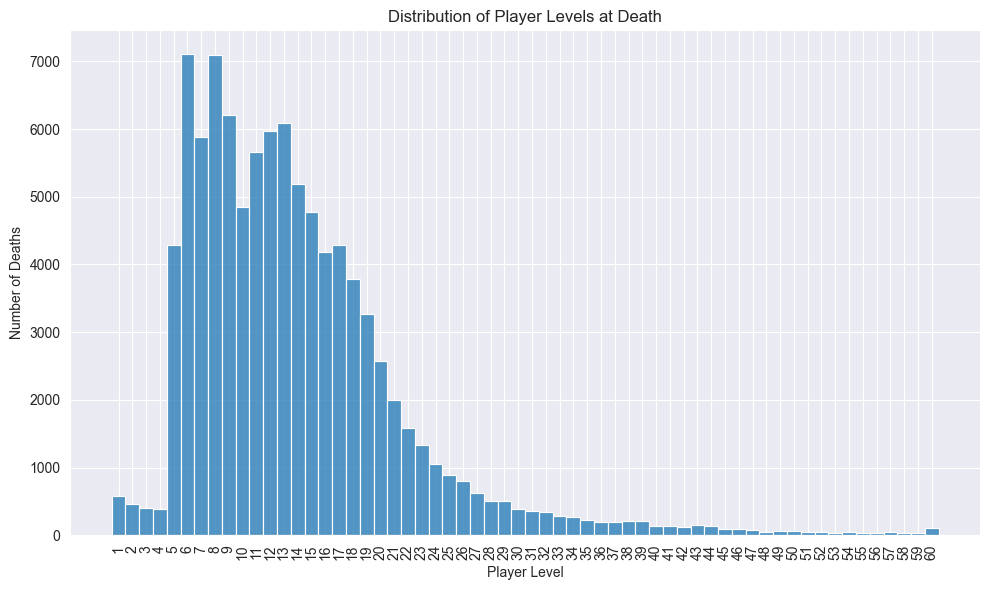

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['level'].dropna(), bins=range(1, 62), kde=False, discrete=True)
plt.title('Distribution of Player Levels at Death')
plt.xlabel('Player Level')
plt.ylabel('Number of Deaths')
plt.xticks(range(1, 61), rotation=90)
plt.tight_layout()  # This prevents labels from being cut off
plt.show()

### Insights
From the death distribution histogram, we can observe the following:
* Most deaths occur at lower levels, particularly between levels 1 and 20.
* As levels increase, the number of deaths drops significantly, with relatively few deaths in the 30–59 range.
* This suggests that players are more vulnerable at early levels due to limited gear, fewer abilities, lower survivability, and lack of experience.
* The decreasing trend may also reflect the learning curve — players who survive longer tend to become more skilled and cautious.
* Interestingly, there is a **noticeable spike in deaths at level 60**, which is much higher than levels 50–59. This spike likely reflects the challenges of max-level gameplay, such as raids, elite content, world bosses, and increased PvP activity.

## Death Counts Per Class

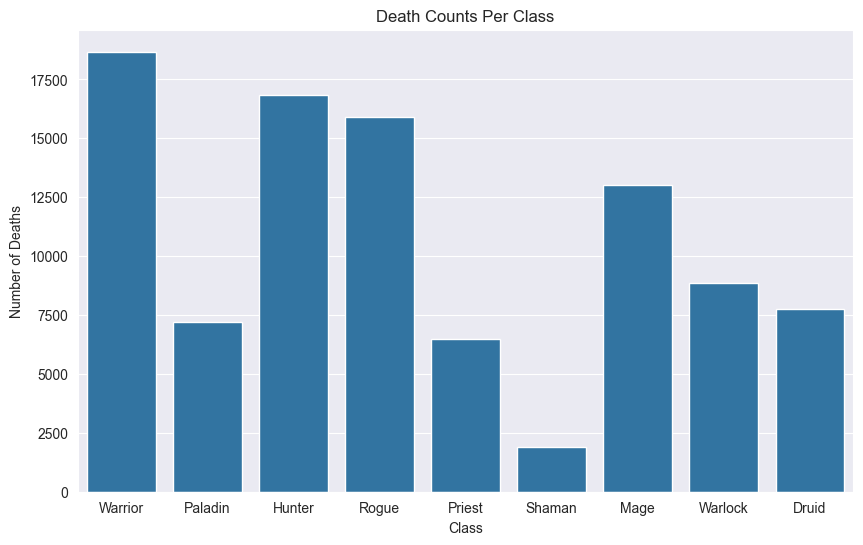

In [9]:
class_deaths = df['class_id'].value_counts().sort_index()
class_deaths_mapped = class_deaths.rename(index=class_id_to_class_name)

plt.figure(figsize=(10, 6))
sns.barplot(x=class_deaths_mapped.index, y=class_deaths_mapped.values)
plt.title('Death Counts Per Class')
plt.xlabel('Class')
plt.ylabel('Number of Deaths')
plt.show()

### Insights
From the death counts per class bar chart, we can observe the following:
* Shamans and Paladins show the lowest total number of deaths. While this might suggest they are the safest classes to play, this conclusion would be premature without accounting for class popularity.
If fewer players choose these classes overall, naturally fewer deaths will be recorded. To make a fair comparison, we would need access to total population counts per class or normalize the deaths per class proportionally.
* Not surprisingly, Warriors have the highest death counts. As a melee class that often serves as a tank, Warriors are frequently in the thick of combat, absorbing damage and facing enemies head-on.
This frontline role inherently increases their risk of death compared to ranged or support classes.

### Proportional Deaths by Class
To better understand class survivability, we can analyze deaths relative to the total number of players in each class.
Using data from the [AOTC Classic Hardcore Leaderboard](https://hc.aotc.gg/population), we obtained the total number of players per class as of November 13, 2025.

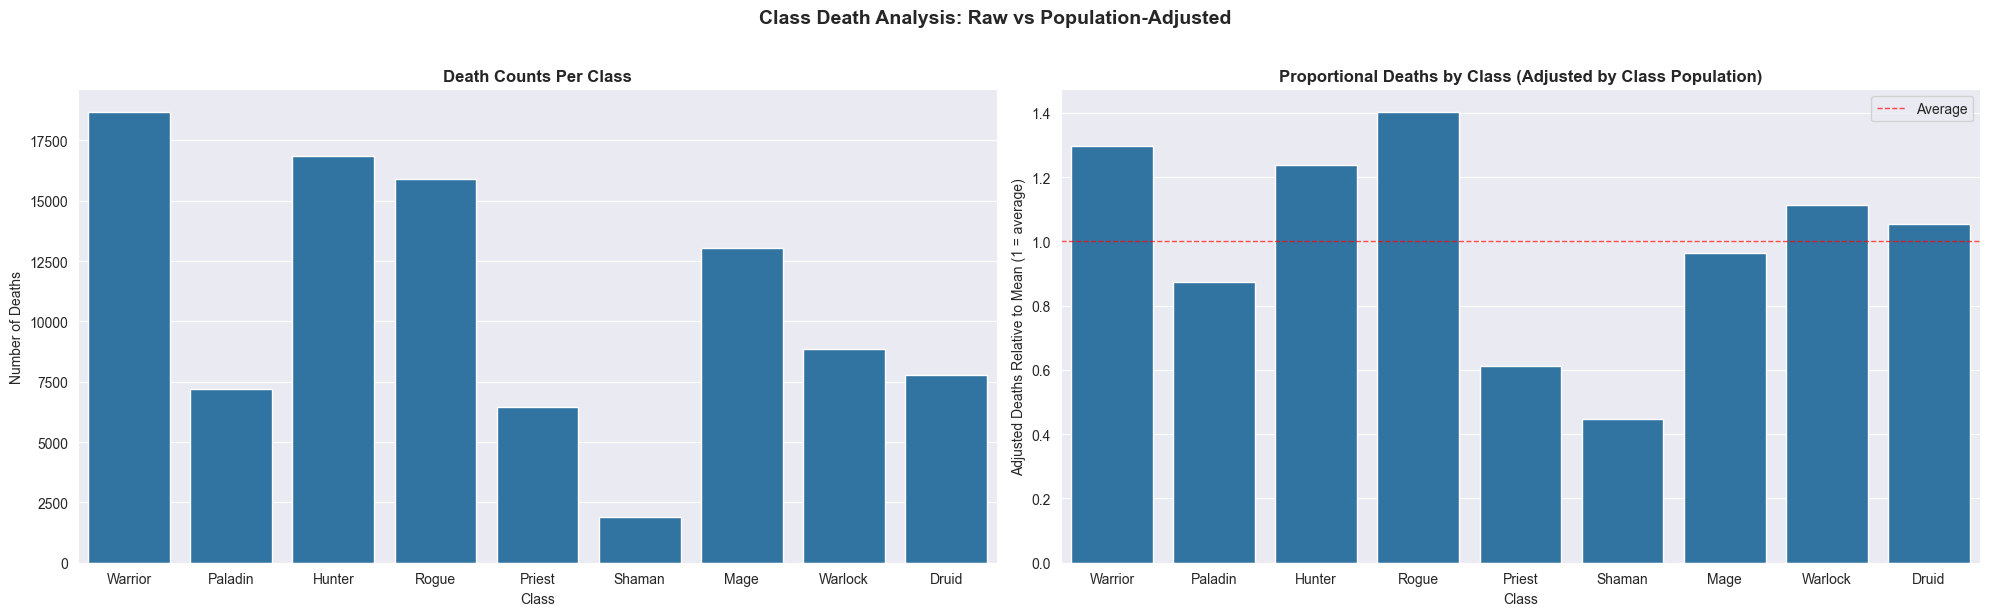

In [10]:
aotc_count_by_class = {
    1: 134_526,
    2: 76_987,
    3: 126_988,
    4: 105_806,
    5: 98_359,
    7: 39_383,
    8: 125_960,
    9: 73_993,
    11: 68_642
}

aotc_total_players = sum(aotc_count_by_class.values())

# Calculate class proportions
class_proportions = {class_id: count / aotc_total_players for class_id, count in aotc_count_by_class.items()}

# Normalize deaths: divide by proportion to get expected deaths if all classes had equal representation
adjusted_deaths = {}
for class_id, death_count in class_deaths.items():
    if class_id in class_proportions:
        # Divide by proportion to "correct" for underrepresentation
        adjusted_deaths[class_id] = death_count / class_proportions[class_id]

# Map class IDs to names
adjusted_deaths_mapped = {class_id_to_class_name[k]: v for k, v in adjusted_deaths.items()}

# Scale for readability (normalize to average = 1000)
average_adjusted = sum(adjusted_deaths_mapped.values()) / len(adjusted_deaths_mapped)
adjusted_deaths_scaled = {k: (v / average_adjusted) for k, v in adjusted_deaths_mapped.items()}

# Create side-by-side comparison of raw and adjusted death counts
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Left plot: Raw death counts per class
class_deaths = df['class_id'].value_counts().sort_index()
class_deaths_mapped = class_deaths.rename(index=class_id_to_class_name)

sns.barplot(x=class_deaths_mapped.index, y=class_deaths_mapped.values, ax=axes[0])
axes[0].set_title('Death Counts Per Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=10)
axes[0].set_ylabel('Number of Deaths', fontsize=10)

# Right plot: Population-adjusted death counts
aotc_count_by_class = {
    1: 134_526,
    2: 76_987,
    3: 126_988,
    4: 105_806,
    5: 98_359,
    7: 39_383,
    8: 125_960,
    9: 73_993,
    11: 68_642
}

aotc_total_players = sum(aotc_count_by_class.values())

# Calculate class proportions
class_proportions = {class_id: count / aotc_total_players for class_id, count in aotc_count_by_class.items()}

# Normalize deaths: divide by proportion to get expected deaths if all classes had equal representation
adjusted_deaths = {}
for class_id, death_count in class_deaths.items():
    if class_id in class_proportions:
        # Divide by proportion to "correct" for underrepresentation
        adjusted_deaths[class_id] = death_count / class_proportions[class_id]

# Map class IDs to names
adjusted_deaths_mapped = {class_id_to_class_name[k]: v for k, v in adjusted_deaths.items()}

# Scale for readability (normalize to average = 1000)
average_adjusted = sum(adjusted_deaths_mapped.values()) / len(adjusted_deaths_mapped)
adjusted_deaths_scaled = {k: (v / average_adjusted) for k, v in adjusted_deaths_mapped.items()}

sns.barplot(x=list(adjusted_deaths_scaled.keys()), y=list(adjusted_deaths_scaled.values()), ax=axes[1])
axes[1].set_title('Proportional Deaths by Class (Adjusted by Class Population)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=10)
axes[1].set_ylabel('Adjusted Deaths Relative to Mean (1 = average)', fontsize=10)
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Average')
axes[1].legend()

plt.suptitle('Class Death Analysis: Raw vs Population-Adjusted', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Insights
* **Shamans** emerge as the safest class in terms of survivability, followed closely by **Priests**. This aligns with their healing and support abilities, which likely help them survive longer in Hardcore mode.
* Surprisingly, **Rogues** have the highest death rate per player. Their fragile nature and reliance on stealth may lead to high-risk situations, resulting in more frequent deaths when encounters are misjudged.
* Another noteworthy finding is that **Hunters** also show a high death rate, despite being a ranged class with pets that can absorb damage. This may suggest that Hunter players take more risks or face challenges managing their pets effectively in Hardcore mode.


## Death Counts by Map

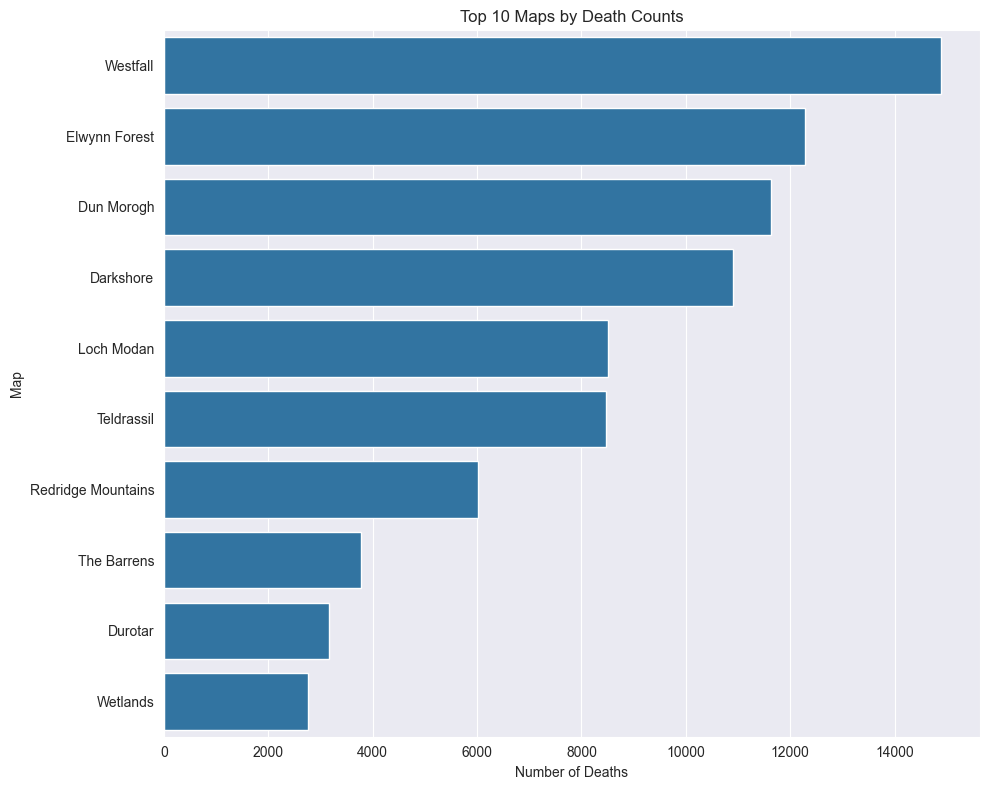

In [11]:
top_maps = df['map_id'].value_counts().head(10)
top_maps_mapped = top_maps.rename(index=map_id_to_map_name)

plt.figure(figsize=(10, 8))
sns.barplot(y=top_maps_mapped.index, x=top_maps_mapped.values)
plt.title('Top 10 Maps by Death Counts')
plt.ylabel('Map')
plt.xlabel('Number of Deaths')
plt.tight_layout()
plt.show()

## Heatmap of Death Counts by Level and Map

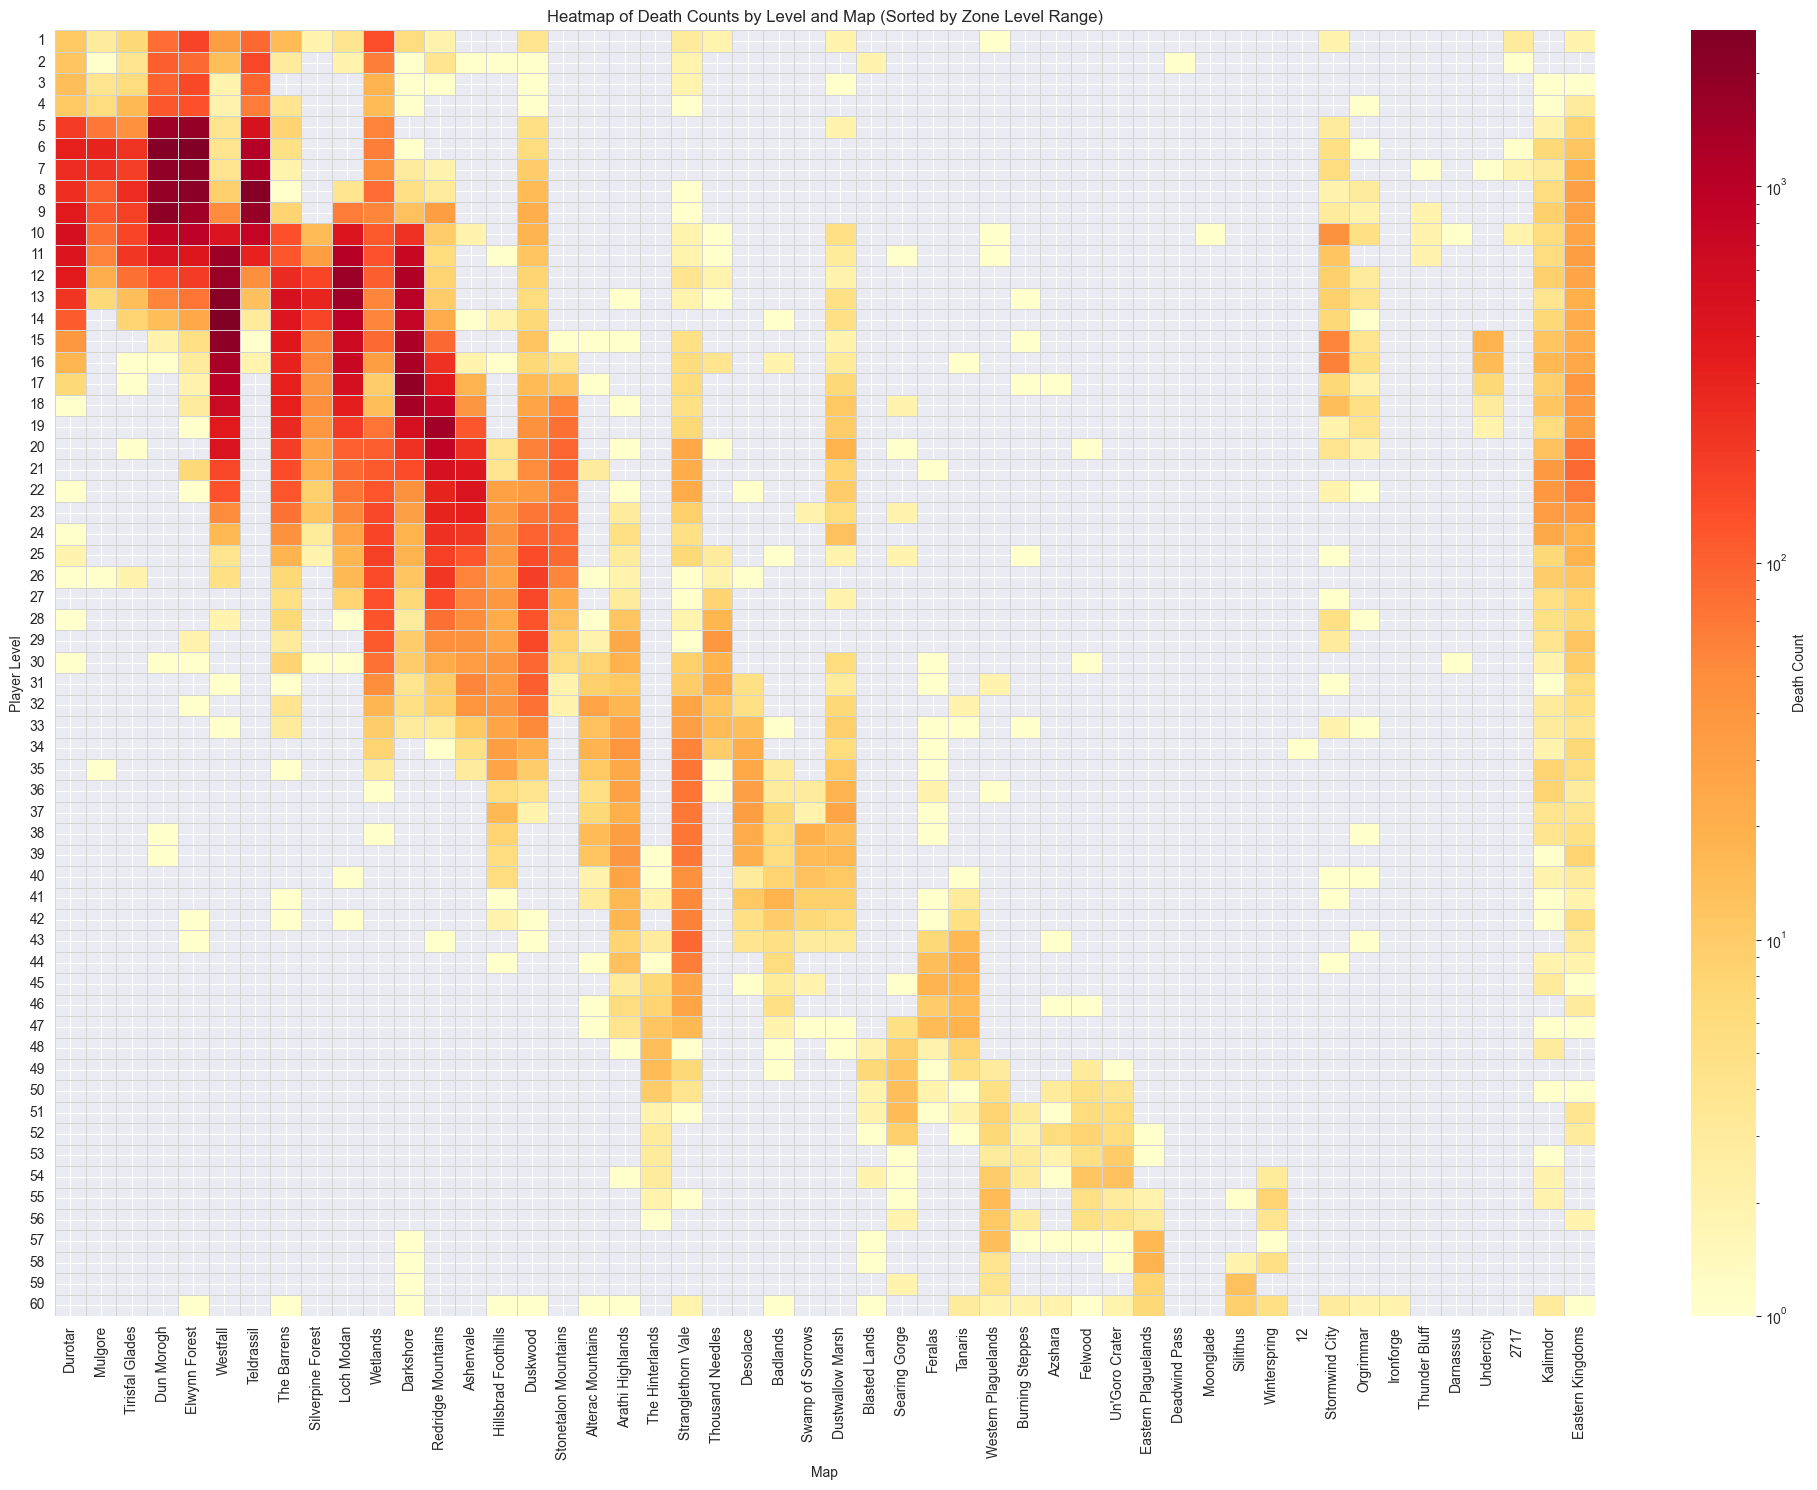

In [12]:
from matplotlib.colors import LogNorm

heatmap_data = df.pivot_table(
    index='level',
    columns='map_id',
    aggfunc='size',
    fill_value=0
)

heatmap_data_mapped = heatmap_data.rename(columns=map_id_to_map_name)

# Create a helper function to get the minimum level for sorting
def get_min_level(map_name):
    # Put continent-wide maps at the end
    if map_name in ['Kalimdor', 'Eastern Kingdoms', 'Azeroth']:
        return 1000  # Sort to the end
    
    # Find the map_id for this map_name
    map_id = next((k for k, v in map_id_to_map_name.items() if v == map_name), None)
    if map_id and map_id in map_id_to_level_range:
        return map_id_to_level_range[map_id][0]  # Return min level
    return 999  # Put other unmapped zones near the end

# Sort columns by minimum level (ascending - lower level zones first)
column_order = sorted(heatmap_data_mapped.columns, key=get_min_level)
heatmap_data_sorted = heatmap_data_mapped[column_order]

plt.figure(figsize=(20, 15))
ax = sns.heatmap(
    heatmap_data_sorted, 
    cmap='YlOrRd',
    norm=LogNorm(),
    cbar_kws={'label': 'Death Count'},
    linewidths=0.5,
    linecolor='lightgray'
)

plt.title("Heatmap of Death Counts by Level and Map (Sorted by Zone Level Range)")
plt.xlabel("Map")
plt.ylabel("Player Level")
plt.xticks(rotation=90, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Insights
* The heatmap shows that certain maps experience higher death counts at specific level ranges, which aligns with the intended difficulty design of zones for different player levels.
* Starting zones like Dun Morogh and Elwynn Forest exhibit elevated death counts at lower levels (1–20), reflecting the high population of new players and their limited experience.
* While the heatmap shows a diagonal pattern—high death counts in low-level zones and progressively fewer deaths in higher-level zones—this trend should not be interpreted solely as players becoming more skilled or better equipped at higher levels. A major contributing factor is population density: significantly more players are present in early-level zones, and far fewer reach the mid- to high-level zones.
Because the dataset reflects absolute death counts rather than death rates per active player, lower-level zones naturally accumulate many more deaths simply due to having more players.

### Notes
There are some anomalies in the data, such as deaths recorded in maps that do not align with expected level ranges. For example, `map_id = 12` and `map_id = 2717` do not correspond to
any known zones in WoW Classic and likely represent data entry errors or misclassifications.

We can try examining which rows have these map IDs:

In [13]:
# Find all rows that have map_id = 12 (Because it is wrong)
wrong_map_rows_12 = df[df['map_id'] == 12]
print(wrong_map_rows_12)

                                    map_id         map_pos  class_id  area_id  \
JösephStarting Zone Enjoyer3415727      12  [445.6, 306.4]         4       12   

                                    source_id  level  instance_id  
JösephStarting Zone Enjoyer3415727      15727     34         <NA>  


We can see that there is only one row with `map_id = 12`. Let's examine which NPC caused the death in this case. The NPC ID is stored in the `source_id = 15727`. We can look it up
in a database like [Wowhead](https://classic.wowhead.com/) to find out more about it.

Base of the Wowhead the NPC with ID `15727` is  [C'Thun](https://classic.wowhead.com/npc=15727/cthun), the final boss of the raid instance `Ahn'Qiraj`.
Which is definitely not a zone where level 34 player could possibly die. This suggests that the whole row is likely a data entry error or misclassification.

In [14]:
wrong_map_rows_2717 = df[df['map_id'] == 2717]
print(wrong_map_rows_2717)
print(f"Number of rows with map_id = 2717: {len(wrong_map_rows_2717)}")

                                     map_id  \
JøanaPexing Academy HC1011502          2717   
AsjkldjklHardcore Raiders111502        2717   
TinfoilheadHardcore and Chill115990    2717   
LvlagainImmortalNoobs611502            2717   
JÃ¸anaPexing Academy HC1011502         2717   
JøanaPexing Academy HC711502           2717   
MoistmeatHARDCORE ZONERS111502         2717   
MoistmeatHARDCORE ZONERS211502         2717   
MoistmeatHARDCORE ZONERS711502         2717   

                                                                      map_pos  \
JøanaPexing Academy HC1011502        [133.70000000000002, 133.70000000000002]   
AsjkldjklHardcore Raiders111502      [133.70000000000002, 133.70000000000002]   
TinfoilheadHardcore and Chill115990                              [45.1, 45.1]   
LvlagainImmortalNoobs611502          [133.70000000000002, 133.70000000000002]   
JÃ¸anaPexing Academy HC1011502       [133.70000000000002, 133.70000000000002]   
JøanaPexing Academy HC711502         [133.7

When examining the rows with `map_id = 2717` we find total of 9 rows. The `source_id`s in these rows are: `11502` and `15990`, which correspond to the following NPCs:
* [Ragnaros](https://classic.wowhead.com/npc=11502)
* [Kel'Thuzad](https://classic.wowhead.com/npc=15990)

Both of these NPCs are raid bosses from `Molten Core` and `Naxxramas` respectively, which again do not align with the level ranges of the players who died in these instances.
This further supports the conclusion that these rows are likely data entry errors or misclassifications.

#### Observation
We also can see that the names of the players contain the ID of the NPC that killed them. This suggests that the data might have been generated or logged in manually.

## Level at Death By Class

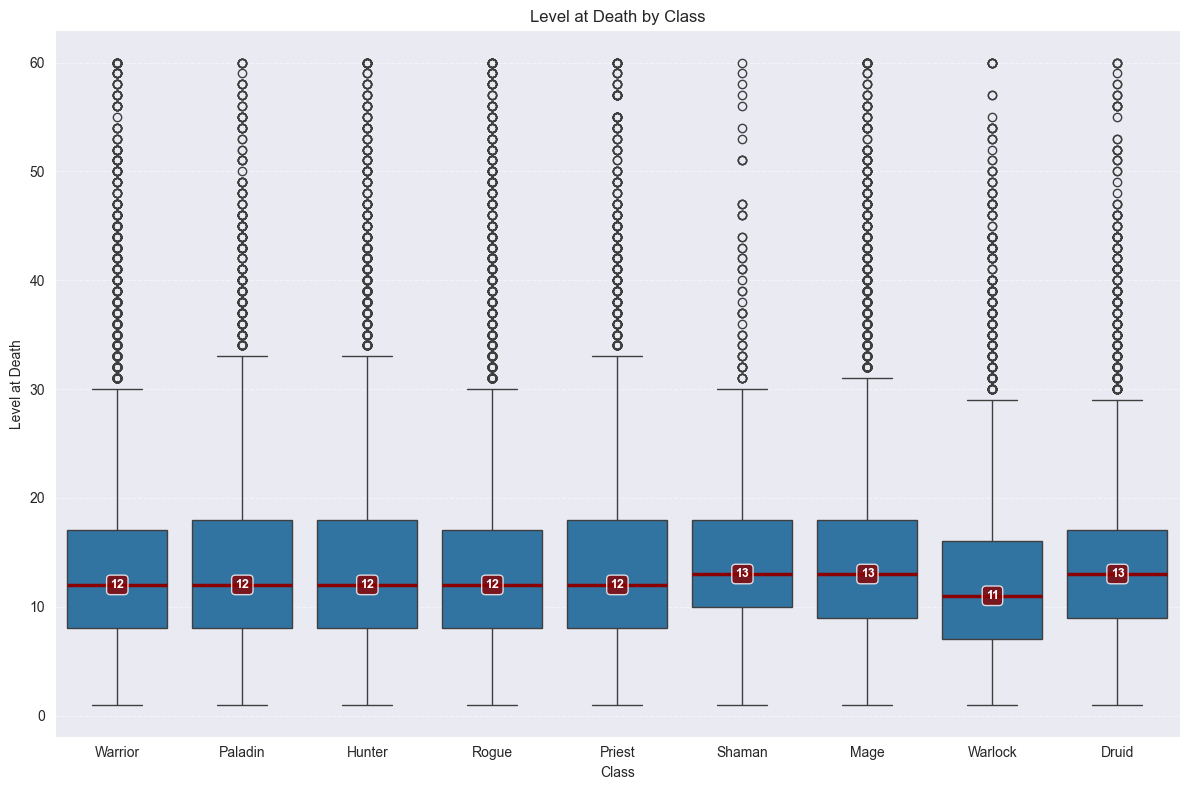

In [15]:
plt.figure(figsize=(12, 8))
ax = sns.boxplot(x='class_id', y='level', data=df, order=sorted(class_id_to_class_name.keys()),
                 medianprops=dict(color='darkred', linewidth=2.5))
plt.xticks(ticks=range(len(class_id_to_class_name)), labels=[class_id_to_class_name[i] for i in sorted(class_id_to_class_name.keys())])

# Add gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Annotate medians
medians = df.groupby('class_id')['level'].median()
for i, class_id in enumerate(sorted(class_id_to_class_name.keys())):
    median_val = medians[class_id]
    ax.text(i, median_val, f'{median_val:.0f}', 
            ha='center', va='center', fontweight='bold', 
            fontsize=9, color='white', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='darkred', alpha=0.8))

plt.title('Level at Death by Class')
plt.xlabel('Class')
plt.ylabel('Level at Death')
plt.tight_layout()
plt.show()

### Insights
* These results are pretty surprising. The median death level for all classes hovers around level 12. This suggests that most player deaths occur early in the leveling process, likely due to inexperience and lack of gear.
* What is particularly interesting is that pretty safe class like Warlock has the lowest median death level at 11. This is most likely cause by his class quest at level 10
which requires players to face a challenging encounter that can lead to early deaths.

## Class Deaths By Map Location

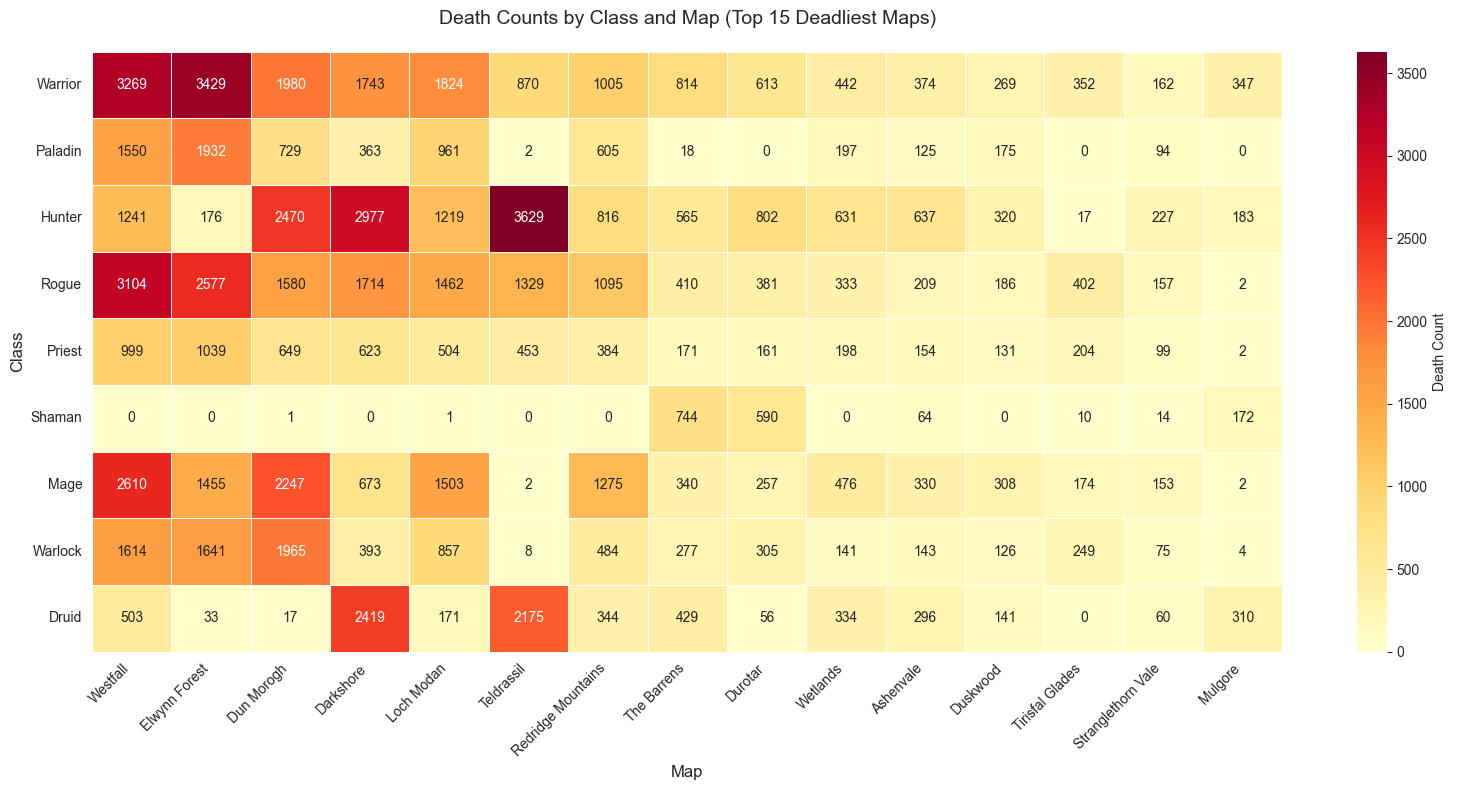

In [16]:
# Create a pivot table showing deaths by class and map
class_map_deaths = df.pivot_table(
    index='class_id',
    columns='map_id',
    aggfunc='size',
    fill_value=0
)

# Map class IDs to class names
class_map_deaths_named = class_map_deaths.rename(index=class_id_to_class_name)

# Map map IDs to map names
class_map_deaths_named = class_map_deaths_named.rename(columns=map_id_to_map_name)

# Filter to show only top 15 deadliest maps for better readability
top_15_maps = df['map_id'].value_counts().head(15).index
top_15_map_names = [map_id_to_map_name.get(map_id, f'Map {map_id}') for map_id in top_15_maps]
class_map_filtered = class_map_deaths_named[top_15_map_names]

# Create heatmap
plt.figure(figsize=(16, 8))
ax = sns.heatmap(
    class_map_filtered,
    cmap='YlOrRd',
    annot=True,
    fmt='g',
    cbar_kws={'label': 'Death Count'},
    linewidths=0.5,
    linecolor='white'
)

plt.title('Death Counts by Class and Map (Top 15 Deadliest Maps)', fontsize=14, pad=20)
plt.xlabel('Map', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Insights
* In Elwynn Forest, Rogues have fewer deaths than Warriors, and the gap between the two classes is larger here than in Westfall.
This suggests that Rogues are particularly effective at surviving in Elwynn Forest, while in Westfall the survival advantage of Rogues over Warriors is smaller.
* In Durotar, Warriors and Shamans have similar death counts, whereas in Mulgore, Shamans die about half as often as Warriors.
This may indicate that Shamans are either better suited for surviving in Mulgore, or that player race/class choices (Orc/Troll Shamans in Durotar vs. Tauren Shamans in Mulgore) influence survival outcomes.

## Top Killer NPCs

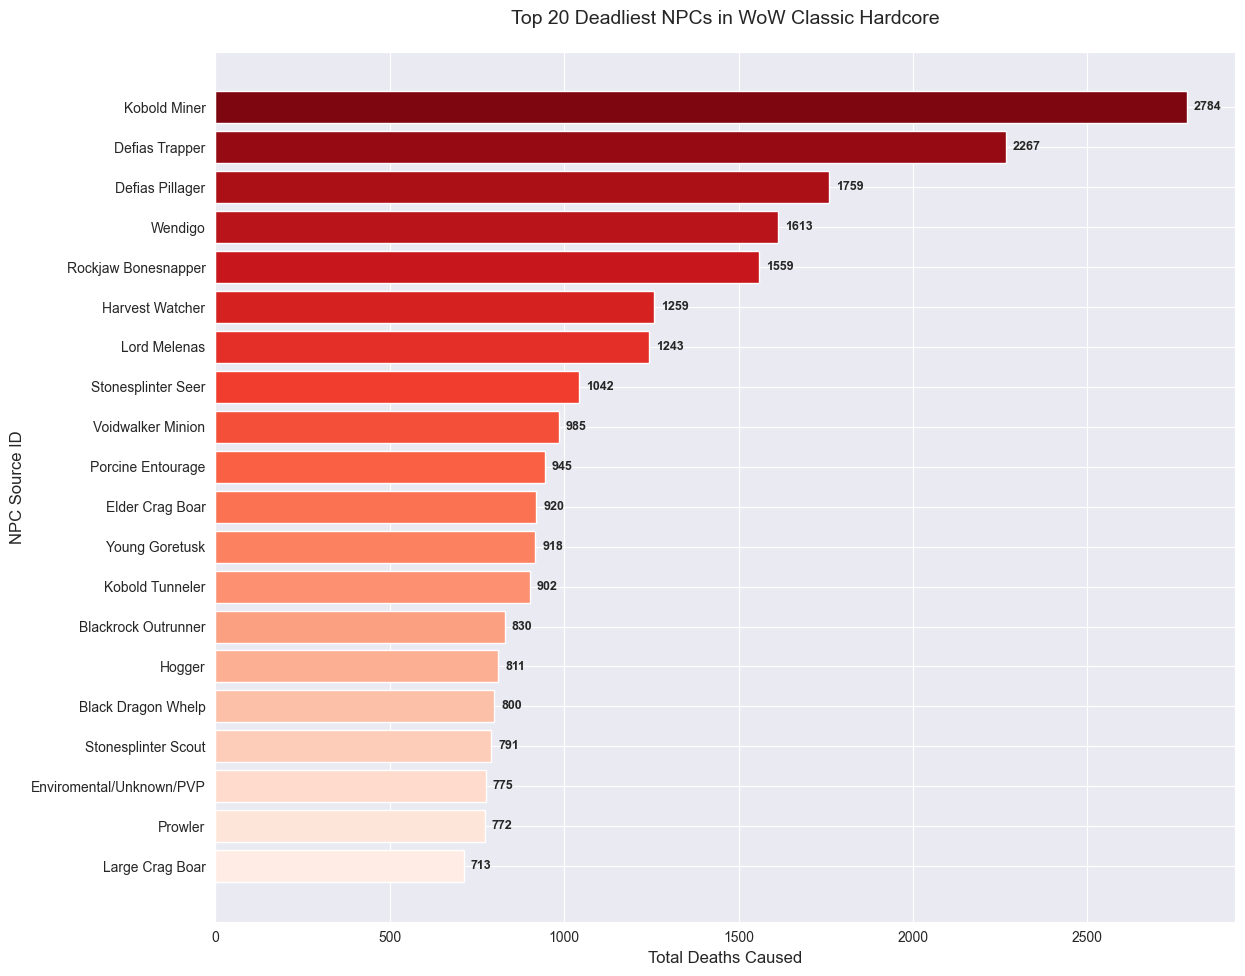

In [17]:
# Get top 20 killer NPCs
top_killers = df['source_id'].value_counts().head(20)

# Create a simple color palette
colors = sns.color_palette('Reds_r', n_colors=len(top_killers))

top_killers_mapped = top_killers.rename(index=npc_id_to_npc_name)

plt.figure(figsize=(12, 10))
ax = plt.barh(range(len(top_killers_mapped)), top_killers_mapped.values, color=colors)

# Set y-axis labels
plt.yticks(range(len(top_killers_mapped)), top_killers_mapped.index)

# Add value labels on the bars
for i, v in enumerate(top_killers_mapped.values):
    plt.text(v + 20, i, str(v), va='center', fontweight='bold', fontsize=9)

plt.title('Top 20 Deadliest NPCs in WoW Classic Hardcore', fontsize=14, pad=20)
plt.xlabel('Total Deaths Caused', fontsize=12)
plt.ylabel('NPC Source ID', fontsize=12)
plt.gca().invert_yaxis()  # Invert to have highest at top
plt.subplots_adjust(left=0.1, right=0.95, top=0.95, bottom=0.08)
plt.show()

### Insights
* The deadliest NPC is the Kobold Miner — a result that makes perfect sense. Since most Hardcore players start as Alliance Humans, they encounter Kobold Miners very early in the game.
The narrow tunnels of the Fargodeep and Jasper Mines make it easy for new players to accidentally pull multiple Kobolds at once, leading to many early-level deaths.
* Among the 20 deadliest NPCs, only one is an elite: Hogger. This is unsurprising because starting zones contain very few elite enemies.
Hogger, however, is a notorious exception — a well-known low-level elite in the Human starting area who has caused countless early deaths in WoW Classic. This reinforces how heavily early-game zones influence overall death statistics.
* A slightly humorous observation is that the 18th deadliest “NPC” is actually Environmental — the label used when source_id = -1.
According to the dataset author, this category includes deaths from falling, drowning, or other non-combat hazards. This highlights how easily inexperienced players can die from the world itself, not just from enemies.

#### Environmental Deaths

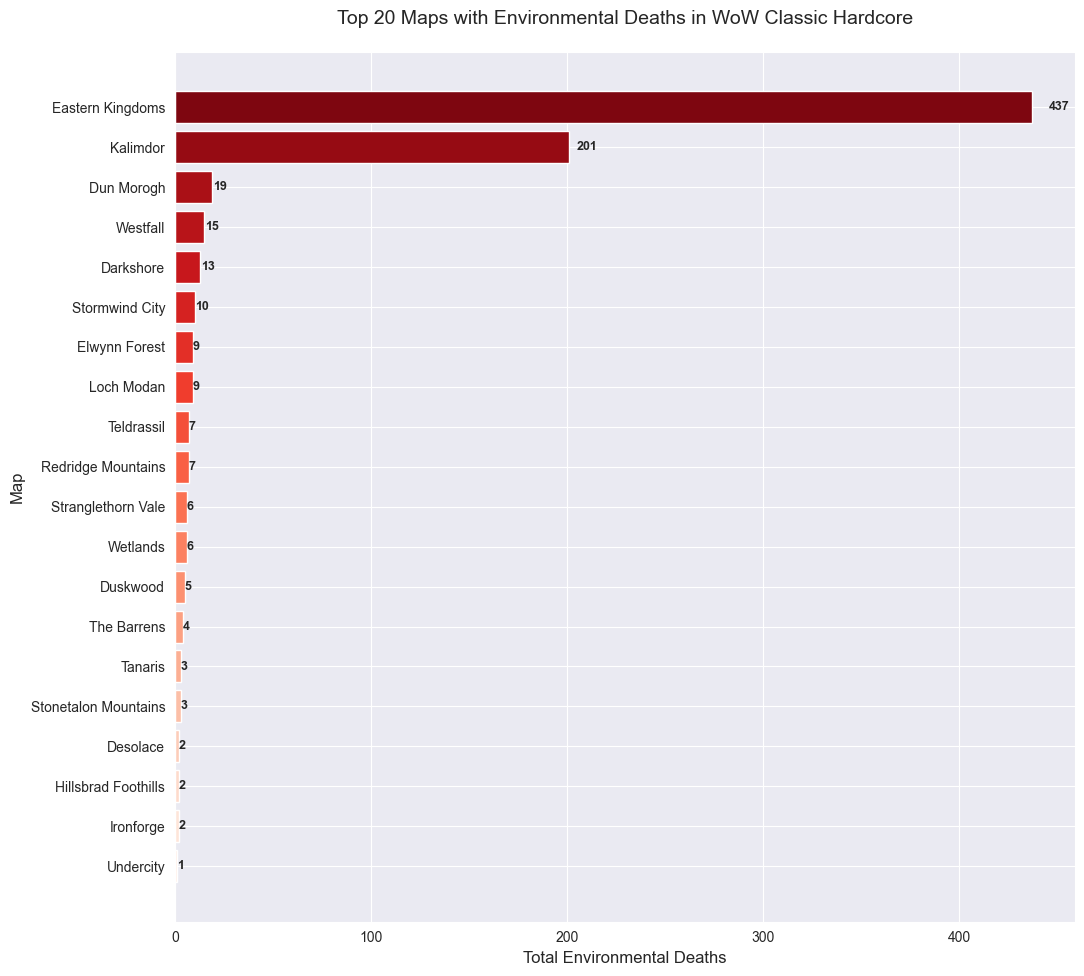

In [18]:
# Find where most players die from source_id = -1
df_environmental_deaths = df[df['source_id'] == -1]
environmental_deaths = df_environmental_deaths['map_id'].value_counts().head(20)

# Create a simple color palette
colors = sns.color_palette('Reds_r', n_colors=len(environmental_deaths))

environmental_deaths_mapped = environmental_deaths.rename(index=map_id_to_map_name)

plt.figure(figsize=(12, 10))
ax = plt.barh(range(len(environmental_deaths_mapped)), environmental_deaths_mapped.values, color=colors)

# Set y-axis labels
plt.yticks(range(len(environmental_deaths_mapped)), environmental_deaths_mapped.index)

# Add value labels on the bars
for i, v in enumerate(environmental_deaths_mapped.values):
    plt.text(v + (v * 0.02), i, str(v), va='center', fontweight='bold', fontsize=9)

plt.title('Top 20 Maps with Environmental Deaths in WoW Classic Hardcore', fontsize=14, pad=20)
plt.xlabel('Total Environmental Deaths', fontsize=12)
plt.ylabel('Map', fontsize=12)
plt.gca().invert_yaxis()  # Invert to have highest at top
plt.subplots_adjust(left=0.2, right=0.95, top=0.95, bottom=0.08)
plt.show()


I initially expected that analyzing the locations of environmental deaths would reveal interesting patterns—for example, idefntifying places where players most often fall, drown, or die to PvP.
However, after reviewing the Deathlog addon's implementation, I discovered a limitation: the map_id field is recorded primarily as the continent where the player died rather than the specific zone.
Because of this, it’s not possible to accurately pinpoint the exact location of environmental or PvP-related deaths.

I also examined the map_pos values to see if they could provide more precise positional information.
According to the addon’s code, these coordinates were originally normalized from 0 to 1 (where 0 represents the far left/bottom of the map and 1 represents the far right/top) but were later rescaled to range between 0 and 1000.
Unfortunately, even with this transformation, the map_pos data still does not correspond to meaningful or consistent in-game locations. As a result, it cannot be used reliably for spatial analysis of environmental death hotspots.


## Top Killers by Level Bracket

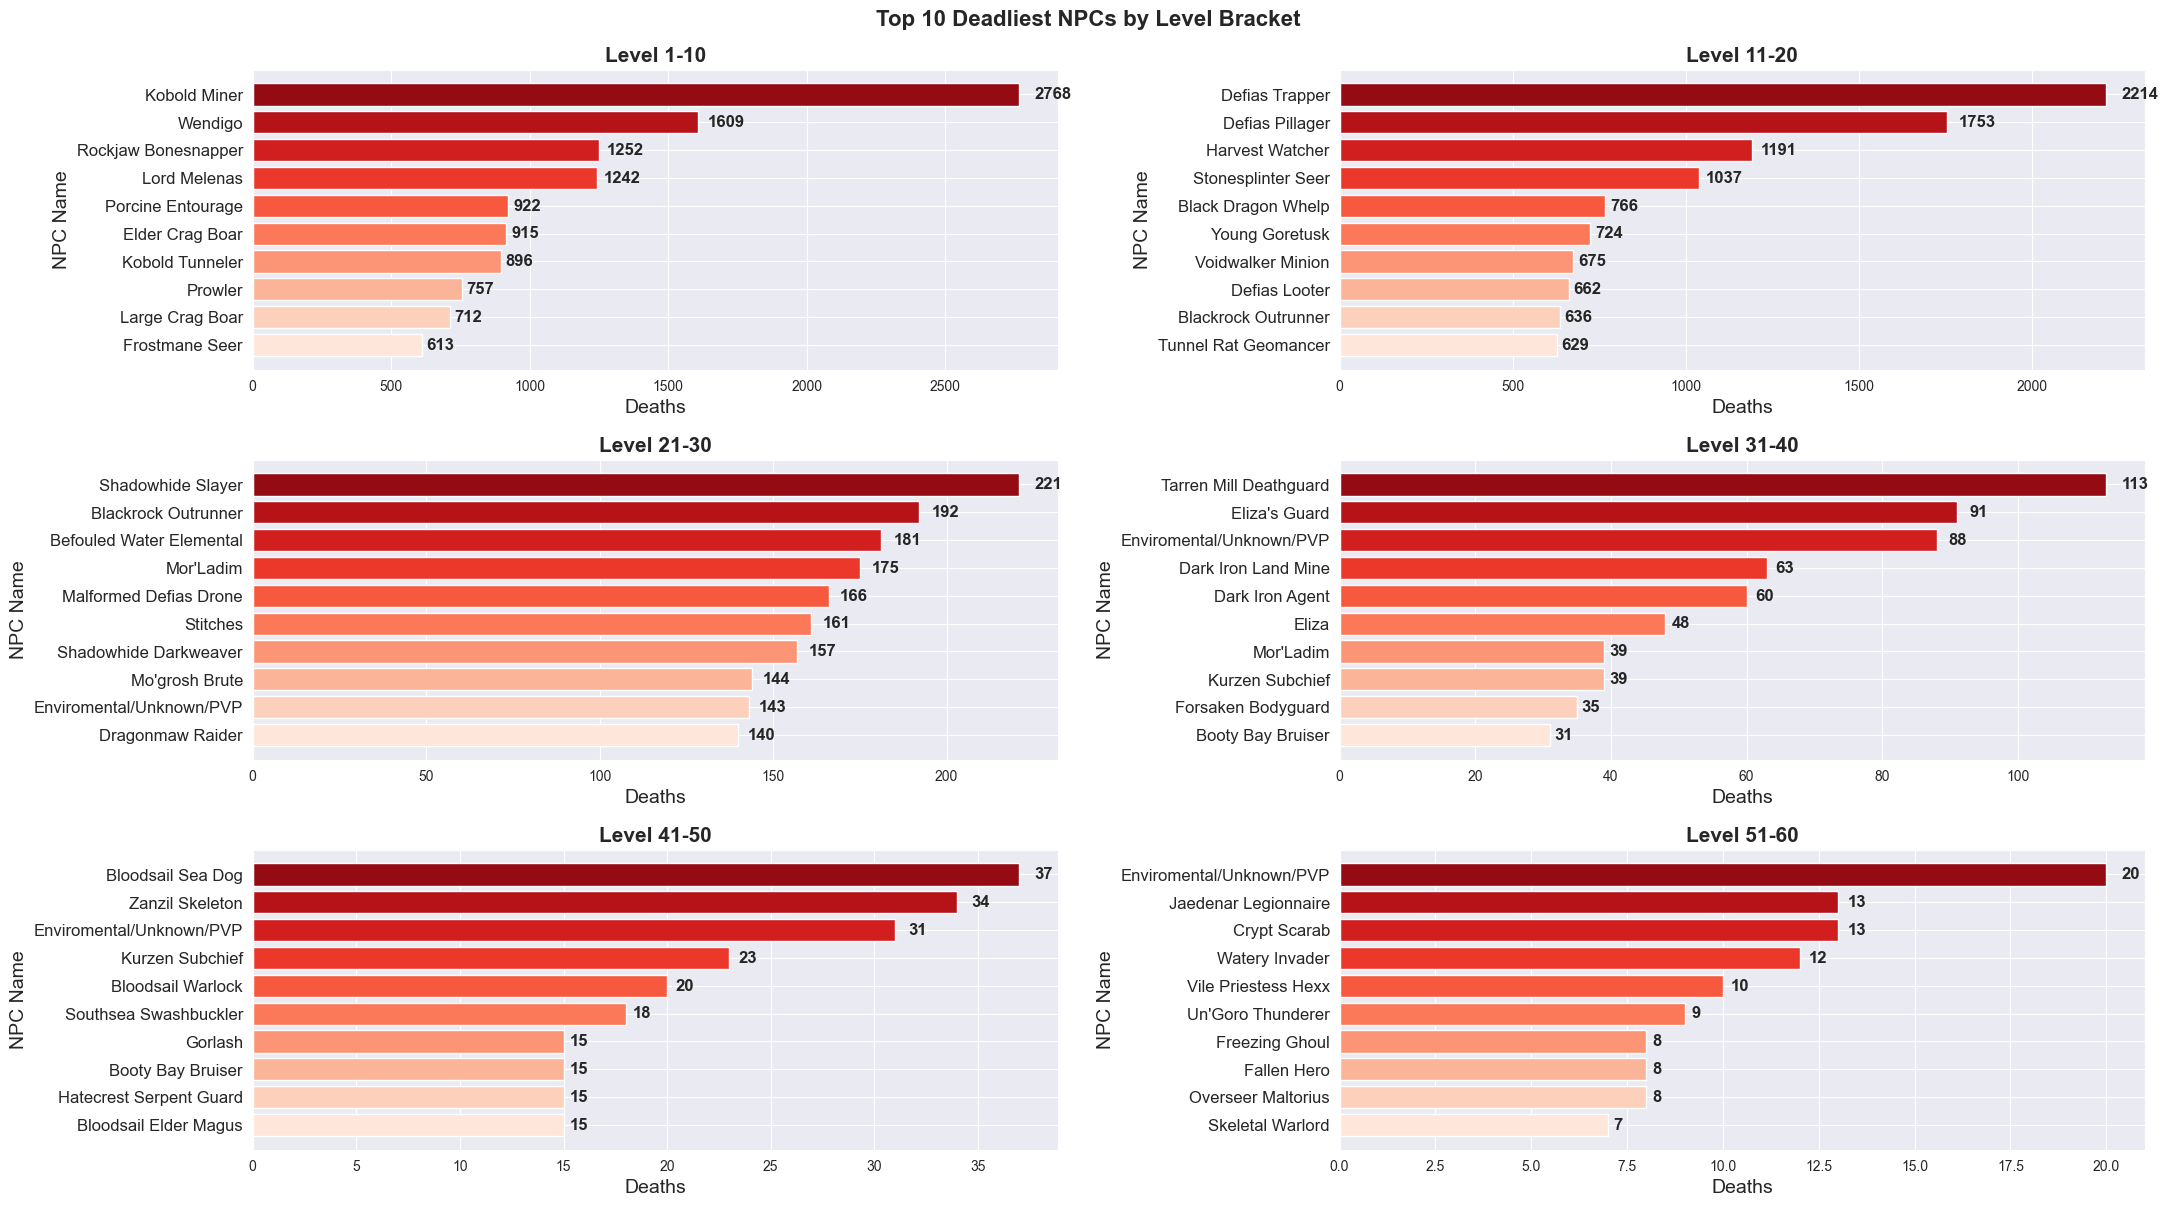

In [19]:
# Create level brackets
df['level_bracket'] = pd.cut(
    df['level'],
    bins=[0, 10, 20, 30, 40, 50, 60],
    labels=['1-10', '11-20', '21-30', '31-40', '41-50', '51-60']
)

# Get top 5 killers for each level bracket
level_brackets = ['1-10', '11-20', '21-30', '31-40', '41-50', '51-60']
fig, axes = plt.subplots(3, 2, figsize=(22, 12))  # Wider figure
axes = axes.flatten()

for idx, bracket in enumerate(level_brackets):
    bracket_data = df[df['level_bracket'] == bracket]
    top_killers_bracket = bracket_data['source_id'].value_counts().head(10)
    top_killers_bracket_mapped = top_killers_bracket.rename(index=npc_id_to_npc_name)

    ax = axes[idx]
    if len(top_killers_bracket_mapped) > 0:
        # Truncate long names
        truncated_names = [name[:30] + '...' if len(name) > 30 else name for name in
                           top_killers_bracket_mapped.index]

        # Create color palette manually for each bar
        colors = sns.color_palette('Reds_r', n_colors=len(top_killers_bracket_mapped))

        # Use matplotlib barh instead of seaborn to avoid FutureWarning
        ax.barh(range(len(top_killers_bracket_mapped)), top_killers_bracket_mapped.values, color=colors)
        ax.set_yticks(range(len(top_killers_bracket_mapped)))
        ax.set_yticklabels(truncated_names, fontsize=12)
        ax.invert_yaxis()  # Highest at top

        # Add value labels
        for i, v in enumerate(top_killers_bracket_mapped.values):
            ax.text(v + (v * 0.02), i, str(v), va='center', fontsize=12, fontweight='bold')

        ax.set_title(f'Level {bracket}', fontsize=15, fontweight='bold')
        ax.set_xlabel('Deaths', fontsize=14)
        ax.set_ylabel('NPC Name', fontsize=14)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Level {bracket}', fontsize=12, fontweight='bold')

plt.suptitle('Top 10 Deadliest NPCs by Level Bracket', fontsize=16, fontweight='bold', y=1.00)
plt.subplots_adjust(left=0.12, right=0.98, top=0.95, bottom=0.05, hspace=0.3, wspace=0.35)  # More spacing
plt.show()


### Insights

* **Massive Early-Game Attrition:** The most significant finding is the drastic difference in scale across the charts. The top killer in the 1-10 bracket claims nearly **2,800 lives**, whereas the top killer in the 51-60 bracket claims only **20**. This confirms that the vast majority of Hardcore runs end in the early game (Levels 1-20).
* **Validation of "Noob Killers":** The data validates community knowledge regarding specific lethal mobs. The **Defias Pillager** (Level 11-20) is notorious for high magic damage, and its position as the #2 killer confirms it is a major hurdle for players leaving the starting zones.
* **The "Patrol" Check:** In the mid-game (Levels 21-30), high-level elite patrol mobs like **Stitches** and **Mor'Ladim** appear in the top 10. This indicates that deaths shift from losing fair fights to lacking situational awareness (wandering into the path of a wandering elite).
* **Environmental Risks at High Levels:** By Levels 41-50 and 51-60, **"Environmental/Unknown/PVP"** rises to become a top cause of death. This suggests that veteran players rarely die to standard combat; instead, they succumb to fall damage, disconnects, or unique hazards.
* **Dataset Population Bias:** The specific mobs listed (Kobold Miner, Wendigo, Defias) are found exclusively in Human and Dwarf starting zones. This strongly implies the dataset is heavily skewed toward **Alliance** players.

# Research Question: Is there a relationship between character level and the likelihood of dying in a specific location?

## Preprocessing

Based on the findings from the EDA, several data quality issues need to be addressed before proceeding with further analysis. Specifically, certain `map_id` values are either incorrect or too coarse to be useful.

### Filters Applied

1. **Remove invalid `map_id` values:**
   Records containing `map_id = 2717` or `map_id = 12` are clearly erroneous and must be excluded.

2. **Remove overly broad map identifiers:**
   Entries with `map_id = 1414` (Kalimdor) or `map_id = 1415` (Eastern Kingdoms) represent entire continents rather than specific locations. Since every death occurs *within* one of these continents, these values provide no meaningful spatial resolution and are therefore removed.



In [20]:
invalid_maps = [2717, 14, 1414, 1415]

df_clean = df[~df['map_id'].isin(invalid_maps)].copy()

print("Original rows:", len(df))
print("Rows removed:", len(df) - len(df_clean))
print("Cleaned rows:", len(df_clean))

Original rows: 96603
Rows removed: 1181
Cleaned rows: 95422


## 1. Normalized Heatmaps

/var/folders/x8/nk8375rj1j1_z078xskcnz4c0000gn/T/ipykernel_8602/132825339.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_clean.pivot_table(index='level_bracket', columns='map_id', aggfunc='size', fill_value=0)


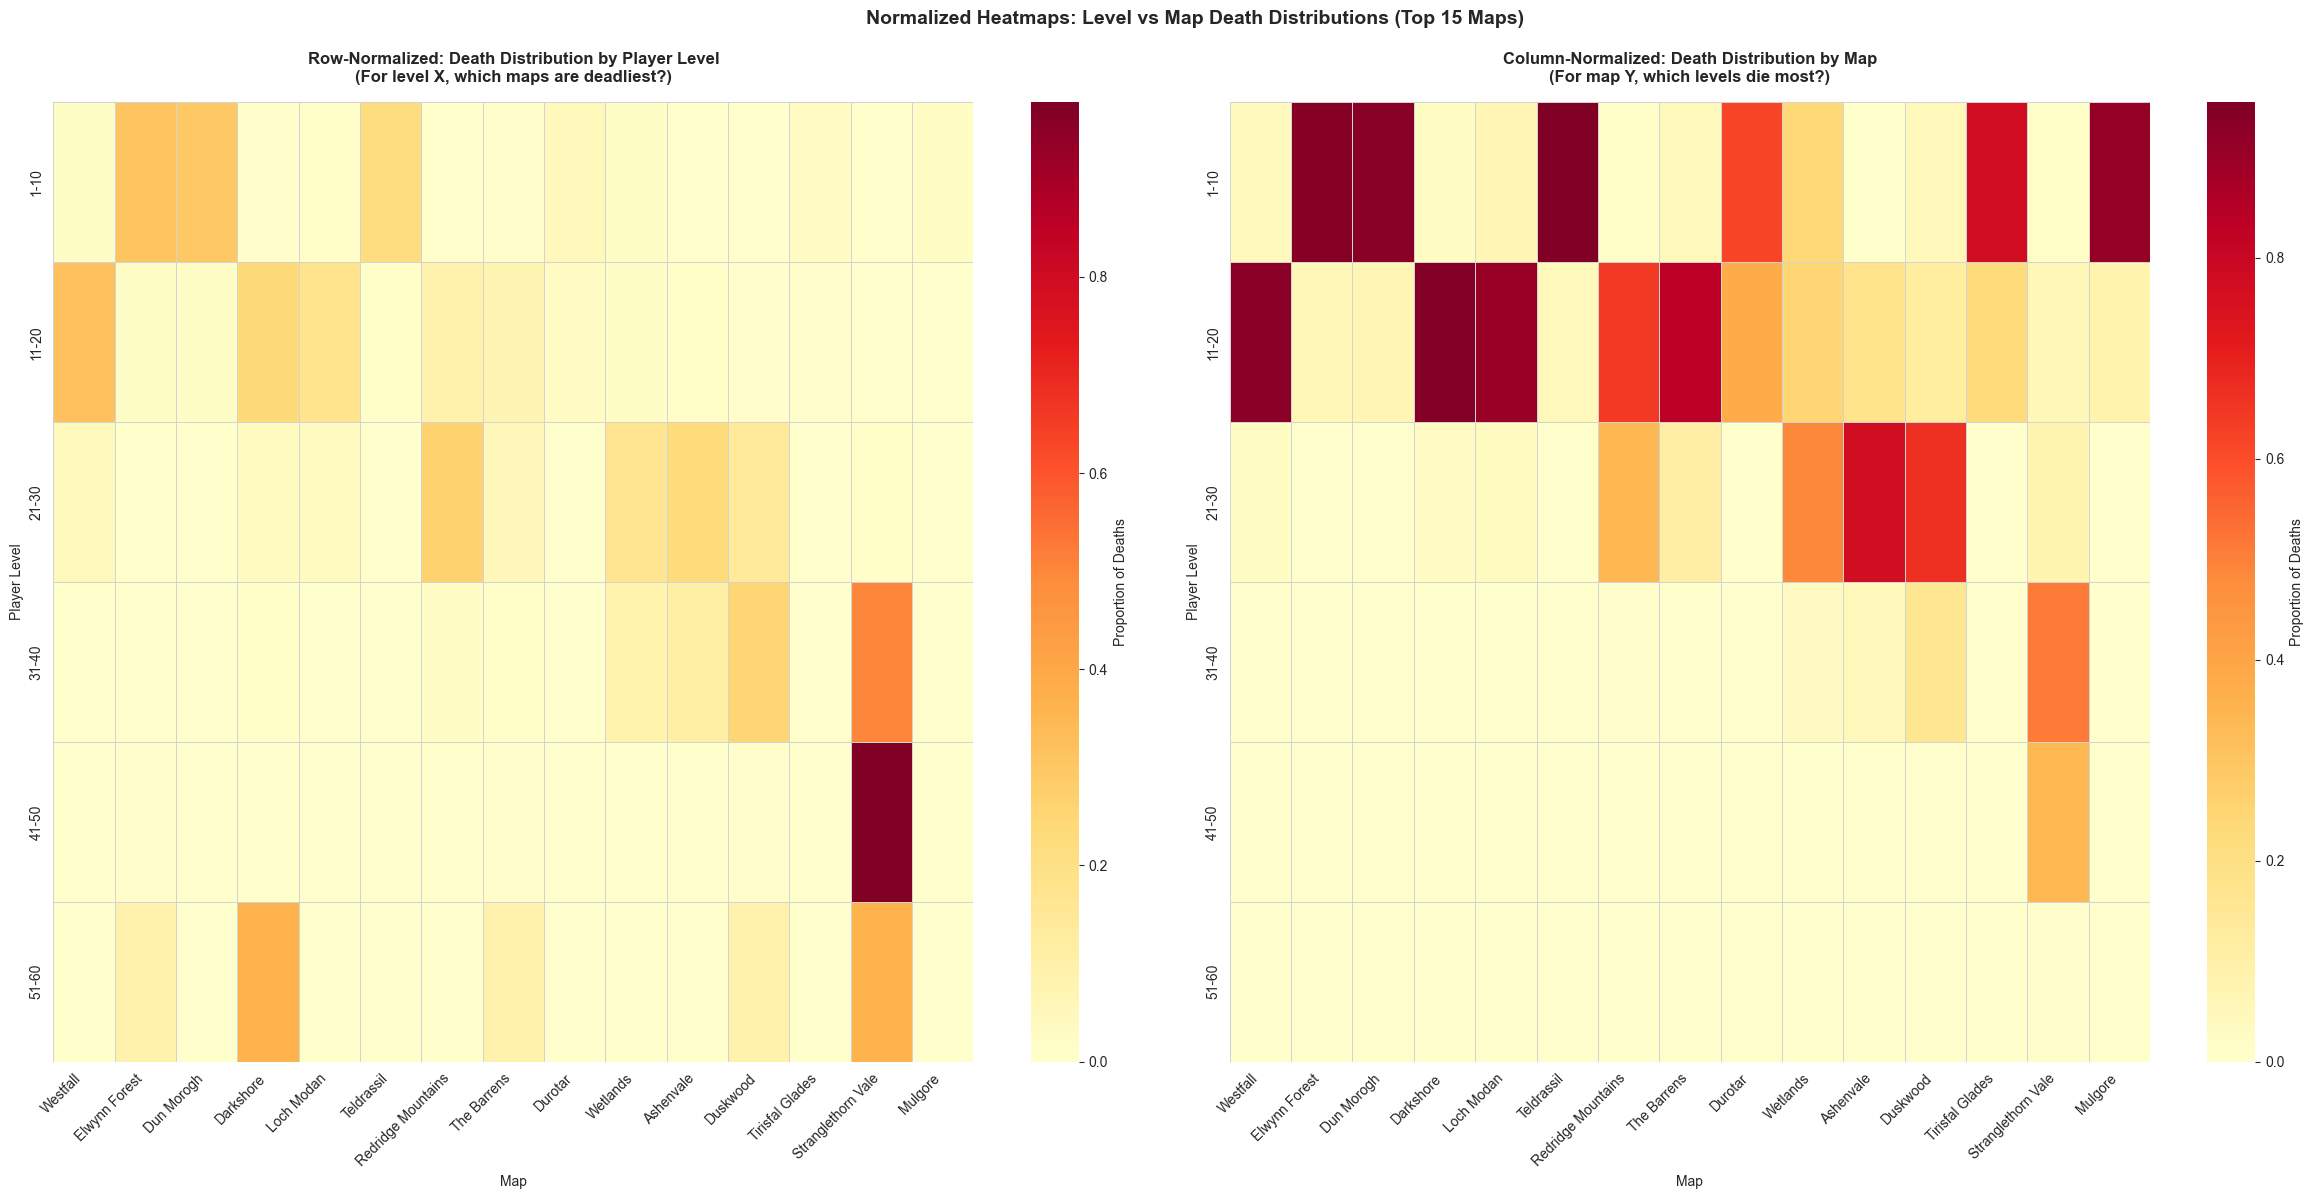

In [21]:
# Create raw pivot table
pivot = df_clean.pivot_table(index='level_bracket', columns='map_id', aggfunc='size', fill_value=0)

# Filter to top 15 maps by total deaths for readability
top_maps = df_clean['map_id'].value_counts().head(15).index
pivot_filtered = pivot[top_maps]

# Row-normalized (per level) - "For players at level X, where do they die?"
row_norm = pivot_filtered.div(pivot_filtered.sum(axis=1), axis=0)

# Column-normalized (per map) - "For deaths in map Y, what levels die there?"
col_norm = pivot_filtered.div(pivot_filtered.sum(axis=0), axis=1)

# Map IDs to names for better readability
row_norm_mapped = row_norm.rename(columns=map_id_to_map_name)
col_norm_mapped = col_norm.rename(columns=map_id_to_map_name)

# Create side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# Left: Row-normalized
sns.heatmap(
    row_norm_mapped,
    cmap='YlOrRd',
    cbar_kws={'label': 'Proportion of Deaths'},
    linewidths=0.5,
    linecolor='lightgray',
    ax=axes[0],
    vmin=0,
    vmax=row_norm_mapped.max().max()
)
axes[0].set_title('Row-Normalized: Death Distribution by Player Level\n(For level X, which maps are deadliest?)', 
                  fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('Map', fontsize=10)
axes[0].set_ylabel('Player Level', fontsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Right: Column-normalized
sns.heatmap(
    col_norm_mapped,
    cmap='YlOrRd',
    cbar_kws={'label': 'Proportion of Deaths'},
    linewidths=0.5,
    linecolor='lightgray',
    ax=axes[1],
    vmin=0,
    vmax=col_norm_mapped.max().max()
)
axes[1].set_title('Column-Normalized: Death Distribution by Map\n(For map Y, which levels die most?)', 
                  fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Map', fontsize=10)
axes[1].set_ylabel('Player Level', fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Normalized Heatmaps: Level vs Map Death Distributions (Top 15 Maps)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Insights from Normalized Heatmaps

**Row-Normalized Heatmap (Left)**:
* Shows the **proportion** of deaths for each level across different maps
* Each row sums to 1 (100% of deaths for that level)
* Reveals which maps are relatively more dangerous for specific level ranges
* Dark red areas indicate that players at that level die disproportionately more in that particular map
* Example interpretation: If level 10 shows dark red in "Westfall", it means a high percentage of level 10 deaths occur there

**Column-Normalized Heatmap (Right)**:
* Shows the **level distribution** of deaths within each map
* Each column sums to 1 (100% of deaths in that map)
* Reveals which levels are most vulnerable in each specific zone
* Dark red areas indicate that a particular level contributes heavily to deaths in that map
* Example interpretation: If "Dun Morogh" shows dark red at levels 5-8, most deaths in that zone come from those level ranges

**Key Observations**:
* **Diagonal patterns** in row-normalized heatmap suggest zone progression aligns with level (low-level zones → low-level deaths)
* **Concentrated bands** in column-normalized heatmap show the "intended" level range for each zone
* **Off-diagonal hotspots** indicate unusual death patterns (e.g., high-level players dying in low-level zones, or vice versa)
* These normalized views remove population bias and reveal the **true relationship** between level and map death likelihood

## 2. Kruskal-Wallis Test

In [22]:
import scipy.stats as stats

# Create groups of level data for each map
groups = [
    df_clean[df_clean['map_id'] == m]['level'].dropna()
    for m in df_clean['map_id'].dropna().unique()
]

# Perform Kruskal-Wallis H-test
stat, p = stats.kruskal(*groups)

print("=" * 70)
print("KRUSKAL-WALLIS H-TEST RESULTS")
print("=" * 70)
print(f"H-statistic: {stat:.4f}")
print(f"p-value: {p:.4e}")
print()

# Interpretation
if p < 0.05:
    print("✓ Result: SIGNIFICANT relationship detected (p < 0.05)")
    print("  → The level distributions differ significantly between maps")
    print("  → Player level is associated with which map they die in")
else:
    print("✗ Result: NO significant relationship detected (p ≥ 0.05)")
    print("  → The level distributions do NOT differ significantly between maps")
    print("  → Player level is independent of which map they die in")

print()
print("-" * 70)

# Calculate effect size (Epsilon-squared)
H = stat
n = len(df_clean[df_clean['map_id'].notna()])
k = len(df_clean['map_id'].dropna().unique())

epsilon_squared = (H - k + 1) / (n - k)

print("EFFECT SIZE (Epsilon-squared)")
print("-" * 70)
print(f"Epsilon-squared: {epsilon_squared:.6f}")
print()

# Interpret effect size
if epsilon_squared < 0.01:
    effect_interpretation = "negligible"
elif epsilon_squared < 0.06:
    effect_interpretation = "small"
elif epsilon_squared < 0.14:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"

print(f"Effect size interpretation: {effect_interpretation.upper()}")
print()
print("-" * 70)
print()

# Additional context
print("CONTEXT:")
print(f"  • Total observations: {n:,}")
print(f"  • Number of unique maps: {k}")
print(f"  • Degrees of freedom: {k - 1}")
print()

KRUSKAL-WALLIS H-TEST RESULTS
H-statistic: 72463.7814
p-value: 0.0000e+00

✓ Result: SIGNIFICANT relationship detected (p < 0.05)
  → The level distributions differ significantly between maps
  → Player level is associated with which map they die in

----------------------------------------------------------------------
EFFECT SIZE (Epsilon-squared)
----------------------------------------------------------------------
Epsilon-squared: 0.765815

Effect size interpretation: LARGE

----------------------------------------------------------------------

CONTEXT:
  • Total observations: 94,610
  • Number of unique maps: 47
  • Degrees of freedom: 46



### Insights from Kruskal-Wallis Test

**What the test measures**:
* The Kruskal-Wallis H-test is a non-parametric test that checks whether the level distributions differ significantly across different maps
* **Null hypothesis (H₀)**: Player level distributions are the same across all maps (no relationship)
* **Alternative hypothesis (H₁)**: At least one map has a different level distribution (relationship exists)

**Why Kruskal-Wallis?**:
* Non-parametric test → doesn't assume normal distribution
* Works well with non-normal data like player levels (which are heavily skewed toward low levels)
* Appropriate for comparing multiple groups (maps) simultaneously

**Interpreting the results**:
* **p-value < 0.05**: Statistical evidence that level and map are related
* **p-value ≥ 0.05**: No statistical evidence of relationship

**Understanding Effect Size (Epsilon-squared)**:
* While p-value tells us IF there's a relationship, epsilon-squared tells us HOW STRONG it is
* With large datasets (96k+ records), p-values are almost always significant
* Effect size gives practical significance:
  - **Negligible** (< 0.01): Relationship exists but is too weak to matter
  - **Small** (0.01-0.06): Weak but noticeable relationship
  - **Medium** (0.06-0.14): Moderate relationship worth considering
  - **Large** (≥ 0.14): Strong relationship with practical importance

### **What The Result Means**
A large effect size indicates that **a substantial portion of the variation in player death levels is explained by the map they are in**.

In practical terms:

- Different zones in WoW Classic Hardcore tend to produce deaths at **different and predictable level ranges**.
- This result confirms that the game’s **zone progression and difficulty scaling** strongly influence where players die.
- Early-level zones have clusters of low-level deaths, while high-level zones cluster deaths among experienced players — exactly what one would expect from a well-structured RPG world.

#### **Summary**
The test provides strong statistical evidence that player level and death location are not independent.
Both **statistical significance** and a **large effect size** support the conclusion that:

> **There is a strong and meaningful relationship between the level of the player and the map in which they die.**

This aligns with the intended design of WoW Classic’s zone structure, where regions cater to specific level brackets.



## 3. Mutual Information Analysis

In [23]:
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score
import numpy as np

# Filter out rows with missing map_id
df_clean_map_id = df_clean[df_clean['map_id'].notna()].copy()

# Calculate Mutual Information
mi = mutual_info_score(df_clean_map_id['map_id'], df_clean_map_id['level_bracket'])

# Calculate Normalized Mutual Information (0-1 bounded)
nmi = normalized_mutual_info_score(df_clean_map_id['map_id'], df_clean_map_id['level_bracket'])

# Calculate theoretical maximum MI (entropy of the variable with fewer categories)
n_levels = df_clean_map_id['level_bracket'].nunique()
n_maps = df_clean_map_id['map_id'].nunique()

# Entropy calculation for reference
level_counts = df_clean_map_id['level_bracket'].value_counts()
level_probs = level_counts / len(df_clean_map_id)
level_entropy = -np.sum(level_probs * np.log2(level_probs))

map_counts = df_clean_map_id['map_id'].value_counts()
map_probs = map_counts / len(df_clean_map_id)
map_entropy = -np.sum(map_probs * np.log2(map_probs))

print("=" * 70)
print("MUTUAL INFORMATION ANALYSIS")
print("=" * 70)
print()
print(f"Mutual Information (MI):            {mi:.4f} bits")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")
print()
print("-" * 70)
print("INTERPRETATION")
print("-" * 70)
print()

# Interpret MI (unbounded)
print("Raw Mutual Information (MI):")
if mi < 0.1:
    mi_interpretation = "VERY WEAK"
    mi_explanation = "Almost no information about map_id is gained from knowing level bracket"
elif mi < 0.5:
    mi_interpretation = "WEAK"
    mi_explanation = "Knowing level bracket provides limited information about map_id"
elif mi < 1.0:
    mi_interpretation = "MODERATE"
    mi_explanation = "Knowing level bracket provides moderate information about map_id"
elif mi < 2.0:
    mi_interpretation = "STRONG"
    mi_explanation = "Knowing level bracket provides substantial information about map_id"
else:
    mi_interpretation = "VERY STRONG"
    mi_explanation = "Knowing level bracket provides very substantial information about map_id"

print(f"  Strength: {mi_interpretation}")
print(f"  → {mi_explanation}")
print()

# Interpret NMI (0-1 bounded, easier to understand)
print("Normalized Mutual Information (NMI):")
if nmi < 0.1:
    nmi_interpretation = "VERY WEAK"
    nmi_explanation = "Variables are nearly independent"
elif nmi < 0.3:
    nmi_interpretation = "WEAK"
    nmi_explanation = "Weak association between level bracket and map"
elif nmi < 0.5:
    nmi_interpretation = "MODERATE"
    nmi_explanation = "Moderate association between level bracket and map"
elif nmi < 0.7:
    nmi_interpretation = "STRONG"
    nmi_explanation = "Strong association between level bracket and map"
else:
    nmi_interpretation = "VERY STRONG"
    nmi_explanation = "Very strong association, variables are highly dependent"

print(f"  Strength: {nmi_interpretation} ({nmi:.1%})")
print(f"  → {nmi_explanation}")
print()

print("-" * 70)
print("CONTEXT")
print("-" * 70)
print(f"  • Entropy of level bracket:   {level_entropy:.4f} bits")
print(f"  • Entropy of map_id:  {map_entropy:.4f} bits")
print(f"  • Unique levels:      {n_levels}")
print(f"  • Unique maps:        {n_maps}")
print(f"  • Total observations: {len(df_clean_map_id):,}")
print()

MUTUAL INFORMATION ANALYSIS

Mutual Information (MI):            0.6970 bits
Normalized Mutual Information (NMI): 0.3749

----------------------------------------------------------------------
INTERPRETATION
----------------------------------------------------------------------

Raw Mutual Information (MI):
  Strength: MODERATE
  → Knowing level bracket provides moderate information about map_id

Normalized Mutual Information (NMI):
  Strength: MODERATE (37.5%)
  → Moderate association between level bracket and map

----------------------------------------------------------------------
CONTEXT
----------------------------------------------------------------------
  • Entropy of level bracket:   1.5786 bits
  • Entropy of map_id:  3.7858 bits
  • Unique levels:      6
  • Unique maps:        47
  • Total observations: 94,610



### Insights from Mutual Information Analysis

The Mutual Information (MI) analysis measures the strength of the association between a character’s progression stage ($\text{Level\_Bracket}$) and the location of their death ($\text{map\_id}$).

The key result is the **Normalized Mutual Information (NMI)** score of **0.3749**, indicating a *moderate* relationship.

### Interpretation of Results

- **Moderate Association (≈ 38%)**
  The NMI score shows that knowing a character’s level bracket explains roughly **38% of the uncertainty** in predicting the map where they die. This confirms a meaningful—but not deterministic—relationship.

- **Driven by Level Constraints**
  World of Warcraft enforces strong level restrictions between zones.
  For example, a Level 1–10 character almost never dies in endgame zones.
  This naturally creates tighter clustering of early-level deaths in starter areas, strengthening the association.

- **Limited Predictability Due to Player Freedom**
  The association is not strong because players have broad freedom of movement.
  Characters in mid-level brackets (21–30, 31–40, etc.) can die in **dozens of different zones**, depending on:
  - quest path choices
  - dungeon travel
  - exploration
  - personal playstyle
  This variability explains the remaining **62% of unpredictability**.



## 4. Random Forest Classification

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Prepare data - filter out maps with too few deaths for stratification
df_model = df_clean[df_clean['map_id'].notna()].copy()

# Count deaths per map and filter to maps with at least 2 deaths
map_counts = df_model['map_id'].value_counts()
valid_maps = map_counts[map_counts >= 2].index
df_model = df_model[df_model['map_id'].isin(valid_maps)]

X = df_model[['level']]
y = df_model['map_id']

# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train Random Forest model
print("Training Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Calculate baseline accuracies
most_common_class = y_train.value_counts().iloc[0]
most_common_count = y_train.value_counts().values[0]
baseline_accuracy = most_common_count / len(y_train)
random_baseline = 1 / y.nunique()

print("\n" + "=" * 70)
print("RANDOM FOREST CLASSIFICATION RESULTS")
print("=" * 70)
print()
print("TASK: Predict map_id from player level")
print()
print("-" * 70)
print("MODEL PERFORMANCE")
print("-" * 70)
print(f"Accuracy:                    {accuracy:.4f} ({accuracy:.2%})")
print(f"Balanced Accuracy:           {balanced_acc:.4f} ({balanced_acc:.2%})")
print(f"Macro F1-Score:              {macro_f1:.4f}")
print(f"Weighted F1-Score:           {weighted_f1:.4f}")
print()
print("-" * 70)
print("BASELINE COMPARISONS")
print("-" * 70)
print(f"Random Guessing Baseline:    {random_baseline:.4f} ({random_baseline:.2%})")
print(f"Most Frequent Class Baseline: {baseline_accuracy:.4f} ({baseline_accuracy:.2%})")
print()
print(f"Improvement over random:     {(accuracy/random_baseline):.2f}x better")
print(f"Improvement over baseline:   {(accuracy/baseline_accuracy):.2f}x better")
print()
print("-" * 70)
print("INTERPRETATION")
print("-" * 70)

# Interpret results
if accuracy > baseline_accuracy * 2:
    interpretation = "STRONG PREDICTIVE RELATIONSHIP"
    explanation = "The model significantly outperforms baseline, indicating that\n  player level is highly predictive of death location."
elif accuracy > baseline_accuracy * 1.5:
    interpretation = "MODERATE PREDICTIVE RELATIONSHIP"
    explanation = "The model moderately outperforms baseline, indicating a\n  noticeable relationship between level and death location."
elif accuracy > baseline_accuracy * 1.2:
    interpretation = "WEAK PREDICTIVE RELATIONSHIP"
    explanation = "The model slightly outperforms baseline, indicating a weak\n  relationship between level and death location."
else:
    interpretation = "NO MEANINGFUL PREDICTIVE RELATIONSHIP"
    explanation = "The model barely outperforms baseline, indicating little to no\n  practical relationship between level and death location."

print(f"Result: {interpretation}")
print(f"  → {explanation}")
print()
print("-" * 70)
print("CONTEXT")
print("-" * 70)
print(f"  • Training samples:      {len(X_train):,}")
print(f"  • Testing samples:       {len(X_test):,}")
print(f"  • Number of classes:     {y.nunique()} unique maps")
print(f"  • Features used:         level only")
print(f"  • Model type:            Random Forest (100 trees)")
print()

# Feature importance
feature_importance = model.feature_importances_[0]
print(f"  Feature importance (level): {feature_importance:.4f}")
print(f"  → Level is {'very' if feature_importance > 0.5 else 'moderately' if feature_importance > 0.3 else 'somewhat'} important for prediction")
print()
print("=" * 70)

# Show top 5 most predictable and least predictable maps
print("\nTOP 5 MOST PREDICTABLE MAPS (by precision):")
print("-" * 70)

# Get per-class metrics
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
# Convert string keys to integers, handling float strings like '1411.0'
class_metrics = {}
for k, v in report.items():
    try:
        # Try to convert to float first, then to int
        map_id = int(float(k))
        class_metrics[map_id] = v
    except (ValueError, TypeError):
        # Skip non-numeric keys like 'accuracy', 'macro avg', etc.
        pass

# Sort by precision
sorted_by_precision = sorted(class_metrics.items(), key=lambda x: x[1]['precision'], reverse=True)[:5]

for rank, (map_id, metrics) in enumerate(sorted_by_precision, 1):
    map_name = map_id_to_map_name.get(map_id, f"Map {map_id}")
    precision = metrics['precision']
    recall = metrics['recall']
    f1 = metrics['f1-score']
    support = int(metrics['support'])
    print(f"{rank}. {map_name:25s} - Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f} (n={support})")

print("\nTOP 5 LEAST PREDICTABLE MAPS (by precision):")
print("-" * 70)

sorted_by_precision_asc = sorted(class_metrics.items(), key=lambda x: x[1]['precision'])[:5]

for rank, (map_id, metrics) in enumerate(sorted_by_precision_asc, 1):
    map_name = map_id_to_map_name.get(map_id, f"Map {map_id}")
    precision = metrics['precision']
    recall = metrics['recall']
    f1 = metrics['f1-score']
    support = int(metrics['support'])
    print(f"{rank}. {map_name:25s} - Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f} (n={support})")

print("\n" + "=" * 70)

Training Random Forest Classifier...

RANDOM FOREST CLASSIFICATION RESULTS

TASK: Predict map_id from player level

----------------------------------------------------------------------
MODEL PERFORMANCE
----------------------------------------------------------------------
Accuracy:                    0.3463 (34.63%)
Balanced Accuracy:           0.1569 (15.69%)
Macro F1-Score:              0.1284
Weighted F1-Score:           0.2785

----------------------------------------------------------------------
BASELINE COMPARISONS
----------------------------------------------------------------------
Random Guessing Baseline:    0.0227 (2.27%)
Most Frequent Class Baseline: 0.1574 (15.74%)

Improvement over random:     15.24x better
Improvement over baseline:   2.20x better

----------------------------------------------------------------------
INTERPRETATION
----------------------------------------------------------------------
Result: STRONG PREDICTIVE RELATIONSHIP
  → The model significant

## Random Forest Prediction of Death Location from Player Level

A Random Forest classifier was trained to predict `map_id` using only **player level** as a feature.

### Key Results

* **Accuracy:** 34.6% — substantially above both random guessing (2.3%) and most frequent class baseline (15.7%).
* **Balanced Accuracy:** 15.7% — reflects performance across all maps, highlighting class imbalance.
* **Top Predictable Maps:** Eastern Plaguelands, Stranglethorn Vale, Darkshore, Western Plaguelands, Westfall.
* **Least Predictable Maps:** Durotar, Mulgore, The Barrens, Alterac Mountains, Arathi Highlands.

### Interpretation

* Player level provides **strong predictive signal** for map of death, outperforming baselines.
* Some maps are highly predictable due to **strict level constraints**, while starting zones or widely traveled areas are less predictable.
* Despite moderate overall accuracy, the result **confirms a meaningful relationship** between level and death location, supporting earlier statistical and MI analyses.


## Answer to Research Question: Level vs. Map of Death

### Summary of Evidence

1. **Normalized Heatmaps**
   * Row-normalized heatmaps show which maps are deadliest for each level.
   * Column-normalized heatmaps show which levels contribute most to deaths in each map.
   * Patterns indicate that **low-level players die primarily in starter zones**, while higher-level players die in higher-level zones.
   * Off-diagonal hotspots highlight unusual deaths but are relatively rare.

2. **Kruskal-Wallis Test**
   * H-statistic: 72463.78, p < 0.001
   * Effect size (Epsilon-squared): 0.766 → **large**
   * Interpretation: The level distributions differ significantly between maps. There is a **strong and meaningful relationship** between player level and the map in which they die.

3. **Mutual Information Analysis**
   * Normalized Mutual Information (NMI) ≈ 0.38 → **moderate association**
   * Level bracket explains roughly **38% of the uncertainty** in predicting death location.
   * Association is driven by **zone-level constraints** and reduced by player freedom to explore multiple maps.

4. **Random Forest Classification**
   * Accuracy: 34.6% vs. baseline 15.7% → **strong predictive relationship**
   * Some maps are highly predictable due to level constraints, while others are less predictable.

---

### Conclusion

Across multiple analyses—visual (heatmaps), statistical (Kruskal-Wallis), information-theoretic (MI), and predictive modeling (Random Forest)—there is **clear and consistent evidence** that:

> **Player level is significantly associated with the likelihood of dying in specific locations.**

Deaths are largely concentrated in level-appropriate zones, confirming the **intended design of WoW Classic’s zone progression**, although player choices introduce variability that prevents perfect predictability.
